# 32 — Case and Painting Report Generation

**Origin:** Existing Previous Version of Notebook 33, Pre-refactor\
**Refactor status:** Finished\
**Validation status:** Finished\
**Completion gate passed:** Yes\
**Output root:** `outputs/32_case_and_painting_report_generation/`\
**Depends on:** Notebooks 01 and 09–31

## Purpose

Generate an auditable, presentation-only reporting layer for individual restoration cases and paintings from the validated upstream evidence.

This notebook does not recompute restoration metrics, run restoration models, introduce new statistical tests, or create a new composite ranking. It organizes existing evidence into:

- 30 detailed case reports selected through fixed and auditable quotas;
- 50 painting reports covering all 410 evaluated cases;
- one collection index for browsing the complete report package;
- normalized report indexes and validation records.

## Approved evidence population

The reporting population contains:

- 50 paintings;
- 410 evaluated restoration cases;
- 1,785 approved restoration candidates;
- 410 OpenCV Telea candidates;
- 410 LaMa candidates;
- 955 Stable Diffusion candidates;
- 10 SDXL candidates;
- 115 cases with applicable repeated-seed uncertainty evidence;
- 165 prompt-specific uncertainty groups.

Candidate multiplicity is retained rather than collapsed incorrectly:

- 285 cases contain three approved candidates;
- 10 cases contain four approved candidates;
- 65 cases contain six approved candidates;
- 50 cases contain ten approved candidates.

The 480 completed Stable Diffusion context-prompt candidates from prompt variants `p01`–`p04` are outside the approved reporting population because they do not have the complete Notebook 27 and Notebook 29 flag-and-explanation contract. They are not silently mixed into case conclusions.

## Report responsibilities

Each selected case report should include, where applicable:

- clean reference, damaged input, and mask;
- all approved restoration candidates;
- classical, perceptual, and feature evidence;
- texture, colour, and seam diagnostics;
- difference and spatial diagnostic maps;
- semantic and structural evidence;
- uncertainty and prompt-sensitivity evidence;
- failure classifications and trustworthiness flags;
- runtime and model metadata;
- direct strengths, weaknesses, and human-review actions;
- limitations and complete provenance.

Each painting report summarizes every applicable case belonging to that painting, including:

- complete case and candidate coverage;
- behaviour across damage conditions;
- model strengths and weaknesses;
- metric agreement and disagreement;
- stability and uncertainty where applicable;
- failure and review patterns;
- selected visual case spotlights;
- provenance and scope limitations.

The collection index records the full reporting scope, deterministic selection audit, painting links, case links, applicability boundaries, and thesis contribution.

## Selection contract

The 30 detailed case reports use the following fixed selection lanes:

- five category-level lower-risk cases;
- five category-level flagged cases;
- four metric-disagreement cases;
- four high-uncertainty cases;
- four scratch prompt-sensitivity cases;
- three extension-experiment representatives;
- three partial SDXL evaluation cases;
- two zero-damage controls.

Selected cases are illustrations, not a new inferential sample. All 410 cases remain represented in the 50 painting reports.

## Report presentation contract

- The approved preparation-layer mock remains the structural baseline.
- Final reports may correct, strengthen, and expand the mock without replacing its recognizable organization.
- Facts should be followed by short, direct explanations of what they mean for restoration quality, model strengths, model weaknesses, or required human review.
- Reports should balance concise paragraphs, bullet points, tables, plots, restorations, maps, and direct conclusions.
- Every case and painting report must be self-contained.
- Report-relevant images must be embedded into the HTML rather than left as external file links.
- The collection index is the entry point for the complete report package.

Every narrative report must repeat:

> Visual plausibility is not equivalent to historical or restoration trustworthiness.

## Interpretation limits

- Selected case reports do not replace complete population evidence.
- Computational flags are decision-support signals, not expert conservation annotations.
- Low uncertainty means repeated candidates are similar; it does not establish correctness.
- Telea and LaMa are deterministic and must not be assigned diffusion uncertainty.
- SDXL remains a partial ten-case evaluation with insufficient repeated-seed coverage.
- Only 18 paintings have documented style or period labels, so missing metadata must not be inferred.
- Five extension paintings support within-painting trajectories and descriptive patterns, not category-level or style-level inference.
- Digital reference fidelity and synthetic damage performance do not establish historical authenticity or physical conservation suitability.

## Canonical outputs

- `data/selected_cases.csv`
- `data/case_report_index.csv`
- `data/painting_report_index.csv`
- `reports/cases/<case_id>.html`
- `reports/paintings/<painting_id>.html`
- `reports/index.html`
- `figures/selected_case_grids/<case_id>.png`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

## Batch 1 — Contract, initialization, and preflight

This batch initializes the notebook-owned paths and validates the frozen reporting contract before scientific evidence is loaded.

It checks:

- the Notebook 32 configuration and helper versions;
- the project inventory and inventory run;
- all declared upstream inputs and their expected row counts;
- all 24 upstream completion manifests;
- project-path and governing-document contracts;
- required CSV headers;
- approved population, selection, report, traceability, and physical-file arithmetic.

This batch does not compute scientific metrics, select final cases, or generate reports.

In [1]:
from __future__ import annotations

import json
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()

    for candidate in (current, *current.parents):
        required_paths = (
            candidate / "config",
            candidate / "notebooks",
            candidate / "src" / "restoration_eval",
            candidate / "outputs" / "inventory",
        )
        if all(path.exists() for path in required_paths):
            return candidate

    raise FileNotFoundError(
        "Could not locate the painting-restoration-eval project root."
    )


PROJECT_ROOT = find_project_root()
SOURCE_ROOT = PROJECT_ROOT / "src"

if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from restoration_eval.case_painting_reports import (
    CONFIG_SCHEMA_VERSION,
    MODULE_VERSION as CASE_PAINTING_REPORTS_MODULE_VERSION,
    load_case_painting_report_config,
    load_upstream_manifests,
    resolve_case_painting_report_inputs,
    validate_inventory_contract,
    validate_upstream_completion,
)
from restoration_eval.paths import (
    PATHS_MODULE_VERSION,
    PROJECT_PATHS_SCHEMA_VERSION,
)
from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


RUN_STARTED_AT_UTC = (
    datetime.now(timezone.utc)
    .isoformat(timespec="seconds")
    .replace("+00:00", "Z")
)

VALIDATION = ValidationCollector()


def collect_helper_checks(checks: pd.DataFrame) -> None:
    """Transfer normalized helper checks into the notebook collector."""

    if checks.empty:
        return

    for record in checks.to_dict(orient="records"):
        VALIDATION.add(
            validation_stage=str(record["stage"]),
            check_id=str(record["check_id"]),
            check_description=str(record["check_name"]).replace("_", " "),
            severity=str(record["severity"]),
            expected=record["expected"],
            observed=record["observed"],
            passed=bool(record["passed"]),
            details=record.get("issue", ""),
        )


print("Notebook 32 environment initialized.")
print("Project root:", PROJECT_ROOT)
print("Run started:", RUN_STARTED_AT_UTC)
print("Python:", platform.python_version())
print(
    "Helper versions:",
    {
        "case_painting_reports": CASE_PAINTING_REPORTS_MODULE_VERSION,
        "validation": VALIDATION_MODULE_VERSION,
        "paths": PATHS_MODULE_VERSION,
    },
)

Notebook 32 environment initialized.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Run started: 2026-09-02T18:37:40Z
Python: 3.12.6
Helper versions: {'case_painting_reports': '1.0.0', 'validation': '1.0.0', 'paths': '1.0.0'}


In [2]:
CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "case_and_painting_reports.yaml"
)

CONFIG = load_case_painting_report_config(CONFIG_PATH)
SETTINGS = CONFIG["case_and_painting_reports"]

EXPECTED = SETTINGS["expected_counts"]
POPULATION = SETTINGS["population"]
SELECTION = SETTINGS["selection"]
REPORTS = SETTINGS["reports"]
EVIDENCE_POLICY = SETTINGS["evidence_policy"]
OUTPUT_SPEC = SETTINGS["output"]

INPUT_PATHS = resolve_case_painting_report_inputs(
    CONFIG,
    PROJECT_ROOT,
)

OUTPUT_ROOT = (PROJECT_ROOT / OUTPUT_SPEC["root"]).resolve()

OUTPUT_PATHS = {
    key: OUTPUT_ROOT / relative_path
    for key, relative_path in OUTPUT_SPEC.items()
    if key != "root"
}

# Create only canonical output directories that are guaranteed to be used.
# The temporary work directory is created later only if it becomes necessary.
for key, path in OUTPUT_PATHS.items():
    if key == "work_dir":
        continue

    directory = path if key.endswith("_dir") else path.parent
    directory.mkdir(parents=True, exist_ok=True)

MODEL_CANDIDATE_TOTAL = sum(
    int(value)
    for value in POPULATION["candidate_count_by_model"].values()
)
CASE_MULTIPLICITY_TOTAL = sum(
    int(value)
    for value in POPULATION["candidate_multiplicity_by_case"].values()
)
SELECTION_QUOTA_TOTAL = sum(
    int(value)
    for value in SELECTION["lane_quotas"].values()
)
REPORT_TOTAL = (
    int(EXPECTED["case_report_count"])
    + int(EXPECTED["painting_report_count"])
    + int(EXPECTED["collection_index_count"])
)
PHYSICAL_FILE_TOTAL = (
    int(EXPECTED["case_report_count"])
    + int(EXPECTED["painting_report_count"])
    + int(EXPECTED["collection_index_count"])
    + int(EXPECTED["selected_case_grid_count"])
    + 3  # canonical data tables
    + 3  # run manifest, artifact manifest, validation table
)

CONTRACT_CHECKS = (
    (
        "config_schema",
        "Notebook 32 configuration schema is approved",
        CONFIG_SCHEMA_VERSION,
        CONFIG["config_schema_version"],
        CONFIG["config_schema_version"] == CONFIG_SCHEMA_VERSION,
    ),
    (
        "notebook_identity",
        "Notebook identity is fixed",
        {
            "notebook_id": "32",
            "notebook_stem": "32_case_and_painting_report_generation",
        },
        {
            "notebook_id": SETTINGS["notebook_id"],
            "notebook_stem": SETTINGS["notebook_stem"],
        },
        (
            SETTINGS["notebook_id"] == "32"
            and SETTINGS["notebook_stem"]
            == "32_case_and_painting_report_generation"
        ),
    ),
    (
        "output_root",
        "Output root is notebook-owned",
        "outputs/32_case_and_painting_report_generation",
        OUTPUT_SPEC["root"],
        OUTPUT_SPEC["root"]
        == "outputs/32_case_and_painting_report_generation",
    ),
    (
        "approved_candidate_arithmetic",
        "Model candidate counts sum to the approved population",
        int(EXPECTED["approved_candidate_count"]),
        MODEL_CANDIDATE_TOTAL,
        MODEL_CANDIDATE_TOTAL
        == int(EXPECTED["approved_candidate_count"]),
    ),
    (
        "case_multiplicity_arithmetic",
        "Case multiplicities cover all evaluated cases",
        int(EXPECTED["case_count"]),
        CASE_MULTIPLICITY_TOTAL,
        CASE_MULTIPLICITY_TOTAL == int(EXPECTED["case_count"]),
    ),
    (
        "selection_quota_arithmetic",
        "Selection quotas sum to the detailed case-report count",
        int(EXPECTED["selected_case_count"]),
        SELECTION_QUOTA_TOTAL,
        SELECTION_QUOTA_TOTAL == int(EXPECTED["selected_case_count"]),
    ),
    (
        "report_count_arithmetic",
        "Case, painting, and collection reports sum correctly",
        int(EXPECTED["report_count"]),
        REPORT_TOTAL,
        REPORT_TOTAL == int(EXPECTED["report_count"]),
    ),
    (
        "physical_file_arithmetic",
        "Canonical physical-output count is fixed",
        int(EXPECTED["physical_output_files"]),
        PHYSICAL_FILE_TOTAL,
        PHYSICAL_FILE_TOTAL == int(EXPECTED["physical_output_files"]),
    ),
    (
        "presentation_only_scope",
        "Notebook 32 creates no new scientific evidence",
        False,
        bool(EVIDENCE_POLICY["creates_new_scientific_evidence"]),
        not bool(EVIDENCE_POLICY["creates_new_scientific_evidence"]),
    ),
    (
        "self_contained_reports",
        "Case and painting reports are self-contained",
        {
            "case_reports": True,
            "painting_reports": True,
            "external_image_dependencies": 0,
        },
        {
            "case_reports": REPORTS["self_contained_case_reports"],
            "painting_reports": REPORTS[
                "self_contained_painting_reports"
            ],
            "external_image_dependencies": REPORTS[
                "required_external_image_dependencies"
            ],
        },
        (
            bool(REPORTS["self_contained_case_reports"])
            and bool(REPORTS["self_contained_painting_reports"])
            and int(REPORTS["required_external_image_dependencies"]) == 0
        ),
    ),
)

for check_id, description, expected, observed, passed in CONTRACT_CHECKS:
    VALIDATION.add(
        validation_stage="batch_1_contract",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details="" if passed else "The approved Notebook 32 contract changed.",
    )

VALIDATION.raise_for_blocking()

OUTPUT_CONTRACT = pd.DataFrame(
    [
        {
            "output_key": key,
            "repository_relative_path": path.relative_to(
                PROJECT_ROOT
            ).as_posix(),
            "created_in_preflight": (
                key != "work_dir"
                and (
                    path.exists()
                    if key.endswith("_dir")
                    else path.parent.exists()
                )
            ),
        }
        for key, path in OUTPUT_PATHS.items()
    ]
)

display(OUTPUT_CONTRACT)

print("Configuration and output contract validated.")
print("Declared inputs:", len(INPUT_PATHS))
print("Declared tabular inputs:", len(SETTINGS["input_table_contracts"]))
print("Expected reports:", EXPECTED["report_count"])
print("Expected physical output files:", EXPECTED["physical_output_files"])
print("Temporary work directory created:", OUTPUT_PATHS["work_dir"].exists())

,output_key,repository_relative_path,created_in_preflight
0,selected_cases_path,outputs/32_case_and_painting_report_generation...,True
1,case_report_index_path,outputs/32_case_and_painting_report_generation...,True
2,painting_report_index_path,outputs/32_case_and_painting_report_generation...,True
3,case_reports_dir,outputs/32_case_and_painting_report_generation...,True
4,painting_reports_dir,outputs/32_case_and_painting_report_generation...,True
5,collection_index_path,outputs/32_case_and_painting_report_generation...,True
6,selected_case_grids_dir,outputs/32_case_and_painting_report_generation...,True
7,run_manifest_path,outputs/32_case_and_painting_report_generation...,True
8,artifacts_path,outputs/32_case_and_painting_report_generation...,True
9,validation_path,outputs/32_case_and_painting_report_generation...,True


Configuration and output contract validated.
Declared inputs: 71
Declared tabular inputs: 39
Expected reports: 81
Expected physical output files: 117
Temporary work directory created: False


In [3]:
with INPUT_PATHS["inventory_run_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    INVENTORY_RUN = json.load(handle)

INVENTORY = pd.read_csv(
    INPUT_PATHS["inventory_path"],
    low_memory=False,
)

collect_helper_checks(
    validate_inventory_contract(
        INVENTORY,
        config=CONFIG,
    )
)

SUPPORTED_PYTHON = {(3, 11), (3, 12)}
CURRENT_PYTHON = (sys.version_info.major, sys.version_info.minor)

PREPARATION_FILES = {
    "config/evaluation/case_and_painting_reports.yaml",
    "src/restoration_eval/case_painting_reports.py",
    "tests/test_case_painting_reports.py",
    "notebooks/32_case_and_painting_report_generation.ipynb",
}

INVENTORY_PATHS = set(
    INVENTORY["relative_path"].astype(str)
)

INVENTORY_CHECKS = (
    (
        "inventory_status",
        "Inventory run completed successfully",
        "completed",
        INVENTORY_RUN.get("status"),
        INVENTORY_RUN.get("status") == "completed",
    ),
    (
        "inventory_read_errors",
        "Inventory contains no read errors",
        0,
        int(INVENTORY_RUN["summary"]["read_error_count"]),
        int(INVENTORY_RUN["summary"]["read_error_count"]) == 0,
    ),
    (
        "inventory_repository_root",
        "Inventory belongs to the active repository",
        str(PROJECT_ROOT),
        INVENTORY_RUN.get("repository_root"),
        Path(INVENTORY_RUN["repository_root"]).resolve() == PROJECT_ROOT,
    ),
    (
        "supported_python",
        "Kernel uses an approved Python minor version",
        ["3.11", "3.12"],
        f"{CURRENT_PYTHON[0]}.{CURRENT_PYTHON[1]}",
        CURRENT_PYTHON in SUPPORTED_PYTHON,
    ),
    (
        "preparation_files_in_inventory",
        "All Notebook 32 preparation files are indexed",
        sorted(PREPARATION_FILES),
        sorted(PREPARATION_FILES & INVENTORY_PATHS),
        PREPARATION_FILES.issubset(INVENTORY_PATHS),
    ),
)

for check_id, description, expected, observed, passed in INVENTORY_CHECKS:
    VALIDATION.add(
        validation_stage="batch_1_inventory",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details="" if passed else "Inventory preflight did not match the approved state.",
    )

VALIDATION.raise_for_blocking()

PREPARATION_INVENTORY = (
    INVENTORY.loc[
        INVENTORY["relative_path"].isin(PREPARATION_FILES),
        [
            "relative_path",
            "file_kind",
            "format",
            "size_bytes",
            "read_error_count",
        ],
    ]
    .sort_values("relative_path")
    .reset_index(drop=True)
)

display(PREPARATION_INVENTORY)

print("Inventory preflight passed.")
print("Inventory run ID:", INVENTORY_RUN["inventory_run_id"])
print("Indexed files:", INVENTORY_RUN["summary"]["file_count"])
print("Inventory read errors:", INVENTORY_RUN["summary"]["read_error_count"])
print("Preparation files indexed:", len(PREPARATION_INVENTORY))

,relative_path,file_kind,format,size_bytes,read_error_count
0,config/evaluation/case_and_painting_reports.yaml,yaml,yaml,22811,0
1,notebooks/32_case_and_painting_report_generati...,notebook,notebook,640,0
2,src/restoration_eval/case_painting_reports.py,python,python,60965,0
3,tests/test_case_painting_reports.py,python,python,12357,0


Inventory preflight passed.
Inventory run ID: inventory_20260902T182918Z_dfcd6bd1
Indexed files: 18787
Inventory read errors: 0
Preparation files indexed: 4


In [4]:
UPSTREAM_MANIFESTS = load_upstream_manifests(INPUT_PATHS)

collect_helper_checks(
    validate_upstream_completion(
        UPSTREAM_MANIFESTS,
        config=CONFIG,
    )
)

with INPUT_PATHS["project_paths_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    PROJECT_PATHS_REGISTRY = json.load(handle)

IMPLEMENTATION_TEXT = INPUT_PATHS[
    "implementation_guidelines_path"
].read_text(encoding="utf-8-sig")

ROADMAP_TEXT = INPUT_PATHS[
    "notebook_roadmap_path"
].read_text(encoding="utf-8-sig")

AUDIT_TEXT = INPUT_PATHS[
    "evidence_dependency_audit_path"
].read_text(encoding="utf-8-sig")

COVERAGE_TEXT = INPUT_PATHS[
    "evidence_coverage_path"
].read_text(encoding="utf-8-sig")

GOVERNANCE_CHECKS = (
    (
        "project_paths_schema",
        "Project-path registry uses the canonical schema",
        PROJECT_PATHS_SCHEMA_VERSION,
        PROJECT_PATHS_REGISTRY.get("registry_schema_version"),
        PROJECT_PATHS_REGISTRY.get("registry_schema_version")
        == PROJECT_PATHS_SCHEMA_VERSION,
    ),
    (
        "manual_notebook_editing_rule",
        "Implementation guidelines retain manual cell insertion",
        True,
        "assistant must not insert Batch 1 or any later cells"
        in IMPLEMENTATION_TEXT,
        "assistant must not insert Batch 1 or any later cells"
        in IMPLEMENTATION_TEXT,
    ),
    (
        "mock_fidelity_contract",
        "Implementation guidelines retain approved mock-to-final fidelity",
        True,
        "Approved mock-to-final fidelity contract"
        in IMPLEMENTATION_TEXT,
        "Approved mock-to-final fidelity contract"
        in IMPLEMENTATION_TEXT,
    ),
    (
        "roadmap_entry",
        "Notebook 32 is present in the final roadmap",
        True,
        "32_case_and_painting_report_generation.ipynb"
        in ROADMAP_TEXT,
        "32_case_and_painting_report_generation.ipynb"
        in ROADMAP_TEXT,
    ),
    (
        "dependency_audit_entry",
        "Notebook 32 preparation state is recorded in the dependency audit",
        True,
        (
            "Notebook 32 now has an approved preparation contract"
            in AUDIT_TEXT
        ),
        (
            "Notebook 32 now has an approved preparation contract"
            in AUDIT_TEXT
        ),
    ),
    (
        "evidence_coverage_entry",
        "Notebook 32 planned coverage entry is present",
        True,
        (
            'stem: "32_case_and_painting_report_generation"'
            in COVERAGE_TEXT
            and 'status: "planned_supported"' in COVERAGE_TEXT
            and "approved_candidate_count: 1785" in COVERAGE_TEXT
            and "mock_traceability_rows: 67" in COVERAGE_TEXT
        ),
        (
            'stem: "32_case_and_painting_report_generation"'
            in COVERAGE_TEXT
            and 'status: "planned_supported"' in COVERAGE_TEXT
            and "approved_candidate_count: 1785" in COVERAGE_TEXT
            and "mock_traceability_rows: 67" in COVERAGE_TEXT
        ),
    ),
)

for check_id, description, expected, observed, passed in GOVERNANCE_CHECKS:
    VALIDATION.add(
        validation_stage="batch_1_governance",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details="" if passed else "A governing Notebook 32 contract is missing or changed.",
    )

VALIDATION.raise_for_blocking()

UPSTREAM_MANIFEST_SUMMARY = pd.DataFrame(
    [
        {
            "notebook_id": notebook_id,
            "notebook_name": manifest.get("notebook_name"),
            "run_id": manifest.get("run_id"),
            "run_status": manifest.get("run_status"),
            "validation_status": manifest.get("validation_status"),
            "completion_gate_passed": manifest.get(
                "completion_gate_passed"
            ),
        }
        for notebook_id, manifest in sorted(
            UPSTREAM_MANIFESTS.items()
        )
    ]
)

display(UPSTREAM_MANIFEST_SUMMARY)

print("Upstream and governance preflight passed.")
print("Upstream manifests validated:", len(UPSTREAM_MANIFESTS))
print(
    "Registered project artifacts:",
    len(PROJECT_PATHS_REGISTRY.get("artifacts", [])),
)
print(
    "Upstream notebook IDs:",
    ", ".join(UPSTREAM_MANIFEST_SUMMARY["notebook_id"]),
)

,notebook_id,notebook_name,run_id,run_status,validation_status,completion_gate_passed
0,01,Dataset Verification,run_424a69cf0c2c4a228d0919dc2d66258a,completed,passed,True
1,09,OpenCV Telea Restoration,run_eafa3b4f805e472688f1df65b894b96e,completed,passed,True
2,10,LaMa Restoration,run_25e38d80461643fb91ba60cb551a9a2f,completed,passed,True
3,11,Stable Diffusion Restoration,run_82ee1e1c09524a5da3e6fe93016d0627,completed,passed,True
4,12,SDXL Bounded Partial Evaluation,run_1daaf4a3dcb34b5599b0ff89bb7034d3,completed,passed,True
5,13,Classical Metrics,run_5bbeb9a089d044fab465d5078aedab39,completed,passed,True
6,14,14_lpips_metrics,run_4ffd061c775a46f3944ad9e405613b34,completed,passed,True
7,15,15_feature_similarity,run_2b08762834b1423b8a61ef159c2679dc,completed,passed,True
8,16,16_difference_maps_and_spatial_diagnostics,run_1181febbbd3d4e63bbd60bc565b2d0c9,completed,passed,True
9,17,17_local_consistency_metrics,run_a322000b2a0445c9b5b71a2e0502fdf0,completed,passed,True


Upstream and governance preflight passed.
Upstream manifests validated: 24
Registered project artifacts: 183
Upstream notebook IDs: 01, 09, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31


In [5]:
INVENTORY_LOOKUP = (
    INVENTORY
    .drop_duplicates("relative_path")
    .set_index("relative_path", drop=False)
)

INPUT_CONTRACT_ROWS = []
TABLE_CONTRACTS = SETTINGS["input_table_contracts"]
TABLE_TOTAL = len(TABLE_CONTRACTS)
PROGRESS_INTERVAL = int(REPORTS["progress_interval"])

for number, (input_key, contract) in enumerate(
    TABLE_CONTRACTS.items(),
    start=1,
):
    input_path = INPUT_PATHS[input_key]
    relative_path = input_path.relative_to(PROJECT_ROOT).as_posix()
    required_columns = list(contract["required_columns"])

    header_error = ""
    observed_columns = []

    try:
        observed_columns = list(
            pd.read_csv(input_path, nrows=0).columns
        )
    except Exception as exc:
        header_error = f"{type(exc).__name__}: {exc}"

    missing_columns = sorted(
        set(required_columns) - set(observed_columns)
    )

    inventory_row_count = None
    if relative_path in INVENTORY_LOOKUP.index:
        inventory_value = INVENTORY_LOOKUP.loc[
            relative_path,
            "tabular_row_count",
        ]
        numeric_value = pd.to_numeric(
            pd.Series([inventory_value]),
            errors="coerce",
        ).iloc[0]

        if pd.notna(numeric_value):
            inventory_row_count = int(numeric_value)

    header_passed = not header_error and not missing_columns

    VALIDATION.add(
        validation_stage="batch_1_table_headers",
        check_id=f"required_columns__{input_key}",
        check_description=(
            f"{input_key} exposes all required columns"
        ),
        severity="blocking",
        expected=required_columns,
        observed=observed_columns,
        passed=header_passed,
        details=(
            header_error
            or (
                f"Missing required columns: {missing_columns}"
                if missing_columns
                else ""
            )
        ),
    )

    INPUT_CONTRACT_ROWS.append(
        {
            "input_key": input_key,
            "repository_relative_path": relative_path,
            "expected_rows": int(contract["rows"]),
            "inventory_rows": inventory_row_count,
            "required_column_count": len(required_columns),
            "observed_column_count": len(observed_columns),
            "missing_required_columns": (
                ", ".join(missing_columns)
                if missing_columns
                else ""
            ),
            "header_status": (
                "passed" if header_passed else "failed"
            ),
        }
    )

    if (
        number % PROGRESS_INTERVAL == 0
        or number == TABLE_TOTAL
    ):
        print(
            f"Header preflight: {number}/{TABLE_TOTAL} tables checked."
        )

INPUT_CONTRACT_SUMMARY = pd.DataFrame(INPUT_CONTRACT_ROWS)

FINAL_ARITHMETIC_CHECKS = (
    (
        "uncertainty_case_count",
        "Approved uncertainty case count is fixed",
        115,
        int(EXPECTED["uncertainty_case_count"]),
        int(EXPECTED["uncertainty_case_count"]) == 115,
    ),
    (
        "uncertainty_group_count",
        "Approved uncertainty group count is fixed",
        165,
        int(EXPECTED["uncertainty_group_count"]),
        int(EXPECTED["uncertainty_group_count"]) == 165,
    ),
    (
        "painting_coverage",
        "Painting reports cover all paintings",
        int(EXPECTED["painting_count"]),
        int(EXPECTED["painting_report_count"]),
        int(EXPECTED["painting_report_count"])
        == int(EXPECTED["painting_count"]),
    ),
    (
        "case_index_coverage",
        "Case report index covers every selected case",
        int(EXPECTED["selected_case_count"]),
        int(EXPECTED["case_report_index_rows"]),
        int(EXPECTED["case_report_index_rows"])
        == int(EXPECTED["selected_case_count"]),
    ),
    (
        "painting_index_coverage",
        "Painting report index covers every painting report",
        int(EXPECTED["painting_count"]),
        int(EXPECTED["painting_report_index_rows"]),
        int(EXPECTED["painting_report_index_rows"])
        == int(EXPECTED["painting_count"]),
    ),
    (
        "traceability_arithmetic",
        "Approved mock roles sum to the traceability total",
        int(EXPECTED["traceability_rows"]),
        (
            int(EXPECTED["case_traceability_rows"])
            + int(EXPECTED["painting_traceability_rows"])
            + int(EXPECTED["collection_traceability_rows"])
        ),
        (
            int(EXPECTED["case_traceability_rows"])
            + int(EXPECTED["painting_traceability_rows"])
            + int(EXPECTED["collection_traceability_rows"])
            == int(EXPECTED["traceability_rows"])
        ),
    ),
    (
        "excluded_context_population",
        "Incomplete context-prompt population remains explicitly excluded",
        480,
        int(POPULATION["excluded_completed_candidate_count"]),
        int(POPULATION["excluded_completed_candidate_count"]) == 480,
    ),
)

for check_id, description, expected, observed, passed in FINAL_ARITHMETIC_CHECKS:
    VALIDATION.add(
        validation_stage="batch_1_population_contract",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details="" if passed else "Approved reporting arithmetic changed.",
    )

VALIDATION.raise_for_blocking()

BATCH_1_VALIDATION = VALIDATION.to_dataframe()
BATCH_1_SUMMARY = VALIDATION.summary()

display(INPUT_CONTRACT_SUMMARY)

display(
    BATCH_1_VALIDATION[
        [
            "validation_stage",
            "check_description",
            "severity",
            "passed",
        ]
    ].tail(20)
)

print("Batch 1 completed.")
print("Input-table contracts checked:", TABLE_TOTAL)
print("Validation summary:", BATCH_1_SUMMARY)
print("Blocking failures:", BATCH_1_SUMMARY["blocking_failure_count"])
print("Scientific metrics computed:", 0)
print("Reports generated:", 0)
print("Ready for Batch 2:", BATCH_1_SUMMARY["overall_passed"])

Header preflight: 10/39 tables checked.
Header preflight: 20/39 tables checked.
Header preflight: 30/39 tables checked.
Header preflight: 39/39 tables checked.


,input_key,repository_relative_path,expected_rows,inventory_rows,required_column_count,observed_column_count,missing_required_columns,header_status
0,artworks_path,outputs/01_dataset_verification/data/artworks.csv,50,50,7,36,,passed
1,telea_candidates_path,outputs/09_opencv_telea_restoration/data/resto...,410,410,6,30,,passed
2,telea_runtime_path,outputs/09_opencv_telea_restoration/metrics/ru...,5,5,4,12,,passed
3,lama_candidates_path,outputs/10_lama_restoration/data/restorations.csv,410,410,6,40,,passed
4,lama_runtime_path,outputs/10_lama_restoration/metrics/runtime_su...,5,5,4,12,,passed
5,stable_diffusion_candidates_path,outputs/11_stable_diffusion_restoration/data/c...,1330,1330,8,57,,passed
6,stable_diffusion_runtime_path,outputs/11_stable_diffusion_restoration/metric...,14,14,4,12,,passed
7,sdxl_candidates_path,outputs/12_sdxl_feasibility_or_restoration/dat...,10,10,7,72,,passed
8,sdxl_runtime_path,outputs/12_sdxl_feasibility_or_restoration/met...,3,3,4,12,,passed
9,classical_metrics_path,outputs/13_classical_metrics/metrics/classical...,63018,63018,7,16,,passed


,validation_stage,check_description,severity,passed
180,batch_1_table_headers,mask_robustness_path exposes all required columns,blocking,True
181,batch_1_table_headers,degradation_analysis_path exposes all required...,blocking,True
182,batch_1_table_headers,statistical_results_path exposes all required ...,blocking,True
183,batch_1_table_headers,ranking_stability_path exposes all required co...,blocking,True
184,batch_1_table_headers,failure_assignments_path exposes all required ...,blocking,True
185,batch_1_table_headers,trustworthiness_flags_path exposes all require...,blocking,True
186,batch_1_table_headers,ablation_results_path exposes all required col...,blocking,True
187,batch_1_table_headers,flag_stability_path exposes all required columns,blocking,True
188,batch_1_table_headers,explanation_cases_path exposes all required co...,blocking,True
189,batch_1_table_headers,case_neighbors_path exposes all required columns,blocking,True


Batch 1 completed.
Input-table contracts checked: 39
Validation summary: {'check_count': 200, 'passed_count': 200, 'failed_count': 0, 'blocking_failure_count': 0, 'overall_passed': True, 'failed_check_ids': []}
Blocking failures: 0
Scientific metrics computed: 0
Reports generated: 0
Ready for Batch 2: True


## Batch 2 — Input loading and population normalization

This batch loads and validates the complete canonical upstream evidence required by the reporting layer.

It then constructs:

- the approved 1,785-candidate reporting catalog;
- one normalized summary row for each of the 410 cases;
- canonical artwork metadata for all 50 paintings;
- model, experiment, category, and applicability profiles;
- validated source-image path coverage.

The 480 context-prompt candidates without complete Notebook 27 and Notebook 29 coverage remain explicitly excluded.

This batch does not select the 30 detailed case reports, compute new metrics, or generate report files.

In [6]:
from restoration_eval.case_painting_reports import (
    summarize_case_catalog,
    validate_case_population,
    validate_loaded_input_table,
)


INPUT_TABLES: dict[str, pd.DataFrame] = {}
LOAD_SUMMARY_ROWS = []

TABLE_CONTRACTS = SETTINGS["input_table_contracts"]
TABLE_TOTAL = len(TABLE_CONTRACTS)
PROGRESS_INTERVAL = int(REPORTS["progress_interval"])

for number, (input_key, contract) in enumerate(
    TABLE_CONTRACTS.items(),
    start=1,
):
    input_path = INPUT_PATHS[input_key]

    frame = pd.read_csv(
        input_path,
        low_memory=False,
    )

    collect_helper_checks(
        validate_loaded_input_table(
            frame,
            input_key=input_key,
            config=CONFIG,
        )
    )

    INPUT_TABLES[input_key] = frame

    LOAD_SUMMARY_ROWS.append(
        {
            "input_key": input_key,
            "rows": len(frame),
            "columns": len(frame.columns),
            "file_size_mib": round(
                input_path.stat().st_size / (1024 ** 2),
                2,
            ),
            "estimated_frame_mib": round(
                frame.memory_usage(
                    index=True,
                    deep=False,
                ).sum()
                / (1024 ** 2),
                2,
            ),
            "status": "loaded",
        }
    )

    if (
        number % PROGRESS_INTERVAL == 0
        or number == TABLE_TOTAL
    ):
        print(
            f"Canonical input loading: "
            f"{number}/{TABLE_TOTAL} tables loaded."
        )

VALIDATION.raise_for_blocking()

INPUT_LOAD_SUMMARY = pd.DataFrame(LOAD_SUMMARY_ROWS)

display(INPUT_LOAD_SUMMARY)

print("All canonical input tables loaded and validated.")
print("Loaded tables:", len(INPUT_TABLES))
print(
    "Loaded canonical rows:",
    int(INPUT_LOAD_SUMMARY["rows"].sum()),
)
print(
    "Source CSV size:",
    f"{INPUT_LOAD_SUMMARY['file_size_mib'].sum():,.2f} MiB",
)
print("Blocking failures:", len(VALIDATION.blocking_failures))

Canonical input loading: 10/39 tables loaded.
Canonical input loading: 20/39 tables loaded.
Canonical input loading: 30/39 tables loaded.
Canonical input loading: 39/39 tables loaded.


,input_key,rows,columns,file_size_mib,estimated_frame_mib,status
0,artworks_path,50,36,0.03,0.01,loaded
1,telea_candidates_path,410,30,0.33,0.09,loaded
2,telea_runtime_path,5,12,0.00,0.00,loaded
3,lama_candidates_path,410,40,0.44,0.13,loaded
4,lama_runtime_path,5,12,0.00,0.00,loaded
5,stable_diffusion_candidates_path,1330,57,2.32,0.55,loaded
6,stable_diffusion_runtime_path,14,12,0.00,0.00,loaded
7,sdxl_candidates_path,10,72,0.02,0.01,loaded
8,sdxl_runtime_path,3,12,0.00,0.00,loaded
9,classical_metrics_path,63018,16,17.90,7.69,loaded


All canonical input tables loaded and validated.
Loaded tables: 39
Loaded canonical rows: 676247
Source CSV size: 382.88 MiB
Blocking failures: 0


In [7]:
ARTWORKS = (
    INPUT_TABLES["artworks_path"]
    .copy()
    .sort_values("painting_id")
    .reset_index(drop=True)
)

CANDIDATE_CATALOG = (
    INPUT_TABLES["explanation_cases_path"]
    .copy()
    .sort_values(["case_id", "model_id", "candidate_id"])
    .reset_index(drop=True)
)

IDENTIFIER_COLUMNS = (
    "candidate_id",
    "case_id",
    "painting_id",
    "model_id",
    "experiment_id",
    "prompt_variant_id",
)

for column in IDENTIFIER_COLUMNS:
    CANDIDATE_CATALOG[column] = (
        CANDIDATE_CATALOG[column]
        .fillna("")
        .astype(str)
        .str.strip()
    )

ARTWORKS["painting_id"] = (
    ARTWORKS["painting_id"]
    .fillna("")
    .astype(str)
    .str.strip()
)

CASE_SUMMARY = summarize_case_catalog(
    CANDIDATE_CATALOG
)

collect_helper_checks(
    validate_case_population(
        CASE_SUMMARY,
        CANDIDATE_CATALOG,
        config=CONFIG,
    )
)

ARTWORK_IDS = set(ARTWORKS["painting_id"])
CASE_PAINTING_IDS = set(CASE_SUMMARY["painting_id"])

NORMALIZATION_CHECKS = (
    (
        "artwork_rows",
        "Artwork metadata contains all 50 paintings",
        int(EXPECTED["painting_count"]),
        len(ARTWORKS),
        len(ARTWORKS) == int(EXPECTED["painting_count"]),
    ),
    (
        "artwork_ids_unique",
        "Artwork painting identifiers are unique",
        int(EXPECTED["painting_count"]),
        int(ARTWORKS["painting_id"].nunique()),
        (
            ARTWORKS["painting_id"].nunique()
            == int(EXPECTED["painting_count"])
        ),
    ),
    (
        "artwork_acceptance",
        "All reporting paintings are accepted dataset records",
        {"accepted": int(EXPECTED["painting_count"])},
        (
            ARTWORKS["acceptance_status"]
            .astype(str)
            .str.lower()
            .value_counts()
            .to_dict()
        ),
        ARTWORKS["acceptance_status"]
        .astype(str)
        .str.lower()
        .eq("accepted")
        .all(),
    ),
    (
        "case_artwork_join",
        "Every case resolves to canonical artwork metadata",
        sorted(CASE_PAINTING_IDS),
        sorted(CASE_PAINTING_IDS & ARTWORK_IDS),
        CASE_PAINTING_IDS.issubset(ARTWORK_IDS),
    ),
    (
        "candidate_status",
        "Every approved candidate has status ok",
        {"ok": int(EXPECTED["approved_candidate_count"])},
        (
            CANDIDATE_CATALOG["status"]
            .astype(str)
            .str.lower()
            .value_counts()
            .to_dict()
        ),
        CANDIDATE_CATALOG["status"]
        .astype(str)
        .str.lower()
        .eq("ok")
        .all(),
    ),
    (
        "case_summary_status",
        "Every normalized case has complete evidence coverage",
        {"ok": int(EXPECTED["case_count"])},
        (
            CASE_SUMMARY["status"]
            .astype(str)
            .str.lower()
            .value_counts()
            .to_dict()
        ),
        CASE_SUMMARY["status"]
        .astype(str)
        .str.lower()
        .eq("ok")
        .all(),
    ),
)

for check_id, description, expected, observed, passed in NORMALIZATION_CHECKS:
    VALIDATION.add(
        validation_stage="batch_2_normalization",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=(
            ""
            if passed
            else "Approved candidate or artwork normalization failed."
        ),
    )

VALIDATION.raise_for_blocking()

display(
    CASE_SUMMARY[
        [
            "case_id",
            "painting_id",
            "experiment_id",
            "degradation_family",
            "candidate_count",
            "model_count",
            "prompt_variant_count",
            "uncertainty_group_count",
            "evidence_coverage_complete",
            "status",
        ]
    ].head(12)
)

print("Approved reporting population normalized.")
print("Candidate rows:", len(CANDIDATE_CATALOG))
print("Case rows:", len(CASE_SUMMARY))
print("Painting rows:", len(ARTWORKS))
print(
    "Candidate IDs unique:",
    CANDIDATE_CATALOG["candidate_id"].is_unique,
)
print("Blocking failures:", len(VALIDATION.blocking_failures))

,case_id,painting_id,experiment_id,degradation_family,candidate_count,model_count,prompt_variant_count,uncertainty_group_count,evidence_coverage_complete,status
0,canonical__p001__loss_large,p001,canonical_missing_region,loss_large,4,4,1,0,True,ok
1,canonical__p001__loss_small,p001,canonical_missing_region,loss_small,3,3,1,0,True,ok
2,canonical__p001__mixed_damage,p001,canonical_missing_region,mixed_damage,3,3,1,0,True,ok
3,canonical__p001__scratch_thin,p001,canonical_missing_region,scratch_thin,10,3,2,2,True,ok
4,canonical__p001__zero_control,p001,canonical_missing_region,zero_control,3,3,1,0,True,ok
5,canonical__p002__loss_large,p002,canonical_missing_region,loss_large,6,3,1,1,True,ok
6,canonical__p002__loss_small,p002,canonical_missing_region,loss_small,6,3,1,1,True,ok
7,canonical__p002__mixed_damage,p002,canonical_missing_region,mixed_damage,6,3,1,1,True,ok
8,canonical__p002__scratch_thin,p002,canonical_missing_region,scratch_thin,10,3,2,2,True,ok
9,canonical__p002__zero_control,p002,canonical_missing_region,zero_control,3,3,1,0,True,ok


Approved reporting population normalized.
Candidate rows: 1785
Case rows: 410
Painting rows: 50
Candidate IDs unique: True
Blocking failures: 0


In [8]:
EXPECTED_MODEL_COUNTS = {
    str(model_id): int(count)
    for model_id, count
    in POPULATION["candidate_count_by_model"].items()
}

OBSERVED_MODEL_COUNTS = {
    str(model_id): int(count)
    for model_id, count
    in CANDIDATE_CATALOG["model_id"]
    .value_counts()
    .sort_index()
    .items()
}

EXPECTED_MULTIPLICITY = {
    int(candidate_count): int(case_count)
    for candidate_count, case_count
    in POPULATION["candidate_multiplicity_by_case"].items()
}

OBSERVED_MULTIPLICITY = {
    int(candidate_count): int(case_count)
    for candidate_count, case_count
    in CASE_SUMMARY["candidate_count"]
    .value_counts()
    .sort_index()
    .items()
}

OBSERVED_CASES_PER_PAINTING = {
    int(case_count): int(painting_count)
    for case_count, painting_count
    in CASE_SUMMARY.groupby("painting_id")
    .size()
    .value_counts()
    .sort_index()
    .items()
}

EXPECTED_CASES_PER_PAINTING = {
    int(POPULATION["cases_per_painting"]["standard_case_count"]):
        int(
            POPULATION["cases_per_painting"][
                "standard_painting_count"
            ]
        ),
    int(POPULATION["cases_per_painting"]["extension_case_count"]):
        len(
            POPULATION["cases_per_painting"][
                "extension_painting_ids"
            ]
        ),
}

STYLE_TEXT = (
    ARTWORKS["style_or_period"]
    .fillna("")
    .astype(str)
    .str.strip()
)
DOCUMENTED_STYLE_COUNT = int(STYLE_TEXT.ne("").sum())

EXCLUDED_PROMPT_VARIANTS = {"p01", "p02", "p03", "p04"}
OBSERVED_EXCLUDED_PROMPT_ROWS = int(
    CANDIDATE_CATALOG["prompt_variant_id"]
    .isin(EXCLUDED_PROMPT_VARIANTS)
    .sum()
)

POPULATION_CHECKS = (
    (
        "model_candidate_counts",
        "Approved candidate counts match every model",
        EXPECTED_MODEL_COUNTS,
        OBSERVED_MODEL_COUNTS,
        OBSERVED_MODEL_COUNTS == EXPECTED_MODEL_COUNTS,
    ),
    (
        "candidate_multiplicity",
        "Candidate multiplicities match all 410 cases",
        EXPECTED_MULTIPLICITY,
        OBSERVED_MULTIPLICITY,
        OBSERVED_MULTIPLICITY == EXPECTED_MULTIPLICITY,
    ),
    (
        "cases_per_painting",
        "Standard and extension painting case counts match",
        EXPECTED_CASES_PER_PAINTING,
        OBSERVED_CASES_PER_PAINTING,
        OBSERVED_CASES_PER_PAINTING
        == EXPECTED_CASES_PER_PAINTING,
    ),
    (
        "documented_style_count",
        "Only explicitly documented style or period labels are retained",
        int(POPULATION["documented_style_paintings"]),
        DOCUMENTED_STYLE_COUNT,
        DOCUMENTED_STYLE_COUNT
        == int(POPULATION["documented_style_paintings"]),
    ),
    (
        "excluded_context_prompts",
        "Incomplete p01 to p04 context prompts remain excluded",
        0,
        OBSERVED_EXCLUDED_PROMPT_ROWS,
        OBSERVED_EXCLUDED_PROMPT_ROWS == 0,
    ),
)

for check_id, description, expected, observed, passed in POPULATION_CHECKS:
    VALIDATION.add(
        validation_stage="batch_2_population",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=(
            ""
            if passed
            else "The approved reporting population changed."
        ),
    )

VALIDATION.raise_for_blocking()

MODEL_PROFILE = (
    CANDIDATE_CATALOG
    .groupby("model_id", as_index=False)
    .agg(
        candidate_count=("candidate_id", "nunique"),
        case_count=("case_id", "nunique"),
        painting_count=("painting_id", "nunique"),
        experiment_count=("experiment_id", "nunique"),
        prompt_variant_count=("prompt_variant_id", "nunique"),
    )
    .sort_values("model_id")
    .reset_index(drop=True)
)

EXPERIMENT_PROFILE = (
    CASE_SUMMARY
    .groupby("experiment_id", as_index=False)
    .agg(
        case_count=("case_id", "nunique"),
        painting_count=("painting_id", "nunique"),
        candidate_count=("candidate_count", "sum"),
        uncertainty_case_count=("has_uncertainty", "sum"),
        sdxl_case_count=("has_sdxl", "sum"),
    )
    .sort_values("experiment_id")
    .reset_index(drop=True)
)

display(MODEL_PROFILE)
display(EXPERIMENT_PROFILE)

print("Population distributions validated.")
print("Model counts:", OBSERVED_MODEL_COUNTS)
print("Case multiplicities:", OBSERVED_MULTIPLICITY)
print("Cases per painting:", OBSERVED_CASES_PER_PAINTING)
print("Paintings with documented style or period:", DOCUMENTED_STYLE_COUNT)
print("Excluded p01-p04 rows in approved catalog:", OBSERVED_EXCLUDED_PROMPT_ROWS)

,model_id,candidate_count,case_count,painting_count,experiment_count,prompt_variant_count
0,lama,410,410,50,4,1
1,opencv_telea,410,410,50,4,1
2,sdxl_inpainting,10,10,5,2,1
3,stable_diffusion_inpainting,955,410,50,4,2


,experiment_id,case_count,painting_count,candidate_count,uncertainty_case_count,sdxl_case_count
0,canonical_missing_region,250,50,1194,80,4
1,damage_size_sensitivity,35,5,210,35,0
2,mask_robustness,75,5,225,0,0
3,synthetic_degradation,50,5,156,0,6


Population distributions validated.
Model counts: {'lama': 410, 'opencv_telea': 410, 'sdxl_inpainting': 10, 'stable_diffusion_inpainting': 955}
Case multiplicities: {3: 285, 4: 10, 6: 65, 10: 50}
Cases per painting: {5: 45, 37: 5}
Paintings with documented style or period: 18
Excluded p01-p04 rows in approved catalog: 0


In [9]:
SOURCE_IMAGE_COLUMNS = (
    "restored_path",
    "damaged_path",
    "clean_path",
    "mask_path",
)

PATH_AUDIT_ROWS = []

for path_column in SOURCE_IMAGE_COLUMNS:
    relative_values = sorted(
        {
            str(value).strip()
            for value in CANDIDATE_CATALOG[path_column]
            if pd.notna(value)
            and str(value).strip()
            and str(value).strip().lower() != "nan"
        }
    )

    absolute_paths = []
    escaped_paths = []
    missing_paths = []

    for relative_value in relative_values:
        raw_path = Path(relative_value)

        if raw_path.is_absolute():
            absolute_paths.append(relative_value)
            continue

        resolved_path = (
            PROJECT_ROOT / relative_value
        ).resolve()

        try:
            resolved_path.relative_to(PROJECT_ROOT)
        except ValueError:
            escaped_paths.append(relative_value)
            continue

        if not resolved_path.is_file():
            missing_paths.append(relative_value)

    passed = not (
        absolute_paths
        or escaped_paths
        or missing_paths
    )

    VALIDATION.add(
        validation_stage="batch_2_source_paths",
        check_id=f"source_paths__{path_column}",
        check_description=(
            f"{path_column} contains complete repository-relative files"
        ),
        severity="blocking",
        expected={
            "absolute_paths": 0,
            "escaped_paths": 0,
            "missing_paths": 0,
        },
        observed={
            "absolute_paths": len(absolute_paths),
            "escaped_paths": len(escaped_paths),
            "missing_paths": len(missing_paths),
        },
        passed=passed,
        details=(
            ""
            if passed
            else (
                f"Examples — absolute: {absolute_paths[:3]}; "
                f"escaped: {escaped_paths[:3]}; "
                f"missing: {missing_paths[:3]}"
            )
        ),
    )

    PATH_AUDIT_ROWS.append(
        {
            "path_column": path_column,
            "catalog_rows": len(CANDIDATE_CATALOG),
            "unique_referenced_files": len(relative_values),
            "absolute_paths": len(absolute_paths),
            "escaped_paths": len(escaped_paths),
            "missing_files": len(missing_paths),
            "status": "passed" if passed else "failed",
        }
    )

VALIDATION.raise_for_blocking()

SOURCE_PATH_AUDIT = pd.DataFrame(PATH_AUDIT_ROWS)

CATEGORY_PROFILE = (
    CASE_SUMMARY
    .groupby("category", as_index=False)
    .agg(
        painting_count=("painting_id", "nunique"),
        case_count=("case_id", "nunique"),
        candidate_count=("candidate_count", "sum"),
        manual_review_case_count=(
            "manual_review_candidate_count",
            lambda values: int((values > 0).sum()),
        ),
        uncertainty_case_count=("has_uncertainty", "sum"),
        sdxl_case_count=("has_sdxl", "sum"),
    )
    .sort_values("category")
    .reset_index(drop=True)
)

SCOPE_PROFILE = (
    CANDIDATE_CATALOG
    .groupby(
        [
            "scope_status",
            "evidence_coverage_status",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        candidate_count=("candidate_id", "nunique"),
        case_count=("case_id", "nunique"),
        painting_count=("painting_id", "nunique"),
    )
    .sort_values(
        [
            "scope_status",
            "evidence_coverage_status",
        ]
    )
    .reset_index(drop=True)
)

BATCH_2_VALIDATION = VALIDATION.to_dataframe()
BATCH_2_SUMMARY = VALIDATION.summary()

display(SOURCE_PATH_AUDIT)
display(CATEGORY_PROFILE)
display(SCOPE_PROFILE)

print("Batch 2 completed.")
print("Approved candidates:", len(CANDIDATE_CATALOG))
print("Normalized cases:", len(CASE_SUMMARY))
print("Covered paintings:", CASE_SUMMARY["painting_id"].nunique())
print("Source path columns checked:", len(SOURCE_PATH_AUDIT))
print(
    "Unique source files checked:",
    int(SOURCE_PATH_AUDIT["unique_referenced_files"].sum()),
)
print(
    "Checks added in Batch 2:",
    len(BATCH_2_VALIDATION) - len(BATCH_1_VALIDATION),
)
print("Validation summary:", BATCH_2_SUMMARY)
print("Blocking failures:", BATCH_2_SUMMARY["blocking_failure_count"])
print("Selected detailed cases:", 0)
print("Reports generated:", 0)
print("Ready for Batch 3:", BATCH_2_SUMMARY["overall_passed"])

,path_column,catalog_rows,unique_referenced_files,absolute_paths,escaped_paths,missing_files,status
0,restored_path,1785,1785,0,0,0,passed
1,damaged_path,1785,410,0,0,0,passed
2,clean_path,1785,50,0,0,0,passed
3,mask_path,1785,410,0,0,0,passed


,category,painting_count,case_count,candidate_count,manual_review_case_count,uncertainty_case_count,sdxl_case_count
0,abstraction_surrealism,10,82,357,82,23,2
1,architecture_structured,10,82,357,82,23,2
2,high_texture_brushwork,10,82,357,82,23,2
3,landscape_natural,10,82,357,82,23,2
4,portrait_figure,10,82,357,82,23,2


,scope_status,evidence_coverage_status,candidate_count,case_count,painting_count
0,bounded_diagnostic_scope,complete_multi_family_candidate_evidence,10,10,5
1,supported_primary_scope,complete_multi_family_candidate_evidence,1080,360,50
2,supported_primary_scope,feature_and_rule_evidence_only,150,50,50
3,supported_uncertainty_extension,partial_map_or_semantic_evidence,440,80,50
4,supported_uncertainty_extension,rule_evidence_with_explicit_missing_upstream_f...,105,35,5


Batch 2 completed.
Approved candidates: 1785
Normalized cases: 410
Covered paintings: 50
Source path columns checked: 4
Unique source files checked: 2655
Checks added in Batch 2: 100
Validation summary: {'check_count': 300, 'passed_count': 300, 'failed_count': 0, 'blocking_failure_count': 0, 'overall_passed': True, 'failed_check_ids': []}
Blocking failures: 0
Selected detailed cases: 0
Reports generated: 0
Ready for Batch 3: True


## Batch 3 — Uncertainty key, deterministic selection, and painting coverage

This batch constructs the approved presentation-only uncertainty sort key from Notebook 18 and Notebook 22 evidence.

It then:

- validates 115 uncertainty-applicable cases and 165 prompt-specific groups;
- selects exactly 30 unique detailed-report cases using the approved quota-first policy;
- verifies the selection is deterministic;
- validates every lane's eligibility conditions and category coverage;
- builds the complete 50-painting reporting population;
- confirms that painting reports retain all 410 cases.

The uncertainty value is used only as an auditable selection key. It is not interpreted as calibrated confidence or combined with other evidence into a new score.

No report files or scientific metrics are generated in this batch.

In [10]:
import math

from restoration_eval.case_painting_reports import (
    build_painting_summary,
    build_uncertainty_case_scores,
    select_report_cases,
    validate_painting_summary,
    validate_selected_cases,
)


CANONICAL_UNCERTAINTY = INPUT_TABLES[
    "canonical_uncertainty_path"
]
DAMAGE_SIZE_UNCERTAINTY = INPUT_TABLES[
    "damage_size_uncertainty_path"
]

UNCERTAINTY_CASE_SCORES = build_uncertainty_case_scores(
    CANONICAL_UNCERTAINTY,
    DAMAGE_SIZE_UNCERTAINTY,
    config=CONFIG,
)

UNCERTAINTY_CASE_IDS = set(
    UNCERTAINTY_CASE_SCORES["case_id"].astype(str)
)
APPROVED_CASE_IDS = set(
    CASE_SUMMARY["case_id"].astype(str)
)

UNCERTAINTY_VALUES_FINITE = (
    UNCERTAINTY_CASE_SCORES["uncertainty_score"]
    .map(lambda value: math.isfinite(float(value)))
    .all()
)

UNCERTAINTY_CHECKS = (
    (
        "uncertainty_case_rows",
        "Uncertainty sort key contains all applicable cases",
        int(EXPECTED["uncertainty_case_count"]),
        len(UNCERTAINTY_CASE_SCORES),
        (
            len(UNCERTAINTY_CASE_SCORES)
            == int(EXPECTED["uncertainty_case_count"])
        ),
    ),
    (
        "uncertainty_case_ids_unique",
        "Uncertainty sort key contains one row per case",
        int(EXPECTED["uncertainty_case_count"]),
        int(
            UNCERTAINTY_CASE_SCORES[
                "case_id"
            ].nunique()
        ),
        (
            UNCERTAINTY_CASE_SCORES["case_id"].nunique()
            == int(EXPECTED["uncertainty_case_count"])
        ),
    ),
    (
        "uncertainty_group_count",
        "Prompt-specific uncertainty groups are retained",
        int(EXPECTED["uncertainty_group_count"]),
        int(
            UNCERTAINTY_CASE_SCORES[
                "uncertainty_group_count"
            ].sum()
        ),
        (
            UNCERTAINTY_CASE_SCORES[
                "uncertainty_group_count"
            ].sum()
            == int(EXPECTED["uncertainty_group_count"])
        ),
    ),
    (
        "uncertainty_case_membership",
        "Every uncertainty case belongs to the approved population",
        True,
        UNCERTAINTY_CASE_IDS.issubset(
            APPROVED_CASE_IDS
        ),
        UNCERTAINTY_CASE_IDS.issubset(
            APPROVED_CASE_IDS
        ),
    ),
    (
        "uncertainty_values_finite",
        "Every uncertainty selection value is finite",
        True,
        bool(UNCERTAINTY_VALUES_FINITE),
        bool(UNCERTAINTY_VALUES_FINITE),
    ),
    (
        "uncertainty_rank_sequence",
        "Uncertainty ranks form a complete deterministic sequence",
        list(
            range(
                1,
                int(EXPECTED["uncertainty_case_count"]) + 1,
            )
        ),
        UNCERTAINTY_CASE_SCORES[
            "uncertainty_rank"
        ].astype(int).tolist(),
        (
            UNCERTAINTY_CASE_SCORES[
                "uncertainty_rank"
            ].astype(int).tolist()
            == list(
                range(
                    1,
                    int(EXPECTED["uncertainty_case_count"]) + 1,
                )
            )
        ),
    ),
)

for check_id, description, expected, observed, passed in UNCERTAINTY_CHECKS:
    VALIDATION.add(
        validation_stage="batch_3_uncertainty_key",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=(
            ""
            if passed
            else "The approved uncertainty selection key changed."
        ),
    )

VALIDATION.raise_for_blocking()

UNCERTAINTY_SOURCE_PROFILE = (
    UNCERTAINTY_CASE_SCORES
    .groupby(
        "uncertainty_sources",
        as_index=False,
    )
    .agg(
        case_count=("case_id", "nunique"),
        uncertainty_group_count=(
            "uncertainty_group_count",
            "sum",
        ),
        minimum_score=("uncertainty_score", "min"),
        median_score=("uncertainty_score", "median"),
        maximum_score=("uncertainty_score", "max"),
    )
    .sort_values("uncertainty_sources")
    .reset_index(drop=True)
)

display(
    UNCERTAINTY_CASE_SCORES.head(15)
)
display(UNCERTAINTY_SOURCE_PROFILE)

print("Uncertainty selection key validated.")
print("Applicable cases:", len(UNCERTAINTY_CASE_SCORES))
print(
    "Prompt-specific groups:",
    int(
        UNCERTAINTY_CASE_SCORES[
            "uncertainty_group_count"
        ].sum()
    ),
)
print("Finite uncertainty values:", UNCERTAINTY_VALUES_FINITE)
print("Blocking failures:", len(VALIDATION.blocking_failures))

,case_id,uncertainty_score,uncertainty_group_count,uncertainty_sources,uncertainty_rank
0,damage_size__p018__loss_large__size_06pct,0.142994,1,"[""notebook_22""]",1
1,damage_size__p018__loss_large__size_15pct,0.140001,1,"[""notebook_22""]",2
2,damage_size__p039__loss_large__size_20pct,0.139650,1,"[""notebook_22""]",3
3,damage_size__p039__loss_large__size_15pct,0.137887,1,"[""notebook_22""]",4
4,damage_size__p018__loss_large__size_20pct,0.128265,1,"[""notebook_22""]",5
5,damage_size__p018__loss_large__size_08pct,0.125443,1,"[""notebook_22""]",6
6,canonical__p007__loss_large,0.123133,1,"[""notebook_18""]",7
7,damage_size__p043__loss_large__size_20pct,0.116946,1,"[""notebook_22""]",8
8,canonical__p031__loss_large,0.116079,1,"[""notebook_18""]",9
9,canonical__p044__loss_large,0.115347,1,"[""notebook_18""]",10


,uncertainty_sources,case_count,uncertainty_group_count,minimum_score,median_score,maximum_score
0,"[""notebook_18""]",80,130,0.023238,0.056471,0.123133
1,"[""notebook_22""]",35,35,0.020414,0.090008,0.142994


Uncertainty selection key validated.
Applicable cases: 115
Prompt-specific groups: 165
Finite uncertainty values: True
Blocking failures: 0


In [11]:
SELECTED_CASES = select_report_cases(
    CASE_SUMMARY,
    UNCERTAINTY_CASE_SCORES,
    config=CONFIG,
)

SELECTED_CASES_REPEAT = select_report_cases(
    CASE_SUMMARY,
    UNCERTAINTY_CASE_SCORES,
    config=CONFIG,
)

SELECTION_IS_DETERMINISTIC = (
    SELECTED_CASES.equals(
        SELECTED_CASES_REPEAT
    )
)

collect_helper_checks(
    validate_selected_cases(
        SELECTED_CASES,
        config=CONFIG,
    )
)

SELECTED_CASE_IDS = set(
    SELECTED_CASES["case_id"].astype(str)
)

SELECTION_MEMBERSHIP_PASSED = (
    SELECTED_CASE_IDS.issubset(APPROVED_CASE_IDS)
)

SELECTION_IDENTITY_CHECKS = (
    (
        "selection_deterministic",
        "Repeated selection produces identical rows and order",
        True,
        SELECTION_IS_DETERMINISTIC,
        SELECTION_IS_DETERMINISTIC,
    ),
    (
        "selection_population_membership",
        "Every selected case belongs to the approved population",
        True,
        SELECTION_MEMBERSHIP_PASSED,
        SELECTION_MEMBERSHIP_PASSED,
    ),
    (
        "selection_ids_unique",
        "Selection identifiers are unique",
        int(EXPECTED["selected_case_count"]),
        int(SELECTED_CASES["selection_id"].nunique()),
        (
            SELECTED_CASES["selection_id"].nunique()
            == int(EXPECTED["selected_case_count"])
        ),
    ),
    (
        "selection_reasons_present",
        "Every selected case records auditable selection roles",
        int(EXPECTED["selected_case_count"]),
        int(
            SELECTED_CASES[
                "selection_reasons_json"
            ]
            .fillna("")
            .astype(str)
            .str.strip()
            .ne("")
            .sum()
        ),
        (
            SELECTED_CASES[
                "selection_reasons_json"
            ]
            .fillna("")
            .astype(str)
            .str.strip()
            .ne("")
            .all()
        ),
    ),
)

for check_id, description, expected, observed, passed in SELECTION_IDENTITY_CHECKS:
    VALIDATION.add(
        validation_stage="batch_3_selection_identity",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=(
            ""
            if passed
            else "Deterministic selected-case identity validation failed."
        ),
    )

VALIDATION.raise_for_blocking()

display(
    SELECTED_CASES[
        [
            "selection_order",
            "selection_lane",
            "case_id",
            "painting_id",
            "category",
            "experiment_id",
            "degradation_family",
            "candidate_count",
            "model_count",
            "uncertainty_score",
            "selection_reason",
        ]
    ]
)

print("Detailed report cases selected.")
print("Selected cases:", len(SELECTED_CASES))
print(
    "Unique selected cases:",
    SELECTED_CASES["case_id"].nunique(),
)
print("Selection deterministic:", SELECTION_IS_DETERMINISTIC)
print("Blocking failures:", len(VALIDATION.blocking_failures))

,selection_order,selection_lane,case_id,painting_id,category,experiment_id,degradation_family,candidate_count,model_count,uncertainty_score,selection_reason
0,1,category_lower_risk,synthetic_degradation__p039__water_stain__mild,p039,abstraction_surrealism,synthetic_degradation,water_stain,3,3,NaN,Lower-risk representative for category abstrac...
1,2,category_lower_risk,synthetic_degradation__p026__dirt_dust__mild,p026,architecture_structured,synthetic_degradation,dirt_dust,3,3,NaN,Lower-risk representative for category archite...
2,3,category_lower_risk,synthetic_degradation__p043__dirt_dust__moderate,p043,high_texture_brushwork,synthetic_degradation,dirt_dust,3,3,NaN,Lower-risk representative for category high_te...
3,4,category_lower_risk,synthetic_degradation__p018__partial_transpare...,p018,landscape_natural,synthetic_degradation,partial_transparency,3,3,NaN,Lower-risk representative for category landsca...
4,5,category_lower_risk,synthetic_degradation__p001__partial_transpare...,p001,portrait_figure,synthetic_degradation,partial_transparency,3,3,NaN,Lower-risk representative for category portrai...
5,6,category_flagged,canonical__p036__scratch_thin,p036,abstraction_surrealism,canonical_missing_region,scratch_thin,10,3,0.090971,Flagged representative for category abstractio...
6,7,category_flagged,canonical__p022__scratch_thin,p022,architecture_structured,canonical_missing_region,scratch_thin,10,3,0.055589,Flagged representative for category architectu...
7,8,category_flagged,canonical__p050__scratch_thin,p050,high_texture_brushwork,canonical_missing_region,scratch_thin,10,3,0.063274,Flagged representative for category high_textu...
8,9,category_flagged,canonical__p013__scratch_thin,p013,landscape_natural,canonical_missing_region,scratch_thin,10,3,0.043050,Flagged representative for category landscape_...
9,10,category_flagged,canonical__p002__scratch_thin,p002,portrait_figure,canonical_missing_region,scratch_thin,10,3,0.083002,Flagged representative for category portrait_f...


Detailed report cases selected.
Selected cases: 30
Unique selected cases: 30
Selection deterministic: True
Blocking failures: 0


In [12]:
LANE_ELIGIBILITY_RULES = {
    "category_lower_risk": (
        lambda frame:
        frame["lower_risk_candidate_count"].gt(0)
    ),
    "category_flagged": (
        lambda frame:
        frame["manual_review_candidate_count"].gt(0)
    ),
    "metric_disagreement": (
        lambda frame:
        frame["metric_disagreement_count"].gt(0)
    ),
    "high_uncertainty": (
        lambda frame:
        frame["uncertainty_score"].notna()
    ),
    "scratch_prompt_sensitivity": (
        lambda frame:
        frame["has_scratch_prompt_pair"].eq(True)
    ),
    "extension_representative": (
        lambda frame:
        frame["experiment_id"].isin(
            {
                "damage_size_sensitivity",
                "mask_robustness",
                "synthetic_degradation",
            }
        )
    ),
    "sdxl_partial_evaluation": (
        lambda frame:
        frame["has_sdxl"].eq(True)
    ),
    "zero_control": (
        lambda frame:
        frame["degradation_family"].eq("zero_control")
    ),
}

LANE_AUDIT_ROWS = []

for lane in SELECTION["lane_order"]:
    lane_rows = SELECTED_CASES.loc[
        SELECTED_CASES["selection_lane"].eq(lane)
    ].copy()

    eligibility = LANE_ELIGIBILITY_RULES[lane](
        lane_rows
    )

    eligible_count = int(eligibility.sum())
    expected_count = int(
        SELECTION["lane_quotas"][lane]
    )
    passed = (
        len(lane_rows) == expected_count
        and eligible_count == expected_count
    )

    VALIDATION.add(
        validation_stage="batch_3_lane_eligibility",
        check_id=f"lane_eligibility__{lane}",
        check_description=(
            f"{lane} rows satisfy their approved eligibility rule"
        ),
        severity="blocking",
        expected={
            "lane_rows": expected_count,
            "eligible_rows": expected_count,
        },
        observed={
            "lane_rows": len(lane_rows),
            "eligible_rows": eligible_count,
        },
        passed=passed,
        details=(
            ""
            if passed
            else f"Selection eligibility failed for lane {lane}."
        ),
    )

    LANE_AUDIT_ROWS.append(
        {
            "selection_lane": lane,
            "expected_cases": expected_count,
            "observed_cases": len(lane_rows),
            "eligible_cases": eligible_count,
            "painting_count": lane_rows[
                "painting_id"
            ].nunique(),
            "category_count": lane_rows[
                "category"
            ].nunique(),
            "experiment_count": lane_rows[
                "experiment_id"
            ].nunique(),
            "status": "passed" if passed else "failed",
        }
    )

VALIDATION.raise_for_blocking()

SELECTION_LANE_AUDIT = pd.DataFrame(
    LANE_AUDIT_ROWS
)

SELECTION_CATEGORY_PROFILE = (
    SELECTED_CASES
    .groupby("category", as_index=False)
    .agg(
        selected_case_count=("case_id", "nunique"),
        painting_count=("painting_id", "nunique"),
        lane_count=("selection_lane", "nunique"),
        experiment_count=("experiment_id", "nunique"),
        uncertainty_case_count=("has_uncertainty", "sum"),
        sdxl_case_count=("has_sdxl", "sum"),
    )
    .sort_values("category")
    .reset_index(drop=True)
)

SELECTION_EXPERIMENT_PROFILE = (
    SELECTED_CASES
    .groupby("experiment_id", as_index=False)
    .agg(
        selected_case_count=("case_id", "nunique"),
        painting_count=("painting_id", "nunique"),
        category_count=("category", "nunique"),
        lane_count=("selection_lane", "nunique"),
    )
    .sort_values("experiment_id")
    .reset_index(drop=True)
)

display(SELECTION_LANE_AUDIT)
display(SELECTION_CATEGORY_PROFILE)
display(SELECTION_EXPERIMENT_PROFILE)

print("Selection lane eligibility validated.")
print(
    "Lane quotas:",
    SELECTED_CASES[
        "selection_lane"
    ].value_counts().to_dict(),
)
print(
    "Selected paintings:",
    SELECTED_CASES["painting_id"].nunique(),
)
print(
    "Selected categories:",
    SELECTED_CASES["category"].nunique(),
)
print("Blocking failures:", len(VALIDATION.blocking_failures))

,selection_lane,expected_cases,observed_cases,eligible_cases,painting_count,category_count,experiment_count,status
0,category_lower_risk,5,5,5,5,5,1,passed
1,category_flagged,5,5,5,5,5,1,passed
2,metric_disagreement,4,4,4,4,3,1,passed
3,high_uncertainty,4,4,4,2,2,1,passed
4,scratch_prompt_sensitivity,4,4,4,4,3,1,passed
5,extension_representative,3,3,3,2,2,3,passed
6,sdxl_partial_evaluation,3,3,3,3,3,1,passed
7,zero_control,2,2,2,2,1,1,passed


,category,selected_case_count,painting_count,lane_count,experiment_count,uncertainty_case_count,sdxl_case_count
0,abstraction_surrealism,6,4,5,3,5,0
1,architecture_structured,2,2,2,2,1,0
2,high_texture_brushwork,3,2,3,2,1,1
3,landscape_natural,8,4,7,3,6,1
4,portrait_figure,11,5,7,3,5,1


,experiment_id,selected_case_count,painting_count,category_count,lane_count
0,canonical_missing_region,18,15,5,5
1,damage_size_sensitivity,5,2,2,2
2,mask_robustness,1,1,1,1
3,synthetic_degradation,6,5,5,2


Selection lane eligibility validated.
Lane quotas: {'category_lower_risk': 5, 'category_flagged': 5, 'metric_disagreement': 4, 'high_uncertainty': 4, 'scratch_prompt_sensitivity': 4, 'extension_representative': 3, 'sdxl_partial_evaluation': 3, 'zero_control': 2}
Selected paintings: 17
Selected categories: 5
Blocking failures: 0


In [13]:
PAINTING_SUMMARY = build_painting_summary(
    CASE_SUMMARY,
    ARTWORKS,
    config=CONFIG,
)

collect_helper_checks(
    validate_painting_summary(
        PAINTING_SUMMARY,
        config=CONFIG,
    )
)

EXPECTED_EXTENSION_IDS = sorted(
    str(painting_id)
    for painting_id
    in POPULATION[
        "cases_per_painting"
    ]["extension_painting_ids"]
)

OBSERVED_EXTENSION_IDS = sorted(
    PAINTING_SUMMARY.loc[
        PAINTING_SUMMARY[
            "is_extension_painting"
        ].eq(True),
        "painting_id",
    ].astype(str)
)

EXTENSION_IDS_PASSED = (
    OBSERVED_EXTENSION_IDS
    == EXPECTED_EXTENSION_IDS
)

VALIDATION.add(
    validation_stage="batch_3_painting_population",
    check_id="extension_painting_ids",
    check_description=(
        "The five approved extension paintings are retained"
    ),
    severity="blocking",
    expected=EXPECTED_EXTENSION_IDS,
    observed=OBSERVED_EXTENSION_IDS,
    passed=EXTENSION_IDS_PASSED,
    details=(
        ""
        if EXTENSION_IDS_PASSED
        else "Extension-painting identity changed."
    ),
)

VALIDATION.raise_for_blocking()

SELECTED_CASES_PER_PAINTING = (
    SELECTED_CASES
    .groupby("painting_id")
    .size()
    .rename("selected_case_count")
    .reset_index()
)

PAINTING_REPORT_POPULATION = (
    PAINTING_SUMMARY
    .merge(
        SELECTED_CASES_PER_PAINTING,
        on="painting_id",
        how="left",
        validate="one_to_one",
    )
    .assign(
        selected_case_count=lambda frame:
        frame["selected_case_count"]
        .fillna(0)
        .astype(int)
    )
    .sort_values("painting_id")
    .reset_index(drop=True)
)

PAINTING_CATEGORY_PROFILE = (
    PAINTING_REPORT_POPULATION
    .groupby("category", as_index=False)
    .agg(
        painting_count=("painting_id", "nunique"),
        case_count=("case_count", "sum"),
        candidate_count=("candidate_count", "sum"),
        detailed_selected_case_count=(
            "selected_case_count",
            "sum",
        ),
        uncertainty_case_count=(
            "uncertainty_case_count",
            "sum",
        ),
        sdxl_case_count=("sdxl_case_count", "sum"),
    )
    .sort_values("category")
    .reset_index(drop=True)
)

BATCH_3_VALIDATION = VALIDATION.to_dataframe()
BATCH_3_SUMMARY = VALIDATION.summary()

display(
    PAINTING_REPORT_POPULATION.loc[
        PAINTING_REPORT_POPULATION[
            "is_extension_painting"
        ].eq(True),
        [
            "painting_id",
            "title",
            "category",
            "case_count",
            "candidate_count",
            "experiment_count",
            "degradation_count",
            "uncertainty_case_count",
            "sdxl_case_count",
            "selected_case_count",
        ],
    ]
)

display(PAINTING_CATEGORY_PROFILE)

print("Batch 3 completed.")
print("Detailed selected cases:", len(SELECTED_CASES))
print("Painting reports planned:", len(PAINTING_SUMMARY))
print(
    "Cases represented by painting reports:",
    int(PAINTING_SUMMARY["case_count"].sum()),
)
print(
    "Candidates represented by painting reports:",
    int(PAINTING_SUMMARY["candidate_count"].sum()),
)
print("Extension paintings:", OBSERVED_EXTENSION_IDS)
print(
    "Checks added in Batch 3:",
    len(BATCH_3_VALIDATION) - len(BATCH_2_VALIDATION),
)
print("Validation summary:", BATCH_3_SUMMARY)
print("Blocking failures:", BATCH_3_SUMMARY["blocking_failure_count"])
print("Canonical files written:", 0)
print("Reports generated:", 0)
print("Ready for Batch 4:", BATCH_3_SUMMARY["overall_passed"])

,painting_id,title,category,case_count,candidate_count,experiment_count,degradation_count,uncertainty_case_count,sdxl_case_count,selected_case_count
0,p001,Juan de Pareja,portrait_figure,37,141,4,9,8,2,6
17,p018,Classical Landscape with Figures,landscape_natural,37,141,4,9,8,2,5
25,p026,View of a Village along a River,architecture_structured,37,141,4,9,8,2,1
38,p039,Painting with Troika,abstraction_surrealism,37,141,4,9,8,2,3
42,p043,The Card Players,high_texture_brushwork,37,141,4,9,8,2,2


,category,painting_count,case_count,candidate_count,detailed_selected_case_count,uncertainty_case_count,sdxl_case_count
0,abstraction_surrealism,10,82,357,6,23,2
1,architecture_structured,10,82,357,2,23,2
2,high_texture_brushwork,10,82,357,3,23,2
3,landscape_natural,10,82,357,8,23,2
4,portrait_figure,10,82,357,11,23,2


Batch 3 completed.
Detailed selected cases: 30
Painting reports planned: 50
Cases represented by painting reports: 410
Candidates represented by painting reports: 1785
Extension paintings: ['p001', 'p018', 'p026', 'p039', 'p043']
Checks added in Batch 3: 28
Validation summary: {'check_count': 328, 'passed_count': 328, 'failed_count': 0, 'blocking_failure_count': 0, 'overall_passed': True, 'failed_check_ids': []}
Blocking failures: 0
Canonical files written: 0
Reports generated: 0
Ready for Batch 4: True


## Batch 4 — Mock traceability and self-contained report smoke test

This batch locks the approved preparation-layer mock to the final report implementation.

It:

- maps every approved mock role to canonical evidence;
- validates all 67 mock-to-final traceability rows;
- selects one real scratch-prompt case from the approved 30-case population;
- builds seven in-memory visual panels containing 20 real image tiles;
- renders a complete case-report structure entirely in memory;
- validates section order, embedded images, captions, assertion language, limitations, and portability;
- confirms that the report has zero external image dependencies.

The smoke report is structural and uses real repository images, but it does not make final case-level scientific conclusions. No report file or temporary image is written.

In [14]:
from restoration_eval.case_painting_reports import (
    build_mock_traceability,
    image_to_data_uri,
    render_report_html,
    validate_mock_traceability,
    validate_report_html,
    visual_html,
)


def collect_scoped_helper_checks(
    checks: pd.DataFrame,
    *,
    scope: str,
) -> None:
    """Collect reusable helper checks under a unique notebook scope."""

    normalized_scope = (
        str(scope)
        .strip()
        .lower()
        .replace(" ", "_")
    )

    for record in checks.to_dict(orient="records"):
        VALIDATION.add(
            validation_stage=(
                f"{normalized_scope}__{record['stage']}"
            ),
            check_id=(
                f"{normalized_scope}__{record['check_id']}"
            ),
            check_description=(
                str(record["check_name"])
                .replace("_", " ")
            ),
            severity=str(record["severity"]),
            expected=record["expected"],
            observed=record["observed"],
            passed=bool(record["passed"]),
            details=record.get("issue", ""),
        )


TRACEABILITY_EVIDENCE_SOURCES = {
    "case_report": {
        "executive-summary": (
            "N21 model comparison; N27 flags; "
            "N29 explanation catalog"
        ),
        "case-identity-applicability": (
            "N01 artwork metadata; N29 case and candidate catalog"
        ),
        "clean-damaged-mask": (
            "N29 clean_path, damaged_path, and mask_path"
        ),
        "approved-candidate-gallery": (
            "N09-N12 approved restoration paths normalized by N29"
        ),
        "multi-metric-evidence": (
            "N13 classical metrics; N14 LPIPS; "
            "N15 CLIP and DINOv2; N21 comparison evidence"
        ),
        "texture-colour-seam": (
            "N17 local texture, colour, and seam evidence"
        ),
        "difference-spatial-diagnostics": (
            "N16 spatial diagnostics and difference-map manifest"
        ),
        "semantic-structural-evidence": (
            "N20 semantic and structural metrics and maps"
        ),
        "uncertainty-prompt-sensitivity": (
            "N18 uncertainty metrics; N19 uncertainty maps; "
            "N22 damage-size uncertainty extension"
        ),
        "failure-taxonomy-flags": (
            "N27 failure assignments and trustworthiness flags"
        ),
        "human-review-action": (
            "N27 recommended actions; N29 explanation catalog"
        ),
        "limitations": (
            "N30 model cards; N32 approved scope limitations"
        ),
        "provenance": (
            "N01 and N09-N31 run manifests; inventory registry"
        ),
    },
    "painting_report": {
        "executive-summary": (
            "N21-N30 painting-level grouped canonical evidence"
        ),
        "painting-identity": (
            "N01 artwork metadata and completeness fields"
        ),
        "coverage-applicability": (
            "N29 complete candidate catalog; N32 case summary"
        ),
        "damage-condition-behaviour": (
            "N23 damage-size; N24 mask robustness; "
            "N25 synthetic degradation analyses"
        ),
        "model-strengths-weaknesses": (
            "N21 model comparison; N26 grouped evidence; N30 model cards"
        ),
        "metric-agreement-disagreement": (
            "N21 disagreement evidence; N26 statistical results"
        ),
        "stability-uncertainty-prompt": (
            "N18-N19 uncertainty; N22 extension uncertainty; "
            "N28 stability ablation"
        ),
        "failure-review-patterns": (
            "N27 failure and trustworthiness evidence"
        ),
        "selected-case-spotlights": (
            "N32 deterministic selected cases and embedded visuals"
        ),
        "limitations": (
            "N30 model limitations; N32 painting-scope limitations"
        ),
        "provenance": (
            "N01 and N09-N31 manifests; N32 normalized report indexes"
        ),
    },
    "collection_index": {
        "coverage": (
            "N32 50-painting, 410-case, 1,785-candidate population"
        ),
        "selection-audit": (
            "N32 deterministic lane quotas and selected_cases table"
        ),
        "browse-paintings": (
            "N32 painting_report_index and self-contained painting reports"
        ),
        "browse-cases": (
            "N32 case_report_index and self-contained case reports"
        ),
        "applicability-boundaries": (
            "N12, N18, N22, N27, N29, and N30 scope contracts"
        ),
        "thesis-contribution": (
            "Proposal research questions and N21-N32 validated evidence"
        ),
    },
}

MOCK_TRACEABILITY = build_mock_traceability(
    TRACEABILITY_EVIDENCE_SOURCES,
    config=CONFIG,
)

collect_scoped_helper_checks(
    validate_mock_traceability(
        MOCK_TRACEABILITY,
        config=CONFIG,
    ),
    scope="batch_4_mock_traceability",
)

TRACEABILITY_PROFILE = (
    MOCK_TRACEABILITY
    .groupby("report_kind", as_index=False)
    .agg(
        traceability_rows=("mock_element_id", "count"),
        section_count=("mock_section", "nunique"),
        source_count=(
            "canonical_evidence_source",
            "nunique",
        ),
        preserved_rows=(
            "implementation_status",
            lambda values: int(
                values.eq("preserved").sum()
            ),
        ),
    )
    .sort_values("report_kind")
    .reset_index(drop=True)
)

VALIDATION.raise_for_blocking()

display(TRACEABILITY_PROFILE)
display(
    MOCK_TRACEABILITY[
        [
            "report_kind",
            "mock_section",
            "approved_role",
            "canonical_evidence_source",
            "implementation_status",
            "status",
        ]
    ].head(15)
)

print("Mock-to-final traceability locked.")
print("Traceability rows:", len(MOCK_TRACEABILITY))
print(
    "Approved report sections:",
    MOCK_TRACEABILITY["mock_section"].nunique(),
)
print(
    "Missing canonical sources:",
    int(
        MOCK_TRACEABILITY[
            "canonical_evidence_source"
        ]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    ),
)
print("Blocking failures:", len(VALIDATION.blocking_failures))

,report_kind,traceability_rows,section_count,source_count,preserved_rows
0,case_report,33,13,13,33
1,collection_index,10,6,6,10
2,painting_report,24,11,11,24


,report_kind,mock_section,approved_role,canonical_evidence_source,implementation_status,status
0,case_report,executive-summary,headline_assessment,N21 model comparison; N27 flags; N29 explanati...,preserved,ok
1,case_report,executive-summary,scope_caveat,N21 model comparison; N27 flags; N29 explanati...,preserved,ok
2,case_report,executive-summary,mandatory_trustworthiness_statement,N21 model comparison; N27 flags; N29 explanati...,preserved,ok
3,case_report,case-identity-applicability,case_metadata,N01 artwork metadata; N29 case and candidate c...,preserved,ok
4,case_report,case-identity-applicability,model_and_evidence_coverage,N01 artwork metadata; N29 case and candidate c...,preserved,ok
5,case_report,clean-damaged-mask,three_tile_input_panel,"N29 clean_path, damaged_path, and mask_path",preserved,ok
6,case_report,clean-damaged-mask,damage_scope_caption,"N29 clean_path, damaged_path, and mask_path",preserved,ok
7,case_report,approved-candidate-gallery,all_approved_candidates,N09-N12 approved restoration paths normalized ...,preserved,ok
8,case_report,approved-candidate-gallery,candidate_labels,N09-N12 approved restoration paths normalized ...,preserved,ok
9,case_report,approved-candidate-gallery,gallery_assertion,N09-N12 approved restoration paths normalized ...,preserved,ok


Mock-to-final traceability locked.
Traceability rows: 67
Approved report sections: 27
Missing canonical sources: 0
Blocking failures: 0


In [15]:
import base64
import io

from PIL import Image, ImageDraw, ImageOps


def resolve_repository_file(relative_path: str) -> Path:
    """Resolve and validate one repository-relative source file."""

    resolved = (
        PROJECT_ROOT / str(relative_path)
    ).resolve()

    resolved.relative_to(PROJECT_ROOT)

    if not resolved.is_file():
        raise FileNotFoundError(resolved)

    return resolved


def contact_sheet_data_uri(
    items: list[tuple[Path, str]],
    *,
    columns: int,
    tile_width: int = 300,
    tile_height: int = 220,
    label_height: int = 42,
    quality: int = 82,
) -> str:
    """Compose a labelled JPEG contact sheet entirely in memory."""

    if not items:
        raise ValueError("A contact sheet requires at least one image.")

    columns = max(1, min(int(columns), len(items)))
    rows = (
        len(items) + columns - 1
    ) // columns

    canvas = Image.new(
        "RGB",
        (
            columns * tile_width,
            rows * (tile_height + label_height),
        ),
        color=(244, 246, 245),
    )
    draw = ImageDraw.Draw(canvas)

    for index, (image_path, label) in enumerate(items):
        row = index // columns
        column = index % columns

        left = column * tile_width
        top = row * (tile_height + label_height)

        with Image.open(image_path) as source:
            image = source.convert("RGB")
            contained = ImageOps.contain(
                image,
                (tile_width - 16, tile_height - 16),
                method=Image.Resampling.LANCZOS,
            )

        image_left = (
            left + (tile_width - contained.width) // 2
        )
        image_top = (
            top + (tile_height - contained.height) // 2
        )

        canvas.paste(
            contained,
            (image_left, image_top),
        )

        draw.rectangle(
            (
                left,
                top + tile_height,
                left + tile_width,
                top + tile_height + label_height,
            ),
            fill=(226, 234, 231),
        )

        draw.text(
            (
                left + 8,
                top + tile_height + 10,
            ),
            str(label)[:52],
            fill=(23, 32, 38),
        )

    buffer = io.BytesIO()
    canvas.save(
        buffer,
        format="JPEG",
        quality=int(quality),
        optimize=True,
    )

    encoded = base64.b64encode(
        buffer.getvalue()
    ).decode("ascii")

    return f"data:image/jpeg;base64,{encoded}"


SMOKE_SELECTION = (
    SELECTED_CASES.loc[
        SELECTED_CASES[
            "selection_lane"
        ].eq("scratch_prompt_sensitivity")
    ]
    .sort_values("selection_order")
    .iloc[0]
)

SMOKE_CASE_ID = str(
    SMOKE_SELECTION["case_id"]
)

SMOKE_CANDIDATES = (
    CANDIDATE_CATALOG.loc[
        CANDIDATE_CATALOG[
            "case_id"
        ].eq(SMOKE_CASE_ID)
    ]
    .sort_values(
        [
            "model_id",
            "prompt_variant_id",
            "candidate_id",
        ]
    )
    .reset_index(drop=True)
)

SMOKE_CANDIDATE_COUNT_PASSED = (
    len(SMOKE_CANDIDATES) >= 10
)

VALIDATION.add(
    validation_stage="batch_4_smoke_population",
    check_id="scratch_smoke_candidate_count",
    check_description=(
        "Scratch smoke case contains the full ten-candidate prompt population"
    ),
    severity="blocking",
    expected=10,
    observed=len(SMOKE_CANDIDATES),
    passed=SMOKE_CANDIDATE_COUNT_PASSED,
    details=(
        ""
        if SMOKE_CANDIDATE_COUNT_PASSED
        else "The selected smoke case lacks ten approved candidates."
    ),
)

VALIDATION.raise_for_blocking()

FIRST_SMOKE_ROW = SMOKE_CANDIDATES.iloc[0]

INPUT_ITEMS = [
    (
        resolve_repository_file(
            FIRST_SMOKE_ROW["clean_path"]
        ),
        "Clean reference",
    ),
    (
        resolve_repository_file(
            FIRST_SMOKE_ROW["damaged_path"]
        ),
        "Damaged input",
    ),
    (
        resolve_repository_file(
            FIRST_SMOKE_ROW["mask_path"]
        ),
        "Damage mask",
    ),
]

CANDIDATE_ITEMS = [
    (
        resolve_repository_file(row["restored_path"]),
        (
            f"{row['model_id']} | "
            f"{row['prompt_variant_id'] or 'default'} | "
            f"{row['candidate_id']}"
        ),
    )
    for _, row in SMOKE_CANDIDATES.iterrows()
]

PANEL_DEFINITIONS = [
    (
        "clean-damaged-mask",
        "Input identity panel",
        INPUT_ITEMS,
        3,
    ),
    (
        "approved-candidate-gallery",
        "Approved candidate gallery A",
        CANDIDATE_ITEMS[0:4],
        4,
    ),
    (
        "approved-candidate-gallery",
        "Approved candidate gallery B",
        CANDIDATE_ITEMS[4:8],
        4,
    ),
    (
        "approved-candidate-gallery",
        "Approved candidate gallery C",
        CANDIDATE_ITEMS[8:10] + INPUT_ITEMS[0:1],
        3,
    ),
    (
        "multi-metric-evidence",
        "Reference and candidate structural view",
        [INPUT_ITEMS[0], CANDIDATE_ITEMS[0]],
        2,
    ),
    (
        "texture-colour-seam",
        "Damage and candidate local-consistency view",
        [INPUT_ITEMS[1], CANDIDATE_ITEMS[4]],
        2,
    ),
    (
        "semantic-structural-evidence",
        "Mask and candidate applicability view",
        [INPUT_ITEMS[2], CANDIDATE_ITEMS[8]],
        2,
    ),
]

SMOKE_VISUALS = []

for panel_number, (
    section_id,
    panel_title,
    panel_items,
    columns,
) in enumerate(PANEL_DEFINITIONS, start=1):
    data_uri = contact_sheet_data_uri(
        panel_items,
        columns=columns,
        quality=int(REPORTS["photographic_quality"]),
    )

    panel_html = visual_html(
        data_uri,
        alt=(
            f"{panel_title} for {SMOKE_CASE_ID}"
        ),
        caption=(
            f"{panel_title}. Structural smoke-test panel "
            f"using {len(panel_items)} real repository images. "
            "Final conclusions are added only after canonical "
            "evidence assembly."
        ),
        report_role=f"smoke_panel_{panel_number:02d}",
        tile_count=len(panel_items),
    )

    SMOKE_VISUALS.append(
        {
            "panel_number": panel_number,
            "section_id": section_id,
            "panel_title": panel_title,
            "tile_count": len(panel_items),
            "data_uri": data_uri,
            "html": panel_html,
        }
    )

SMOKE_VISUAL_PROFILE = pd.DataFrame(
    [
        {
            "panel_number": item["panel_number"],
            "section_id": item["section_id"],
            "panel_title": item["panel_title"],
            "tile_count": item["tile_count"],
            "embedded_uri_characters": len(
                item["data_uri"]
            ),
        }
        for item in SMOKE_VISUALS
    ]
)

display(SMOKE_VISUAL_PROFILE)

print("In-memory smoke visuals generated.")
print("Smoke case:", SMOKE_CASE_ID)
print("Approved candidates:", len(SMOKE_CANDIDATES))
print("Embedded visual panels:", len(SMOKE_VISUALS))
print(
    "Logical image tiles:",
    int(SMOKE_VISUAL_PROFILE["tile_count"].sum()),
)
print("Temporary files written:", 0)

,panel_number,section_id,panel_title,tile_count,embedded_uri_characters
0,1,clean-damaged-mask,Input identity panel,3,39119
1,2,approved-candidate-gallery,Approved candidate gallery A,4,66247
2,3,approved-candidate-gallery,Approved candidate gallery B,4,68695
3,4,approved-candidate-gallery,Approved candidate gallery C,3,49067
4,5,multi-metric-evidence,Reference and candidate structural view,2,30627
5,6,texture-colour-seam,Damage and candidate local-consistency view,2,34191
6,7,semantic-structural-evidence,Mask and candidate applicability view,2,25051


In-memory smoke visuals generated.
Smoke case: canonical__p005__scratch_thin
Approved candidates: 10
Embedded visual panels: 7
Logical image tiles: 20
Temporary files written: 0


,check_name,expected,observed,passed
0,section_order,"[""executive-summary"", ""case-identity-applicabi...","[""executive-summary"", ""case-identity-applicabi...",True
1,minimum_embedded_images,7,7,True
2,minimum_embedded_tiles,20,20,True
3,external_image_dependencies,0,0,True
4,empty_alt_text,0,0,True
5,mandatory_trustworthiness_statement,True,True,True
6,required_term__better,True,True,True
7,required_term__worse,True,True,True
8,required_term__inconclusive,True,True,True
9,required_term__limitation,True,True,True



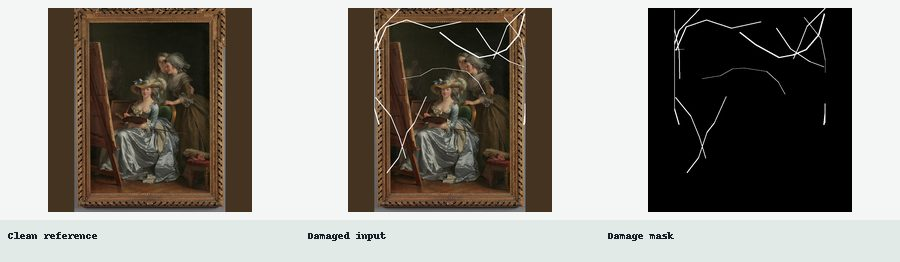
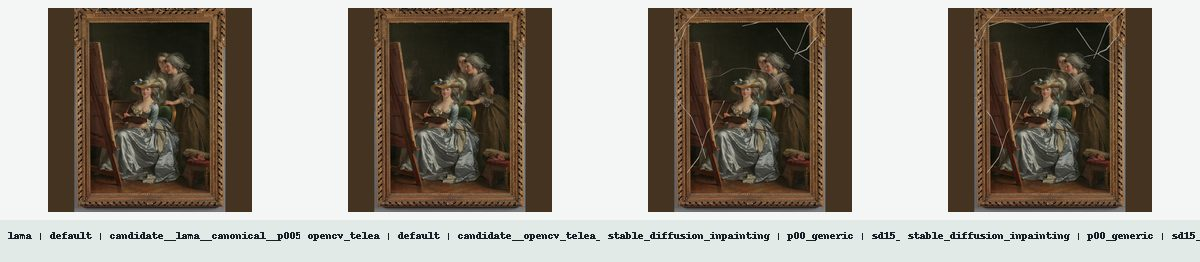
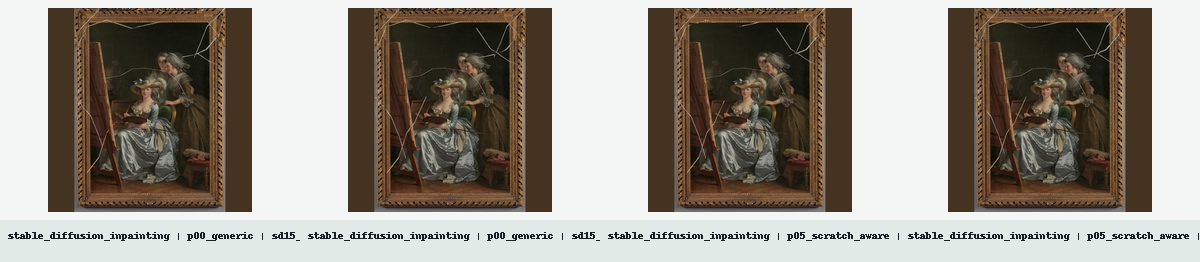
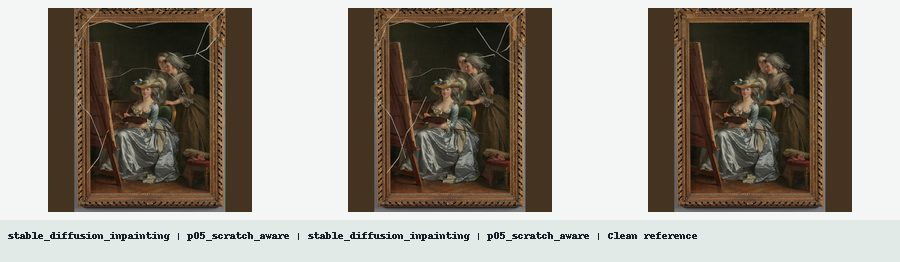
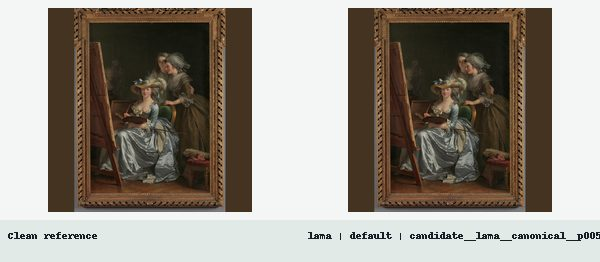
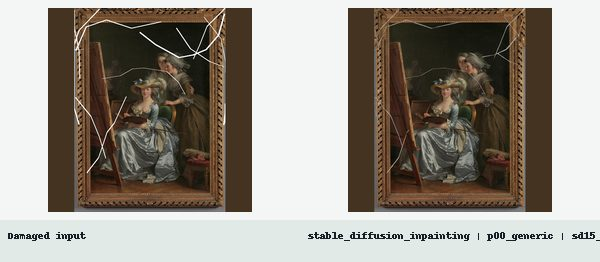
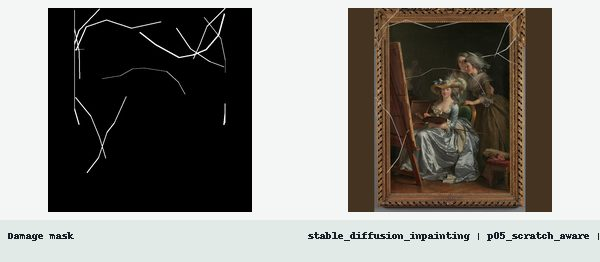

Self-contained case-report smoke test passed.
Rendered HTML characters: 322117
Embedded images: 7
Embedded logical tiles: 20
External image dependencies: 0
Smoke report file written: False


In [16]:
from IPython.display import HTML


SMOKE_VISUALS_BY_SECTION: dict[str, list[str]] = {}

for item in SMOKE_VISUALS:
    SMOKE_VISUALS_BY_SECTION.setdefault(
        item["section_id"],
        [],
    ).append(item["html"])


def smoke_visuals_for(section_id: str) -> str:
    return "".join(
        SMOKE_VISUALS_BY_SECTION.get(
            section_id,
            [],
        )
    )


SMOKE_CASE_SECTIONS = {
    "executive-summary": f"""
<p>
This structural smoke report verifies that the approved report
design can be rendered with real evidence images and no external
dependencies. It does not conclude that one restoration is better
or worse than another. That comparison remains inconclusive until
the full metric, spatial, uncertainty, and flag evidence is assembled.
</p>
<div class="conclusion">
<strong>Smoke-test conclusion:</strong>
The report structure is portable and ready for evidence assembly.
Human review remains necessary for every final case interpretation.
</div>
<p>
{REPORTS["mandatory_statement"]}
</p>
""",
    "case-identity-applicability": f"""
<table>
<tr><th>Field</th><th>Validated value</th></tr>
<tr><td>Case</td><td>{SMOKE_CASE_ID}</td></tr>
<tr><td>Painting</td><td>{SMOKE_SELECTION["painting_id"]}</td></tr>
<tr><td>Category</td><td>{SMOKE_SELECTION["category"]}</td></tr>
<tr><td>Experiment</td><td>{SMOKE_SELECTION["experiment_id"]}</td></tr>
<tr><td>Damage</td><td>{SMOKE_SELECTION["degradation_family"]}</td></tr>
<tr><td>Approved candidates</td><td>{len(SMOKE_CANDIDATES)}</td></tr>
</table>
<p>
The final report will state applicability separately for deterministic
models, repeated-seed diffusion evidence, prompt comparisons, and
partial SDXL evidence.
</p>
""",
    "clean-damaged-mask": f"""
<p>
The input panel establishes the reference, observed damage, and
spatial repair permission before restoration outputs are interpreted.
</p>
{smoke_visuals_for("clean-damaged-mask")}
""",
    "approved-candidate-gallery": f"""
<p>
All approved candidates for the case remain visible. Candidates are
labelled by model, prompt policy, and candidate identifier so that a
selected illustration cannot silently replace the complete case
population.
</p>
{smoke_visuals_for("approved-candidate-gallery")}
""",
    "multi-metric-evidence": f"""
<p>
The final report will compare classical, perceptual, CLIP, DINOv2,
and model-comparison evidence without treating candidate rows as
independent paintings.
</p>
{smoke_visuals_for("multi-metric-evidence")}
""",
    "texture-colour-seam": f"""
<p>
Texture, colour, and seam findings will be followed by short direct
statements describing whether the result is better, worse, or still
inconclusive for the affected region.
</p>
{smoke_visuals_for("texture-colour-seam")}
""",
    "difference-spatial-diagnostics": """
<p>
Absolute-error, signed-improvement, boundary, and spatial diagnostic
maps will be shown with their declared scales. A visually quiet map
will not be treated as proof of historical correctness.
</p>
""",
    "semantic-structural-evidence": f"""
<p>
Semantic and structural evidence will identify preservation or drift
only within the applicability of the pretrained feature models.
</p>
{smoke_visuals_for("semantic-structural-evidence")}
""",
    "uncertainty-prompt-sensitivity": """
<p>
Repeated-seed uncertainty and paired prompt evidence will be included
only where available. Low uncertainty means similar candidates; it
does not mean that the restoration is correct.
</p>
""",
    "failure-taxonomy-flags": """
<p>
Triggered flags and failure categories will be connected to their
supporting evidence and affected regions. They remain computational
review signals rather than expert conservation labels.
</p>
""",
    "human-review-action": """
<ul>
<li>Inspect masked content and the boundary separately.</li>
<li>Compare model-specific strengths and weaknesses.</li>
<li>Escalate conflicting metrics or severe flags to human review.</li>
</ul>
""",
    "limitations": """
<div class="limitation">
<strong>Limitation:</strong>
This smoke report validates structure and portability only. It does
not contain the final case-level evidence synthesis or scientific
assessment.
</div>
""",
    "provenance": f"""
<p>
The final report will record the selected-case identifier, candidate
identifiers, source artifact paths, upstream run identifiers, and
checksums. This smoke instance uses case <code>{SMOKE_CASE_ID}</code>.
</p>
""",
}

SMOKE_CASE_HTML = render_report_html(
    title=f"Case Report Smoke Test — {SMOKE_CASE_ID}",
    subtitle=(
        "Structural validation using real approved repository images"
    ),
    report_kind="case",
    sections=SMOKE_CASE_SECTIONS,
    config=CONFIG,
)

SMOKE_REPORT_CHECKS = validate_report_html(
    SMOKE_CASE_HTML,
    report_kind="case",
    config=CONFIG,
)

collect_scoped_helper_checks(
    SMOKE_REPORT_CHECKS,
    scope="batch_4_case_smoke",
)

VALIDATION.raise_for_blocking()

display(
    SMOKE_REPORT_CHECKS[
        [
            "check_name",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

# Render the seven visual blocks without injecting the report's page-level CSS.
SMOKE_PREVIEW_HTML = """
<div style="max-width:1180px;margin:auto">
<h3>Notebook 32 — self-contained visual smoke preview</h3>
<p>
The panels below are embedded in memory. No external image dependency
or temporary preview file is used.
</p>
""" + "".join(
    item["html"]
    for item in SMOKE_VISUALS
) + "</div>"

display(HTML(SMOKE_PREVIEW_HTML))

print("Self-contained case-report smoke test passed.")
print("Rendered HTML characters:", len(SMOKE_CASE_HTML))
print(
    "Embedded images:",
    SMOKE_CASE_HTML.count("<img "),
)
print(
    "Embedded logical tiles:",
    sum(item["tile_count"] for item in SMOKE_VISUALS),
)
print(
    "External image dependencies:",
    sum(
        not item["data_uri"].startswith("data:image/")
        for item in SMOKE_VISUALS
    ),
)
print("Smoke report file written:", False)

In [17]:
TRACEABILITY_STATUS_COUNTS = (
    MOCK_TRACEABILITY[
        "implementation_status"
    ]
    .value_counts()
    .rename_axis("implementation_status")
    .reset_index(name="row_count")
)

SMOKE_CHECK_PROFILE = (
    SMOKE_REPORT_CHECKS
    .groupby(
        ["severity", "passed"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "check_count"})
)

BATCH_4_VALIDATION = VALIDATION.to_dataframe()
BATCH_4_SUMMARY = VALIDATION.summary()

display(TRACEABILITY_STATUS_COUNTS)
display(SMOKE_CHECK_PROFILE)

print("Batch 4 completed.")
print("Mock traceability rows:", len(MOCK_TRACEABILITY))
print(
    "Mock roles with canonical evidence:",
    int(
        MOCK_TRACEABILITY[
            "canonical_evidence_source"
        ]
        .astype(str)
        .str.strip()
        .ne("")
        .sum()
    ),
)
print("Smoke case:", SMOKE_CASE_ID)
print("Smoke visual panels:", len(SMOKE_VISUALS))
print(
    "Smoke image tiles:",
    sum(item["tile_count"] for item in SMOKE_VISUALS),
)
print(
    "Checks added in Batch 4:",
    len(BATCH_4_VALIDATION) - len(BATCH_3_VALIDATION),
)
print("Validation summary:", BATCH_4_SUMMARY)
print("Blocking failures:", BATCH_4_SUMMARY["blocking_failure_count"])
print("Canonical files written:", 0)
print("Temporary files written:", 0)
print("Ready for Batch 5:", BATCH_4_SUMMARY["overall_passed"])

,implementation_status,row_count
0,preserved,67


,severity,passed,check_count
0,blocking,True,16


Batch 4 completed.
Mock traceability rows: 67
Mock roles with canonical evidence: 67
Smoke case: canonical__p005__scratch_thin
Smoke visual panels: 7
Smoke image tiles: 20
Checks added in Batch 4: 21
Validation summary: {'check_count': 349, 'passed_count': 349, 'failed_count': 0, 'blocking_failure_count': 0, 'overall_passed': True, 'failed_check_ids': []}
Blocking failures: 0
Canonical files written: 0
Temporary files written: 0
Ready for Batch 5: True


## Batch 5 — Selected evidence assembly and diagnostic grids

This batch assembles the complete upstream evidence available for the 30 deterministically selected cases.

It:

- restricts candidate-specific evidence to the approved selected candidates;
- retains pair-level and group-level evidence for the selected cases;
- records applicability rather than inventing evidence where an upstream family is unavailable;
- validates complete Notebook 27 failure and trustworthiness coverage;
- generates one canonical all-candidate diagnostic grid for every selected case;
- displays representative grids for visual inspection.

Each grid contains:

- clean reference;
- damaged input;
- mask;
- every approved candidate for that case.

The grids are presentation assets only. They do not compute new metrics or identify a winning restoration.

In [20]:
SELECTED_CANDIDATE_CATALOG = (
    CANDIDATE_CATALOG.loc[
        CANDIDATE_CATALOG[
            "case_id"
        ].isin(SELECTED_CASE_IDS)
    ]
    .copy()
    .sort_values(
        [
            "case_id",
            "model_id",
            "prompt_variant_id",
            "candidate_id",
        ]
    )
    .reset_index(drop=True)
)

SELECTED_CANDIDATE_IDS = set(
    SELECTED_CANDIDATE_CATALOG[
        "candidate_id"
    ].astype(str)
)

SELECTED_PAINTING_IDS = set(
    SELECTED_CASES["painting_id"].astype(str)
)

SELECTED_UNCERTAINTY_GROUP_IDS = {
    str(value).strip()
    for value
    in SELECTED_CANDIDATE_CATALOG[
        "uncertainty_group_id"
    ]
    if pd.notna(value)
    and str(value).strip()
    and str(value).strip().lower() != "nan"
}

SELECTED_CASE_EVIDENCE_KEYS = (
    "classical_metrics_path",
    "lpips_metrics_path",
    "feature_metrics_path",
    "spatial_diagnostics_path",
    "spatial_map_manifest_path",
    "local_consistency_path",
    "local_map_manifest_path",
    "canonical_uncertainty_path",
    "uncertainty_map_manifest_path",
    "semantic_metrics_path",
    "semantic_map_manifest_path",
    "damage_size_candidates_path",
    "damage_size_uncertainty_path",
    "damage_size_map_manifest_path",
    "failure_assignments_path",
    "trustworthiness_flags_path",
    "explanation_cases_path",
)

EVIDENCE_SOURCE_LABELS = {
    "classical_metrics_path": "N13 classical metrics",
    "lpips_metrics_path": "N14 LPIPS",
    "feature_metrics_path": "N15 feature similarity",
    "spatial_diagnostics_path": "N16 spatial diagnostics",
    "spatial_map_manifest_path": "N16 spatial maps",
    "local_consistency_path": "N17 local consistency",
    "local_map_manifest_path": "N17 local maps",
    "canonical_uncertainty_path": "N18 uncertainty",
    "uncertainty_map_manifest_path": "N19 uncertainty maps",
    "semantic_metrics_path": "N20 semantic evidence",
    "semantic_map_manifest_path": "N20 semantic maps",
    "damage_size_candidates_path": "N22 extension candidates",
    "damage_size_uncertainty_path": "N22 extension uncertainty",
    "damage_size_map_manifest_path": "N22 extension maps",
    "failure_assignments_path": "N27 failure assignments",
    "trustworthiness_flags_path": "N27 trustworthiness flags",
    "explanation_cases_path": "N29 explanation catalog",
}


def filter_selected_case_evidence(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    """Retain approved evidence belonging to selected cases."""

    selected = frame.copy()

    if "case_id" in selected.columns:
        selected = selected.loc[
            selected["case_id"]
            .fillna("")
            .astype(str)
            .isin(SELECTED_CASE_IDS)
        ].copy()

    elif "candidate_id" in selected.columns:
        selected = selected.loc[
            selected["candidate_id"]
            .fillna("")
            .astype(str)
            .isin(SELECTED_CANDIDATE_IDS)
        ].copy()

    elif "painting_id" in selected.columns:
        selected = selected.loc[
            selected["painting_id"]
            .fillna("")
            .astype(str)
            .isin(SELECTED_PAINTING_IDS)
        ].copy()

    if "candidate_id" in selected.columns:
        candidate_values = (
            selected["candidate_id"]
            .fillna("")
            .astype(str)
            .str.strip()
        )

        # Blank candidate IDs are valid for group or pair summaries.
        selected = selected.loc[
            candidate_values.eq("")
            | candidate_values.isin(
                SELECTED_CANDIDATE_IDS
            )
        ].copy()

    return selected.reset_index(drop=True)


SELECTED_CASE_EVIDENCE: dict[str, pd.DataFrame] = {}
EVIDENCE_SOURCE_ROWS = []

for evidence_key in SELECTED_CASE_EVIDENCE_KEYS:
    source = INPUT_TABLES[evidence_key]

    selected = filter_selected_case_evidence(
        source
    )

    SELECTED_CASE_EVIDENCE[evidence_key] = selected

    EVIDENCE_SOURCE_ROWS.append(
        {
            "evidence_key": evidence_key,
            "evidence_source": EVIDENCE_SOURCE_LABELS[
                evidence_key
            ],
            "full_rows": len(source),
            "selected_rows": len(selected),
            "selected_case_count": (
                selected["case_id"].nunique()
                if "case_id" in selected.columns
                else 0
            ),
            "selected_candidate_count": (
                selected["candidate_id"]
                .fillna("")
                .astype(str)
                .loc[
                    lambda values:
                    values.str.strip().ne("")
                ]
                .nunique()
                if "candidate_id" in selected.columns
                else 0
            ),
            "status_column_present": (
                "status" in selected.columns
            ),
        }
    )

EVIDENCE_SOURCE_PROFILE = pd.DataFrame(
    EVIDENCE_SOURCE_ROWS
)

display(EVIDENCE_SOURCE_PROFILE)

print("Selected-case evidence assembled.")
print("Selected cases:", len(SELECTED_CASE_IDS))
print(
    "Selected approved candidates:",
    len(SELECTED_CANDIDATE_IDS),
)
print(
    "Selected uncertainty groups:",
    len(SELECTED_UNCERTAINTY_GROUP_IDS),
)
print(
    "Evidence sources assembled:",
    len(SELECTED_CASE_EVIDENCE),
)

,evidence_key,evidence_source,full_rows,selected_rows,selected_case_count,selected_candidate_count,status_column_present
0,classical_metrics_path,N13 classical metrics,63018,5340,30,180,True
1,lpips_metrics_path,N14 LPIPS,4170,354,30,180,True
2,feature_metrics_path,N15 feature similarity,8340,708,30,180,True
3,spatial_diagnostics_path,N16 spatial diagnostics,18896,1602,30,180,True
4,spatial_map_manifest_path,N16 spatial maps,10062,873,28,174,True
5,local_consistency_path,N17 local consistency,271988,23190,30,180,True
6,local_map_manifest_path,N17 local maps,3282,266,28,87,True
7,canonical_uncertainty_path,N18 uncertainty,20800,4000,13,100,True
8,uncertainty_map_manifest_path,N19 uncertainty maps,1055,204,13,25,True
9,semantic_metrics_path,N20 semantic evidence,58980,4980,30,180,True


Selected-case evidence assembled.
Selected cases: 30
Selected approved candidates: 195
Selected uncertainty groups: 30
Evidence sources assembled: 17


In [21]:
# Restore the clean validation state from the end of Batch 4 because
# the previous version of this cell added invalid status checks before failing.
VALIDATION = ValidationCollector()

for record in BATCH_4_VALIDATION.to_dict(
    orient="records"
):
    VALIDATION.add(
        validation_stage=record["validation_stage"],
        check_id=record["check_id"],
        check_description=record["check_description"],
        severity=record["severity"],
        expected=record["expected"],
        observed=record["observed"],
        passed=bool(record["passed"]),
        details=record["details"],
    )


SELECTED_CASE_CANDIDATE_COUNTS = (
    SELECTED_CANDIDATE_CATALOG
    .groupby("case_id")
    .size()
    .rename("approved_candidate_count")
)

EVIDENCE_COVERAGE_ROWS = []

for case_id in sorted(SELECTED_CASE_IDS):
    expected_candidates = int(
        SELECTED_CASE_CANDIDATE_COUNTS.loc[
            case_id
        ]
    )

    for evidence_key, frame in (
        SELECTED_CASE_EVIDENCE.items()
    ):
        if "case_id" in frame.columns:
            case_rows = frame.loc[
                frame["case_id"]
                .fillna("")
                .astype(str)
                .eq(case_id)
            ]
        else:
            case_rows = frame.iloc[0:0]

        candidate_count = 0

        if "candidate_id" in case_rows.columns:
            candidate_values = (
                case_rows["candidate_id"]
                .fillna("")
                .astype(str)
                .str.strip()
            )

            candidate_count = int(
                candidate_values.loc[
                    candidate_values.ne("")
                ].nunique()
            )

        EVIDENCE_COVERAGE_ROWS.append(
            {
                "case_id": case_id,
                "evidence_key": evidence_key,
                "evidence_source": (
                    EVIDENCE_SOURCE_LABELS[
                        evidence_key
                    ]
                ),
                "expected_candidate_count": (
                    expected_candidates
                ),
                "evidence_row_count": len(case_rows),
                "candidate_count": candidate_count,
                "applicability_state": (
                    "available"
                    if len(case_rows) > 0
                    else "not_available_for_case"
                ),
            }
        )

SELECTED_EVIDENCE_COVERAGE = pd.DataFrame(
    EVIDENCE_COVERAGE_ROWS
)

FAILURE_ASSIGNMENTS_SELECTED = (
    SELECTED_CASE_EVIDENCE[
        "failure_assignments_path"
    ]
)

TRUSTWORTHINESS_FLAGS_SELECTED = (
    SELECTED_CASE_EVIDENCE[
        "trustworthiness_flags_path"
    ]
)

FAILURE_CATEGORIES_PER_CANDIDATE = (
    len(INPUT_TABLES["failure_assignments_path"])
    // int(EXPECTED["approved_candidate_count"])
)

FLAGS_PER_CANDIDATE = (
    len(INPUT_TABLES["trustworthiness_flags_path"])
    // int(EXPECTED["approved_candidate_count"])
)

EXPECTED_SELECTED_CANDIDATES = int(
    SELECTED_CASES["candidate_count"].sum()
)

CORE_EVIDENCE_CHECKS = (
    (
        "selected_candidate_rows",
        "Selected catalog contains every approved selected candidate",
        EXPECTED_SELECTED_CANDIDATES,
        len(SELECTED_CANDIDATE_CATALOG),
        (
            len(SELECTED_CANDIDATE_CATALOG)
            == EXPECTED_SELECTED_CANDIDATES
        ),
    ),
    (
        "selected_candidate_ids_unique",
        "Selected candidate identifiers are unique",
        EXPECTED_SELECTED_CANDIDATES,
        int(
            SELECTED_CANDIDATE_CATALOG[
                "candidate_id"
            ].nunique()
        ),
        (
            SELECTED_CANDIDATE_CATALOG[
                "candidate_id"
            ].nunique()
            == EXPECTED_SELECTED_CANDIDATES
        ),
    ),
    (
        "failure_assignment_rows",
        "Selected candidates retain every failure-category assignment",
        (
            EXPECTED_SELECTED_CANDIDATES
            * FAILURE_CATEGORIES_PER_CANDIDATE
        ),
        len(FAILURE_ASSIGNMENTS_SELECTED),
        (
            len(FAILURE_ASSIGNMENTS_SELECTED)
            == (
                EXPECTED_SELECTED_CANDIDATES
                * FAILURE_CATEGORIES_PER_CANDIDATE
            )
        ),
    ),
    (
        "trustworthiness_flag_rows",
        "Selected candidates retain every trustworthiness flag",
        (
            EXPECTED_SELECTED_CANDIDATES
            * FLAGS_PER_CANDIDATE
        ),
        len(TRUSTWORTHINESS_FLAGS_SELECTED),
        (
            len(TRUSTWORTHINESS_FLAGS_SELECTED)
            == (
                EXPECTED_SELECTED_CANDIDATES
                * FLAGS_PER_CANDIDATE
            )
        ),
    ),
)

for check_id, description, expected, observed, passed in CORE_EVIDENCE_CHECKS:
    VALIDATION.add(
        validation_stage="batch_5_core_evidence",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=(
            ""
            if passed
            else "Selected-case core evidence coverage failed."
        ),
    )


# Successful states differ by canonical artifact type.
ALLOWED_EVIDENCE_STATUSES = {
    "classical_metrics_path": {"ok"},
    "lpips_metrics_path": {"ok"},
    "feature_metrics_path": {"ok"},
    "spatial_diagnostics_path": {"ok"},
    "spatial_map_manifest_path": {"passed"},
    "local_consistency_path": {
        "ok",
        "not_applicable",
    },
    "local_map_manifest_path": {"passed"},
    "canonical_uncertainty_path": {"ok"},
    "uncertainty_map_manifest_path": {"passed"},
    "semantic_metrics_path": {"ok"},
    "semantic_map_manifest_path": {"passed"},
    "damage_size_candidates_path": {"completed"},
    "damage_size_uncertainty_path": {"ok"},
    "damage_size_map_manifest_path": {"passed"},
    "failure_assignments_path": {"ok"},
    "trustworthiness_flags_path": {"ok"},
    "explanation_cases_path": {"ok"},
}

EVIDENCE_STATUS_ROWS = []

for evidence_key, frame in (
    SELECTED_CASE_EVIDENCE.items()
):
    if "status" not in frame.columns:
        continue

    allowed_statuses = ALLOWED_EVIDENCE_STATUSES[
        evidence_key
    ]

    observed_status_counts = {
        str(status): int(count)
        for status, count
        in frame["status"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
        .value_counts()
        .sort_index()
        .items()
    }

    observed_statuses = set(
        observed_status_counts
    )

    statuses_passed = (
        observed_statuses
        .issubset(allowed_statuses)
    )

    VALIDATION.add(
        validation_stage="batch_5_evidence_status",
        check_id=f"status__{evidence_key}",
        check_description=(
            f"{evidence_key} uses only its approved status vocabulary"
        ),
        severity="blocking",
        expected=sorted(allowed_statuses),
        observed=observed_status_counts,
        passed=statuses_passed,
        details=(
            ""
            if statuses_passed
            else (
                "Unexpected statuses: "
                f"{sorted(observed_statuses - allowed_statuses)}"
            )
        ),
    )

    EVIDENCE_STATUS_ROWS.append(
        {
            "evidence_key": evidence_key,
            "allowed_statuses": ", ".join(
                sorted(allowed_statuses)
            ),
            "observed_status_counts": json.dumps(
                observed_status_counts,
                sort_keys=True,
            ),
            "status": (
                "passed"
                if statuses_passed
                else "failed"
            ),
        }
    )

EVIDENCE_STATUS_PROFILE = pd.DataFrame(
    EVIDENCE_STATUS_ROWS
)


EXPECTED_ASSIGNMENTS_BY_CASE = (
    SELECTED_CASE_CANDIDATE_COUNTS
    * FAILURE_CATEGORIES_PER_CANDIDATE
)

OBSERVED_ASSIGNMENTS_BY_CASE = (
    FAILURE_ASSIGNMENTS_SELECTED
    .groupby("case_id")
    .size()
    .reindex(
        EXPECTED_ASSIGNMENTS_BY_CASE.index,
        fill_value=0,
    )
)

EXPECTED_FLAGS_BY_CASE = (
    SELECTED_CASE_CANDIDATE_COUNTS
    * FLAGS_PER_CANDIDATE
)

OBSERVED_FLAGS_BY_CASE = (
    TRUSTWORTHINESS_FLAGS_SELECTED
    .groupby("case_id")
    .size()
    .reindex(
        EXPECTED_FLAGS_BY_CASE.index,
        fill_value=0,
    )
)

ASSIGNMENTS_BY_CASE_PASSED = (
    OBSERVED_ASSIGNMENTS_BY_CASE.astype(int)
    .equals(
        EXPECTED_ASSIGNMENTS_BY_CASE.astype(int)
    )
)

FLAGS_BY_CASE_PASSED = (
    OBSERVED_FLAGS_BY_CASE.astype(int)
    .equals(
        EXPECTED_FLAGS_BY_CASE.astype(int)
    )
)

VALIDATION.add(
    validation_stage="batch_5_core_evidence",
    check_id="failure_assignments_by_case",
    check_description=(
        "Every selected case retains complete failure-category coverage"
    ),
    severity="blocking",
    expected=EXPECTED_ASSIGNMENTS_BY_CASE.to_dict(),
    observed=OBSERVED_ASSIGNMENTS_BY_CASE.to_dict(),
    passed=ASSIGNMENTS_BY_CASE_PASSED,
    details=(
        ""
        if ASSIGNMENTS_BY_CASE_PASSED
        else "Failure assignments are incomplete for a selected case."
    ),
)

VALIDATION.add(
    validation_stage="batch_5_core_evidence",
    check_id="trustworthiness_flags_by_case",
    check_description=(
        "Every selected case retains complete flag coverage"
    ),
    severity="blocking",
    expected=EXPECTED_FLAGS_BY_CASE.to_dict(),
    observed=OBSERVED_FLAGS_BY_CASE.to_dict(),
    passed=FLAGS_BY_CASE_PASSED,
    details=(
        ""
        if FLAGS_BY_CASE_PASSED
        else "Trustworthiness flags are incomplete for a selected case."
    ),
)

VALIDATION.raise_for_blocking()

COVERAGE_MATRIX = (
    SELECTED_EVIDENCE_COVERAGE
    .pivot(
        index="case_id",
        columns="evidence_source",
        values="evidence_row_count",
    )
    .fillna(0)
    .astype(int)
)

display(EVIDENCE_STATUS_PROFILE)
display(COVERAGE_MATRIX)

print("Selected evidence coverage validated.")
print(
    "Failure categories per candidate:",
    FAILURE_CATEGORIES_PER_CANDIDATE,
)
print(
    "Trustworthiness flags per candidate:",
    FLAGS_PER_CANDIDATE,
)
print(
    "Selected failure-assignment rows:",
    len(FAILURE_ASSIGNMENTS_SELECTED),
)
print(
    "Selected flag rows:",
    len(TRUSTWORTHINESS_FLAGS_SELECTED),
)
print(
    "Legitimate local not-applicable rows:",
    int(
        SELECTED_CASE_EVIDENCE[
            "local_consistency_path"
        ]["status"]
        .astype(str)
        .str.lower()
        .eq("not_applicable")
        .sum()
    ),
)
print("Blocking failures:", len(VALIDATION.blocking_failures))

,evidence_key,allowed_statuses,observed_status_counts,status
0,classical_metrics_path,ok,"{""ok"": 5340}",passed
1,lpips_metrics_path,ok,"{""ok"": 354}",passed
2,feature_metrics_path,ok,"{""ok"": 708}",passed
3,spatial_diagnostics_path,ok,"{""ok"": 1602}",passed
4,spatial_map_manifest_path,passed,"{""passed"": 873}",passed
5,local_consistency_path,"not_applicable, ok","{""not_applicable"": 312, ""ok"": 22878}",passed
6,local_map_manifest_path,passed,"{""passed"": 266}",passed
7,canonical_uncertainty_path,ok,"{""ok"": 4000}",passed
8,uncertainty_map_manifest_path,passed,"{""passed"": 204}",passed
9,semantic_metrics_path,ok,"{""ok"": 4980}",passed


evidence_source,N13 classical metrics,N14 LPIPS,N15 feature similarity,N16 spatial diagnostics,N16 spatial maps,N17 local consistency,N17 local maps,N18 uncertainty,N19 uncertainty maps,N20 semantic evidence,N20 semantic maps,N22 extension candidates,N22 extension maps,N22 extension uncertainty,N27 failure assignments,N27 trustworthiness flags,N29 explanation catalog
case_id,,,,,,,,,,,,,,,,,
canonical__p001__loss_large,120,8,16,36,21,524,13,0,0,112,20,0,0,0,56,44,4
canonical__p001__scratch_thin,300,20,40,90,50,1310,9,320,17,280,43,0,0,0,140,110,10
canonical__p001__zero_control,33,3,6,9,0,81,0,0,0,54,6,0,0,0,42,33,3
canonical__p002__scratch_thin,300,20,40,90,50,1310,9,320,17,280,43,0,0,0,140,110,10
canonical__p002__zero_control,33,3,6,9,0,81,0,0,0,54,6,0,0,0,42,33,3
canonical__p005__scratch_thin,300,20,40,90,50,1310,9,320,16,280,43,0,0,0,140,110,10
canonical__p006__scratch_thin,300,20,40,90,50,1310,9,320,16,280,43,0,0,0,140,110,10
canonical__p009__scratch_thin,300,20,40,90,50,1310,9,320,16,280,43,0,0,0,140,110,10
canonical__p011__loss_large,180,12,24,54,30,786,9,160,8,168,27,0,0,0,84,66,6


Selected evidence coverage validated.
Failure categories per candidate: 14
Trustworthiness flags per candidate: 11
Selected failure-assignment rows: 2730
Selected flag rows: 2145
Legitimate local not-applicable rows: 312
Blocking failures: 0


In [22]:
import os
import time

from restoration_eval.case_painting_reports import (
    sha256_path,
)


MODEL_DISPLAY_NAMES = {
    "opencv_telea": "OpenCV Telea",
    "lama": "LaMa",
    "stable_diffusion_inpainting": "Stable Diffusion",
    "sdxl_inpainting": "SDXL",
}


def candidate_grid_label(
    row: pd.Series,
) -> str:
    """Return a compact but auditable candidate label."""

    model_name = MODEL_DISPLAY_NAMES.get(
        str(row["model_id"]),
        str(row["model_id"]),
    )

    prompt = str(
        row.get("prompt_variant_id", "")
    ).strip()

    if not prompt or prompt.lower() == "nan":
        prompt = "default"

    candidate_suffix = str(
        row["candidate_id"]
    )[-12:]

    return (
        f"{model_name} | {prompt} | "
        f"{candidate_suffix}"
    )


def save_png_atomic(
    image: Image.Image,
    output_path: Path,
    *,
    maximum_attempts: int = 6,
) -> Path:
    """Save one PNG atomically with short Windows lock retries."""

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary_path = output_path.with_suffix(
        output_path.suffix + ".tmp"
    )

    for attempt in range(
        1,
        maximum_attempts + 1,
    ):
        try:
            image.save(
                temporary_path,
                format="PNG",
                optimize=True,
            )
            os.replace(
                temporary_path,
                output_path,
            )
            return output_path

        except PermissionError:
            temporary_path.unlink(
                missing_ok=True
            )

            if attempt >= maximum_attempts:
                raise

            time.sleep(0.35 * attempt)

    raise RuntimeError(
        "Atomic PNG writer ended unexpectedly."
    )


def build_selected_case_grid(
    case_id: str,
    candidates: pd.DataFrame,
    output_path: Path,
    *,
    columns: int = 4,
    tile_width: int = 270,
    tile_height: int = 215,
    label_height: int = 48,
    title_height: int = 54,
) -> dict:
    """Generate one all-candidate case grid."""

    ordered_candidates = (
        candidates
        .sort_values(
            [
                "model_id",
                "prompt_variant_id",
                "candidate_id",
            ]
        )
        .reset_index(drop=True)
    )

    if ordered_candidates.empty:
        raise ValueError(
            f"No approved candidates for {case_id}."
        )

    first = ordered_candidates.iloc[0]

    items = [
        (
            resolve_repository_file(
                first["clean_path"]
            ),
            "Clean reference",
        ),
        (
            resolve_repository_file(
                first["damaged_path"]
            ),
            "Damaged input",
        ),
        (
            resolve_repository_file(
                first["mask_path"]
            ),
            "Damage mask",
        ),
    ]

    items.extend(
        (
            resolve_repository_file(
                row["restored_path"]
            ),
            candidate_grid_label(row),
        )
        for _, row in ordered_candidates.iterrows()
    )

    row_count = (
        len(items) + columns - 1
    ) // columns

    canvas = Image.new(
        "RGB",
        (
            columns * tile_width,
            title_height
            + row_count
            * (tile_height + label_height),
        ),
        color=(244, 246, 245),
    )

    draw = ImageDraw.Draw(canvas)

    draw.rectangle(
        (
            0,
            0,
            canvas.width,
            title_height,
        ),
        fill=(39, 91, 87),
    )

    draw.text(
        (14, 18),
        (
            f"{case_id} | "
            f"{len(ordered_candidates)} approved candidates"
        )[:130],
        fill=(255, 255, 255),
    )

    for index, (image_path, label) in enumerate(items):
        row = index // columns
        column = index % columns

        left = column * tile_width
        top = (
            title_height
            + row * (tile_height + label_height)
        )

        with Image.open(image_path) as source:
            image = source.convert("RGB")
            contained = ImageOps.contain(
                image,
                (
                    tile_width - 16,
                    tile_height - 16,
                ),
                method=Image.Resampling.LANCZOS,
            )

        image_left = (
            left
            + (tile_width - contained.width) // 2
        )
        image_top = (
            top
            + (tile_height - contained.height) // 2
        )

        canvas.paste(
            contained,
            (image_left, image_top),
        )

        label_top = top + tile_height

        draw.rectangle(
            (
                left,
                label_top,
                left + tile_width,
                label_top + label_height,
            ),
            fill=(226, 234, 231),
        )

        draw.text(
            (
                left + 7,
                label_top + 10,
            ),
            str(label)[:47],
            fill=(23, 32, 38),
        )

    save_png_atomic(
        canvas,
        output_path,
    )

    return {
        "case_id": case_id,
        "candidate_count": len(
            ordered_candidates
        ),
        "tile_count": len(items),
        "width": canvas.width,
        "height": canvas.height,
        "relative_path": output_path.relative_to(
            PROJECT_ROOT
        ).as_posix(),
        "size_bytes": output_path.stat().st_size,
        "sha256": sha256_path(output_path),
        "status": "ok",
    }


print("Selected-case grid utilities initialized.")
print(
    "Grid output directory:",
    OUTPUT_PATHS["selected_case_grids_dir"],
)
print("Expected grids:", EXPECTED["selected_case_grid_count"])

Selected-case grid utilities initialized.
Grid output directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\32_case_and_painting_report_generation\figures\selected_case_grids
Expected grids: 30


In [23]:
GRID_RECORDS = []

SELECTED_CASE_GRID_DIRECTORY = OUTPUT_PATHS[
    "selected_case_grids_dir"
]

for number, selected_row in (
    SELECTED_CASES
    .sort_values("selection_order")
    .iterrows()
):
    case_id = str(
        selected_row["case_id"]
    )

    case_candidates = (
        SELECTED_CANDIDATE_CATALOG.loc[
            SELECTED_CANDIDATE_CATALOG[
                "case_id"
            ].eq(case_id)
        ]
        .copy()
    )

    output_path = (
        SELECTED_CASE_GRID_DIRECTORY
        / f"{case_id}.png"
    )

    record = build_selected_case_grid(
        case_id,
        case_candidates,
        output_path,
    )

    record["selection_order"] = int(
        selected_row["selection_order"]
    )
    record["selection_lane"] = str(
        selected_row["selection_lane"]
    )
    record["painting_id"] = str(
        selected_row["painting_id"]
    )

    GRID_RECORDS.append(record)

    completed = len(GRID_RECORDS)

    if (
        completed % PROGRESS_INTERVAL == 0
        or completed
        == int(EXPECTED["selected_case_grid_count"])
    ):
        print(
            "Selected-case grids: "
            f"{completed}/"
            f"{EXPECTED['selected_case_grid_count']} generated."
        )

SELECTED_CASE_GRID_MANIFEST = (
    pd.DataFrame(GRID_RECORDS)
    .sort_values("selection_order")
    .reset_index(drop=True)
)

print("Selected-case diagnostic grids generated.")
print("Grid rows:", len(SELECTED_CASE_GRID_MANIFEST))
print(
    "Total grid size:",
    f"{SELECTED_CASE_GRID_MANIFEST['size_bytes'].sum() / (1024 ** 2):,.2f} MiB",
)
print(
    "Minimum tiles:",
    int(
        SELECTED_CASE_GRID_MANIFEST[
            "tile_count"
        ].min()
    ),
)
print(
    "Maximum tiles:",
    int(
        SELECTED_CASE_GRID_MANIFEST[
            "tile_count"
        ].max()
    ),
)

Selected-case grids: 10/30 generated.
Selected-case grids: 20/30 generated.
Selected-case grids: 30/30 generated.
Selected-case diagnostic grids generated.
Grid rows: 30
Total grid size: 6.32 MiB
Minimum tiles: 6
Maximum tiles: 13


Grid preview: synthetic_degradation__p039__water_stain__mild


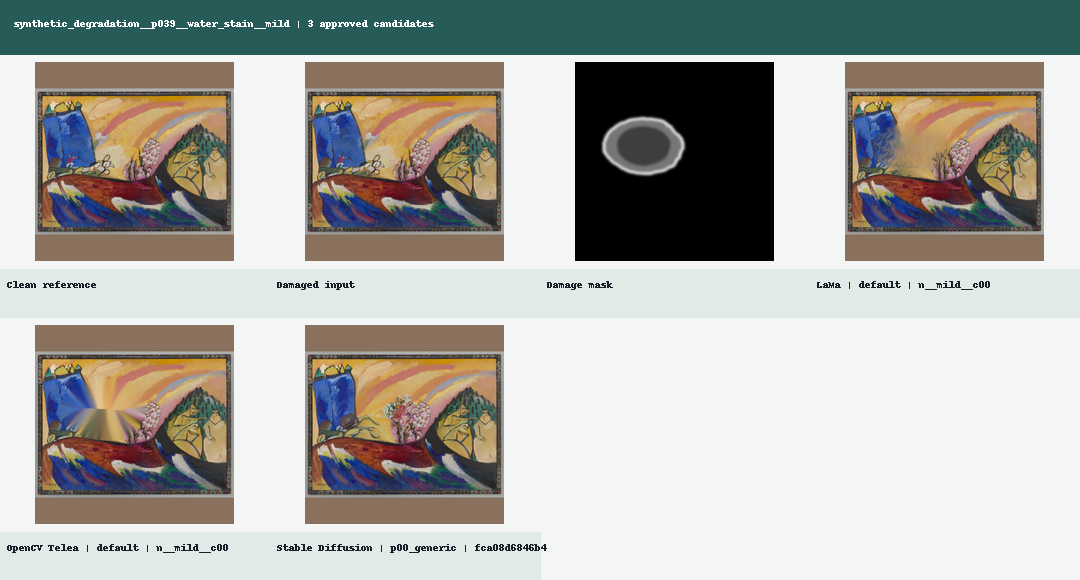

Grid preview: damage_size__p018__loss_large__size_06pct


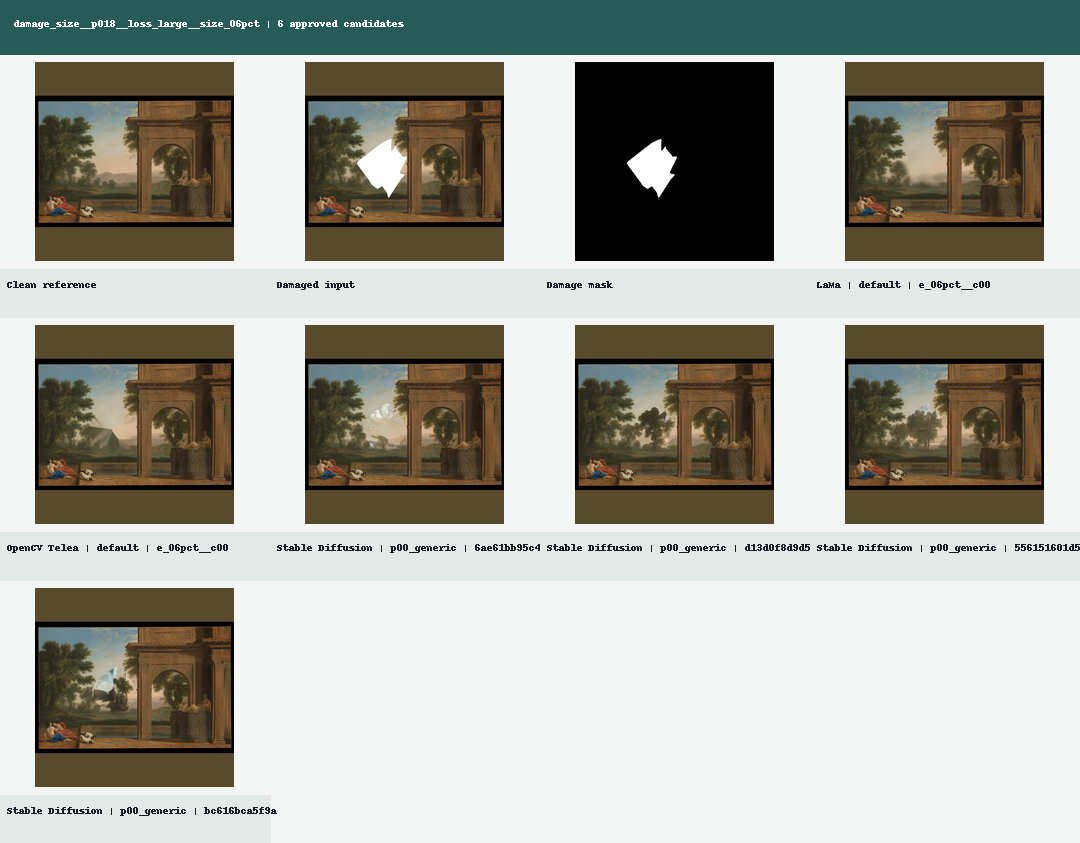

Grid preview: canonical__p001__loss_large


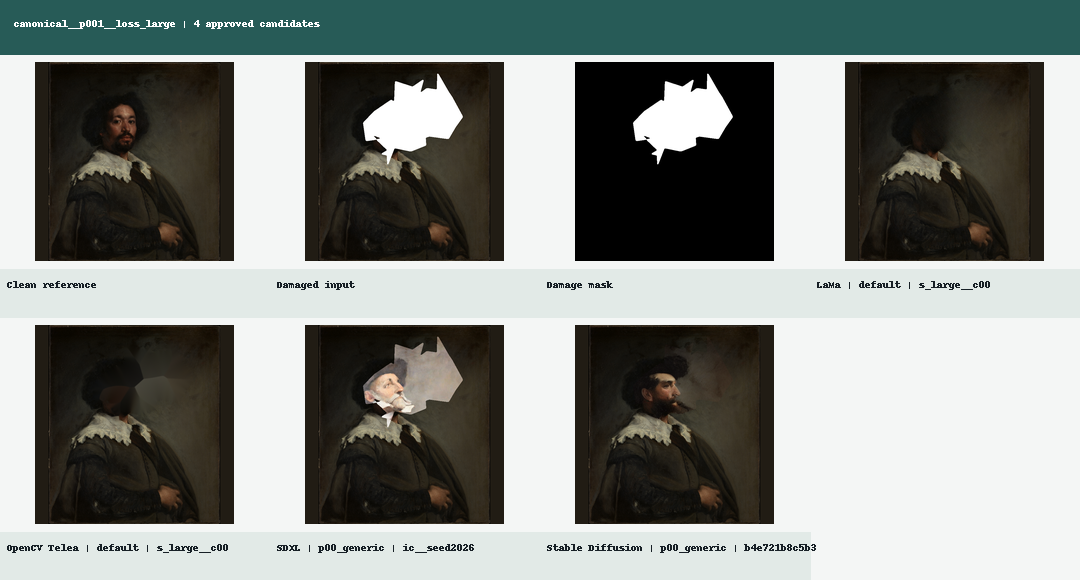

,selection_order,selection_lane,case_id,painting_id,candidate_count,tile_count,width,height,size_bytes,status
0,1,category_lower_risk,synthetic_degradation__p039__water_stain__mild,p039,3,6,1080,580,157130,ok
1,2,category_lower_risk,synthetic_degradation__p026__dirt_dust__mild,p026,3,6,1080,580,127359,ok
2,3,category_lower_risk,synthetic_degradation__p043__dirt_dust__moderate,p043,3,6,1080,580,174580,ok
3,4,category_lower_risk,synthetic_degradation__p018__partial_transpare...,p018,3,6,1080,580,125817,ok
4,5,category_lower_risk,synthetic_degradation__p001__partial_transpare...,p001,3,6,1080,580,152367,ok
5,6,category_flagged,canonical__p036__scratch_thin,p036,10,13,1080,1106,235546,ok
6,7,category_flagged,canonical__p022__scratch_thin,p022,10,13,1080,1106,339322,ok
7,8,category_flagged,canonical__p050__scratch_thin,p050,10,13,1080,1106,353766,ok
8,9,category_flagged,canonical__p013__scratch_thin,p013,10,13,1080,1106,281055,ok
9,10,category_flagged,canonical__p002__scratch_thin,p002,10,13,1080,1106,189711,ok


Batch 5 completed.
Selected evidence sources: 17
Selected evidence coverage rows: 510
Canonical grids written: 30
Checks added in Batch 5: 28
Validation summary: {'check_count': 377, 'passed_count': 377, 'failed_count': 0, 'blocking_failure_count': 0, 'overall_passed': True, 'failed_check_ids': []}
Blocking failures: 0
Reports generated: 0
Ready for Batch 6: True


In [24]:
GRID_FILES = sorted(
    SELECTED_CASE_GRID_DIRECTORY.glob(
        "*.png"
    )
)

EXPECTED_GRID_NAMES = {
    f"{case_id}.png"
    for case_id
    in SELECTED_CASES["case_id"].astype(str)
}

OBSERVED_GRID_NAMES = {
    path.name
    for path in GRID_FILES
}

GRID_IMAGE_ERRORS = []

for grid_path in GRID_FILES:
    try:
        with Image.open(grid_path) as image:
            image.verify()

        with Image.open(grid_path) as image:
            if (
                image.format != "PNG"
                or image.width < 500
                or image.height < 400
            ):
                GRID_IMAGE_ERRORS.append(
                    {
                        "path": grid_path.name,
                        "format": image.format,
                        "width": image.width,
                        "height": image.height,
                    }
                )

    except Exception as exc:
        GRID_IMAGE_ERRORS.append(
            {
                "path": grid_path.name,
                "error": (
                    f"{type(exc).__name__}: {exc}"
                ),
            }
        )

GRID_TMP_FILES = list(
    SELECTED_CASE_GRID_DIRECTORY.glob(
        "*.tmp"
    )
)

GRID_TILE_COUNTS_MATCH = (
    SELECTED_CASE_GRID_MANIFEST[
        "tile_count"
    ].astype(int)
    .equals(
        (
            SELECTED_CASE_GRID_MANIFEST[
                "candidate_count"
            ].astype(int)
            + 3
        )
    )
)

GRID_CHECKS = (
    (
        "grid_file_count",
        "Exactly 30 selected-case grids exist",
        int(EXPECTED["selected_case_grid_count"]),
        len(GRID_FILES),
        (
            len(GRID_FILES)
            == int(
                EXPECTED[
                    "selected_case_grid_count"
                ]
            )
        ),
    ),
    (
        "grid_file_identity",
        "Grid filenames match every selected case",
        sorted(EXPECTED_GRID_NAMES),
        sorted(OBSERVED_GRID_NAMES),
        OBSERVED_GRID_NAMES
        == EXPECTED_GRID_NAMES,
    ),
    (
        "grid_image_integrity",
        "Every grid is a readable PNG with useful dimensions",
        [],
        GRID_IMAGE_ERRORS,
        not GRID_IMAGE_ERRORS,
    ),
    (
        "grid_tile_counts",
        "Every grid contains inputs plus all approved candidates",
        True,
        bool(GRID_TILE_COUNTS_MATCH),
        bool(GRID_TILE_COUNTS_MATCH),
    ),
    (
        "grid_temporary_files",
        "Grid generation leaves no temporary files",
        0,
        len(GRID_TMP_FILES),
        len(GRID_TMP_FILES) == 0,
    ),
)

for check_id, description, expected, observed, passed in GRID_CHECKS:
    VALIDATION.add(
        validation_stage="batch_5_selected_grids",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=(
            ""
            if passed
            else "Selected-case grid validation failed."
        ),
    )

VALIDATION.raise_for_blocking()

from IPython.display import Image as NotebookImage


PREVIEW_CASE_IDS = [
    str(
        SELECTED_CASES.loc[
            SELECTED_CASES[
                "selection_lane"
            ].eq(lane),
            "case_id",
        ].iloc[0]
    )
    for lane in (
        "category_lower_risk",
        "high_uncertainty",
        "sdxl_partial_evaluation",
    )
]

for preview_case_id in PREVIEW_CASE_IDS:
    preview_path = (
        SELECTED_CASE_GRID_DIRECTORY
        / f"{preview_case_id}.png"
    )

    print("Grid preview:", preview_case_id)

    display(
        NotebookImage(
            filename=str(preview_path),
            width=900,
        )
    )

BATCH_5_VALIDATION = VALIDATION.to_dataframe()
BATCH_5_SUMMARY = VALIDATION.summary()

display(
    SELECTED_CASE_GRID_MANIFEST[
        [
            "selection_order",
            "selection_lane",
            "case_id",
            "painting_id",
            "candidate_count",
            "tile_count",
            "width",
            "height",
            "size_bytes",
            "status",
        ]
    ]
)

print("Batch 5 completed.")
print(
    "Selected evidence sources:",
    len(SELECTED_CASE_EVIDENCE),
)
print(
    "Selected evidence coverage rows:",
    len(SELECTED_EVIDENCE_COVERAGE),
)
print(
    "Canonical grids written:",
    len(SELECTED_CASE_GRID_MANIFEST),
)
print(
    "Checks added in Batch 5:",
    len(BATCH_5_VALIDATION) - len(BATCH_4_VALIDATION),
)
print("Validation summary:", BATCH_5_SUMMARY)
print("Blocking failures:", BATCH_5_SUMMARY["blocking_failure_count"])
print("Reports generated:", 0)
print("Ready for Batch 6:", BATCH_5_SUMMARY["overall_passed"])

## Batch 6 — Final case-report assembly and populated preview

This batch constructs the reusable final case-report renderer.

It uses only canonical upstream evidence to create:

- candidate and prompt-arm metric tables;
- metric-specific better and worse comparisons;
- local texture, colour, and seam summaries;
- spatial, semantic, and uncertainty visual evidence;
- failure-category and trustworthiness-flag tables;
- direct human-review actions;
- embedded provenance and scope limitations.

One selected SDXL partial-evaluation case is rendered in the final report format as a completion gate before all 30 reports are generated.

Metric-specific conclusions remain scoped to their individual measures. The notebook does not create an overall score or universal model winner.

In [39]:
import html as html_module


METRIC_ANCHOR_SPECS = (
    {
        "evidence_key": "classical_metrics_path",
        "metric_name": "mae",
        "region_id": "masked_region",
        "label": "Masked-region MAE",
    },
    {
        "evidence_key": "lpips_metrics_path",
        "metric_name": "lpips",
        "region_id": "content_region",
        "label": "Content-region LPIPS",
    },
    {
        "evidence_key": "feature_metrics_path",
        "metric_name": "clip_cosine_similarity",
        "region_id": "content_region",
        "label": "CLIP similarity",
    },
    {
        "evidence_key": "feature_metrics_path",
        "metric_name": "dinov2_cosine_similarity",
        "region_id": "content_region",
        "label": "DINOv2 similarity",
    },
    {
        "evidence_key": "local_consistency_path",
        "metric_name": "delta_e_ciede2000_mean",
        "region_id": "masked_region",
        "label": "Masked colour difference",
    },
    {
        "evidence_key": "local_consistency_path",
        "metric_name": "local_texture_error_mean",
        "region_id": "masked_region",
        "label": "Masked texture error",
    },
    {
        "evidence_key": "local_consistency_path",
        "metric_name": "boundary_gradient_mismatch",
        "region_id": "boundary_ring",
        "label": "Boundary gradient mismatch",
    },
    {
        "evidence_key": "semantic_metrics_path",
        "metric_name": "clip_dinov2_local_map_agreement",
        "region_id": "content_region",
        "label": "CLIP–DINOv2 local agreement",
    },
)


def model_prompt_label(
    model_id: str,
    prompt_variant_id: str,
) -> str:
    model_name = MODEL_DISPLAY_NAMES.get(
        str(model_id),
        str(model_id),
    )

    prompt = str(prompt_variant_id).strip()

    if not prompt or prompt.lower() == "nan":
        prompt = "default"

    return f"{model_name} — {prompt}"


def case_metric_anchor_table(
    case_id: str,
) -> pd.DataFrame:
    """Build metric-specific prompt-arm summaries for one case."""

    case_catalog = (
        SELECTED_CANDIDATE_CATALOG.loc[
            SELECTED_CANDIDATE_CATALOG[
                "case_id"
            ].eq(case_id),
            [
                "candidate_id",
                "prompt_variant_id",
            ],
        ]
        .drop_duplicates("candidate_id")
        .copy()
    )

    case_catalog["prompt_variant_id"] = (
        case_catalog["prompt_variant_id"]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    records = []

    for spec in METRIC_ANCHOR_SPECS:
        frame = SELECTED_CASE_EVIDENCE[
            spec["evidence_key"]
        ]

        selected = frame.loc[
            frame["case_id"]
            .fillna("")
            .astype(str)
            .eq(case_id)
            & frame["metric_name"]
            .fillna("")
            .astype(str)
            .eq(spec["metric_name"])
            & frame["region_id"]
            .fillna("")
            .astype(str)
            .eq(spec["region_id"])
            & frame["status"]
            .fillna("")
            .astype(str)
            .str.lower()
            .eq("ok")
        ].copy()

        if selected.empty:
            continue

        # Canonical metric tables may already contain prompt_variant_id.
        # The N29 catalog is the approved reporting source for this field,
        # so remove the upstream copy before the many-to-one join.
        if "prompt_variant_id" in selected.columns:
            selected = selected.drop(
                columns=["prompt_variant_id"]
            )

        selected = selected.merge(
            case_catalog,
            on="candidate_id",
            how="inner",
            validate="many_to_one",
        )

        if selected.empty:
            continue

        selected["improvement_value"] = pd.to_numeric(
            selected["improvement_value"],
            errors="coerce",
        )

        selected["restored_value"] = pd.to_numeric(
            selected["restored_value"],
            errors="coerce",
        )

        selected = selected.dropna(
            subset=["improvement_value"]
        )

        if selected.empty:
            continue

        grouped = (
            selected
            .groupby(
                [
                    "model_id",
                    "prompt_variant_id",
                ],
                as_index=False,
                dropna=False,
            )
            .agg(
                candidate_count=(
                    "candidate_id",
                    "nunique",
                ),
                restored_value_median=(
                    "restored_value",
                    "median",
                ),
                improvement_median=(
                    "improvement_value",
                    "median",
                ),
            )
        )

        for _, row in grouped.iterrows():
            records.append(
                {
                    "metric_label": spec["label"],
                    "metric_name": spec["metric_name"],
                    "region_id": spec["region_id"],
                    "model_id": str(row["model_id"]),
                    "prompt_variant_id": str(
                        row["prompt_variant_id"]
                    ),
                    "model_prompt": model_prompt_label(
                        row["model_id"],
                        row["prompt_variant_id"],
                    ),
                    "candidate_count": int(
                        row["candidate_count"]
                    ),
                    "restored_value_median": (
                        row["restored_value_median"]
                    ),
                    "improvement_median": (
                        row["improvement_median"]
                    ),
                    "interpretation": (
                        "Higher improvement is better "
                        "under the upstream metric direction."
                    ),
                }
            )

    if not records:
        return pd.DataFrame(
            columns=[
                "metric_label",
                "metric_name",
                "region_id",
                "model_id",
                "prompt_variant_id",
                "model_prompt",
                "candidate_count",
                "restored_value_median",
                "improvement_median",
                "interpretation",
            ]
        )

    return (
        pd.DataFrame(records)
        .sort_values(
            [
                "metric_label",
                "model_id",
                "prompt_variant_id",
            ]
        )
        .reset_index(drop=True)
    )


def case_metric_assertions(
    metric_table: pd.DataFrame,
) -> list[str]:
    """Create direct metric-scoped assertions without a combined winner."""

    assertions = []

    for metric_label, group in metric_table.groupby(
        "metric_label",
        sort=False,
    ):
        valid = group.dropna(
            subset=["improvement_median"]
        ).copy()

        if len(valid) < 2:
            continue

        best = valid.loc[
            valid["improvement_median"].idxmax()
        ]
        worst = valid.loc[
            valid["improvement_median"].idxmin()
        ]

        best_value = float(
            best["improvement_median"]
        )
        worst_value = float(
            worst["improvement_median"]
        )

        if best_value > 0:
            meaning = (
                "This is the better result for this metric "
                "because it shows the largest improvement "
                "over the damaged input."
            )
        else:
            meaning = (
                "All observed improvements are non-positive; "
                "this result is only the least adverse for this metric."
            )

        assertions.append(
            (
                f"{metric_label}: {best['model_prompt']} has the "
                f"highest median improvement ({best_value:.4f}), "
                f"while {worst['model_prompt']} has the lowest "
                f"({worst_value:.4f}). {meaning}"
            )
        )

    return assertions


print("Case metric anchor policy initialized.")
print("Metric-specific anchors:", len(METRIC_ANCHOR_SPECS))
print("Combined metric score created:", False)

Case metric anchor policy initialized.
Metric-specific anchors: 8
Combined metric score created: False


In [40]:
CASE_MAP_SOURCE_KEYS = (
    "uncertainty_map_manifest_path",
    "local_map_manifest_path",
    "spatial_map_manifest_path",
    "semantic_map_manifest_path",
)

MAP_TYPE_PRIORITY = {
    "uncertainty_variants": 1,
    "uncertainty_overlay": 2,
    "colour": 3,
    "seam": 4,
    "texture": 5,
    "restored_absolute_error": 6,
    "signed_improvement": 7,
    "masked_signed_improvement": 8,
    "spatial_overlay": 9,
    "semantic_panel": 10,
    "local_consistency_candidate_panel": 11,
    "candidate_spatial_panel": 12,
}


def map_report_section(
    map_type: str,
    source_key: str,
) -> str:
    normalized = str(map_type).lower()

    if (
        "uncertainty" in normalized
        or source_key
        == "uncertainty_map_manifest_path"
    ):
        return "uncertainty-prompt-sensitivity"

    if any(
        token in normalized
        for token in (
            "texture",
            "colour",
            "seam",
            "local_consistency",
        )
    ):
        return "texture-colour-seam"

    if "semantic" in normalized:
        return "semantic-structural-evidence"

    return "difference-spatial-diagnostics"


def available_case_map_assets(
    case_id: str,
) -> pd.DataFrame:
    """Collect browser-renderable canonical maps for one case."""

    rows = []

    for source_key in CASE_MAP_SOURCE_KEYS:
        frame = SELECTED_CASE_EVIDENCE[
            source_key
        ]

        selected = frame.loc[
            frame["case_id"]
            .fillna("")
            .astype(str)
            .eq(case_id)
        ].copy()

        if "status" in selected.columns:
            selected = selected.loc[
                selected["status"]
                .fillna("")
                .astype(str)
                .str.lower()
                .eq("passed")
            ].copy()

        if "format" in selected.columns:
            selected = selected.loc[
                selected["format"]
                .fillna("")
                .astype(str)
                .str.upper()
                .isin(
                    {
                        "PNG",
                        "JPEG",
                        "JPG",
                    }
                )
            ].copy()

        for _, row in selected.iterrows():
            relative_path = str(
                row.get(
                    "relative_path",
                    "",
                )
            ).strip()

            if not relative_path:
                continue

            try:
                resolved_path = (
                    resolve_repository_file(
                        relative_path
                    )
                )
            except (
                FileNotFoundError,
                ValueError,
            ):
                continue

            map_type = str(
                row.get(
                    "map_type",
                    "diagnostic_map",
                )
            ).strip()

            if (
                not map_type
                or map_type.lower() == "nan"
            ):
                map_type = "diagnostic_map"

            model_id = str(
                row.get("model_id", "")
            ).strip()

            candidate_id = str(
                row.get("candidate_id", "")
            ).strip()

            rows.append(
                {
                    "case_id": case_id,
                    "source_key": source_key,
                    "map_type": map_type,
                    "model_id": model_id,
                    "candidate_id": candidate_id,
                    "relative_path": relative_path,
                    "resolved_path": resolved_path,
                    "priority": MAP_TYPE_PRIORITY.get(
                        map_type,
                        50,
                    ),
                    "report_section": (
                        map_report_section(
                            map_type,
                            source_key,
                        )
                    ),
                }
            )

    columns = [
        "case_id",
        "source_key",
        "map_type",
        "model_id",
        "candidate_id",
        "relative_path",
        "resolved_path",
        "priority",
        "report_section",
    ]

    if not rows:
        return pd.DataFrame(
            columns=columns
        )

    return (
        pd.DataFrame(
            rows,
            columns=columns,
        )
        .drop_duplicates("relative_path")
        .sort_values(
            [
                "priority",
                "map_type",
                "model_id",
                "candidate_id",
                "relative_path",
            ]
        )
        .reset_index(drop=True)
    )


def map_asset_record(
    row: pd.Series,
) -> dict:
    source_name = (
        EVIDENCE_SOURCE_LABELS.get(
            str(row["source_key"]),
            str(row["source_key"]),
        )
    )

    model_id = str(
        row.get("model_id", "")
    ).strip()

    model_suffix = ""

    if (
        model_id
        and model_id.lower() != "nan"
    ):
        model_suffix = (
            " for "
            + MODEL_DISPLAY_NAMES.get(
                model_id,
                model_id,
            )
        )

    return {
        "resolved_path": Path(
            row["resolved_path"]
        ),
        "relative_path": str(
            row["relative_path"]
        ),
        "asset_type": str(
            row["map_type"]
        ),
        "source_key": str(
            row["source_key"]
        ),
        "report_section": str(
            row["report_section"]
        ),
        "caption": (
            f"{row['map_type']} diagnostic "
            f"from {source_name}"
            f"{model_suffix}."
        ),
    }


def select_case_diagnostic_assets(
    case_id: str,
    *,
    required_count: int = 6,
) -> list[dict]:
    """Select six applicable map or source-image assets."""

    available_maps = (
        available_case_map_assets(
            case_id
        )
    )

    selected_rows = []
    used_paths = set()

    # Prefer diagnostic-type diversity.
    for _, row in (
        available_maps
        .drop_duplicates("map_type")
        .iterrows()
    ):
        relative_path = str(
            row["relative_path"]
        )

        if relative_path in used_paths:
            continue

        selected_rows.append(
            map_asset_record(row)
        )
        used_paths.add(relative_path)

        if len(selected_rows) >= required_count:
            break

    # Fill with additional canonical maps.
    if len(selected_rows) < required_count:
        for _, row in available_maps.iterrows():
            relative_path = str(
                row["relative_path"]
            )

            if relative_path in used_paths:
                continue

            selected_rows.append(
                map_asset_record(row)
            )
            used_paths.add(relative_path)

            if (
                len(selected_rows)
                >= required_count
            ):
                break

    # Zero controls and some bounded cases have fewer applicable maps.
    # Fill transparently with unique approved source images.
    if len(selected_rows) < required_count:
        case_catalog = (
            SELECTED_CANDIDATE_CATALOG.loc[
                SELECTED_CANDIDATE_CATALOG[
                    "case_id"
                ].eq(case_id)
            ]
            .sort_values(
                [
                    "model_id",
                    "prompt_variant_id",
                    "candidate_id",
                ]
            )
            .reset_index(drop=True)
        )

        if case_catalog.empty:
            raise ValueError(
                f"No candidate catalog for {case_id}."
            )

        first = case_catalog.iloc[0]

        fallback_rows = [
            {
                "relative_path": str(
                    first["clean_path"]
                ),
                "asset_type": (
                    "clean_reference"
                ),
                "caption": (
                    "Clean-reference applicability view."
                ),
            },
            {
                "relative_path": str(
                    first["damaged_path"]
                ),
                "asset_type": (
                    "damaged_input"
                ),
                "caption": (
                    "Damaged-input applicability view."
                ),
            },
            {
                "relative_path": str(
                    first["mask_path"]
                ),
                "asset_type": (
                    "damage_mask"
                ),
                "caption": (
                    "Damage-mask applicability view."
                ),
            },
        ]

        fallback_rows.extend(
            {
                "relative_path": str(
                    row["restored_path"]
                ),
                "asset_type": (
                    "approved_candidate"
                ),
                "caption": (
                    "Approved restoration candidate "
                    "from "
                    f"{MODEL_DISPLAY_NAMES.get(row['model_id'], row['model_id'])}."
                ),
            }
            for _, row
            in case_catalog.iterrows()
        )

        for fallback in fallback_rows:
            relative_path = fallback[
                "relative_path"
            ].strip()

            if (
                not relative_path
                or relative_path in used_paths
            ):
                continue

            selected_rows.append(
                {
                    "resolved_path": (
                        resolve_repository_file(
                            relative_path
                        )
                    ),
                    "relative_path": (
                        relative_path
                    ),
                    "asset_type": fallback[
                        "asset_type"
                    ],
                    "source_key": (
                        "explanation_cases_path"
                    ),
                    "report_section": (
                        "approved-candidate-gallery"
                    ),
                    "caption": fallback[
                        "caption"
                    ],
                }
            )

            used_paths.add(relative_path)

            if (
                len(selected_rows)
                >= required_count
            ):
                break

    if len(selected_rows) < required_count:
        raise ValueError(
            f"{case_id} provides only "
            f"{len(selected_rows)} applicable assets; "
            f"{required_count} are required."
        )

    return selected_rows[:required_count]


print("Case diagnostic-asset selection initialized.")
print("Applicable path-based assets per case:", 6)
print("Derived evidence plots per case:", 2)
print("Total diagnostic visuals per case:", 8)
print("External image dependencies allowed:", 0)

Case diagnostic-asset selection initialized.
Applicable path-based assets per case: 6
Derived evidence plots per case: 2
Total diagnostic visuals per case: 8
External image dependencies allowed: 0


In [41]:
import matplotlib.pyplot as plt


def truthy(value) -> bool:
    if isinstance(value, bool):
        return value

    if value is None or (
        not isinstance(
            value,
            (list, tuple, dict, set),
        )
        and pd.isna(value)
    ):
        return False

    return (
        str(value)
        .strip()
        .lower()
        in {"true", "1", "1.0", "yes", "y"}
    )


def json_list_length(value) -> int:
    if value is None or (
        not isinstance(
            value,
            (list, tuple, dict, set),
        )
        and pd.isna(value)
    ):
        return 0

    if isinstance(value, str):
        text = value.strip()

        if not text:
            return 0

        try:
            value = json.loads(text)
        except json.JSONDecodeError:
            return 1

    if isinstance(
        value,
        (list, tuple, dict, set),
    ):
        return len(value)

    return 1


def dataframe_html(
    frame: pd.DataFrame,
    *,
    empty_message: str,
) -> str:
    if frame.empty:
        return (
            f"<p>{html_module.escape(empty_message)}</p>"
        )

    return frame.to_html(
        index=False,
        border=0,
        escape=True,
        classes="report-table",
    )


def figure_to_data_uri(
    figure,
    *,
    dpi: int = 135,
) -> str:
    buffer = io.BytesIO()

    figure.savefig(
        buffer,
        format="png",
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.close(figure)

    encoded = base64.b64encode(
        buffer.getvalue()
    ).decode("ascii")

    return f"data:image/png;base64,{encoded}"


def metric_profile_plot_uri(
    metric_table: pd.DataFrame,
    *,
    case_id: str,
) -> str:
    """Render four independent metric panels without combining scales."""

    available_metrics = list(
        metric_table[
            "metric_label"
        ].drop_duplicates()
    )

    chosen_metrics = available_metrics[:4]

    figure, axes = plt.subplots(
        2,
        2,
        figsize=(12, 8),
    )

    axes = axes.ravel()

    if not chosen_metrics:
        for axis in axes:
            axis.axis("off")

        axes[0].text(
            0.5,
            0.5,
            "Configured metric anchors are unavailable.",
            ha="center",
            va="center",
            wrap=True,
        )

    for axis_number, axis in enumerate(axes):
        if axis_number >= len(chosen_metrics):
            axis.axis("off")
            continue

        metric_label = chosen_metrics[
            axis_number
        ]

        selected = (
            metric_table.loc[
                metric_table[
                    "metric_label"
                ].eq(metric_label)
            ]
            .dropna(
                subset=[
                    "improvement_median"
                ]
            )
            .sort_values(
                "improvement_median"
            )
        )

        labels = (
            selected["model_prompt"]
            .astype(str)
            .str.replace(
                "Stable Diffusion",
                "SD",
                regex=False,
            )
            .str.replace(
                "OpenCV Telea",
                "Telea",
                regex=False,
            )
        )

        values = selected[
            "improvement_median"
        ].astype(float)

        colors = [
            "#2f766f"
            if value >= 0
            else "#a45a52"
            for value in values
        ]

        axis.barh(
            labels,
            values,
            color=colors,
        )

        axis.axvline(
            0,
            color="#444444",
            linewidth=0.8,
        )

        axis.set_title(
            metric_label,
            fontsize=10,
        )

        axis.set_xlabel(
            "Upstream-oriented improvement",
            fontsize=8,
        )

        axis.tick_params(
            axis="both",
            labelsize=7,
        )

        axis.grid(
            axis="x",
            alpha=0.2,
        )

    figure.suptitle(
        (
            f"Metric-specific improvement profile\n"
            f"{case_id}"
        ),
        fontsize=13,
    )

    figure.tight_layout()

    return figure_to_data_uri(figure)


def flag_profile_plot_uri(
    flag_rows: pd.DataFrame,
    failure_rows: pd.DataFrame,
    case_catalog: pd.DataFrame,
    *,
    case_id: str,
) -> str:
    """Render triggered failure and flag counts by model."""

    model_order = sorted(
        case_catalog[
            "model_id"
        ].astype(str).unique()
    )

    failure_counts = (
        failure_rows.loc[
            failure_rows[
                "assignment_status"
            ]
            .astype(str)
            .str.lower()
            .eq("triggered")
        ]
        .groupby("model_id")
        .size()
        .reindex(
            model_order,
            fill_value=0,
        )
    )

    flag_counts = (
        flag_rows.loc[
            flag_rows[
                "flag_status"
            ]
            .astype(str)
            .str.lower()
            .eq("triggered")
        ]
        .groupby("model_id")
        .size()
        .reindex(
            model_order,
            fill_value=0,
        )
    )

    labels = [
        MODEL_DISPLAY_NAMES.get(
            model_id,
            model_id,
        )
        for model_id in model_order
    ]

    positions = list(
        range(len(model_order))
    )

    figure, axis = plt.subplots(
        figsize=(10, 5.5)
    )

    width = 0.36

    axis.bar(
        [
            position - width / 2
            for position in positions
        ],
        failure_counts.values,
        width=width,
        label="Triggered failure assignments",
        color="#a45a52",
    )

    axis.bar(
        [
            position + width / 2
            for position in positions
        ],
        flag_counts.values,
        width=width,
        label="Triggered trustworthiness flags",
        color="#2f766f",
    )

    axis.set_xticks(
        positions,
        labels,
        rotation=20,
        ha="right",
    )

    axis.set_ylabel(
        "Recorded trigger count"
    )

    axis.set_title(
        (
            "Failure and flag evidence by model\n"
            f"{case_id}"
        )
    )

    axis.grid(
        axis="y",
        alpha=0.2,
    )

    axis.legend()

    figure.tight_layout()

    return figure_to_data_uri(figure)


def build_final_case_report_sections(
    case_id: str,
) -> tuple[dict[str, str], dict]:
    """Build every approved final case-report section."""

    selected_rows = (
        SELECTED_CASES.loc[
            SELECTED_CASES[
                "case_id"
            ].eq(case_id)
        ]
    )

    if len(selected_rows) != 1:
        raise ValueError(
            f"Expected one selection row for {case_id}; "
            f"found {len(selected_rows)}."
        )

    selected_row = selected_rows.iloc[0]

    summary_rows = (
        CASE_SUMMARY.loc[
            CASE_SUMMARY[
                "case_id"
            ].eq(case_id)
        ]
    )

    if len(summary_rows) != 1:
        raise ValueError(
            f"Expected one case summary for {case_id}; "
            f"found {len(summary_rows)}."
        )

    case_summary_row = summary_rows.iloc[0]

    case_catalog = (
        SELECTED_CANDIDATE_CATALOG.loc[
            SELECTED_CANDIDATE_CATALOG[
                "case_id"
            ].eq(case_id)
        ]
        .sort_values(
            [
                "model_id",
                "prompt_variant_id",
                "candidate_id",
            ]
        )
        .reset_index(drop=True)
    )

    if case_catalog.empty:
        raise ValueError(
            f"No approved candidates exist for {case_id}."
        )

    first = case_catalog.iloc[0]

    artwork_rows = ARTWORKS.loc[
        ARTWORKS[
            "painting_id"
        ].eq(
            str(
                selected_row[
                    "painting_id"
                ]
            )
        )
    ]

    if len(artwork_rows) != 1:
        raise ValueError(
            f"Expected one artwork row for "
            f"{selected_row['painting_id']}; "
            f"found {len(artwork_rows)}."
        )

    artwork = artwork_rows.iloc[0]

    metric_table = (
        case_metric_anchor_table(
            case_id
        )
    )

    metric_assertions = (
        case_metric_assertions(
            metric_table
        )
    )

    candidate_table = case_catalog[
        [
            "candidate_id",
            "model_id",
            "prompt_variant_id",
            "recommendation_category",
            "manual_review_required",
            "triggered_flag_ids_json",
        ]
    ].copy()

    candidate_table["model"] = (
        candidate_table["model_id"]
        .map(MODEL_DISPLAY_NAMES)
        .fillna(
            candidate_table["model_id"]
        )
    )

    candidate_table["prompt"] = (
        candidate_table[
            "prompt_variant_id"
        ]
        .fillna("")
        .astype(str)
        .str.strip()
        .replace(
            {
                "": "default",
                "nan": "default",
            }
        )
    )

    candidate_table["candidate"] = (
        candidate_table[
            "candidate_id"
        ]
        .astype(str)
        .str[-18:]
    )

    candidate_table["manual_review"] = (
        candidate_table[
            "manual_review_required"
        ].map(truthy)
    )

    candidate_table[
        "triggered_flag_count"
    ] = (
        candidate_table[
            "triggered_flag_ids_json"
        ].map(json_list_length)
    )

    candidate_display = (
        candidate_table[
            [
                "candidate",
                "model",
                "prompt",
                "recommendation_category",
                "manual_review",
                "triggered_flag_count",
            ]
        ]
        .rename(
            columns={
                "recommendation_category": (
                    "recommendation"
                ),
            }
        )
    )

    metric_display = metric_table[
        [
            "metric_label",
            "region_id",
            "model_prompt",
            "candidate_count",
            "restored_value_median",
            "improvement_median",
        ]
    ].copy()

    if not metric_display.empty:
        for numeric_column in (
            "restored_value_median",
            "improvement_median",
        ):
            metric_display[
                numeric_column
            ] = metric_display[
                numeric_column
            ].map(
                lambda value: (
                    ""
                    if pd.isna(value)
                    else f"{float(value):.4f}"
                )
            )

    flag_rows = (
        TRUSTWORTHINESS_FLAGS_SELECTED.loc[
            TRUSTWORTHINESS_FLAGS_SELECTED[
                "case_id"
            ].eq(case_id)
        ]
        .copy()
    )

    relevant_flags = flag_rows.loc[
        ~flag_rows["flag_status"]
        .astype(str)
        .str.lower()
        .eq("not_triggered")
    ].copy()

    if relevant_flags.empty:
        flag_summary = pd.DataFrame(
            columns=[
                "flag_name",
                "flag_status",
                "flag_severity",
                "recommended_action",
                "affected_candidate_count",
            ]
        )
    else:
        flag_summary = (
            relevant_flags
            .groupby(
                [
                    "flag_name",
                    "flag_status",
                    "flag_severity",
                    "recommended_action",
                ],
                as_index=False,
                dropna=False,
            )
            .agg(
                affected_candidate_count=(
                    "candidate_id",
                    "nunique",
                )
            )
            .sort_values(
                [
                    "flag_status",
                    "flag_severity",
                    "flag_name",
                ]
            )
            .reset_index(drop=True)
        )

    all_failure_rows = (
        FAILURE_ASSIGNMENTS_SELECTED.loc[
            FAILURE_ASSIGNMENTS_SELECTED[
                "case_id"
            ].eq(case_id)
        ]
        .copy()
    )

    failure_rows = (
        all_failure_rows.loc[
            all_failure_rows[
                "assignment_status"
            ]
            .astype(str)
            .str.lower()
            .eq("triggered")
        ]
        .copy()
    )

    if failure_rows.empty:
        failure_summary = pd.DataFrame(
            columns=[
                "category_name",
                "rule_severity",
                "recommended_action",
                "affected_candidate_count",
            ]
        )
    else:
        failure_summary = (
            failure_rows
            .groupby(
                [
                    "category_name",
                    "rule_severity",
                    "recommended_action",
                ],
                as_index=False,
                dropna=False,
            )
            .agg(
                affected_candidate_count=(
                    "candidate_id",
                    "nunique",
                )
            )
            .sort_values(
                [
                    "rule_severity",
                    "category_name",
                ]
            )
            .reset_index(drop=True)
        )

    review_action_series = pd.concat(
        [
            relevant_flags.get(
                "recommended_action",
                pd.Series(dtype="object"),
            ),
            failure_rows.get(
                "recommended_action",
                pd.Series(dtype="object"),
            ),
        ],
        ignore_index=True,
    )

    review_actions = sorted(
        {
            str(value).strip()
            for value in review_action_series
            if pd.notna(value)
            and str(value).strip()
            and str(value).strip().lower()
            != "nan"
        }
    )

    if not review_actions:
        review_actions = [
            (
                "Compare the repaired region and boundary "
                "against the clean reference."
            )
        ]

    grid_rows = (
        SELECTED_CASE_GRID_MANIFEST.loc[
            SELECTED_CASE_GRID_MANIFEST[
                "case_id"
            ].eq(case_id)
        ]
    )

    if len(grid_rows) != 1:
        raise ValueError(
            f"Expected one selected grid for {case_id}; "
            f"found {len(grid_rows)}."
        )

    grid_row = grid_rows.iloc[0]

    grid_path = (
        PROJECT_ROOT
        / str(
            grid_row[
                "relative_path"
            ]
        )
    ).resolve()

    if not grid_path.is_file():
        raise FileNotFoundError(
            grid_path
        )

    grid_visual = visual_html(
        image_to_data_uri(
            grid_path,
            max_dimension=int(
                REPORTS[
                    "image_max_dimension"
                ]
            ),
            quality=int(
                REPORTS[
                    "photographic_quality"
                ]
            ),
            image_format=REPORTS[
                "photographic_format"
            ],
        ),
        alt=(
            f"Complete approved candidate "
            f"grid for {case_id}"
        ),
        caption=(
            "Clean reference, damaged input, mask, "
            "and every approved restoration candidate. "
            "No candidate is hidden."
        ),
        report_role="complete_case_grid",
        tile_count=int(
            grid_row["tile_count"]
        ),
    )

    input_items = [
        (
            resolve_repository_file(
                first["clean_path"]
            ),
            "Clean reference",
        ),
        (
            resolve_repository_file(
                first["damaged_path"]
            ),
            "Damaged input",
        ),
        (
            resolve_repository_file(
                first["mask_path"]
            ),
            "Damage mask",
        ),
    ]

    candidate_items = [
        (
            resolve_repository_file(
                row["restored_path"]
            ),
            candidate_grid_label(row),
        )
        for _, row
        in case_catalog.iterrows()
    ]

    input_visual = visual_html(
        contact_sheet_data_uri(
            input_items,
            columns=3,
            quality=int(
                REPORTS[
                    "photographic_quality"
                ]
            ),
        ),
        alt=(
            f"Input identity panel "
            f"for {case_id}"
        ),
        caption=(
            "Clean reference, damaged input, "
            "and damage mask."
        ),
        report_role=(
            "input_identity_panel"
        ),
        tile_count=3,
    )

    candidate_visual = visual_html(
        contact_sheet_data_uri(
            candidate_items,
            columns=min(
                4,
                len(candidate_items),
            ),
            quality=int(
                REPORTS[
                    "photographic_quality"
                ]
            ),
        ),
        alt=(
            "Approved restoration candidate "
            f"gallery for {case_id}"
        ),
        caption=(
            "Every approved candidate, labelled "
            "by model and prompt arm."
        ),
        report_role=(
            "approved_candidate_gallery"
        ),
        tile_count=len(
            candidate_items
        ),
    )

    path_assets = (
        select_case_diagnostic_assets(
            case_id,
            required_count=6,
        )
    )

    diagnostic_html = {
        section_id: []
        for section_id in REPORTS[
            "case_sections"
        ]
    }

    for asset_number, asset in enumerate(
        path_assets,
        start=1,
    ):
        diagnostic_html[
            asset["report_section"]
        ].append(
            visual_html(
                image_to_data_uri(
                    asset[
                        "resolved_path"
                    ],
                    max_dimension=int(
                        REPORTS[
                            "image_max_dimension"
                        ]
                    ),
                    quality=int(
                        REPORTS[
                            "photographic_quality"
                        ]
                    ),
                    image_format=REPORTS[
                        "photographic_format"
                    ],
                ),
                alt=(
                    f"{asset['asset_type']} "
                    f"evidence for {case_id}"
                ),
                caption=asset[
                    "caption"
                ],
                report_role=(
                    "diagnostic_asset_"
                    f"{asset_number:02d}"
                ),
                tile_count=1,
            )
        )

    metric_plot_visual = visual_html(
        metric_profile_plot_uri(
            metric_table,
            case_id=case_id,
        ),
        alt=(
            f"Metric-specific improvement "
            f"profile for {case_id}"
        ),
        caption=(
            "Independent metric panels. Values are "
            "not averaged across metric families."
        ),
        report_role=(
            "metric_profile_plot"
        ),
        tile_count=1,
    )

    flag_plot_visual = visual_html(
        flag_profile_plot_uri(
            flag_rows,
            all_failure_rows,
            case_catalog,
            case_id=case_id,
        ),
        alt=(
            f"Failure and flag count "
            f"profile for {case_id}"
        ),
        caption=(
            "Triggered failure assignments and "
            "trustworthiness flags by model. "
            "Counts are decision-support evidence, "
            "not expert labels."
        ),
        report_role=(
            "failure_flag_profile_plot"
        ),
        tile_count=1,
    )

    if metric_assertions:
        metric_assertion_html = (
            "<ul>"
            + "".join(
                (
                    f"<li>"
                    f"{html_module.escape(text)}"
                    f"</li>"
                )
                for text
                in metric_assertions
            )
            + "</ul>"
        )
    else:
        metric_assertion_html = (
            "<p>"
            "No two-arm comparison is available "
            "for the configured metric anchors."
            "</p>"
        )

    review_action_html = (
        "<ul>"
        + "".join(
            (
                f"<li>"
                f"{html_module.escape(action)}"
                f"</li>"
            )
            for action
            in review_actions[:8]
        )
        + "</ul>"
    )

    lower_risk_count = int(
        case_summary_row[
            "lower_risk_candidate_count"
        ]
    )

    manual_review_count = int(
        case_summary_row[
            "manual_review_candidate_count"
        ]
    )

    triggered_flag_count = int(
        case_summary_row[
            "triggered_flag_count"
        ]
    )

    uncertainty_available = (
        truthy(
            selected_row[
                "has_uncertainty"
            ]
        )
    )

    sections = {
        "executive-summary": f"""
<p>
This report covers {len(case_catalog)} approved candidates for
<strong>{html_module.escape(case_id)}</strong>. Of these,
{lower_risk_count} have a lower-risk preliminary-inspection
recommendation and {manual_review_count} require manual review.
The case contains {triggered_flag_count} distinct triggered flag
identifiers.
</p>
<div class="conclusion">
<strong>Direct conclusion:</strong>
Metric-specific evidence can show that one candidate is better and
another worse for an individual measure. An overall winner remains
inconclusive because the metric families measure different failure
modes. Human review is required, and the main limitation is the lack
of expert conservation ground truth.
</div>
<p>{REPORTS["mandatory_statement"]}</p>
""",
        "case-identity-applicability": f"""
<table>
<tr><th>Field</th><th>Validated value</th></tr>
<tr><td>Case</td><td>{html_module.escape(case_id)}</td></tr>
<tr><td>Painting</td><td>{html_module.escape(str(artwork["painting_id"]))}</td></tr>
<tr><td>Title</td><td>{html_module.escape(str(artwork["title"]))}</td></tr>
<tr><td>Artist</td><td>{html_module.escape(str(artwork["artist"]))}</td></tr>
<tr><td>Category</td><td>{html_module.escape(str(selected_row["category"]))}</td></tr>
<tr><td>Style or period</td><td>{html_module.escape(str(artwork["style_or_period"]))}</td></tr>
<tr><td>Experiment</td><td>{html_module.escape(str(selected_row["experiment_id"]))}</td></tr>
<tr><td>Damage</td><td>{html_module.escape(str(selected_row["degradation_family"]))}</td></tr>
<tr><td>Selection lane</td><td>{html_module.escape(str(selected_row["selection_lane"]))}</td></tr>
<tr><td>Selection reason</td><td>{html_module.escape(str(selected_row["selection_reason"]))}</td></tr>
</table>
""",
        "clean-damaged-mask": (
            "<p>"
            "The inputs define the comparison target "
            "and exact damage support before model "
            "outputs are interpreted."
            "</p>"
            + input_visual
        ),
        "approved-candidate-gallery": (
            "<p>"
            "The complete candidate population "
            "is retained below."
            "</p>"
            + grid_visual
            + candidate_visual
            + "".join(
                diagnostic_html[
                    "approved-candidate-gallery"
                ]
            )
            + dataframe_html(
                candidate_display,
                empty_message=(
                    "No approved candidates "
                    "are available."
                ),
            )
        ),
        "multi-metric-evidence": (
            "<p>"
            "Each row remains tied to one metric "
            "and region. No combined score is "
            "calculated."
            "</p>"
            + metric_plot_visual
            + dataframe_html(
                metric_display,
                empty_message=(
                    "Configured metric anchors "
                    "are unavailable for this case."
                ),
            )
            + metric_assertion_html
        ),
        "texture-colour-seam": (
            "<p>"
            "Local evidence checks whether repaired "
            "pixels match nearby colour, texture, "
            "and boundary behaviour."
            "</p>"
            + "".join(
                diagnostic_html[
                    "texture-colour-seam"
                ]
            )
        ),
        "difference-spatial-diagnostics": (
            "<p>"
            "Spatial maps show where errors remain "
            "and where restoration changes improve "
            "or worsen the input."
            "</p>"
            + "".join(
                diagnostic_html[
                    "difference-spatial-diagnostics"
                ]
            )
        ),
        "semantic-structural-evidence": (
            "<p>"
            "Feature-model evidence is diagnostic "
            "and does not establish historical or "
            "semantic correctness."
            "</p>"
            + "".join(
                diagnostic_html[
                    "semantic-structural-evidence"
                ]
            )
        ),
        "uncertainty-prompt-sensitivity": (
            (
                "<p>"
                "Repeated-seed uncertainty or paired "
                "prompt evidence is available. Low "
                "variability means similar candidates, "
                "not correctness."
                "</p>"
                if uncertainty_available
                else (
                    "<p>"
                    "Repeated-seed uncertainty is not "
                    "applicable. No artificial uncertainty "
                    "value is assigned."
                    "</p>"
                )
            )
            + "".join(
                diagnostic_html[
                    "uncertainty-prompt-sensitivity"
                ]
            )
        ),
        "failure-taxonomy-flags": (
            "<h3>Failure and flag profile</h3>"
            + flag_plot_visual
            + "<h3>Failure categories</h3>"
            + dataframe_html(
                failure_summary,
                empty_message=(
                    "No failure category "
                    "is triggered."
                ),
            )
            + "<h3>Trustworthiness flags</h3>"
            + dataframe_html(
                flag_summary,
                empty_message=(
                    "No triggered or "
                    "insufficient-evidence flag "
                    "is recorded."
                ),
            )
        ),
        "human-review-action": (
            "<p>"
            "The following actions follow directly "
            "from canonical flag and failure evidence:"
            "</p>"
            + review_action_html
        ),
        "limitations": """
<div class="limitation">
<ul>
<li>This is a digitally evaluated restoration case.</li>
<li>Computational flags are not expert conservation labels.</li>
<li>Pretrained perceptual and semantic models are not conservation-specific.</li>
<li>Metric-specific winners do not establish one universally superior method.</li>
<li>Visual plausibility cannot establish historical authenticity.</li>
</ul>
</div>
""",
        "provenance": f"""
<p>
Case identifier:
<code>{html_module.escape(case_id)}</code><br>
Candidate rows: {len(case_catalog)}<br>
Upstream manifests: 01 and 09–31<br>
Selection policy: deterministic quota-first N32 contract<br>
Grid SHA-256:
<code>{html_module.escape(str(grid_row["sha256"]))}</code>
</p>
""",
    }

    source_paths = sorted(
        {
            asset["relative_path"]
            for asset in path_assets
        }
        | {
            str(
                grid_row[
                    "relative_path"
                ]
            ),
            str(first["clean_path"]),
            str(first["damaged_path"]),
            str(first["mask_path"]),
        }
        | set(
            case_catalog[
                "restored_path"
            ].astype(str)
        )
    )

    metadata = {
        "case_id": case_id,
        "painting_id": str(
            selected_row[
                "painting_id"
            ]
        ),
        "candidate_count": len(
            case_catalog
        ),
        "metric_anchor_rows": len(
            metric_table
        ),
        "metric_assertion_count": len(
            metric_assertions
        ),
        "path_asset_count": len(
            path_assets
        ),
        "derived_plot_count": 2,
        "diagnostic_asset_count": (
            len(path_assets) + 2
        ),
        "grid_tile_count": int(
            grid_row["tile_count"]
        ),
        "embedded_image_count": (
            3 + len(path_assets) + 2
        ),
        "embedded_tile_count": (
            int(grid_row["tile_count"])
            + 3
            + len(case_catalog)
            + len(path_assets)
            + 2
        ),
        "source_paths": source_paths,
    }

    return sections, metadata


print("Final case-report section builder initialized.")
print(
    "Approved case sections:",
    len(REPORTS["case_sections"]),
)
print("Path-based diagnostic assets:", 6)
print("Derived evidence plots:", 2)
print("Total diagnostic visuals:", 8)

Final case-report section builder initialized.
Approved case sections: 13
Path-based diagnostic assets: 6
Derived evidence plots: 2
Total diagnostic visuals: 8


,check_name,expected,observed,passed
0,section_order,"[""executive-summary"", ""case-identity-applicabi...","[""executive-summary"", ""case-identity-applicabi...",True
1,minimum_embedded_images,7,11,True
2,minimum_embedded_tiles,20,22,True
3,external_image_dependencies,0,0,True
4,empty_alt_text,0,0,True
5,mandatory_trustworthiness_statement,True,True,True
6,required_term__better,True,True,True
7,required_term__worse,True,True,True
8,required_term__inconclusive,True,True,True
9,required_term__limitation,True,True,True


Field,Validated value
Case,canonical__p001__loss_large
Painting,p001
Title,Juan de Pareja
Artist,Diego Velázquez
Category,portrait_figure
Style or period,Baroque
Experiment,canonical_missing_region
Damage,loss_large
Selection lane,sdxl_partial_evaluation
Selection reason,SDXL partial-evaluation representative

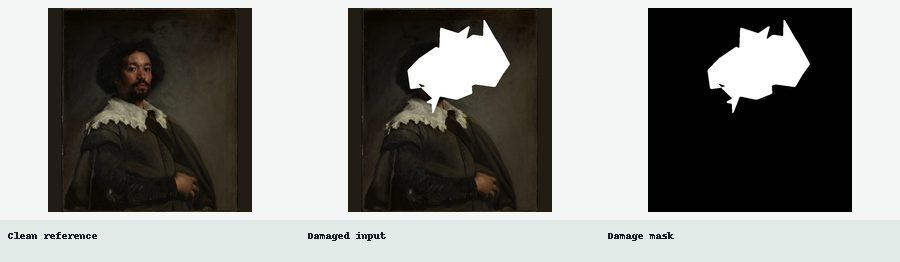
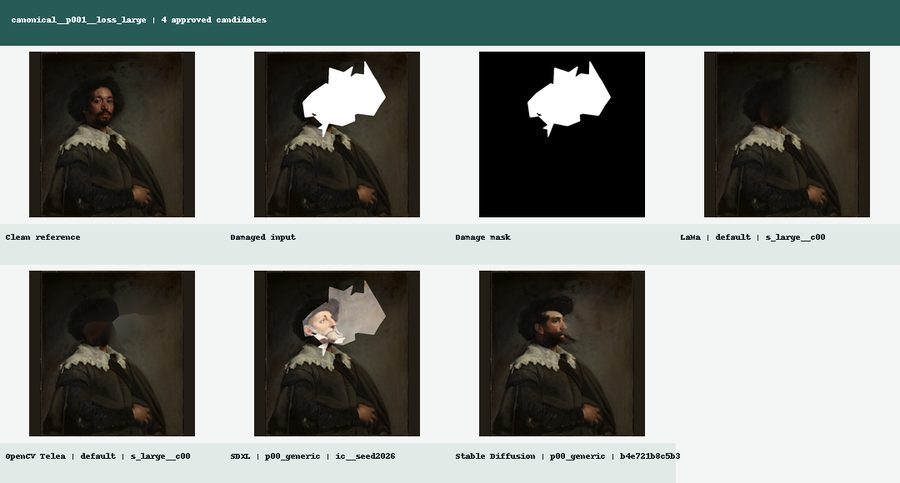
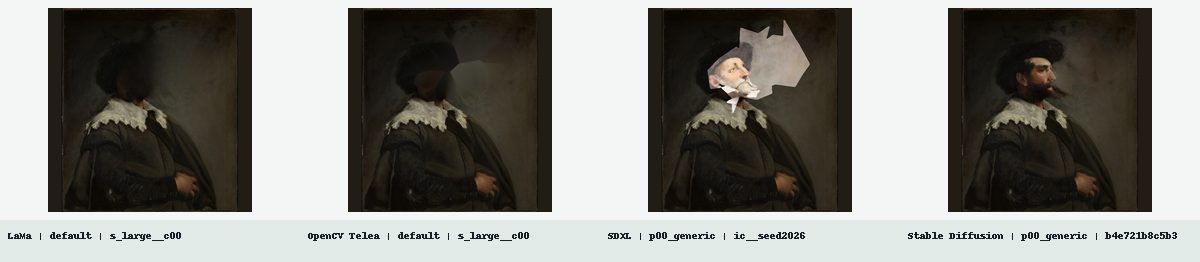
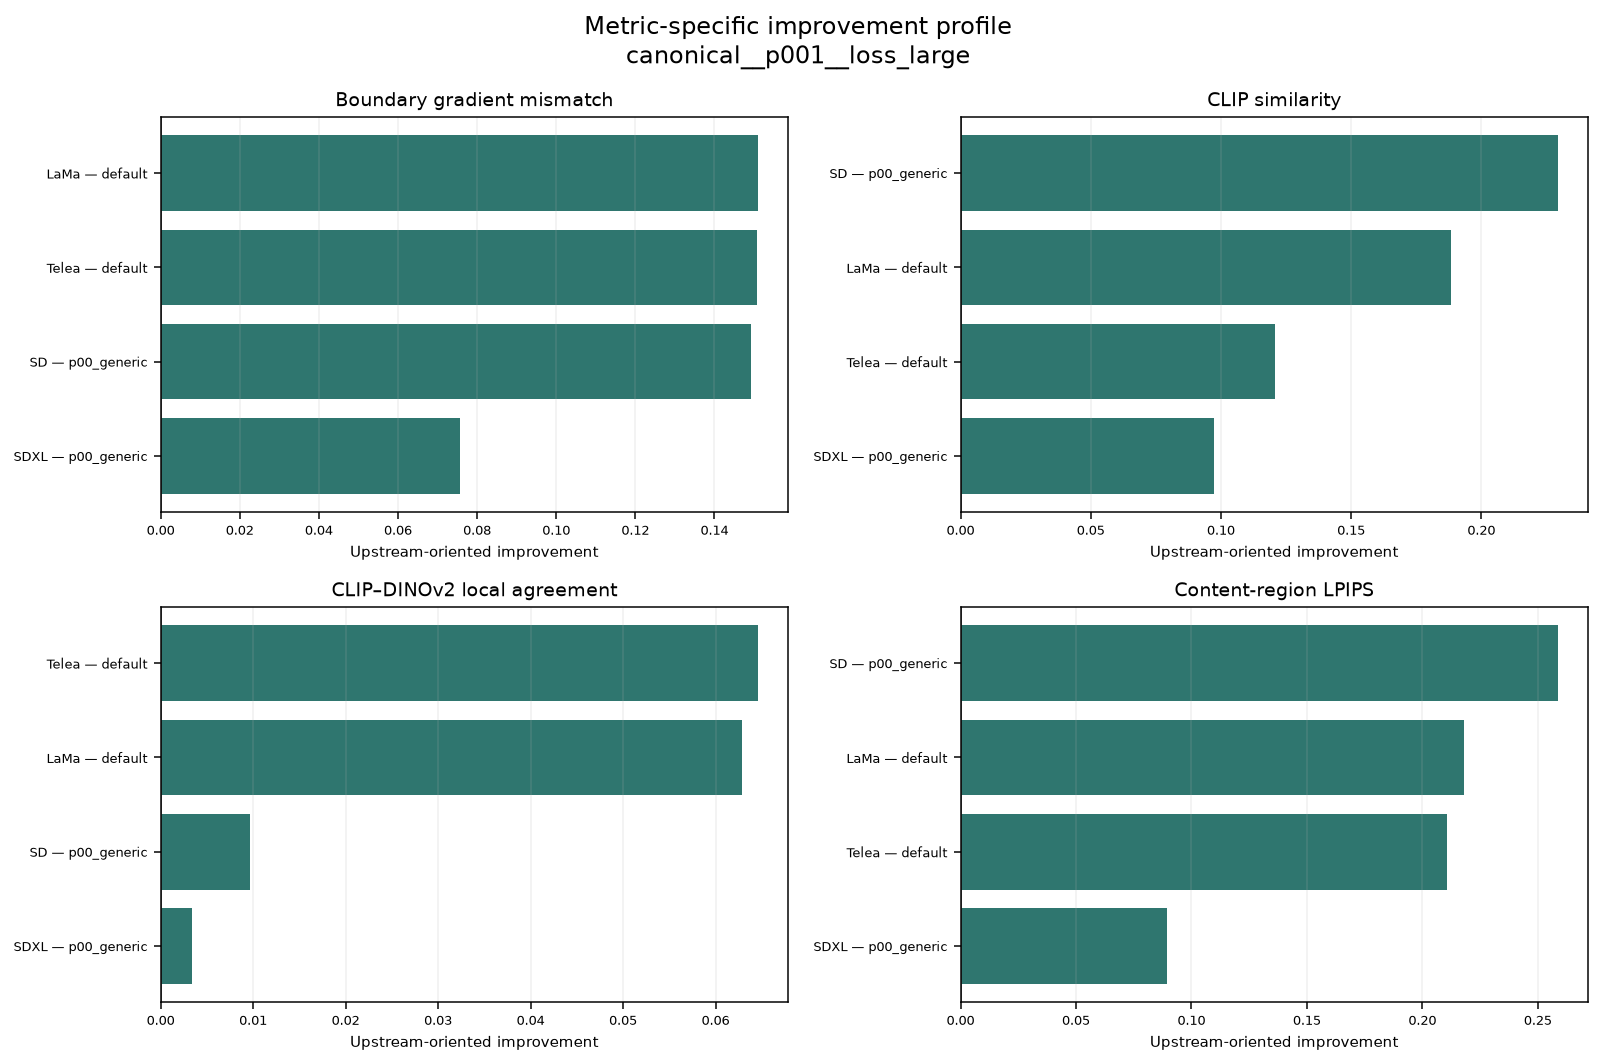
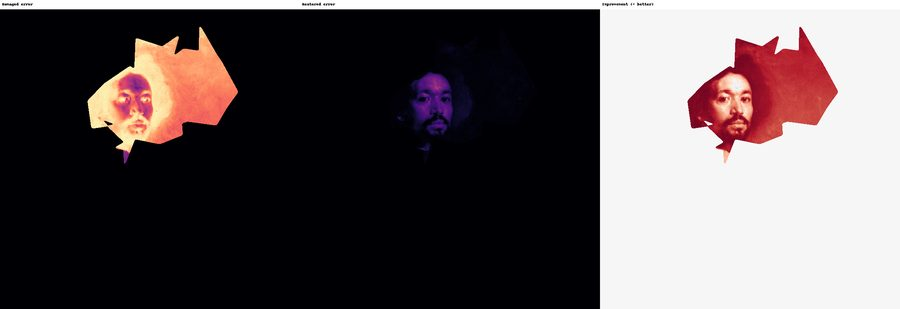
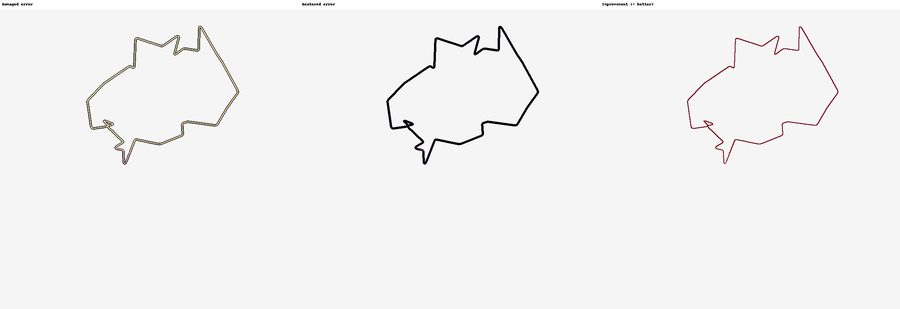
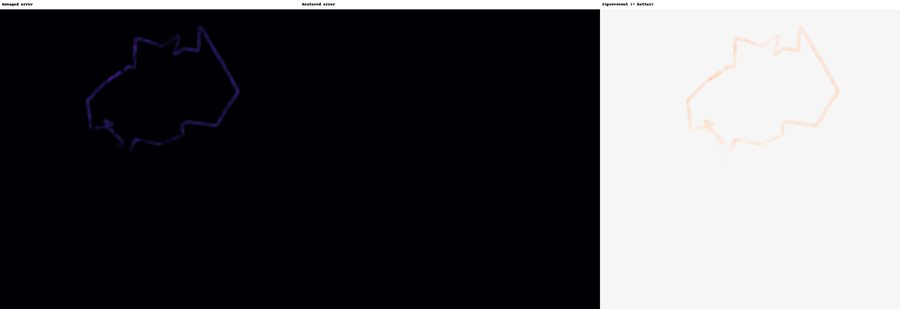
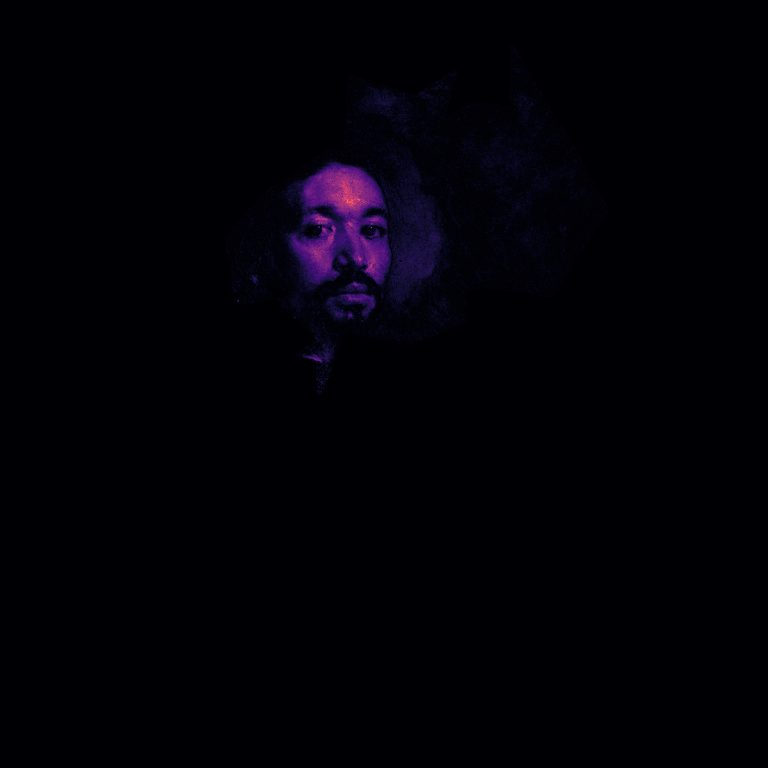
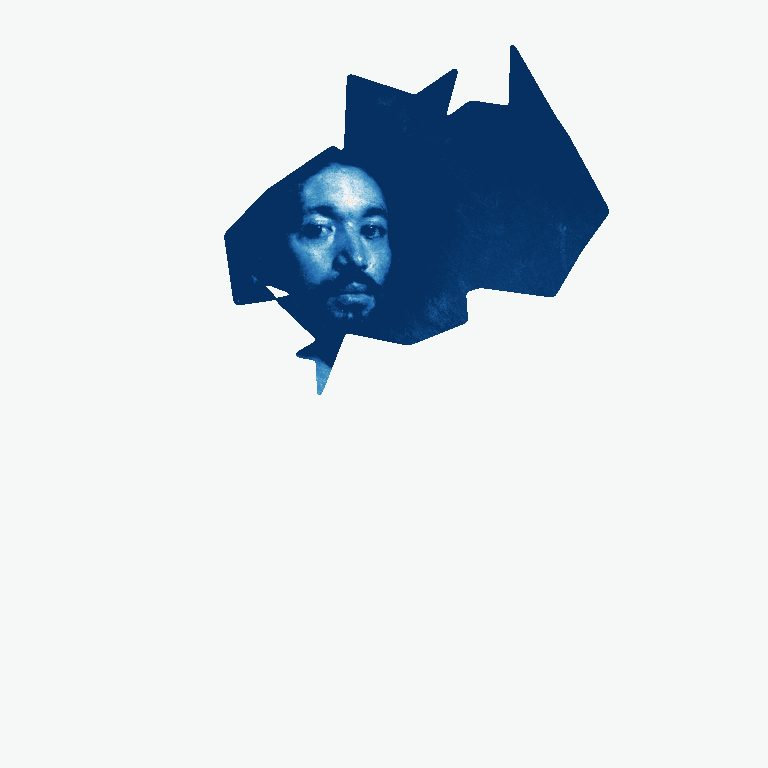
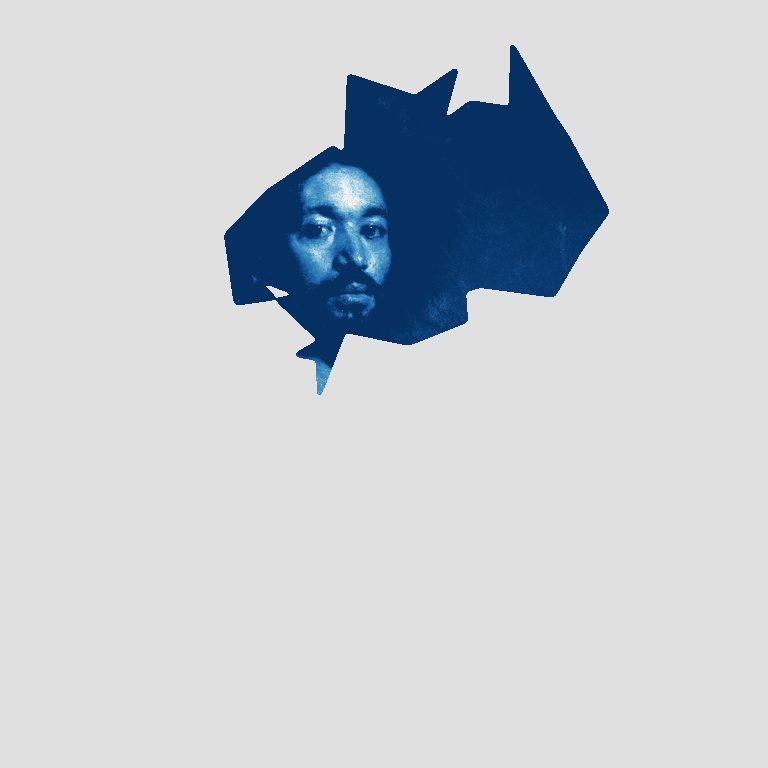
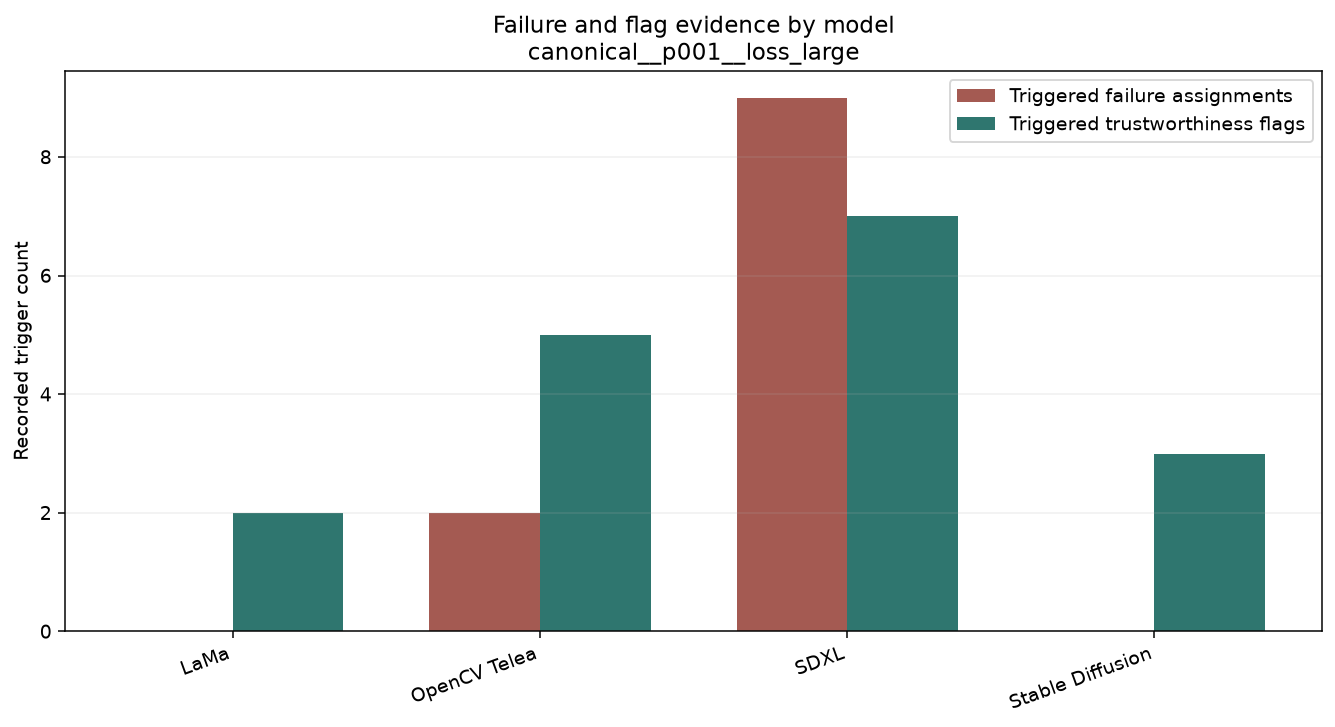

Final-format case-report preview passed.
Preview case: canonical__p001__loss_large
Metric anchor rows: 32
Metric assertions: 8
Embedded images: 11
Embedded logical tiles: 22
External image dependencies: 0
Preview report file written: False


In [42]:
# Restore the clean validation state because the previous preview attempt
# added checks before the prohibited-language check stopped execution.
VALIDATION = ValidationCollector()

for record in BATCH_5_VALIDATION.to_dict(
    orient="records"
):
    VALIDATION.add(
        validation_stage=record["validation_stage"],
        check_id=record["check_id"],
        check_description=record["check_description"],
        severity=record["severity"],
        expected=record["expected"],
        observed=record["observed"],
        passed=bool(record["passed"]),
        details=record["details"],
    )


PREVIEW_CASE_ID = str(
    SELECTED_CASES.loc[
        SELECTED_CASES[
            "selection_lane"
        ].eq("sdxl_partial_evaluation"),
        "case_id",
    ].iloc[0]
)

(
    PREVIEW_CASE_SECTIONS,
    PREVIEW_CASE_METADATA,
) = build_final_case_report_sections(
    PREVIEW_CASE_ID
)

PREVIEW_CASE_REPORT_HTML = render_report_html(
    title=(
        f"Painting Restoration Case Report — "
        f"{PREVIEW_CASE_ID}"
    ),
    subtitle=(
        "Validated final-format preview using canonical evidence"
    ),
    report_kind="case",
    sections=PREVIEW_CASE_SECTIONS,
    config=CONFIG,
)

PREVIEW_REPORT_CHECKS = validate_report_html(
    PREVIEW_CASE_REPORT_HTML,
    report_kind="case",
    config=CONFIG,
)

collect_scoped_helper_checks(
    PREVIEW_REPORT_CHECKS,
    scope="batch_6_final_case_preview",
)

PREVIEW_METADATA_CHECKS = (
    (
        "preview_diagnostic_assets",
        "Preview contains eight diagnostic assets",
        8,
        PREVIEW_CASE_METADATA[
            "diagnostic_asset_count"
        ],
        (
            PREVIEW_CASE_METADATA[
                "diagnostic_asset_count"
            ]
            == 8
        ),
    ),
    (
        "preview_metric_evidence",
        "Preview contains real metric-anchor rows",
        "greater_than_zero",
        PREVIEW_CASE_METADATA[
            "metric_anchor_rows"
        ],
        (
            PREVIEW_CASE_METADATA[
                "metric_anchor_rows"
            ]
            > 0
        ),
    ),
    (
        "preview_embedded_tiles",
        "Preview exceeds the case-report tile minimum",
        int(
            REPORTS["minimum_visuals"][
                "case_report_tiles"
            ]
        ),
        PREVIEW_CASE_METADATA[
            "embedded_tile_count"
        ],
        (
            PREVIEW_CASE_METADATA[
                "embedded_tile_count"
            ]
            >= int(
                REPORTS["minimum_visuals"][
                    "case_report_tiles"
                ]
            )
        ),
    ),
)

for (
    check_id,
    description,
    expected,
    observed,
    passed,
) in PREVIEW_METADATA_CHECKS:
    VALIDATION.add(
        validation_stage=(
            "batch_6_preview_metadata"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=(
            ""
            if passed
            else (
                "Final case-report preview "
                "metadata failed."
            )
        ),
    )

VALIDATION.raise_for_blocking()

display(
    PREVIEW_REPORT_CHECKS[
        [
            "check_name",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

display(
    HTML(PREVIEW_CASE_REPORT_HTML)
)

print("Final-format case-report preview passed.")
print("Preview case:", PREVIEW_CASE_ID)
print(
    "Metric anchor rows:",
    PREVIEW_CASE_METADATA[
        "metric_anchor_rows"
    ],
)
print(
    "Metric assertions:",
    PREVIEW_CASE_METADATA[
        "metric_assertion_count"
    ],
)
print(
    "Embedded images:",
    PREVIEW_CASE_METADATA[
        "embedded_image_count"
    ],
)
print(
    "Embedded logical tiles:",
    PREVIEW_CASE_METADATA[
        "embedded_tile_count"
    ],
)
print("External image dependencies:", 0)
print("Preview report file written:", False)

In [43]:
BATCH_6_VALIDATION = VALIDATION.to_dataframe()
BATCH_6_SUMMARY = VALIDATION.summary()

PREVIEW_SUMMARY = pd.DataFrame(
    [
        {
            key: value
            for key, value
            in PREVIEW_CASE_METADATA.items()
            if key != "source_paths"
        }
    ]
)

display(PREVIEW_SUMMARY)

print("Batch 6 completed.")
print("Final case-report renderer ready:", True)
print(
    "Preview report sections:",
    len(PREVIEW_CASE_SECTIONS),
)
print(
    "Preview source files:",
    len(PREVIEW_CASE_METADATA["source_paths"]),
)
print(
    "Checks added in Batch 6:",
    len(BATCH_6_VALIDATION)
    - len(BATCH_5_VALIDATION),
)
print("Validation summary:", BATCH_6_SUMMARY)
print(
    "Blocking failures:",
    BATCH_6_SUMMARY[
        "blocking_failure_count"
    ],
)
print("Case reports written:", 0)
print("Ready for Batch 7:", BATCH_6_SUMMARY["overall_passed"])

,case_id,painting_id,candidate_count,metric_anchor_rows,metric_assertion_count,path_asset_count,derived_plot_count,diagnostic_asset_count,grid_tile_count,embedded_image_count,embedded_tile_count
0,canonical__p001__loss_large,p001,4,32,8,6,2,8,7,11,22


Batch 6 completed.
Final case-report renderer ready: True
Preview report sections: 13
Preview source files: 14
Checks added in Batch 6: 19
Validation summary: {'check_count': 396, 'passed_count': 396, 'failed_count': 0, 'blocking_failure_count': 0, 'overall_passed': True, 'failed_check_ids': []}
Blocking failures: 0
Case reports written: 0
Ready for Batch 7: True


## Batch 7 — Generate all case reports and canonical case index

This batch generates the 30 detailed self-contained case reports.

For every selected case it:

- rebuilds the report from canonical evidence;
- validates all required sections and language;
- embeds every report visual;
- verifies minimum image and tile density;
- rejects external image dependencies;
- writes the HTML atomically;
- records checksums, source artifacts, embedded-image counts, and provenance.

The batch also persists:

- `data/selected_cases.csv`;
- `data/case_report_index.csv`;
- 30 case reports under `reports/cases/`.

Progress is printed after every ten completed reports.

In [44]:
from restoration_eval.case_painting_reports import (
    CASE_REPORT_INDEX_COLUMNS,
    atomic_write_csv,
    atomic_write_text,
    build_case_report_index_row,
)


# Make the generation cell safely rerunnable after an interrupted attempt.
VALIDATION = ValidationCollector()

for record in BATCH_6_VALIDATION.to_dict(
    orient="records"
):
    VALIDATION.add(
        validation_stage=record["validation_stage"],
        check_id=record["check_id"],
        check_description=record["check_description"],
        severity=record["severity"],
        expected=record["expected"],
        observed=record["observed"],
        passed=bool(record["passed"]),
        details=record["details"],
    )


CASE_REPORT_GENERATED_AT_UTC = (
    datetime.now(timezone.utc)
    .isoformat(timespec="seconds")
    .replace("+00:00", "Z")
)

UPSTREAM_RUN_IDS = {
    notebook_id: str(
        manifest.get("run_id", "")
    )
    for notebook_id, manifest
    in sorted(UPSTREAM_MANIFESTS.items())
}

CASE_REPORT_DIRECTORY = OUTPUT_PATHS[
    "case_reports_dir"
]

CASE_REPORT_INDEX_ROWS = []
CASE_REPORT_METADATA_ROWS = []

for _, selection_row in (
    SELECTED_CASES
    .sort_values("selection_order")
    .iterrows()
):
    selection_order = int(
        selection_row["selection_order"]
    )
    case_id = str(
        selection_row["case_id"]
    )

    sections, metadata = (
        build_final_case_report_sections(
            case_id
        )
    )

    report_html = render_report_html(
        title=(
            f"Painting Restoration Case Report — "
            f"{case_id}"
        ),
        subtitle=(
            "Canonical case evidence, diagnostic visuals, "
            "trustworthiness flags, and review actions"
        ),
        report_kind="case",
        sections=sections,
        config=CONFIG,
    )

    report_checks = validate_report_html(
        report_html,
        report_kind="case",
        config=CONFIG,
    )

    collect_scoped_helper_checks(
        report_checks,
        scope=(
            f"batch_7_case_"
            f"{selection_order:02d}"
        ),
    )

    VALIDATION.raise_for_blocking()

    report_path = (
        CASE_REPORT_DIRECTORY
        / f"{case_id}.html"
    )

    atomic_write_text(
        report_html,
        report_path,
    )

    index_row = build_case_report_index_row(
        report_path,
        project_root=PROJECT_ROOT,
        selection_row=selection_row.to_dict(),
        source_artifact_paths=metadata[
            "source_paths"
        ],
        upstream_run_ids=UPSTREAM_RUN_IDS,
        generated_at_utc=(
            CASE_REPORT_GENERATED_AT_UTC
        ),
    )

    CASE_REPORT_INDEX_ROWS.append(
        index_row
    )

    CASE_REPORT_METADATA_ROWS.append(
        {
            "selection_order": selection_order,
            "selection_lane": str(
                selection_row["selection_lane"]
            ),
            "case_id": case_id,
            "painting_id": str(
                selection_row["painting_id"]
            ),
            "candidate_count": int(
                metadata["candidate_count"]
            ),
            "metric_anchor_rows": int(
                metadata["metric_anchor_rows"]
            ),
            "metric_assertion_count": int(
                metadata[
                    "metric_assertion_count"
                ]
            ),
            "diagnostic_asset_count": int(
                metadata[
                    "diagnostic_asset_count"
                ]
            ),
            "embedded_image_count": int(
                index_row[
                    "embedded_image_count"
                ]
            ),
            "embedded_tile_count": int(
                index_row[
                    "embedded_tile_count"
                ]
            ),
            "section_count": int(
                index_row["section_count"]
            ),
            "size_bytes": int(
                index_row["size_bytes"]
            ),
            "self_contained": bool(
                index_row["self_contained"]
            ),
            "report_path": str(
                index_row["report_path"]
            ),
            "status": str(
                index_row["status"]
            ),
        }
    )

    completed = len(
        CASE_REPORT_INDEX_ROWS
    )

    if (
        completed % PROGRESS_INTERVAL == 0
        or completed
        == int(EXPECTED["case_report_count"])
    ):
        print(
            "Case reports: "
            f"{completed}/"
            f"{EXPECTED['case_report_count']} "
            "generated and validated."
        )

CASE_REPORT_INDEX = (
    pd.DataFrame(
        CASE_REPORT_INDEX_ROWS,
        columns=CASE_REPORT_INDEX_COLUMNS,
    )
    .sort_values("selection_order")
    .reset_index(drop=True)
)

CASE_REPORT_METADATA = (
    pd.DataFrame(
        CASE_REPORT_METADATA_ROWS
    )
    .sort_values("selection_order")
    .reset_index(drop=True)
)

print("All case reports generated.")
print("Case reports:", len(CASE_REPORT_INDEX))
print(
    "Total report size:",
    f"{CASE_REPORT_INDEX['size_bytes'].sum() / (1024 ** 2):,.2f} MiB",
)
print(
    "Minimum embedded images:",
    int(
        CASE_REPORT_INDEX[
            "embedded_image_count"
        ].min()
    ),
)
print(
    "Minimum embedded tiles:",
    int(
        CASE_REPORT_INDEX[
            "embedded_tile_count"
        ].min()
    ),
)

Case reports: 10/30 generated and validated.
Case reports: 20/30 generated and validated.
Case reports: 30/30 generated and validated.
All case reports generated.
Case reports: 30
Total report size: 17.00 MiB
Minimum embedded images: 11
Minimum embedded tiles: 20


In [45]:
CASE_REPORT_FILES = sorted(
    CASE_REPORT_DIRECTORY.glob(
        "*.html"
    )
)

EXPECTED_CASE_REPORT_NAMES = {
    f"{case_id}.html"
    for case_id
    in SELECTED_CASES[
        "case_id"
    ].astype(str)
}

OBSERVED_CASE_REPORT_NAMES = {
    path.name
    for path in CASE_REPORT_FILES
}

CASE_REPORT_TMP_FILES = list(
    CASE_REPORT_DIRECTORY.glob(
        "*.tmp"
    )
)

CASE_REPORT_STRUCTURE_ERRORS = []

for report_path in CASE_REPORT_FILES:
    report_text = report_path.read_text(
        encoding="utf-8"
    )

    section_count = report_text.count(
        'data-section-id="'
    )
    image_count = report_text.count(
        "<img "
    )
    external_image_count = (
        report_text.count('src="outputs/')
        + report_text.count('src="../')
        + report_text.count('src="./')
    )

    if (
        section_count
        != len(REPORTS["case_sections"])
        or image_count
        < int(
            REPORTS["minimum_visuals"][
                "case_report_images"
            ]
        )
        or external_image_count != 0
    ):
        CASE_REPORT_STRUCTURE_ERRORS.append(
            {
                "report": report_path.name,
                "section_count": section_count,
                "image_count": image_count,
                "external_image_count": (
                    external_image_count
                ),
            }
        )

SOFT_CASE_SIZE_LIMIT_BYTES = int(
    float(
        REPORTS[
            "soft_case_report_size_warning_mib"
        ]
    )
    * 1024 ** 2
)

OVERSIZED_CASE_REPORTS = (
    CASE_REPORT_INDEX.loc[
        CASE_REPORT_INDEX[
            "size_bytes"
        ].gt(SOFT_CASE_SIZE_LIMIT_BYTES),
        [
            "case_id",
            "size_bytes",
        ],
    ]
    .copy()
)

CASE_INDEX_CHECKS = (
    (
        "case_report_rows",
        "Case-report index contains exactly 30 rows",
        int(EXPECTED["case_report_index_rows"]),
        len(CASE_REPORT_INDEX),
        (
            len(CASE_REPORT_INDEX)
            == int(
                EXPECTED[
                    "case_report_index_rows"
                ]
            )
        ),
    ),
    (
        "case_report_ids_unique",
        "Case-report identifiers are unique",
        int(EXPECTED["case_report_count"]),
        int(
            CASE_REPORT_INDEX[
                "report_id"
            ].nunique()
        ),
        (
            CASE_REPORT_INDEX[
                "report_id"
            ].nunique()
            == int(EXPECTED["case_report_count"])
        ),
    ),
    (
        "case_report_case_ids_unique",
        "Each selected case has exactly one report",
        int(EXPECTED["case_report_count"]),
        int(
            CASE_REPORT_INDEX[
                "case_id"
            ].nunique()
        ),
        (
            CASE_REPORT_INDEX[
                "case_id"
            ].nunique()
            == int(EXPECTED["case_report_count"])
        ),
    ),
    (
        "case_report_file_count",
        "Exactly 30 physical case reports exist",
        int(EXPECTED["case_report_count"]),
        len(CASE_REPORT_FILES),
        (
            len(CASE_REPORT_FILES)
            == int(EXPECTED["case_report_count"])
        ),
    ),
    (
        "case_report_file_identity",
        "Physical case-report names match selected cases",
        sorted(EXPECTED_CASE_REPORT_NAMES),
        sorted(OBSERVED_CASE_REPORT_NAMES),
        (
            OBSERVED_CASE_REPORT_NAMES
            == EXPECTED_CASE_REPORT_NAMES
        ),
    ),
    (
        "case_report_sections",
        "Every case report contains all approved sections",
        len(REPORTS["case_sections"]),
        sorted(
            CASE_REPORT_INDEX[
                "section_count"
            ].astype(int).unique().tolist()
        ),
        (
            CASE_REPORT_INDEX[
                "section_count"
            ].astype(int)
            .eq(
                len(
                    REPORTS[
                        "case_sections"
                    ]
                )
            )
            .all()
        ),
    ),
    (
        "case_report_image_minimum",
        "Every case report meets the embedded-image minimum",
        int(
            REPORTS["minimum_visuals"][
                "case_report_images"
            ]
        ),
        int(
            CASE_REPORT_INDEX[
                "embedded_image_count"
            ].min()
        ),
        (
            CASE_REPORT_INDEX[
                "embedded_image_count"
            ]
            .astype(int)
            .ge(
                int(
                    REPORTS[
                        "minimum_visuals"
                    ]["case_report_images"]
                )
            )
            .all()
        ),
    ),
    (
        "case_report_tile_minimum",
        "Every case report meets the logical-tile minimum",
        int(
            REPORTS["minimum_visuals"][
                "case_report_tiles"
            ]
        ),
        int(
            CASE_REPORT_INDEX[
                "embedded_tile_count"
            ].min()
        ),
        (
            CASE_REPORT_INDEX[
                "embedded_tile_count"
            ]
            .astype(int)
            .ge(
                int(
                    REPORTS[
                        "minimum_visuals"
                    ]["case_report_tiles"]
                )
            )
            .all()
        ),
    ),
    (
        "case_report_self_contained",
        "Every case report is self-contained",
        int(EXPECTED["case_report_count"]),
        int(
            CASE_REPORT_INDEX[
                "self_contained"
            ].map(truthy).sum()
        ),
        (
            CASE_REPORT_INDEX[
                "self_contained"
            ].map(truthy).all()
        ),
    ),
    (
        "case_report_structure_errors",
        "Physical report inspection finds no structure errors",
        [],
        CASE_REPORT_STRUCTURE_ERRORS,
        not CASE_REPORT_STRUCTURE_ERRORS,
    ),
    (
        "case_report_temporary_files",
        "Case generation leaves no temporary HTML files",
        0,
        len(CASE_REPORT_TMP_FILES),
        len(CASE_REPORT_TMP_FILES) == 0,
    ),
)

for (
    check_id,
    description,
    expected,
    observed,
    passed,
) in CASE_INDEX_CHECKS:
    VALIDATION.add(
        validation_stage="batch_7_case_index",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=(
            ""
            if passed
            else "Case-report index validation failed."
        ),
    )

VALIDATION.add(
    validation_stage="batch_7_case_index",
    check_id="case_report_soft_size_limit",
    check_description=(
        "Case reports remain below the soft size warning"
    ),
    severity="warning",
    expected=0,
    observed=len(
        OVERSIZED_CASE_REPORTS
    ),
    passed=OVERSIZED_CASE_REPORTS.empty,
    details=(
        ""
        if OVERSIZED_CASE_REPORTS.empty
        else OVERSIZED_CASE_REPORTS.to_dict(
            orient="records"
        )
    ),
)

VALIDATION.raise_for_blocking()

atomic_write_csv(
    SELECTED_CASES,
    OUTPUT_PATHS["selected_cases_path"],
)

atomic_write_csv(
    CASE_REPORT_INDEX,
    OUTPUT_PATHS["case_report_index_path"],
)

RELOADED_SELECTED_CASES = pd.read_csv(
    OUTPUT_PATHS["selected_cases_path"],
    low_memory=False,
)

RELOADED_CASE_REPORT_INDEX = pd.read_csv(
    OUTPUT_PATHS["case_report_index_path"],
    low_memory=False,
)

PERSISTENCE_CHECKS = (
    (
        "selected_cases_reload",
        "Persisted selected-case table reloads with 30 rows",
        int(EXPECTED["selected_case_count"]),
        len(RELOADED_SELECTED_CASES),
        (
            len(RELOADED_SELECTED_CASES)
            == int(EXPECTED["selected_case_count"])
        ),
    ),
    (
        "selected_case_ids_reload",
        "Persisted selected-case identifiers match memory",
        sorted(
            SELECTED_CASES[
                "case_id"
            ].astype(str)
        ),
        sorted(
            RELOADED_SELECTED_CASES[
                "case_id"
            ].astype(str)
        ),
        (
            set(
                SELECTED_CASES[
                    "case_id"
                ].astype(str)
            )
            == set(
                RELOADED_SELECTED_CASES[
                    "case_id"
                ].astype(str)
            )
        ),
    ),
    (
        "case_index_reload",
        "Persisted case-report index reloads with 30 rows",
        int(EXPECTED["case_report_index_rows"]),
        len(RELOADED_CASE_REPORT_INDEX),
        (
            len(RELOADED_CASE_REPORT_INDEX)
            == int(
                EXPECTED[
                    "case_report_index_rows"
                ]
            )
        ),
    ),
    (
        "case_index_paths_reload",
        "Persisted report paths match generated reports",
        sorted(
            CASE_REPORT_INDEX[
                "report_path"
            ].astype(str)
        ),
        sorted(
            RELOADED_CASE_REPORT_INDEX[
                "report_path"
            ].astype(str)
        ),
        (
            set(
                CASE_REPORT_INDEX[
                    "report_path"
                ].astype(str)
            )
            == set(
                RELOADED_CASE_REPORT_INDEX[
                    "report_path"
                ].astype(str)
            )
        ),
    ),
)

for (
    check_id,
    description,
    expected,
    observed,
    passed,
) in PERSISTENCE_CHECKS:
    VALIDATION.add(
        validation_stage="batch_7_persistence",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=(
            ""
            if passed
            else "Canonical case-report data failed reload validation."
        ),
    )

VALIDATION.raise_for_blocking()

print("Case-report outputs persisted and reloaded.")
print(
    "Selected-case rows:",
    len(RELOADED_SELECTED_CASES),
)
print(
    "Case-index rows:",
    len(RELOADED_CASE_REPORT_INDEX),
)
print(
    "Oversized report warnings:",
    len(OVERSIZED_CASE_REPORTS),
)
print(
    "Temporary report files:",
    len(CASE_REPORT_TMP_FILES),
)

Case-report outputs persisted and reloaded.
Selected-case rows: 30
Case-index rows: 30
Oversized report warnings: 0
Temporary report files: 0


In [46]:
CASE_REPORT_LANE_PROFILE = (
    CASE_REPORT_INDEX
    .groupby(
        "selection_lane",
        as_index=False,
    )
    .agg(
        report_count=("report_id", "count"),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        candidate_count=(
            "candidate_count",
            "sum",
        ),
        minimum_images=(
            "embedded_image_count",
            "min",
        ),
        minimum_tiles=(
            "embedded_tile_count",
            "min",
        ),
        median_size_mib=(
            "size_bytes",
            lambda values: round(
                float(values.median())
                / (1024 ** 2),
                2,
            ),
        ),
        total_size_mib=(
            "size_bytes",
            lambda values: round(
                float(values.sum())
                / (1024 ** 2),
                2,
            ),
        ),
    )
    .sort_values("selection_lane")
    .reset_index(drop=True)
)

CASE_REPORT_SIZE_PROFILE = (
    CASE_REPORT_INDEX[
        [
            "selection_order",
            "selection_lane",
            "case_id",
            "candidate_count",
            "embedded_image_count",
            "embedded_tile_count",
            "size_bytes",
            "self_contained",
            "status",
        ]
    ]
    .copy()
)

CASE_REPORT_SIZE_PROFILE[
    "size_mib"
] = (
    CASE_REPORT_SIZE_PROFILE[
        "size_bytes"
    ]
    / (1024 ** 2)
).round(2)

BATCH_7_VALIDATION = VALIDATION.to_dataframe()
BATCH_7_SUMMARY = VALIDATION.summary()

display(CASE_REPORT_LANE_PROFILE)
display(CASE_REPORT_SIZE_PROFILE)

print("Batch 7 completed.")
print(
    "Case reports written:",
    len(CASE_REPORT_INDEX),
)
print(
    "Canonical case grids:",
    len(SELECTED_CASE_GRID_MANIFEST),
)
print(
    "Canonical data tables written:",
    2,
)
print(
    "Cumulative physical outputs:",
    (
        len(CASE_REPORT_INDEX)
        + len(SELECTED_CASE_GRID_MANIFEST)
        + 2
    ),
)
print(
    "Checks added in Batch 7:",
    len(BATCH_7_VALIDATION)
    - len(BATCH_6_VALIDATION),
)
print("Validation summary:", BATCH_7_SUMMARY)
print(
    "Blocking failures:",
    BATCH_7_SUMMARY[
        "blocking_failure_count"
    ],
)
print(
    "Warning failures:",
    int(
        (
            BATCH_7_VALIDATION[
                "severity"
            ].eq("warning")
            & ~BATCH_7_VALIDATION[
                "passed"
            ]
        ).sum()
    ),
)
print("Painting reports written:", 0)
print("Ready for Batch 8:", BATCH_7_SUMMARY["overall_passed"])

,selection_lane,report_count,painting_count,candidate_count,minimum_images,minimum_tiles,median_size_mib,total_size_mib
0,category_flagged,5,5,50,11,34,0.68,3.42
1,category_lower_risk,5,5,15,11,20,0.41,2.02
2,extension_representative,3,2,12,11,20,0.43,1.24
3,high_uncertainty,4,2,24,11,26,0.54,2.13
4,metric_disagreement,4,4,36,11,26,0.65,2.50
5,scratch_prompt_sensitivity,4,4,40,11,34,0.79,3.12
6,sdxl_partial_evaluation,3,3,12,11,22,0.50,1.49
7,zero_control,2,2,6,11,20,0.54,1.09


,selection_order,selection_lane,case_id,candidate_count,embedded_image_count,embedded_tile_count,size_bytes,self_contained,status,size_mib
0,1,category_lower_risk,synthetic_degradation__p039__water_stain__mild,3,11,20,456180,True,ok,0.44
1,2,category_lower_risk,synthetic_degradation__p026__dirt_dust__mild,3,11,20,384381,True,ok,0.37
2,3,category_lower_risk,synthetic_degradation__p043__dirt_dust__moderate,3,11,20,432011,True,ok,0.41
3,4,category_lower_risk,synthetic_degradation__p018__partial_transpare...,3,11,20,430147,True,ok,0.41
4,5,category_lower_risk,synthetic_degradation__p001__partial_transpare...,3,11,20,411253,True,ok,0.39
5,6,category_flagged,canonical__p036__scratch_thin,10,11,34,649536,True,ok,0.62
6,7,category_flagged,canonical__p022__scratch_thin,10,11,34,779780,True,ok,0.74
7,8,category_flagged,canonical__p050__scratch_thin,10,11,34,805090,True,ok,0.77
8,9,category_flagged,canonical__p013__scratch_thin,10,11,34,718113,True,ok,0.68
9,10,category_flagged,canonical__p002__scratch_thin,10,11,34,631751,True,ok,0.60


Batch 7 completed.
Case reports written: 30
Canonical case grids: 30
Canonical data tables written: 2
Cumulative physical outputs: 62
Checks added in Batch 7: 496
Validation summary: {'check_count': 892, 'passed_count': 892, 'failed_count': 0, 'blocking_failure_count': 0, 'overall_passed': True, 'failed_check_ids': []}
Blocking failures: 0
Warning failures: 0
Painting reports written: 0
Ready for Batch 8: True


## Batch 8 — Painting-report evidence assembly and populated previews

This batch constructs the final per-painting report renderer and validates two populated in-memory previews:

- one standard painting with five cases;
- one extension painting with 37 cases.

Every painting report preserves the approved eleven-section mock structure and summarizes the complete applicable case and candidate population. The visual case atlas is selected deterministically for presentation only:

- standard paintings show all five cases;
- extension paintings show nine cases selected to cover experiments and damage families;
- each spotlight shows the damaged input, OpenCV Telea, LaMa, and one generic Stable Diffusion candidate;
- SDXL is added where it is available for that spotlight.

Metric families remain separate. No combined quality score or universal model ranking is created.

In [47]:
# Make Batch 8 safely rerunnable after a failed preview attempt.
VALIDATION = ValidationCollector()

for record in BATCH_7_VALIDATION.to_dict(
    orient="records"
):
    VALIDATION.add(
        validation_stage=record["validation_stage"],
        check_id=record["check_id"],
        check_description=record["check_description"],
        severity=record["severity"],
        expected=record["expected"],
        observed=record["observed"],
        passed=bool(record["passed"]),
        details=record["details"],
    )


APPROVED_CANDIDATE_PAINTINGS = (
    CANDIDATE_CATALOG[
        [
            "candidate_id",
            "painting_id",
        ]
    ]
    .drop_duplicates("candidate_id")
    .copy()
)

APPROVED_CANDIDATE_ID_SET = set(
    APPROVED_CANDIDATE_PAINTINGS[
        "candidate_id"
    ].astype(str)
)

PAINTING_METRIC_RECORDS = []

for spec in METRIC_ANCHOR_SPECS:
    frame = INPUT_TABLES[
        spec["evidence_key"]
    ]

    selected = frame.loc[
        frame["candidate_id"]
        .fillna("")
        .astype(str)
        .isin(APPROVED_CANDIDATE_ID_SET)
        & frame["metric_name"]
        .fillna("")
        .astype(str)
        .eq(spec["metric_name"])
        & frame["region_id"]
        .fillna("")
        .astype(str)
        .eq(spec["region_id"])
        & frame["status"]
        .fillna("")
        .astype(str)
        .str.lower()
        .eq("ok")
    ].copy()

    if selected.empty:
        raise ValueError(
            "No approved rows found for painting metric anchor "
            f"{spec['label']}."
        )

    selected["candidate_id"] = (
        selected["candidate_id"]
        .astype(str)
    )

    if "painting_id" in selected.columns:
        selected = selected.drop(
            columns=["painting_id"]
        )

    selected = selected.merge(
        APPROVED_CANDIDATE_PAINTINGS,
        on="candidate_id",
        how="inner",
        validate="many_to_one",
    )

    selected["improvement_value"] = pd.to_numeric(
        selected["improvement_value"],
        errors="coerce",
    )

    selected["restored_value"] = pd.to_numeric(
        selected["restored_value"],
        errors="coerce",
    )

    selected = selected.dropna(
        subset=["improvement_value"]
    )

    grouped = (
        selected
        .groupby(
            [
                "painting_id",
                "model_id",
            ],
            as_index=False,
        )
        .agg(
            case_count=(
                "case_id",
                "nunique",
            ),
            candidate_count=(
                "candidate_id",
                "nunique",
            ),
            restored_value_median=(
                "restored_value",
                "median",
            ),
            improvement_median=(
                "improvement_value",
                "median",
            ),
        )
    )

    for _, row in grouped.iterrows():
        PAINTING_METRIC_RECORDS.append(
            {
                "painting_id": str(
                    row["painting_id"]
                ),
                "metric_label": spec["label"],
                "metric_name": spec["metric_name"],
                "region_id": spec["region_id"],
                "model_id": str(
                    row["model_id"]
                ),
                "case_count": int(
                    row["case_count"]
                ),
                "candidate_count": int(
                    row["candidate_count"]
                ),
                "restored_value_median": float(
                    row["restored_value_median"]
                ),
                "improvement_median": float(
                    row["improvement_median"]
                ),
                "status": "ok",
            }
        )

PAINTING_METRIC_ANCHORS = (
    pd.DataFrame(PAINTING_METRIC_RECORDS)
    .sort_values(
        [
            "painting_id",
            "metric_label",
            "model_id",
        ]
    )
    .reset_index(drop=True)
)

EXPECTED_METRIC_LABELS = sorted(
    spec["label"]
    for spec in METRIC_ANCHOR_SPECS
)

OBSERVED_METRIC_LABELS = sorted(
    PAINTING_METRIC_ANCHORS[
        "metric_label"
    ].unique()
)

PAINTING_METRIC_LABEL_COUNTS = (
    PAINTING_METRIC_ANCHORS
    .groupby("painting_id")[
        "metric_label"
    ]
    .nunique()
)

PAINTING_METRIC_CHECKS = (
    (
        "painting_metric_coverage",
        "Painting metric anchors cover all 50 paintings",
        int(EXPECTED["painting_count"]),
        int(
            PAINTING_METRIC_ANCHORS[
                "painting_id"
            ].nunique()
        ),
        (
            PAINTING_METRIC_ANCHORS[
                "painting_id"
            ].nunique()
            == int(EXPECTED["painting_count"])
        ),
    ),
    (
        "painting_metric_labels",
        "All eight approved metric anchors are retained",
        EXPECTED_METRIC_LABELS,
        OBSERVED_METRIC_LABELS,
        OBSERVED_METRIC_LABELS
        == EXPECTED_METRIC_LABELS,
    ),
    (
        "painting_metric_label_coverage",
        "Every painting contains every approved metric anchor",
        len(EXPECTED_METRIC_LABELS),
        int(
            PAINTING_METRIC_LABEL_COUNTS.min()
        ),
        PAINTING_METRIC_LABEL_COUNTS.eq(
            len(EXPECTED_METRIC_LABELS)
        ).all(),
    ),
    (
        "painting_metric_rows_unique",
        "Painting, metric, and model rows are unique",
        len(PAINTING_METRIC_ANCHORS),
        int(
            PAINTING_METRIC_ANCHORS[
                [
                    "painting_id",
                    "metric_label",
                    "model_id",
                ]
            ]
            .drop_duplicates()
            .shape[0]
        ),
        not PAINTING_METRIC_ANCHORS.duplicated(
            [
                "painting_id",
                "metric_label",
                "model_id",
            ]
        ).any(),
    ),
    (
        "painting_metric_values_finite",
        "Painting metric improvements are finite",
        len(PAINTING_METRIC_ANCHORS),
        int(
            PAINTING_METRIC_ANCHORS[
                "improvement_median"
            ]
            .map(
                lambda value:
                math.isfinite(float(value))
            )
            .sum()
        ),
        PAINTING_METRIC_ANCHORS[
            "improvement_median"
        ]
        .map(
            lambda value:
            math.isfinite(float(value))
        )
        .all(),
    ),
)

for (
    check_id,
    description,
    expected,
    observed,
    passed,
) in PAINTING_METRIC_CHECKS:
    VALIDATION.add(
        validation_stage=(
            "batch_8_painting_metric_assembly"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=(
            ""
            if passed
            else (
                "Painting-level metric presentation "
                "evidence is incomplete."
            )
        ),
    )

VALIDATION.raise_for_blocking()

FAILURE_ASSIGNMENTS_ALL = INPUT_TABLES[
    "failure_assignments_path"
]

TRUSTWORTHINESS_FLAGS_ALL = INPUT_TABLES[
    "trustworthiness_flags_path"
]


def painting_case_table(
    painting_id: str,
) -> pd.DataFrame:
    return (
        CASE_SUMMARY.loc[
            CASE_SUMMARY[
                "painting_id"
            ].eq(painting_id),
            [
                "case_id",
                "experiment_id",
                "degradation_family",
                "severity",
                "candidate_count",
                "model_count",
                "prompt_variant_count",
                "uncertainty_group_count",
                "manual_review_candidate_count",
                "triggered_flag_count",
                "metric_disagreement_count",
                "has_uncertainty",
                "has_sdxl",
                "has_scratch_prompt_pair",
            ],
        ]
        .sort_values(
            [
                "experiment_id",
                "degradation_family",
                "case_id",
            ]
        )
        .reset_index(drop=True)
    )


def painting_model_summary(
    painting_id: str,
) -> pd.DataFrame:
    catalog = (
        CANDIDATE_CATALOG.loc[
            CANDIDATE_CATALOG[
                "painting_id"
            ].eq(painting_id)
        ]
        .copy()
    )

    catalog["_manual_review"] = (
        catalog[
            "manual_review_required"
        ].map(truthy)
    )

    summary = (
        catalog
        .groupby(
            "model_id",
            as_index=False,
        )
        .agg(
            case_count=(
                "case_id",
                "nunique",
            ),
            candidate_count=(
                "candidate_id",
                "nunique",
            ),
            manual_review_candidate_count=(
                "_manual_review",
                "sum",
            ),
        )
    )

    summary[
        "preliminary_inspection_candidate_count"
    ] = (
        summary["candidate_count"]
        - summary[
            "manual_review_candidate_count"
        ]
    )

    summary["manual_review_fraction"] = (
        summary[
            "manual_review_candidate_count"
        ]
        / summary["candidate_count"]
    )

    failure_rows = (
        FAILURE_ASSIGNMENTS_ALL.loc[
            FAILURE_ASSIGNMENTS_ALL[
                "painting_id"
            ].astype(str)
            .eq(painting_id)
            & FAILURE_ASSIGNMENTS_ALL[
                "assignment_status"
            ].astype(str)
            .str.lower()
            .eq("triggered")
        ]
    )

    flag_rows = (
        TRUSTWORTHINESS_FLAGS_ALL.loc[
            TRUSTWORTHINESS_FLAGS_ALL[
                "painting_id"
            ].astype(str)
            .eq(painting_id)
        ]
    )

    triggered_failures = (
        failure_rows
        .groupby("model_id")
        .size()
        .rename(
            "triggered_failure_assignments"
        )
    )

    triggered_flags = (
        flag_rows.loc[
            flag_rows["flag_status"]
            .astype(str)
            .str.lower()
            .eq("triggered")
        ]
        .groupby("model_id")
        .size()
        .rename(
            "triggered_flag_assignments"
        )
    )

    insufficient_flags = (
        flag_rows.loc[
            flag_rows["flag_status"]
            .astype(str)
            .str.lower()
            .eq("insufficient_evidence")
        ]
        .groupby("model_id")
        .size()
        .rename(
            "insufficient_evidence_flags"
        )
    )

    summary = (
        summary
        .merge(
            triggered_failures,
            on="model_id",
            how="left",
        )
        .merge(
            triggered_flags,
            on="model_id",
            how="left",
        )
        .merge(
            insufficient_flags,
            on="model_id",
            how="left",
        )
    )

    count_columns = (
        "triggered_failure_assignments",
        "triggered_flag_assignments",
        "insufficient_evidence_flags",
    )

    for column in count_columns:
        summary[column] = (
            summary[column]
            .fillna(0)
            .astype(int)
        )

    summary["model_name"] = (
        summary["model_id"]
        .map(MODEL_DISPLAY_NAMES)
        .fillna(summary["model_id"])
    )

    return (
        summary
        .sort_values("model_id")
        .reset_index(drop=True)
    )


def painting_metric_rank_table(
    painting_id: str,
) -> pd.DataFrame:
    frame = (
        PAINTING_METRIC_ANCHORS.loc[
            PAINTING_METRIC_ANCHORS[
                "painting_id"
            ].eq(painting_id)
        ]
        .copy()
    )

    records = []

    for metric_label, group in frame.groupby(
        "metric_label",
        sort=False,
    ):
        ordered = (
            group
            .sort_values(
                [
                    "improvement_median",
                    "model_id",
                ],
                ascending=[False, True],
            )
            .reset_index(drop=True)
        )

        best_value = float(
            ordered[
                "improvement_median"
            ].max()
        )

        worst_value = float(
            ordered[
                "improvement_median"
            ].min()
        )

        tolerance = 1e-12

        winners = sorted(
            ordered.loc[
                (
                    ordered[
                        "improvement_median"
                    ]
                    - best_value
                ).abs()
                <= tolerance,
                "model_id",
            ].astype(str)
        )

        worst_models = sorted(
            ordered.loc[
                (
                    ordered[
                        "improvement_median"
                    ]
                    - worst_value
                ).abs()
                <= tolerance,
                "model_id",
            ].astype(str)
        )

        records.append(
            {
                "metric_label": metric_label,
                "region_id": str(
                    ordered.iloc[0][
                        "region_id"
                    ]
                ),
                "model_rank_order": " > ".join(
                    MODEL_DISPLAY_NAMES.get(
                        model_id,
                        model_id,
                    )
                    for model_id
                    in ordered["model_id"]
                ),
                "better_model": " / ".join(
                    MODEL_DISPLAY_NAMES.get(
                        model_id,
                        model_id,
                    )
                    for model_id in winners
                ),
                "better_improvement": best_value,
                "worse_model": " / ".join(
                    MODEL_DISPLAY_NAMES.get(
                        model_id,
                        model_id,
                    )
                    for model_id in worst_models
                ),
                "worse_improvement": worst_value,
                "compared_model_count": len(
                    ordered
                ),
            }
        )

    return (
        pd.DataFrame(records)
        .sort_values("metric_label")
        .reset_index(drop=True)
    )


def painting_condition_summary(
    painting_id: str,
) -> pd.DataFrame:
    cases = painting_case_table(
        painting_id
    )

    summary = (
        cases
        .groupby(
            [
                "experiment_id",
                "degradation_family",
            ],
            as_index=False,
        )
        .agg(
            case_count=(
                "case_id",
                "nunique",
            ),
            candidate_count=(
                "candidate_count",
                "sum",
            ),
            manual_review_candidate_count=(
                "manual_review_candidate_count",
                "sum",
            ),
            flagged_case_count=(
                "triggered_flag_count",
                lambda values:
                int((values > 0).sum()),
            ),
            uncertainty_case_count=(
                "has_uncertainty",
                lambda values:
                int(
                    values.map(truthy).sum()
                ),
            ),
            sdxl_case_count=(
                "has_sdxl",
                lambda values:
                int(
                    values.map(truthy).sum()
                ),
            ),
        )
    )

    summary["manual_review_fraction"] = (
        summary[
            "manual_review_candidate_count"
        ]
        / summary["candidate_count"]
    )

    summary["flagged_case_fraction"] = (
        summary["flagged_case_count"]
        / summary["case_count"]
    )

    return (
        summary
        .sort_values(
            [
                "experiment_id",
                "degradation_family",
            ]
        )
        .reset_index(drop=True)
    )


def painting_stability_summary(
    painting_id: str,
) -> pd.DataFrame:
    cases = painting_case_table(
        painting_id
    )

    return (
        cases
        .groupby(
            "experiment_id",
            as_index=False,
        )
        .agg(
            case_count=(
                "case_id",
                "nunique",
            ),
            uncertainty_case_count=(
                "has_uncertainty",
                lambda values:
                int(
                    values.map(truthy).sum()
                ),
            ),
            scratch_prompt_pair_count=(
                "has_scratch_prompt_pair",
                lambda values:
                int(
                    values.map(truthy).sum()
                ),
            ),
            sdxl_case_count=(
                "has_sdxl",
                lambda values:
                int(
                    values.map(truthy).sum()
                ),
            ),
        )
        .sort_values("experiment_id")
        .reset_index(drop=True)
    )


def painting_failure_tables(
    painting_id: str,
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    list[str],
]:
    failure_rows = (
        FAILURE_ASSIGNMENTS_ALL.loc[
            FAILURE_ASSIGNMENTS_ALL[
                "painting_id"
            ].astype(str)
            .eq(painting_id)
            & FAILURE_ASSIGNMENTS_ALL[
                "assignment_status"
            ].astype(str)
            .str.lower()
            .eq("triggered")
        ]
        .copy()
    )

    flag_rows = (
        TRUSTWORTHINESS_FLAGS_ALL.loc[
            TRUSTWORTHINESS_FLAGS_ALL[
                "painting_id"
            ].astype(str)
            .eq(painting_id)
            & ~TRUSTWORTHINESS_FLAGS_ALL[
                "flag_status"
            ].astype(str)
            .str.lower()
            .isin(
                [
                    "not_triggered",
                    "not_applicable",
                ]
            )
        ]
        .copy()
    )

    if failure_rows.empty:
        failure_summary = pd.DataFrame(
            columns=[
                "category_name",
                "rule_severity",
                "affected_candidate_count",
                "recommended_action",
            ]
        )
    else:
        failure_summary = (
            failure_rows
            .groupby(
                [
                    "category_name",
                    "rule_severity",
                    "recommended_action",
                ],
                as_index=False,
                dropna=False,
            )
            .agg(
                affected_candidate_count=(
                    "candidate_id",
                    "nunique",
                )
            )
            .sort_values(
                [
                    "affected_candidate_count",
                    "category_name",
                ],
                ascending=[False, True],
            )
            .head(12)
            .reset_index(drop=True)
        )

    if flag_rows.empty:
        flag_summary = pd.DataFrame(
            columns=[
                "flag_name",
                "flag_status",
                "flag_severity",
                "affected_candidate_count",
                "recommended_action",
            ]
        )
    else:
        flag_summary = (
            flag_rows
            .groupby(
                [
                    "flag_name",
                    "flag_status",
                    "flag_severity",
                    "recommended_action",
                ],
                as_index=False,
                dropna=False,
            )
            .agg(
                affected_candidate_count=(
                    "candidate_id",
                    "nunique",
                )
            )
            .sort_values(
                [
                    "affected_candidate_count",
                    "flag_name",
                ],
                ascending=[False, True],
            )
            .head(12)
            .reset_index(drop=True)
        )

    actions = sorted(
        {
            str(value).strip()
            for value in pd.concat(
                [
                    failure_rows.get(
                        "recommended_action",
                        pd.Series(
                            dtype="object"
                        ),
                    ),
                    flag_rows.get(
                        "recommended_action",
                        pd.Series(
                            dtype="object"
                        ),
                    ),
                ],
                ignore_index=True,
            )
            if pd.notna(value)
            and str(value).strip()
            and str(value).strip().lower()
            != "nan"
        }
    )

    if not actions:
        actions = [
            (
                "Compare the restored region and boundary "
                "against the clean reference."
            )
        ]

    return (
        failure_summary,
        flag_summary,
        actions,
    )


display(
    PAINTING_METRIC_ANCHORS.head(16)
)

print("Painting-level evidence tables assembled.")
print(
    "Metric-anchor rows:",
    len(PAINTING_METRIC_ANCHORS),
)
print(
    "Covered paintings:",
    PAINTING_METRIC_ANCHORS[
        "painting_id"
    ].nunique(),
)
print(
    "Metric-specific anchors:",
    len(EXPECTED_METRIC_LABELS),
)
print("Combined metric score created:", False)
print("Blocking failures:", len(VALIDATION.blocking_failures))

,painting_id,metric_label,metric_name,region_id,model_id,case_count,candidate_count,restored_value_median,improvement_median,status
0,p001,Boundary gradient mismatch,boundary_gradient_mismatch,boundary_ring,lama,36,36,0.003258,0.145132,ok
1,p001,Boundary gradient mismatch,boundary_gradient_mismatch,boundary_ring,opencv_telea,36,36,0.003592,0.143804,ok
2,p001,Boundary gradient mismatch,boundary_gradient_mismatch,boundary_ring,sdxl_inpainting,2,2,0.072080,0.005091,ok
3,p001,Boundary gradient mismatch,boundary_gradient_mismatch,boundary_ring,stable_diffusion_inpainting,36,43,0.009277,0.135946,ok
4,p001,CLIP similarity,clip_cosine_similarity,content_region,lama,37,37,0.993108,0.097111,ok
5,p001,CLIP similarity,clip_cosine_similarity,content_region,opencv_telea,37,37,0.964340,0.041452,ok
6,p001,CLIP similarity,clip_cosine_similarity,content_region,sdxl_inpainting,2,2,0.715325,-0.102263,ok
7,p001,CLIP similarity,clip_cosine_similarity,content_region,stable_diffusion_inpainting,37,44,0.943195,0.080769,ok
8,p001,CLIP–DINOv2 local agreement,clip_dinov2_local_map_agreement,content_region,lama,37,37,0.825215,-0.007986,ok
9,p001,CLIP–DINOv2 local agreement,clip_dinov2_local_map_agreement,content_region,opencv_telea,37,37,0.854013,0.004219,ok


Painting-level evidence tables assembled.
Metric-anchor rows: 1240
Covered paintings: 50
Metric-specific anchors: 8
Combined metric score created: False
Blocking failures: 0


In [48]:
PAINTING_REPORT_COLORS = {
    "opencv_telea": "#4477AA",
    "lama": "#228833",
    "stable_diffusion_inpainting": "#CC6677",
    "sdxl_inpainting": "#AA4499",
}


def select_painting_spotlight_cases(
    painting_id: str,
) -> pd.DataFrame:
    cases = painting_case_table(
        painting_id
    )

    painting_row = (
        PAINTING_REPORT_POPULATION.loc[
            PAINTING_REPORT_POPULATION[
                "painting_id"
            ].eq(painting_id)
        ]
        .iloc[0]
    )

    is_extension = truthy(
        painting_row[
            "is_extension_painting"
        ]
    )

    if not is_extension:
        return (
            cases
            .sort_values(
                [
                    "experiment_id",
                    "degradation_family",
                    "case_id",
                ]
            )
            .reset_index(drop=True)
        )

    selected_case_ids = []

    for experiment_id in sorted(
        cases["experiment_id"].unique()
    ):
        candidates = cases.loc[
            cases[
                "experiment_id"
            ].eq(experiment_id)
        ].sort_values(
            [
                "degradation_family",
                "case_id",
            ]
        )

        if not candidates.empty:
            selected_case_ids.append(
                str(
                    candidates.iloc[0][
                        "case_id"
                    ]
                )
            )

    for degradation_family in sorted(
        cases[
            "degradation_family"
        ].unique()
    ):
        candidates = cases.loc[
            cases[
                "degradation_family"
            ].eq(degradation_family)
            & ~cases["case_id"].isin(
                selected_case_ids
            )
        ].sort_values(
            [
                "experiment_id",
                "case_id",
            ]
        )

        if not candidates.empty:
            selected_case_ids.append(
                str(
                    candidates.iloc[0][
                        "case_id"
                    ]
                )
            )

        if len(selected_case_ids) >= 9:
            break

    if len(selected_case_ids) < 9:
        remaining = cases.loc[
            ~cases["case_id"].isin(
                selected_case_ids
            )
        ].sort_values(
            [
                "experiment_id",
                "degradation_family",
                "case_id",
            ]
        )

        for case_id in remaining[
            "case_id"
        ].astype(str):
            selected_case_ids.append(
                case_id
            )

            if len(selected_case_ids) >= 9:
                break

    selected_case_ids = (
        selected_case_ids[:9]
    )

    return (
        cases
        .set_index("case_id")
        .loc[selected_case_ids]
        .reset_index()
    )


def select_representative_model_candidate(
    case_candidates: pd.DataFrame,
    model_id: str,
) -> pd.Series:
    candidates = (
        case_candidates.loc[
            case_candidates[
                "model_id"
            ].eq(model_id)
        ]
        .copy()
    )

    if candidates.empty:
        raise ValueError(
            f"No {model_id} candidate is available for "
            f"{case_candidates.iloc[0]['case_id']}."
        )

    prompt_text = (
        candidates[
            "prompt_variant_id"
        ]
        .fillna("")
        .astype(str)
        .str.lower()
    )

    candidates["_generic_prompt_rank"] = (
        ~prompt_text.str.contains(
            "generic",
            regex=False,
        )
    ).astype(int)

    return (
        candidates
        .sort_values(
            [
                "_generic_prompt_rank",
                "prompt_variant_id",
                "candidate_id",
            ]
        )
        .iloc[0]
    )


def painting_atlas_items(
    painting_id: str,
) -> tuple[
    list[tuple[Path, str]],
    pd.DataFrame,
    list[str],
]:
    spotlight_cases = (
        select_painting_spotlight_cases(
            painting_id
        )
    )

    items = []
    source_paths = []

    core_models = (
        "opencv_telea",
        "lama",
        "stable_diffusion_inpainting",
    )

    for _, case_row in (
        spotlight_cases.iterrows()
    ):
        case_id = str(
            case_row["case_id"]
        )

        case_candidates = (
            CANDIDATE_CATALOG.loc[
                CANDIDATE_CATALOG[
                    "case_id"
                ].eq(case_id)
            ]
            .copy()
        )

        if case_candidates.empty:
            raise ValueError(
                f"No approved candidates for {case_id}."
            )

        first = case_candidates.iloc[0]

        short_case_label = (
            f"{case_row['degradation_family']} | "
            f"{case_id[-16:]}"
        )

        damaged_relative = str(
            first["damaged_path"]
        )

        items.append(
            (
                resolve_repository_file(
                    damaged_relative
                ),
                f"{short_case_label} | damaged",
            )
        )

        source_paths.append(
            damaged_relative
        )

        for model_id in core_models:
            candidate = (
                select_representative_model_candidate(
                    case_candidates,
                    model_id,
                )
            )

            restored_relative = str(
                candidate[
                    "restored_path"
                ]
            )

            items.append(
                (
                    resolve_repository_file(
                        restored_relative
                    ),
                    (
                        f"{short_case_label} | "
                        f"{MODEL_DISPLAY_NAMES[model_id]}"
                    ),
                )
            )

            source_paths.append(
                restored_relative
            )

        sdxl_candidates = (
            case_candidates.loc[
                case_candidates[
                    "model_id"
                ].eq("sdxl_inpainting")
            ]
        )

        if not sdxl_candidates.empty:
            sdxl_candidate = (
                sdxl_candidates
                .sort_values("candidate_id")
                .iloc[0]
            )

            sdxl_relative = str(
                sdxl_candidate[
                    "restored_path"
                ]
            )

            items.append(
                (
                    resolve_repository_file(
                        sdxl_relative
                    ),
                    (
                        f"{short_case_label} | "
                        "SDXL"
                    ),
                )
            )

            source_paths.append(
                sdxl_relative
            )

    return (
        items,
        spotlight_cases,
        sorted(set(source_paths)),
    )


def painting_condition_plot_uri(
    condition_table: pd.DataFrame,
    *,
    painting_id: str,
) -> str:
    labels = [
        (
            f"{row.experiment_id}\n"
            f"{row.degradation_family}"
        )
        for row in condition_table.itertuples()
    ]

    positions = list(
        range(len(condition_table))
    )

    figure, axes = plt.subplots(
        2,
        1,
        figsize=(
            max(
                10,
                len(condition_table) * 0.75,
            ),
            7,
        ),
        sharex=True,
        constrained_layout=True,
    )

    axes[0].bar(
        positions,
        condition_table[
            "candidate_count"
        ],
        color="#4477AA",
        label="Approved candidates",
    )

    axes[0].bar(
        positions,
        condition_table[
            "manual_review_candidate_count"
        ],
        color="#CC6677",
        label="Manual-review candidates",
    )

    axes[0].set_ylabel(
        "Candidate count"
    )

    axes[0].legend(
        frameon=False
    )

    axes[0].set_title(
        f"{painting_id}: damage-condition coverage"
    )

    width = 0.38

    axes[1].bar(
        [
            value - width / 2
            for value in positions
        ],
        (
            condition_table[
                "manual_review_fraction"
            ]
            * 100
        ),
        width=width,
        color="#CC6677",
        label="Manual-review candidates",
    )

    axes[1].bar(
        [
            value + width / 2
            for value in positions
        ],
        (
            condition_table[
                "flagged_case_fraction"
            ]
            * 100
        ),
        width=width,
        color="#DDCC77",
        label="Cases with triggered flags",
    )

    axes[1].set_ylabel(
        "Descriptive share (%)"
    )

    axes[1].set_xticks(
        positions,
        labels,
        rotation=40,
        ha="right",
    )

    axes[1].legend(
        frameon=False
    )

    return figure_to_data_uri(
        figure,
        dpi=125,
    )


def painting_model_plot_uri(
    model_table: pd.DataFrame,
    *,
    painting_id: str,
) -> str:
    labels = (
        model_table[
            "model_name"
        ].tolist()
    )

    positions = list(
        range(len(model_table))
    )

    colors = [
        PAINTING_REPORT_COLORS.get(
            model_id,
            "#777777",
        )
        for model_id
        in model_table["model_id"]
    ]

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4.2),
        constrained_layout=True,
    )

    axes[0].bar(
        positions,
        model_table[
            "candidate_count"
        ],
        color=colors,
    )

    axes[0].set_xticks(
        positions,
        labels,
        rotation=25,
        ha="right",
    )

    axes[0].set_ylabel(
        "Approved candidates"
    )

    axes[0].set_title(
        "Evaluated coverage"
    )

    axes[1].bar(
        positions,
        (
            model_table[
                "manual_review_fraction"
            ]
            * 100
        ),
        color=colors,
    )

    axes[1].set_xticks(
        positions,
        labels,
        rotation=25,
        ha="right",
    )

    axes[1].set_ylabel(
        "Manual-review candidates (%)"
    )

    axes[1].set_title(
        "Canonical review burden"
    )

    figure.suptitle(
        f"{painting_id}: model coverage and review profile"
    )

    return figure_to_data_uri(
        figure,
        dpi=130,
    )


def painting_metric_plot_uri(
    painting_id: str,
) -> str:
    frame = (
        PAINTING_METRIC_ANCHORS.loc[
            PAINTING_METRIC_ANCHORS[
                "painting_id"
            ].eq(painting_id)
        ]
        .copy()
    )

    figure, axes = plt.subplots(
        2,
        4,
        figsize=(15, 7.5),
        constrained_layout=True,
    )

    for axis, spec in zip(
        axes.flat,
        METRIC_ANCHOR_SPECS,
    ):
        metric_rows = (
            frame.loc[
                frame[
                    "metric_label"
                ].eq(spec["label"])
            ]
            .sort_values("model_id")
        )

        labels = [
            MODEL_DISPLAY_NAMES.get(
                model_id,
                model_id,
            )
            for model_id
            in metric_rows["model_id"]
        ]

        colors = [
            PAINTING_REPORT_COLORS.get(
                model_id,
                "#777777",
            )
            for model_id
            in metric_rows["model_id"]
        ]

        axis.bar(
            list(range(len(metric_rows))),
            metric_rows[
                "improvement_median"
            ],
            color=colors,
        )

        axis.axhline(
            0,
            color="#555555",
            linewidth=0.8,
        )

        axis.set_xticks(
            list(range(len(metric_rows))),
            labels,
            rotation=35,
            ha="right",
            fontsize=8,
        )

        axis.set_title(
            spec["label"],
            fontsize=10,
        )

        axis.set_ylabel(
            "Median improvement"
        )

    figure.suptitle(
        (
            f"{painting_id}: independent "
            "metric-specific improvement profiles"
        ),
        fontsize=14,
    )

    return figure_to_data_uri(
        figure,
        dpi=130,
    )


def painting_stability_plot_uri(
    stability_table: pd.DataFrame,
    *,
    painting_id: str,
) -> str:
    labels = (
        stability_table[
            "experiment_id"
        ].tolist()
    )

    positions = list(
        range(len(stability_table))
    )

    width = 0.2

    series = (
        (
            "case_count",
            "All cases",
            "#4477AA",
            -1.5,
        ),
        (
            "uncertainty_case_count",
            "Repeated-seed uncertainty",
            "#228833",
            -0.5,
        ),
        (
            "scratch_prompt_pair_count",
            "Scratch prompt pairs",
            "#CC6677",
            0.5,
        ),
        (
            "sdxl_case_count",
            "SDXL evaluated",
            "#AA4499",
            1.5,
        ),
    )

    figure, axis = plt.subplots(
        figsize=(11, 4.8),
        constrained_layout=True,
    )

    for (
        column,
        label,
        color,
        offset,
    ) in series:
        axis.bar(
            [
                value + offset * width
                for value in positions
            ],
            stability_table[column],
            width=width,
            label=label,
            color=color,
        )

    axis.set_xticks(
        positions,
        labels,
        rotation=25,
        ha="right",
    )

    axis.set_ylabel(
        "Case count"
    )

    axis.set_title(
        f"{painting_id}: applicability of stability evidence"
    )

    axis.legend(
        frameon=False,
        ncol=2,
    )

    return figure_to_data_uri(
        figure,
        dpi=130,
    )


STANDARD_SPOTLIGHT_COUNTS = []
EXTENSION_SPOTLIGHT_COUNTS = []

for _, row in (
    PAINTING_REPORT_POPULATION.iterrows()
):
    spotlight_count = len(
        select_painting_spotlight_cases(
            str(row["painting_id"])
        )
    )

    if truthy(
        row[
            "is_extension_painting"
        ]
    ):
        EXTENSION_SPOTLIGHT_COUNTS.append(
            spotlight_count
        )
    else:
        STANDARD_SPOTLIGHT_COUNTS.append(
            spotlight_count
        )

SPOTLIGHT_CHECKS = (
    (
        "standard_spotlight_count",
        "Every standard painting shows all five cases",
        [5],
        sorted(
            set(
                STANDARD_SPOTLIGHT_COUNTS
            )
        ),
        set(
            STANDARD_SPOTLIGHT_COUNTS
        ) == {5},
    ),
    (
        "extension_spotlight_count",
        "Every extension painting shows nine deterministic cases",
        [9],
        sorted(
            set(
                EXTENSION_SPOTLIGHT_COUNTS
            )
        ),
        set(
            EXTENSION_SPOTLIGHT_COUNTS
        ) == {9},
    ),
)

for (
    check_id,
    description,
    expected,
    observed,
    passed,
) in SPOTLIGHT_CHECKS:
    VALIDATION.add(
        validation_stage=(
            "batch_8_spotlight_selection"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=(
            ""
            if passed
            else (
                "Painting spotlight selection "
                "changed."
            )
        ),
    )

VALIDATION.raise_for_blocking()

print("Painting visual utilities initialized.")
print(
    "Standard spotlight cases:",
    sorted(set(STANDARD_SPOTLIGHT_COUNTS)),
)
print(
    "Extension spotlight cases:",
    sorted(set(EXTENSION_SPOTLIGHT_COUNTS)),
)
print("Persistent images created:", 0)
print("Report-only plots per painting:", 4)

Painting visual utilities initialized.
Standard spotlight cases: [5]
Extension spotlight cases: [9]
Persistent images created: 0
Report-only plots per painting: 4


In [49]:
def report_display_text(
    value,
    *,
    default: str = "Not documented",
) -> str:
    if value is None:
        return default

    if not isinstance(
        value,
        (list, tuple, dict, set),
    ) and pd.isna(value):
        return default

    text = str(value).strip()

    if not text or text.lower() == "nan":
        return default

    return text


def painting_model_assertion(
    model_table: pd.DataFrame,
) -> str:
    ordered = (
        model_table
        .sort_values(
            [
                "manual_review_fraction",
                "model_name",
            ]
        )
        .reset_index(drop=True)
    )

    better = ordered.iloc[0]
    worse = ordered.iloc[-1]

    better_fraction = float(
        better[
            "manual_review_fraction"
        ]
    )

    worse_fraction = float(
        worse[
            "manual_review_fraction"
        ]
    )

    if (
        worse_fraction
        - better_fraction
        > 1e-12
    ):
        comparison = (
            f"{better['model_name']} has the better "
            "preliminary-review profile because "
            f"{better_fraction:.1%} of its candidates require "
            "manual review. "
            f"{worse['model_name']} has the worse profile at "
            f"{worse_fraction:.1%}."
        )
    else:
        comparison = (
            "The evaluated models have the same manual-review "
            "fraction, so this comparison is inconclusive."
        )

    return (
        comparison
        + " This is a descriptive flag comparison, not an "
        "overall restoration-quality ranking."
    )


def painting_metric_assertion(
    metric_rank_table: pd.DataFrame,
) -> str:
    if metric_rank_table.empty:
        return (
            "Metric-specific comparison is inconclusive "
            "because no configured anchor is available."
        )

    winner_counts = (
        metric_rank_table[
            "better_model"
        ]
        .value_counts()
    )

    leading_model = str(
        winner_counts.index[0]
    )

    leading_count = int(
        winner_counts.iloc[0]
    )

    unique_winners = int(
        metric_rank_table[
            "better_model"
        ].nunique()
    )

    if unique_winners == 1:
        agreement_text = (
            f"{leading_model} has the better median "
            f"improvement on all {len(metric_rank_table)} "
            "configured metric anchors."
        )
    else:
        agreement_text = (
            f"{leading_model} has the better median "
            f"improvement on {leading_count} of "
            f"{len(metric_rank_table)} anchors, while other "
            "metrics favour a different model."
        )

    return (
        agreement_text
        + " A single overall winner remains inconclusive "
        "because the anchors use different scales, regions, "
        "and evidence families."
    )


def painting_condition_assertion(
    condition_table: pd.DataFrame,
) -> str:
    ordered = (
        condition_table
        .sort_values(
            [
                "manual_review_fraction",
                "experiment_id",
                "degradation_family",
            ]
        )
        .reset_index(drop=True)
    )

    better = ordered.iloc[0]
    worse = ordered.iloc[-1]

    return (
        f"{better['degradation_family']} in "
        f"{better['experiment_id']} has the better "
        "manual-review profile at "
        f"{float(better['manual_review_fraction']):.1%}. "
        f"{worse['degradation_family']} in "
        f"{worse['experiment_id']} has the worse profile at "
        f"{float(worse['manual_review_fraction']):.1%}. "
        "These percentages describe candidate-level flags; "
        "repeated diffusion seeds are not independent paintings."
    )


def build_final_painting_report_sections(
    painting_id: str,
) -> tuple[dict[str, str], dict]:
    population_rows = (
        PAINTING_REPORT_POPULATION.loc[
            PAINTING_REPORT_POPULATION[
                "painting_id"
            ].eq(painting_id)
        ]
    )

    if len(population_rows) != 1:
        raise ValueError(
            f"Expected one painting summary for {painting_id}; "
            f"found {len(population_rows)}."
        )

    painting_row = (
        population_rows.iloc[0]
    )

    is_extension = truthy(
        painting_row[
            "is_extension_painting"
        ]
    )

    case_table = painting_case_table(
        painting_id
    )

    model_table = painting_model_summary(
        painting_id
    )

    metric_rank_table = (
        painting_metric_rank_table(
            painting_id
        )
    )

    condition_table = (
        painting_condition_summary(
            painting_id
        )
    )

    stability_table = (
        painting_stability_summary(
            painting_id
        )
    )

    (
        failure_summary,
        flag_summary,
        review_actions,
    ) = painting_failure_tables(
        painting_id
    )

    (
        atlas_items,
        spotlight_cases,
        atlas_source_paths,
    ) = painting_atlas_items(
        painting_id
    )

    painting_candidates = (
        CANDIDATE_CATALOG.loc[
            CANDIDATE_CATALOG[
                "painting_id"
            ].eq(painting_id)
        ]
        .sort_values(
            [
                "case_id",
                "model_id",
                "candidate_id",
            ]
        )
        .reset_index(drop=True)
    )

    if painting_candidates.empty:
        raise ValueError(
            f"No approved candidates for {painting_id}."
        )

    first_candidate = (
        painting_candidates.iloc[0]
    )

    clean_relative_path = str(
        first_candidate[
            "clean_path"
        ]
    )

    clean_path = resolve_repository_file(
        clean_relative_path
    )

    clean_visual = visual_html(
        image_to_data_uri(
            clean_path,
            max_dimension=int(
                REPORTS[
                    "image_max_dimension"
                ]
            ),
            quality=int(
                REPORTS[
                    "photographic_quality"
                ]
            ),
            image_format=REPORTS[
                "photographic_format"
            ],
        ),
        alt=(
            f"Clean reference for painting "
            f"{painting_id}"
        ),
        caption=(
            "Canonical clean reference used by the "
            "evaluated restoration cases."
        ),
        report_role="painting_clean_reference",
        tile_count=1,
    )

    atlas_visual = visual_html(
        contact_sheet_data_uri(
            atlas_items,
            columns=4,
            quality=int(
                REPORTS[
                    "photographic_quality"
                ]
            ),
        ),
        alt=(
            f"Deterministic restoration spotlight "
            f"atlas for {painting_id}"
        ),
        caption=(
            "Deterministic presentation atlas. Standard "
            "paintings include every case; extension paintings "
            "include nine cases selected for experiment and "
            "damage-family coverage. Each row retains model labels."
        ),
        report_role="painting_case_spotlight_atlas",
        tile_count=len(atlas_items),
    )

    condition_visual = visual_html(
        painting_condition_plot_uri(
            condition_table,
            painting_id=painting_id,
        ),
        alt=(
            f"Damage-condition profile for "
            f"{painting_id}"
        ),
        caption=(
            "Approved case and candidate coverage with "
            "manual-review and triggered-flag shares. "
            "The shares are descriptive."
        ),
        report_role="painting_condition_plot",
        tile_count=1,
    )

    model_visual = visual_html(
        painting_model_plot_uri(
            model_table,
            painting_id=painting_id,
        ),
        alt=(
            f"Model coverage and review profile "
            f"for {painting_id}"
        ),
        caption=(
            "Candidate coverage and canonical manual-review "
            "burden by model. Different candidate counts are "
            "shown rather than hidden."
        ),
        report_role="painting_model_summary_plot",
        tile_count=1,
    )

    metric_visual = visual_html(
        painting_metric_plot_uri(
            painting_id
        ),
        alt=(
            f"Independent metric improvement profiles "
            f"for {painting_id}"
        ),
        caption=(
            "Eight independent metric panels. Their values "
            "are not normalized, averaged, or combined."
        ),
        report_role="painting_metric_profile_plot",
        tile_count=1,
    )

    stability_visual = visual_html(
        painting_stability_plot_uri(
            stability_table,
            painting_id=painting_id,
        ),
        alt=(
            f"Stability-evidence applicability "
            f"for {painting_id}"
        ),
        caption=(
            "Counts of cases with repeated-seed uncertainty, "
            "paired scratch prompts, and SDXL coverage. Missing "
            "coverage is not replaced by artificial values."
        ),
        report_role="painting_stability_plot",
        tile_count=1,
    )

    case_display = case_table.copy()

    for column in (
        "has_uncertainty",
        "has_sdxl",
        "has_scratch_prompt_pair",
    ):
        case_display[column] = (
            case_display[column]
            .map(truthy)
            .map(
                {
                    True: "yes",
                    False: "no",
                }
            )
        )

    model_display = model_table[
        [
            "model_name",
            "case_count",
            "candidate_count",
            "preliminary_inspection_candidate_count",
            "manual_review_candidate_count",
            "manual_review_fraction",
            "triggered_failure_assignments",
            "triggered_flag_assignments",
            "insufficient_evidence_flags",
        ]
    ].copy()

    model_display[
        "manual_review_fraction"
    ] = (
        model_display[
            "manual_review_fraction"
        ]
        .map(
            lambda value:
            f"{float(value):.1%}"
        )
    )

    metric_display = (
        metric_rank_table.copy()
    )

    for column in (
        "better_improvement",
        "worse_improvement",
    ):
        metric_display[column] = (
            metric_display[column]
            .map(
                lambda value:
                f"{float(value):.4f}"
            )
        )

    condition_display = (
        condition_table.copy()
    )

    condition_display[
        "manual_review_fraction"
    ] = (
        condition_display[
            "manual_review_fraction"
        ]
        .map(
            lambda value:
            f"{float(value):.1%}"
        )
    )

    condition_display[
        "flagged_case_fraction"
    ] = (
        condition_display[
            "flagged_case_fraction"
        ]
        .map(
            lambda value:
            f"{float(value):.1%}"
        )
    )

    detailed_selection = (
        SELECTED_CASES[
            [
                "case_id",
                "selection_lane",
                "selection_reason",
            ]
        ]
        .copy()
    )

    spotlight_display = (
        spotlight_cases
        .merge(
            detailed_selection,
            on="case_id",
            how="left",
            validate="one_to_one",
        )
    )

    spotlight_display[
        "detailed_case_report"
    ] = (
        spotlight_display[
            "selection_lane"
        ]
        .notna()
        .map(
            {
                True: "available",
                False: "not selected",
            }
        )
    )

    spotlight_display[
        "selection_lane"
    ] = (
        spotlight_display[
            "selection_lane"
        ]
        .fillna(
            "painting-atlas coverage"
        )
    )

    spotlight_display = (
        spotlight_display[
            [
                "case_id",
                "experiment_id",
                "degradation_family",
                "candidate_count",
                "has_uncertainty",
                "has_sdxl",
                "selection_lane",
                "detailed_case_report",
            ]
        ]
    )

    model_assertion = (
        painting_model_assertion(
            model_table
        )
    )

    metric_assertion = (
        painting_metric_assertion(
            metric_rank_table
        )
    )

    condition_assertion = (
        painting_condition_assertion(
            condition_table
        )
    )

    review_action_html = (
        "<ul>"
        + "".join(
            (
                "<li>"
                f"{html_module.escape(action)}"
                "</li>"
            )
            for action
            in review_actions[:10]
        )
        + "</ul>"
    )

    sections = {
        "executive-summary": f"""
<p>
This report covers all {int(painting_row["case_count"])} approved
cases and {int(painting_row["candidate_count"])} approved restoration
candidates for <strong>{html_module.escape(painting_id)}</strong>.
It includes {int(painting_row["experiment_count"])} experiments,
{int(painting_row["degradation_count"])} damage families, and
{int(painting_row["model_count"])} evaluated models.
</p>
<div class="conclusion">
<strong>Direct conclusion:</strong>
{html_module.escape(model_assertion)}
Metric-specific results can identify a better and worse model for
one measure, but the painting-wide ordering remains inconclusive.
The evidence supports human review rather than automatic acceptance.
</div>
<p>{REPORTS["mandatory_statement"]}</p>
""",
        "painting-identity": (
            f"""
<table>
<tr><th>Field</th><th>Validated value</th></tr>
<tr><td>Painting ID</td><td>{html_module.escape(painting_id)}</td></tr>
<tr><td>Title</td><td>{html_module.escape(report_display_text(painting_row["title"]))}</td></tr>
<tr><td>Artist</td><td>{html_module.escape(report_display_text(painting_row["artist"]))}</td></tr>
<tr><td>Category</td><td>{html_module.escape(report_display_text(painting_row["category"]))}</td></tr>
<tr><td>Style or period</td><td>{html_module.escape(report_display_text(painting_row["style_or_period"]))}</td></tr>
<tr><td>Metadata completeness</td><td>{html_module.escape(report_display_text(painting_row["metadata_completeness_pct"]))}%</td></tr>
<tr><td>Extension painting</td><td>{"yes" if is_extension else "no"}</td></tr>
</table>
"""
            + clean_visual
        ),
        "coverage-applicability": (
            "<p>"
            "The case table below is complete rather than "
            "restricted to the visual spotlights. SDXL and "
            "repeated-seed uncertainty are shown only where "
            "their upstream contracts apply."
            "</p>"
            + dataframe_html(
                case_display,
                empty_message=(
                    "No painting cases are available."
                ),
            )
            + dataframe_html(
                model_display[
                    [
                        "model_name",
                        "case_count",
                        "candidate_count",
                    ]
                ],
                empty_message=(
                    "No model coverage is available."
                ),
            )
            + (
                "<div class=\"conclusion\">"
                f"All {len(case_table)} cases and "
                f"{int(case_table['candidate_count'].sum())} "
                "candidates are represented in the tables. "
                "Partial model coverage is stated explicitly."
                "</div>"
            )
        ),
        "damage-condition-behaviour": (
            "<p>"
            "Damage conditions are compared using canonical "
            "candidate and flag counts. These summaries do not "
            "create a new quality metric."
            "</p>"
            + condition_visual
            + dataframe_html(
                condition_display,
                empty_message=(
                    "No condition summary is available."
                ),
            )
            + (
                "<div class=\"conclusion\">"
                f"{html_module.escape(condition_assertion)}"
                "</div>"
            )
        ),
        "model-strengths-weaknesses": (
            "<p>"
            "Coverage and review burden are kept beside each "
            "model so partial evaluation is not mistaken for "
            "equal evidence."
            "</p>"
            + model_visual
            + dataframe_html(
                model_display,
                empty_message=(
                    "No model summary is available."
                ),
            )
            + (
                "<div class=\"conclusion\">"
                f"{html_module.escape(model_assertion)}"
                "</div>"
            )
        ),
        "metric-agreement-disagreement": (
            "<p>"
            "Every comparison remains tied to one metric and "
            "one approved region. Higher improvement is better "
            "within that metric; lower improvement is worse."
            "</p>"
            + metric_visual
            + dataframe_html(
                metric_display,
                empty_message=(
                    "No metric-specific comparison "
                    "is available."
                ),
            )
            + (
                "<div class=\"conclusion\">"
                f"{html_module.escape(metric_assertion)}"
                "</div>"
            )
        ),
        "stability-uncertainty-prompt": (
            "<p>"
            "Repeated-seed uncertainty is available only for "
            "eligible diffusion groups. Paired prompt evidence "
            "is restricted to the approved scratch experiment. "
            "Deterministic methods are not assigned artificial "
            "diffusion uncertainty."
            "</p>"
            + stability_visual
            + dataframe_html(
                stability_table,
                empty_message=(
                    "No stability-applicability "
                    "summary is available."
                ),
            )
            + """
<div class="limitation">
Low repeated-seed variation means that candidates are similar to
one another. It does not prove that the reconstruction is correct,
historically plausible, or visually acceptable.
</div>
"""
        ),
        "failure-review-patterns": (
            "<h3>Triggered failure categories</h3>"
            + dataframe_html(
                failure_summary,
                empty_message=(
                    "No triggered failure category "
                    "is recorded."
                ),
            )
            + "<h3>Triggered or insufficient-evidence flags</h3>"
            + dataframe_html(
                flag_summary,
                empty_message=(
                    "No triggered or insufficient-evidence "
                    "flag is recorded."
                ),
            )
            + (
                "<h3>Recommended review actions</h3>"
                + review_action_html
            )
            + """
<div class="conclusion">
More triggered flags mean that a candidate needs stronger human
review. They are decision-support signals, not expert conservation
labels or automatic rejection decisions.
</div>
"""
        ),
        "selected-case-spotlights": (
            "<p>"
            "The visual atlas follows the locked deterministic "
            "selection rule. The complete case table remains the "
            "coverage record; visual examples do not determine "
            "the conclusions."
            "</p>"
            + atlas_visual
            + dataframe_html(
                spotlight_display,
                empty_message=(
                    "No visual spotlight cases "
                    "are available."
                ),
            )
        ),
        "limitations": """
<div class="limitation">
<ul>
<li>The evidence evaluates digital reconstruction, not physical conservation treatment.</li>
<li>Repeated candidates and prompt variants are nested within cases and paintings.</li>
<li>SDXL has partial coverage and must not be compared as though it covered all cases.</li>
<li>Perceptual and feature models are not conservation-specific.</li>
<li>A better metric result does not establish historical authenticity.</li>
<li>A worse flag profile does not by itself establish unusable visual quality.</li>
<li>Overall model selection remains inconclusive when metric families disagree.</li>
</ul>
</div>
""",
        "provenance": f"""
<p>
Painting identifier:
<code>{html_module.escape(painting_id)}</code><br>
Approved cases: {len(case_table)}<br>
Approved candidates: {len(painting_candidates)}<br>
Metric-specific anchors: {len(metric_rank_table)}<br>
Visual spotlight cases: {len(spotlight_cases)}<br>
Atlas tiles: {len(atlas_items)}<br>
Upstream manifests: 01 and 09–31<br>
Population policy: approved N29 catalog with incomplete p01–p04
context-prompt candidates excluded<br>
Report policy: presentation-only N32 aggregation
</p>
""",
    }

    source_input_keys = (
        "artworks_path",
        "classical_metrics_path",
        "lpips_metrics_path",
        "feature_metrics_path",
        "local_consistency_path",
        "canonical_uncertainty_path",
        "damage_size_uncertainty_path",
        "semantic_metrics_path",
        "failure_assignments_path",
        "trustworthiness_flags_path",
        "explanation_cases_path",
    )

    canonical_source_paths = {
        INPUT_PATHS[key]
        .relative_to(PROJECT_ROOT)
        .as_posix()
        for key in source_input_keys
    }

    source_paths = sorted(
        canonical_source_paths
        | set(atlas_source_paths)
        | {clean_relative_path}
    )

    metadata = {
        "painting_id": painting_id,
        "case_count": len(case_table),
        "candidate_count": len(
            painting_candidates
        ),
        "model_count": int(
            painting_row["model_count"]
        ),
        "is_extension_painting": (
            is_extension
        ),
        "metric_anchor_count": len(
            metric_rank_table
        ),
        "spotlight_case_count": len(
            spotlight_cases
        ),
        "atlas_tile_count": len(
            atlas_items
        ),
        "derived_plot_count": 4,
        "embedded_image_count": 6,
        "embedded_tile_count": (
            1
            + len(atlas_items)
            + 4
        ),
        "source_paths": source_paths,
    }

    return sections, metadata


print("Final painting-report section builder initialized.")
print(
    "Approved painting sections:",
    len(REPORTS["painting_sections"]),
)
print("Embedded visuals per painting:", 6)
print("Report-only plots per painting:", 4)
print("Persistent preview files:", 0)

Final painting-report section builder initialized.
Approved painting sections: 11
Embedded visuals per painting: 6
Report-only plots per painting: 4
Persistent preview files: 0


,check_name,expected,observed,passed
0,section_order,"[""executive-summary"", ""painting-identity"", ""co...","[""executive-summary"", ""painting-identity"", ""co...",True
1,minimum_embedded_images,4,6,True
2,minimum_embedded_tiles,20,25,True
3,external_image_dependencies,0,0,True
4,empty_alt_text,0,0,True
5,mandatory_trustworthiness_statement,True,True,True
6,required_term__better,True,True,True
7,required_term__worse,True,True,True
8,required_term__inconclusive,True,True,True
9,required_term__limitation,True,True,True


,check_name,expected,observed,passed
0,section_order,"[""executive-summary"", ""painting-identity"", ""co...","[""executive-summary"", ""painting-identity"", ""co...",True
1,minimum_embedded_images,6,6,True
2,minimum_embedded_tiles,35,42,True
3,external_image_dependencies,0,0,True
4,empty_alt_text,0,0,True
5,mandatory_trustworthiness_statement,True,True,True
6,required_term__better,True,True,True
7,required_term__worse,True,True,True
8,required_term__inconclusive,True,True,True
9,required_term__limitation,True,True,True


Standard painting preview: p003



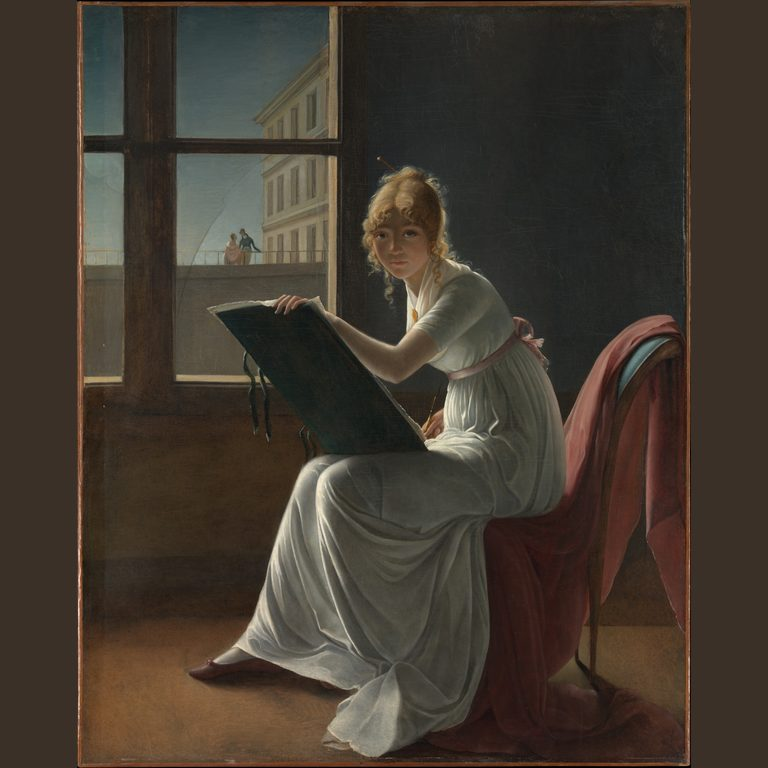
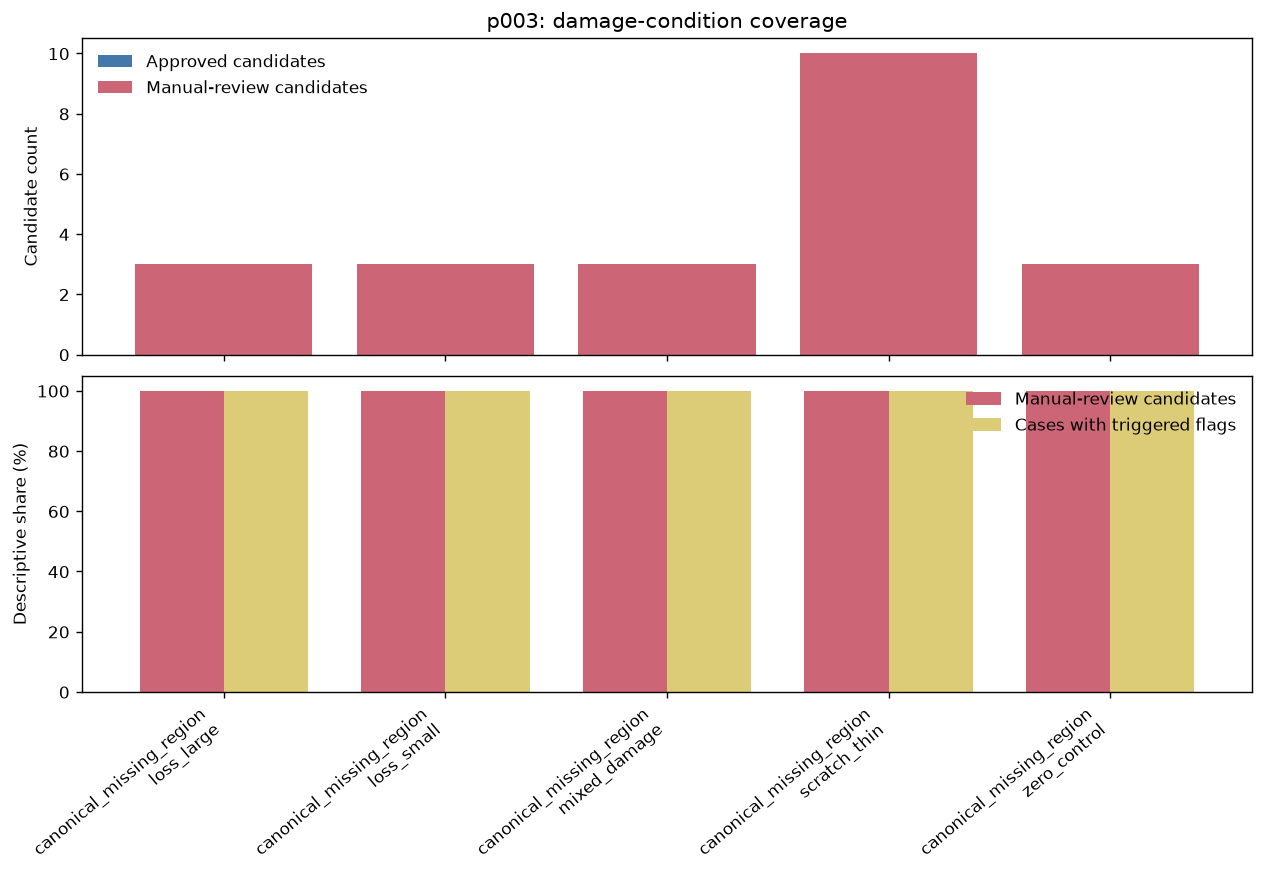
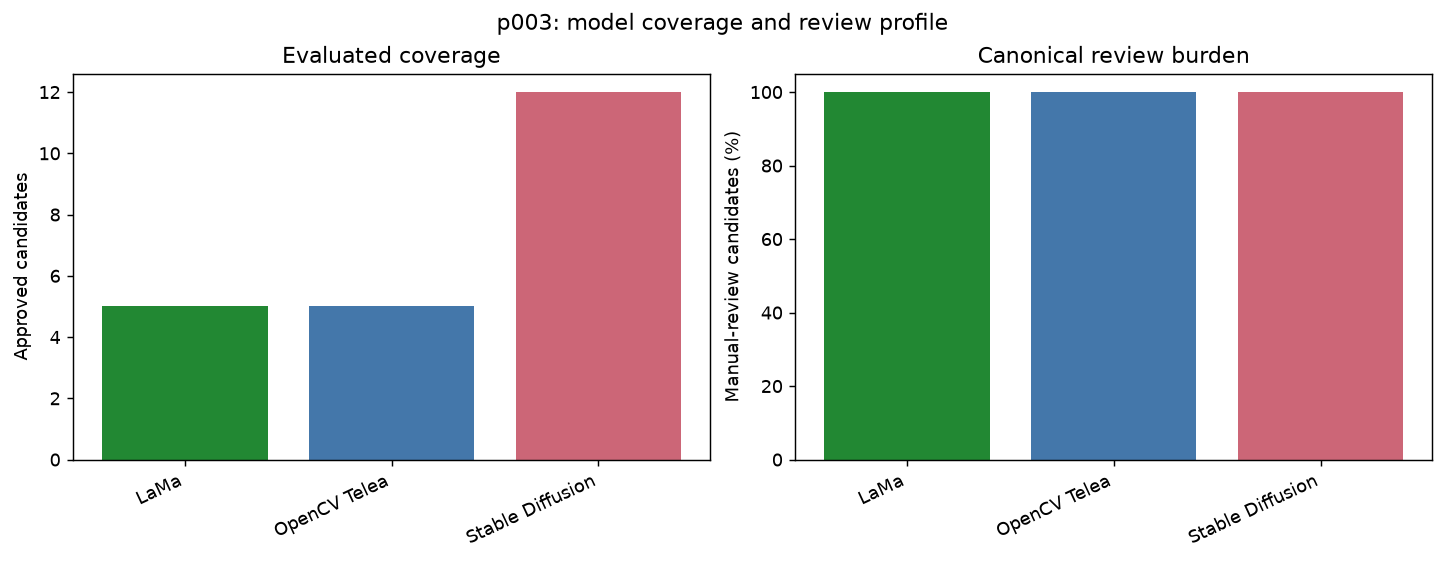
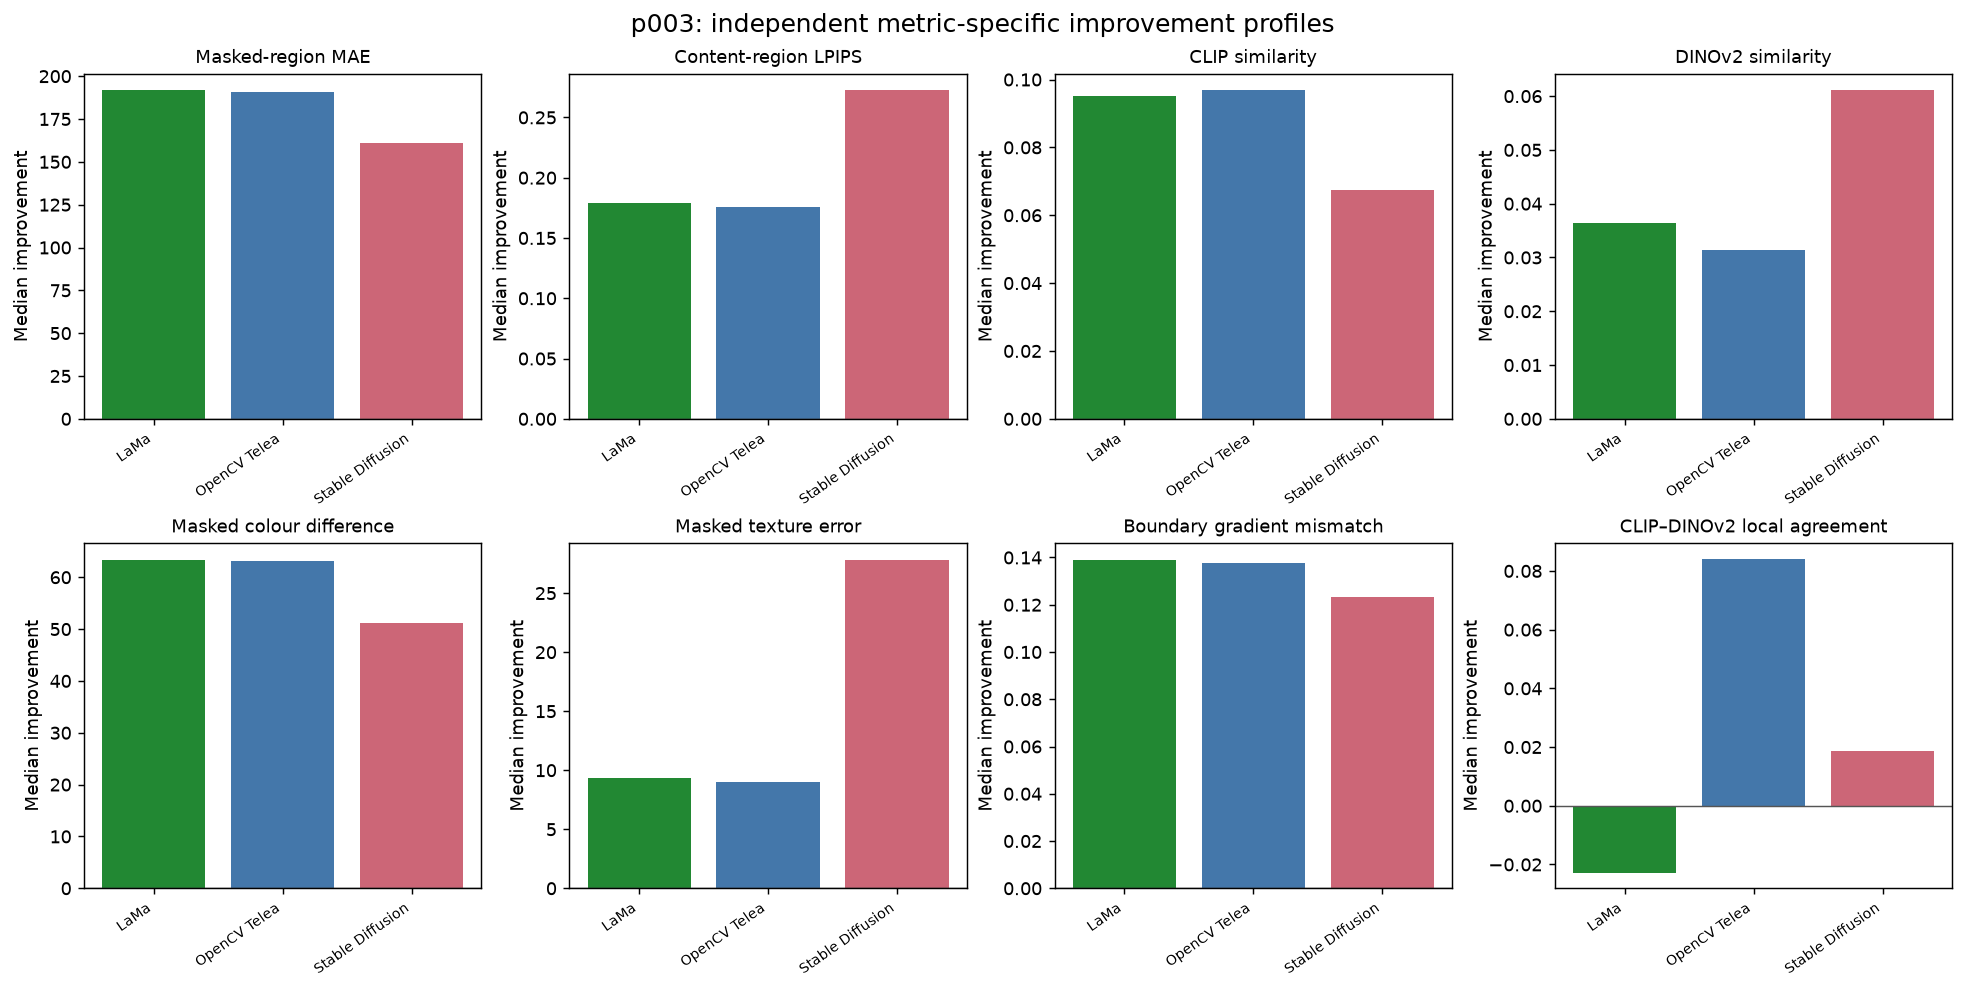
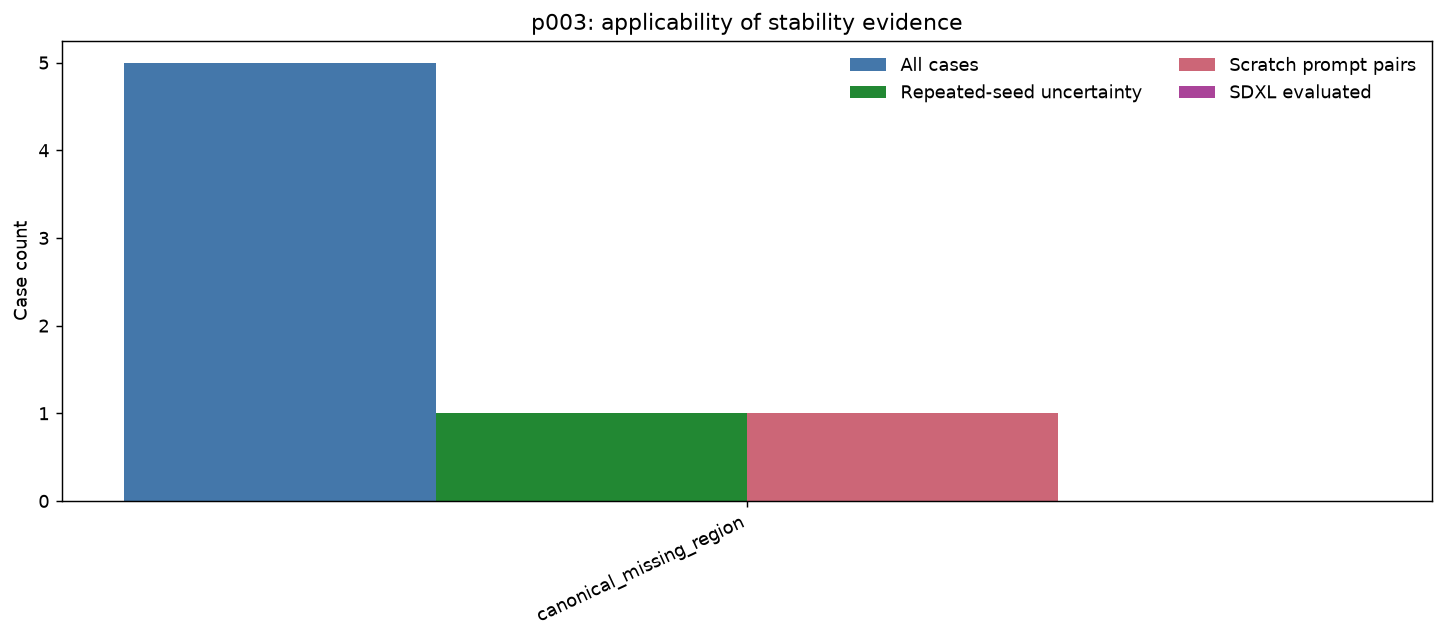
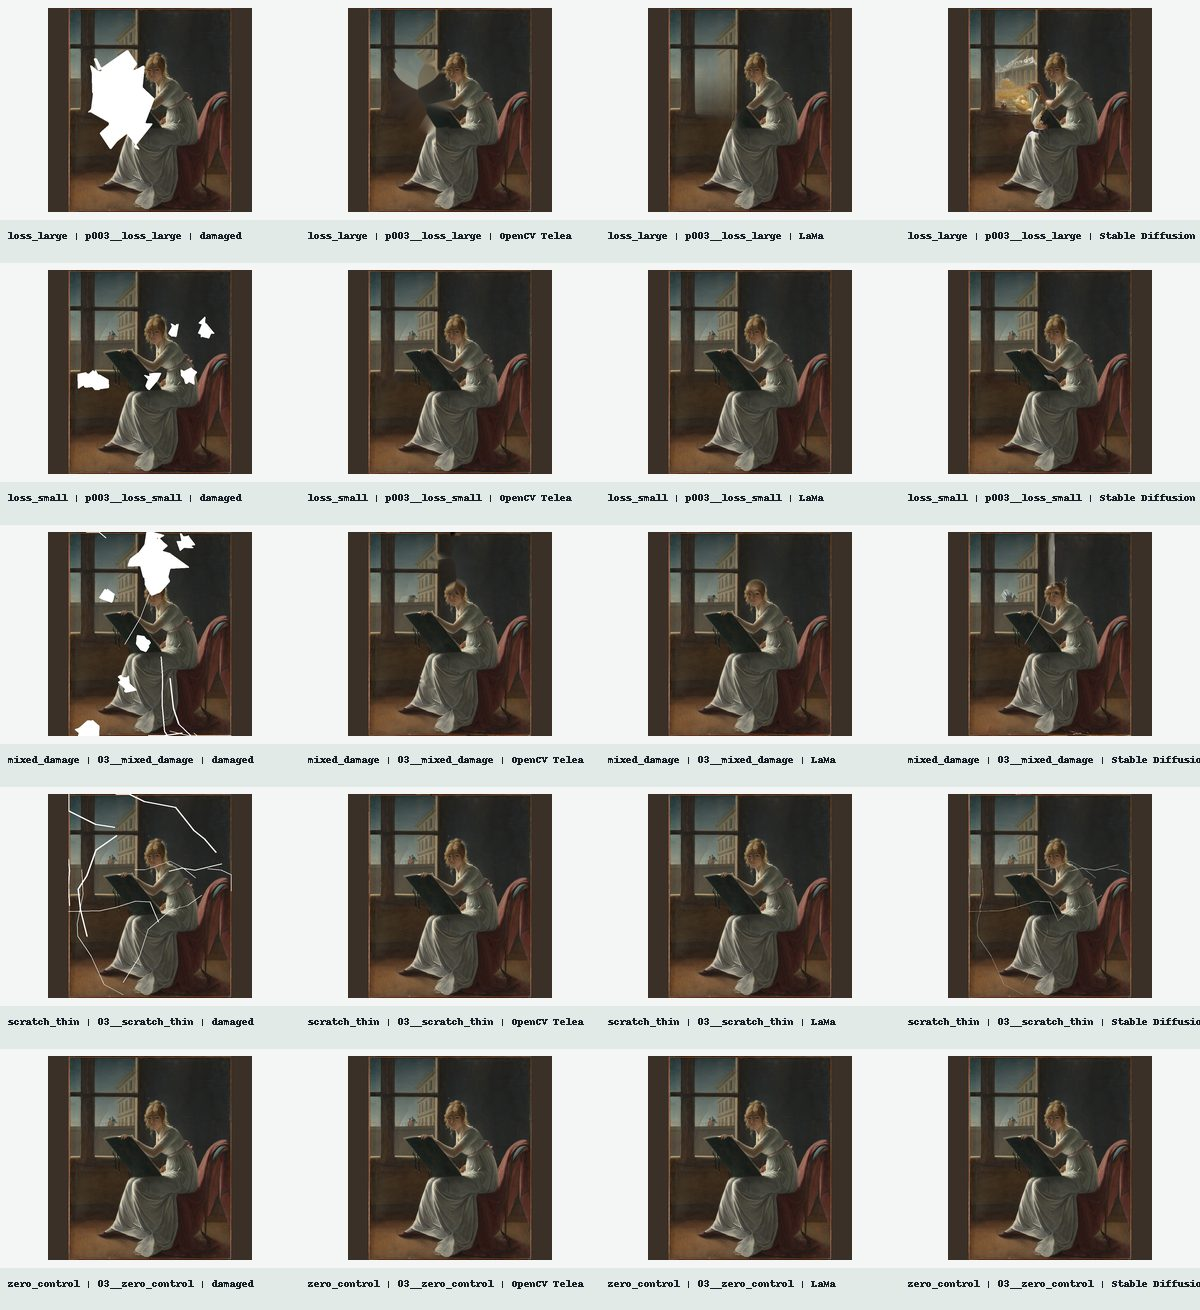

Extension painting preview: p001



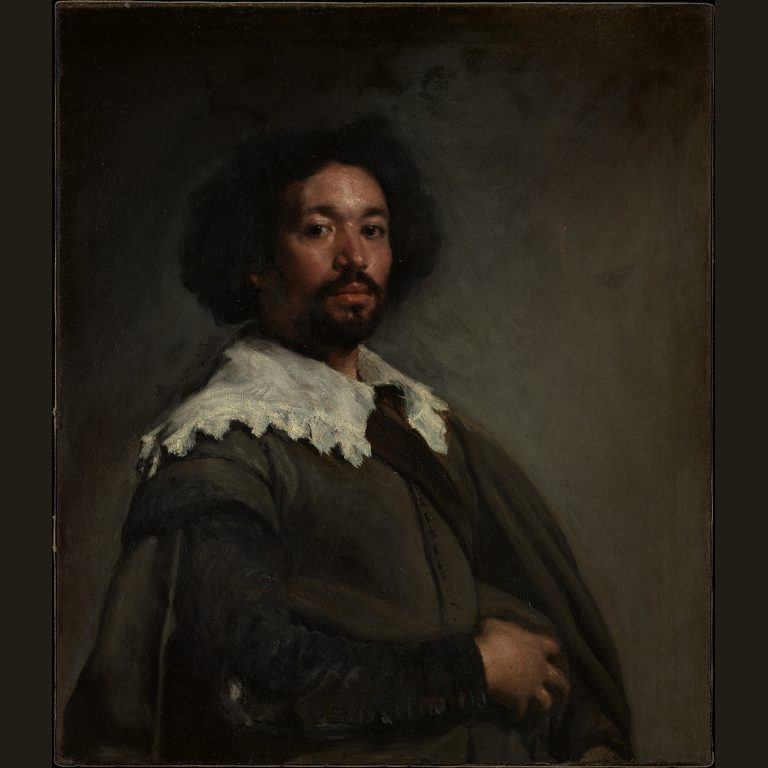
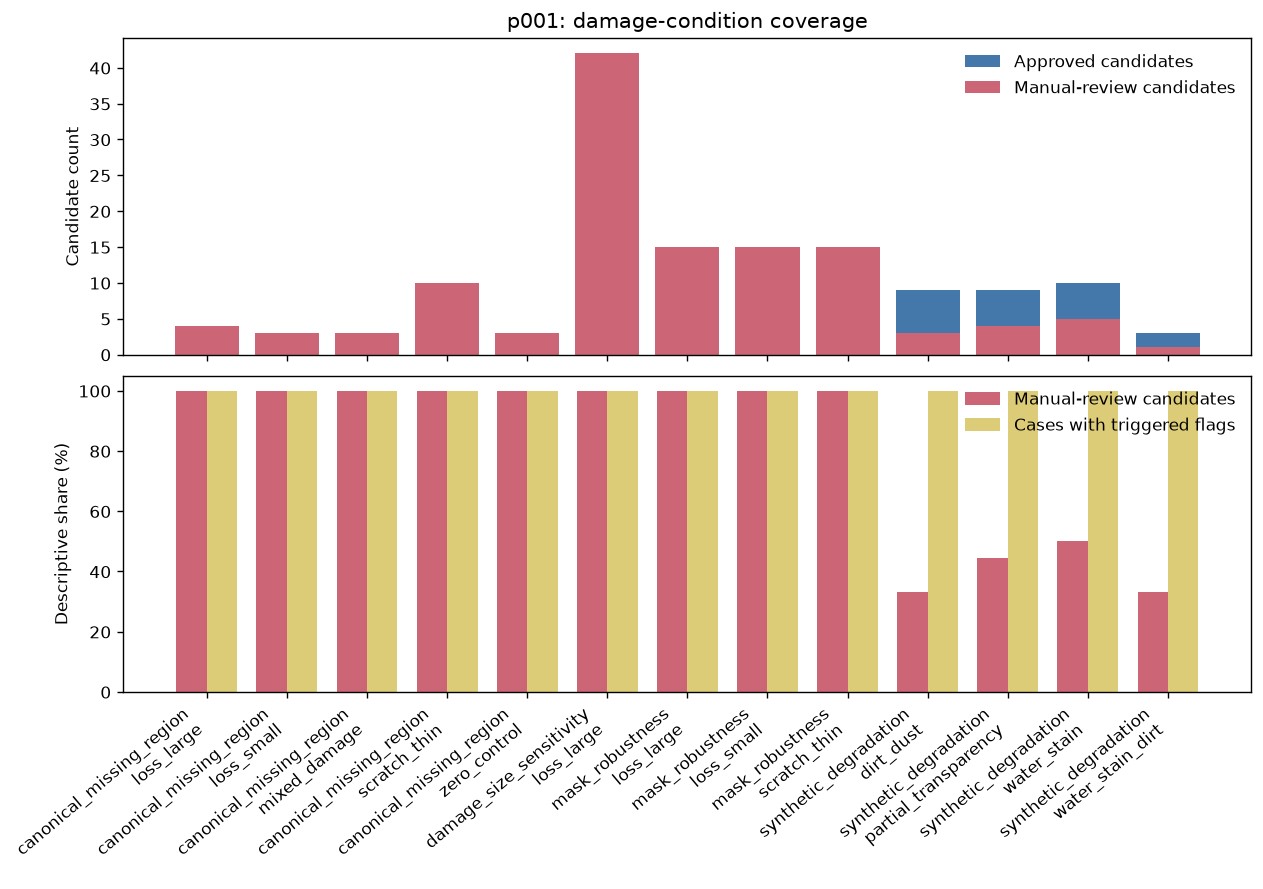
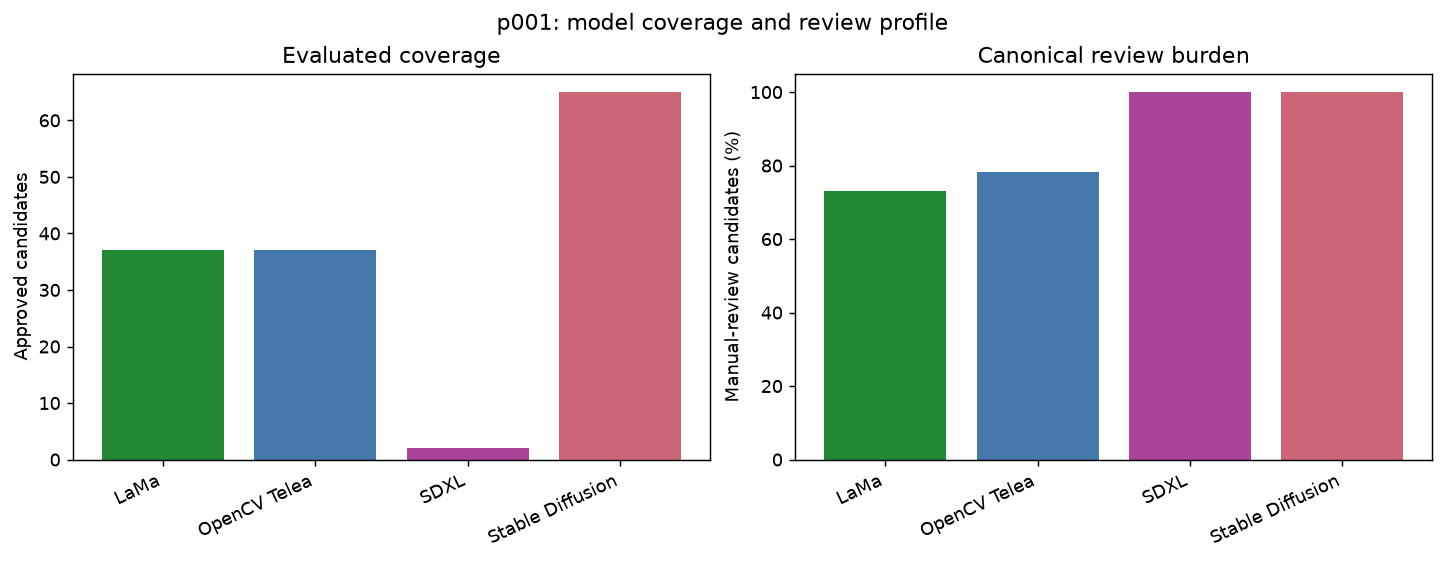
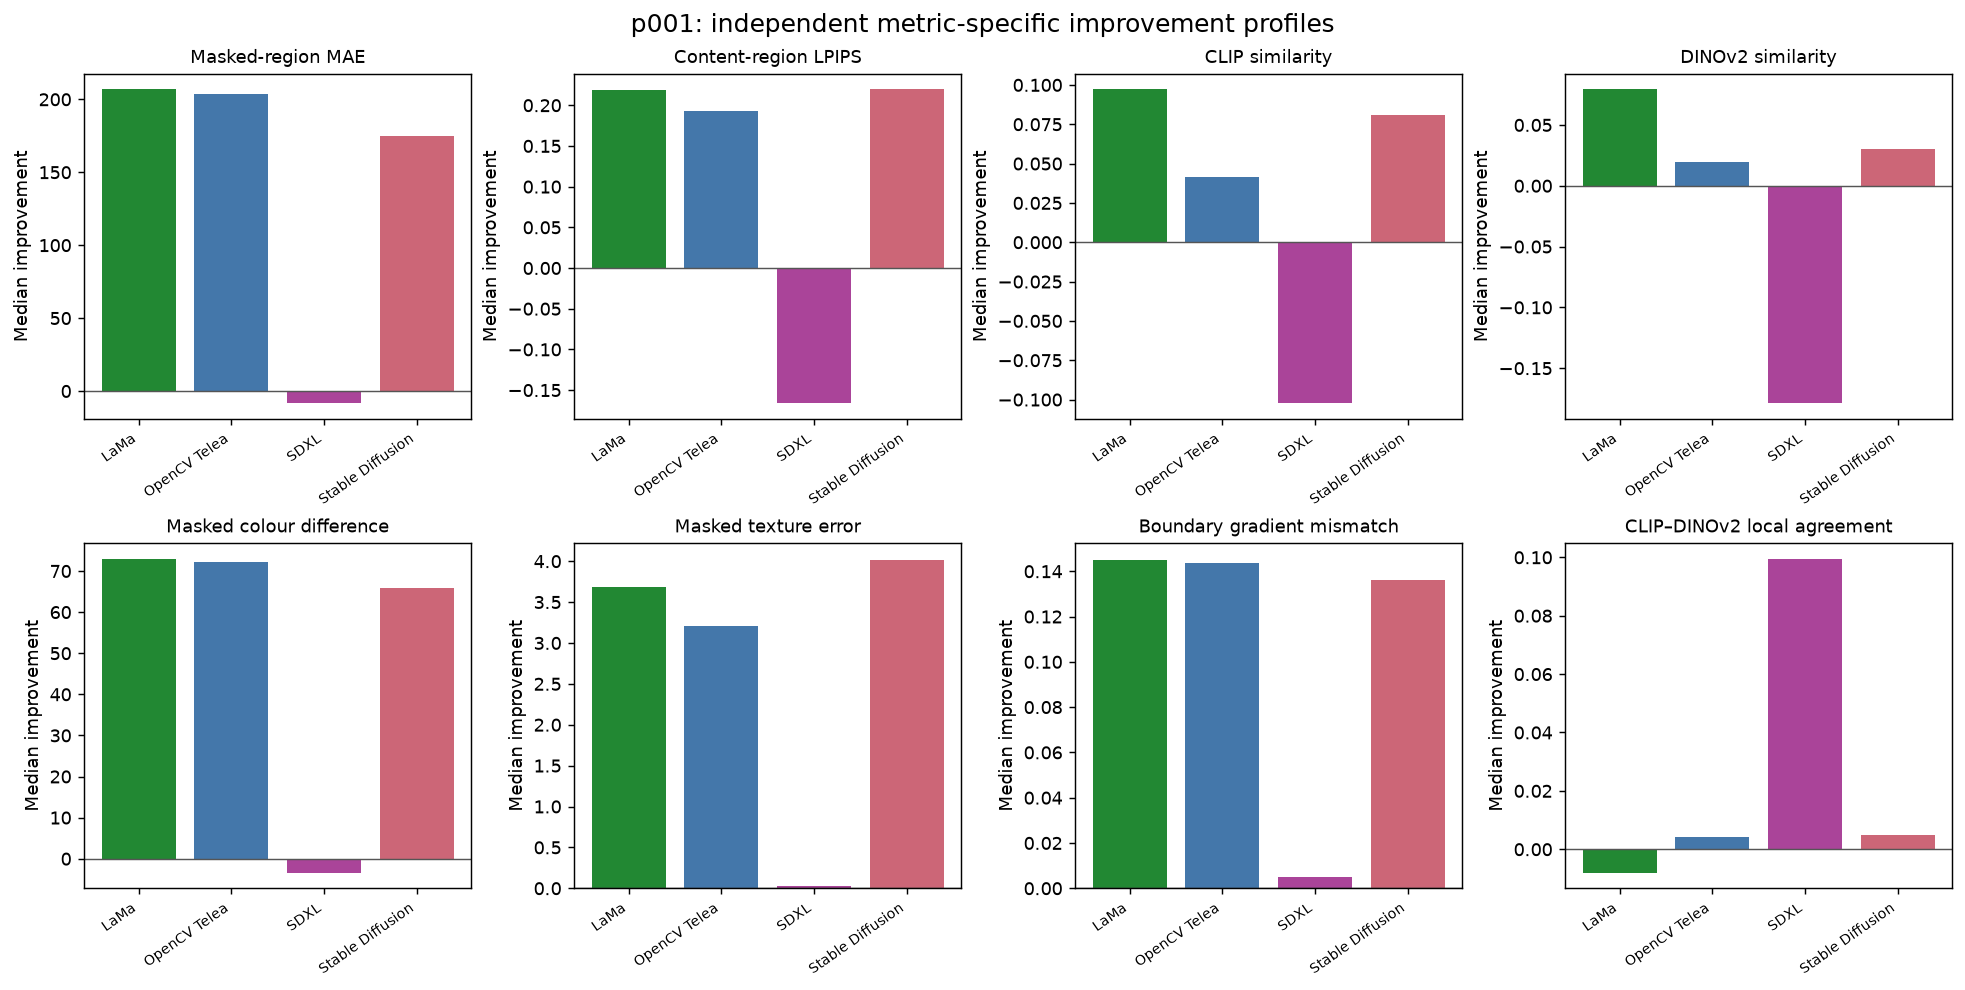
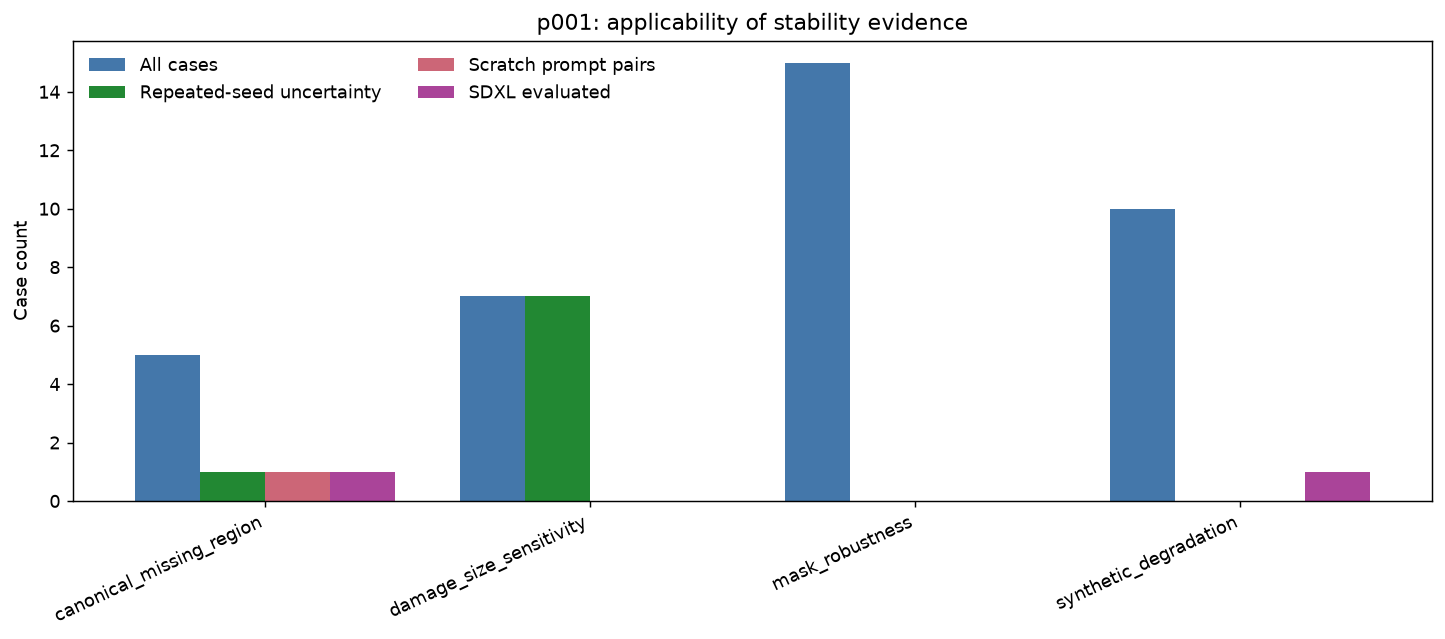
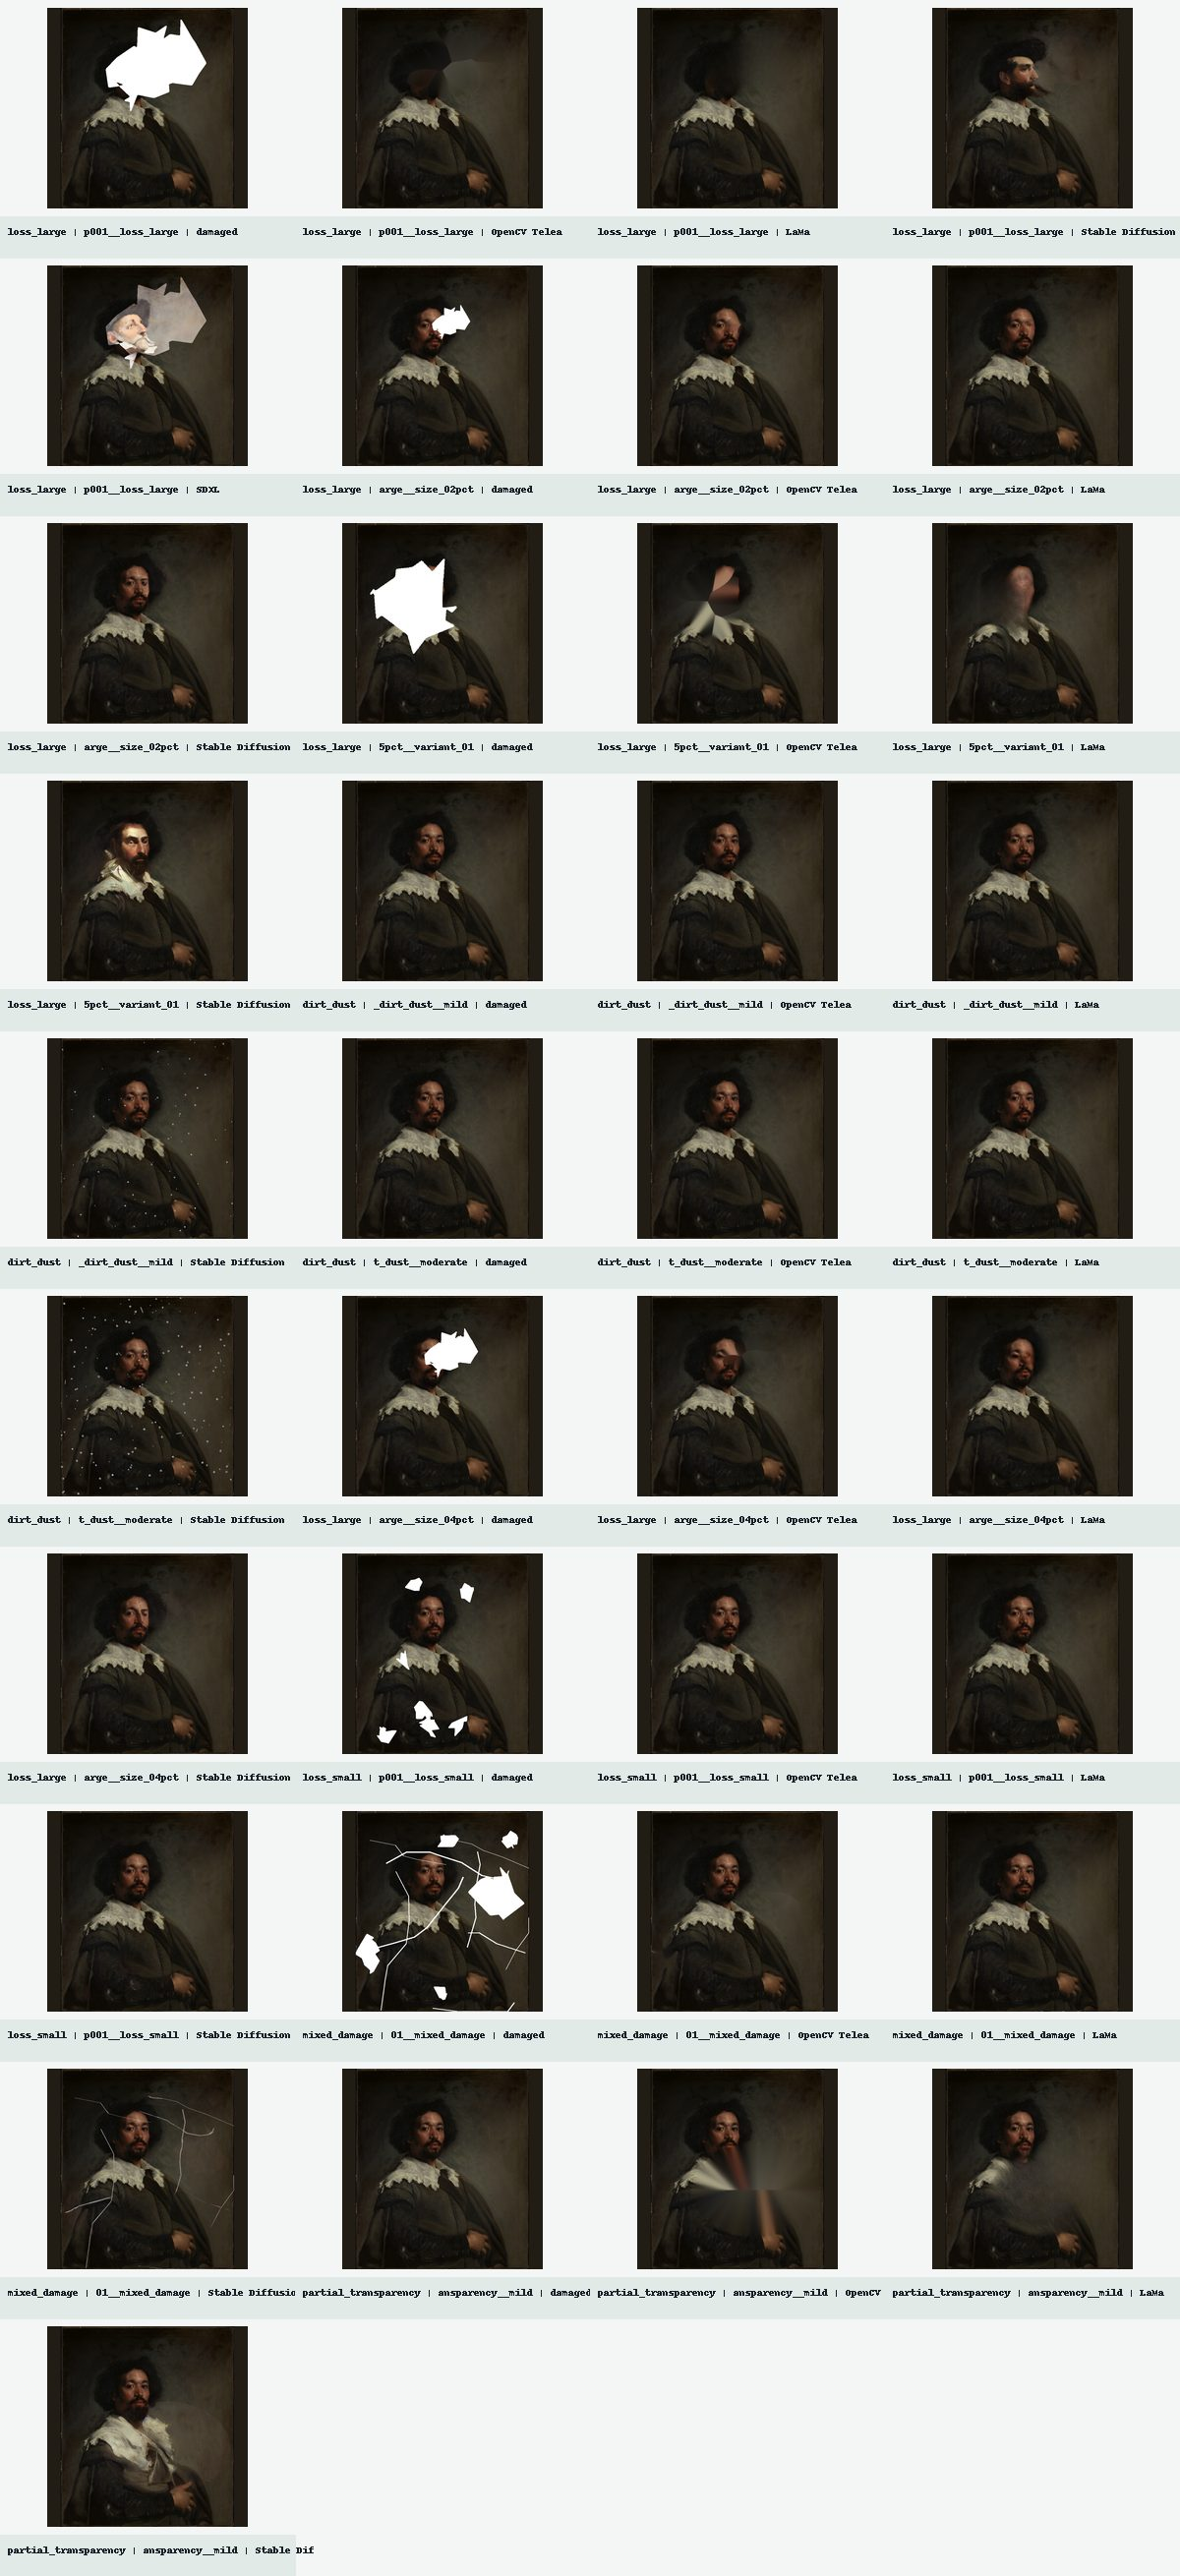

Painting-report previews passed.
Standard atlas tiles: 20
Extension atlas tiles: 37
External image dependencies: 0
Preview report files written: False


In [50]:
STANDARD_PREVIEW_ROWS = (
    PAINTING_REPORT_POPULATION.loc[
        ~PAINTING_REPORT_POPULATION[
            "is_extension_painting"
        ].map(truthy)
        & PAINTING_REPORT_POPULATION[
            "selected_case_count"
        ].eq(0)
    ]
    .sort_values("painting_id")
)

if STANDARD_PREVIEW_ROWS.empty:
    STANDARD_PREVIEW_ROWS = (
        PAINTING_REPORT_POPULATION.loc[
            ~PAINTING_REPORT_POPULATION[
                "is_extension_painting"
            ].map(truthy)
        ]
        .sort_values("painting_id")
    )

STANDARD_PREVIEW_ID = str(
    STANDARD_PREVIEW_ROWS.iloc[0][
        "painting_id"
    ]
)

EXTENSION_PREVIEW_ID = str(
    PAINTING_REPORT_POPULATION.loc[
        PAINTING_REPORT_POPULATION[
            "is_extension_painting"
        ].map(truthy)
    ]
    .sort_values("painting_id")
    .iloc[0]["painting_id"]
)

(
    STANDARD_PREVIEW_SECTIONS,
    STANDARD_PREVIEW_METADATA,
) = build_final_painting_report_sections(
    STANDARD_PREVIEW_ID
)

(
    EXTENSION_PREVIEW_SECTIONS,
    EXTENSION_PREVIEW_METADATA,
) = build_final_painting_report_sections(
    EXTENSION_PREVIEW_ID
)

STANDARD_PREVIEW_HTML = render_report_html(
    title=(
        "Painting Restoration Report — "
        f"{STANDARD_PREVIEW_ID}"
    ),
    subtitle=(
        "Complete painting-level restoration evidence, "
        "model behaviour, limitations, and review actions"
    ),
    report_kind="painting",
    sections=STANDARD_PREVIEW_SECTIONS,
    config=CONFIG,
)

EXTENSION_PREVIEW_HTML = render_report_html(
    title=(
        "Painting Restoration Report — "
        f"{EXTENSION_PREVIEW_ID}"
    ),
    subtitle=(
        "Extended painting-level restoration evidence, "
        "sensitivity experiments, limitations, and review actions"
    ),
    report_kind="painting",
    sections=EXTENSION_PREVIEW_SECTIONS,
    config=CONFIG,
)

STANDARD_PREVIEW_CHECKS = (
    validate_report_html(
        STANDARD_PREVIEW_HTML,
        report_kind="painting",
        config=CONFIG,
        is_extension_painting=False,
    )
)

EXTENSION_PREVIEW_CHECKS = (
    validate_report_html(
        EXTENSION_PREVIEW_HTML,
        report_kind="painting",
        config=CONFIG,
        is_extension_painting=True,
    )
)

collect_scoped_helper_checks(
    STANDARD_PREVIEW_CHECKS,
    scope=(
        "batch_8_standard_painting_preview"
    ),
)

collect_scoped_helper_checks(
    EXTENSION_PREVIEW_CHECKS,
    scope=(
        "batch_8_extension_painting_preview"
    ),
)

PREVIEW_METADATA_CHECKS = (
    (
        "standard_case_count",
        "Standard preview contains all five painting cases",
        int(
            POPULATION[
                "cases_per_painting"
            ]["standard_case_count"]
        ),
        int(
            STANDARD_PREVIEW_METADATA[
                "case_count"
            ]
        ),
        (
            int(
                STANDARD_PREVIEW_METADATA[
                    "case_count"
                ]
            )
            == int(
                POPULATION[
                    "cases_per_painting"
                ]["standard_case_count"]
            )
        ),
    ),
    (
        "extension_case_count",
        "Extension preview contains all 37 painting cases",
        int(
            POPULATION[
                "cases_per_painting"
            ]["extension_case_count"]
        ),
        int(
            EXTENSION_PREVIEW_METADATA[
                "case_count"
            ]
        ),
        (
            int(
                EXTENSION_PREVIEW_METADATA[
                    "case_count"
                ]
            )
            == int(
                POPULATION[
                    "cases_per_painting"
                ]["extension_case_count"]
            )
        ),
    ),
    (
        "standard_spotlight_cases",
        "Standard preview atlas includes all five cases",
        5,
        int(
            STANDARD_PREVIEW_METADATA[
                "spotlight_case_count"
            ]
        ),
        int(
            STANDARD_PREVIEW_METADATA[
                "spotlight_case_count"
            ]
        ) == 5,
    ),
    (
        "extension_spotlight_cases",
        "Extension preview atlas includes nine deterministic cases",
        9,
        int(
            EXTENSION_PREVIEW_METADATA[
                "spotlight_case_count"
            ]
        ),
        int(
            EXTENSION_PREVIEW_METADATA[
                "spotlight_case_count"
            ]
        ) == 9,
    ),
    (
        "standard_atlas_tiles",
        "Standard preview meets its 20-tile atlas minimum",
        20,
        int(
            STANDARD_PREVIEW_METADATA[
                "atlas_tile_count"
            ]
        ),
        int(
            STANDARD_PREVIEW_METADATA[
                "atlas_tile_count"
            ]
        ) >= 20,
    ),
    (
        "extension_atlas_tiles",
        "Extension preview meets its 35-tile atlas minimum",
        35,
        int(
            EXTENSION_PREVIEW_METADATA[
                "atlas_tile_count"
            ]
        ),
        int(
            EXTENSION_PREVIEW_METADATA[
                "atlas_tile_count"
            ]
        ) >= 35,
    ),
    (
        "standard_embedded_images",
        "Standard preview embeds six visual panels",
        6,
        int(
            STANDARD_PREVIEW_METADATA[
                "embedded_image_count"
            ]
        ),
        int(
            STANDARD_PREVIEW_METADATA[
                "embedded_image_count"
            ]
        ) == 6,
    ),
    (
        "extension_embedded_images",
        "Extension preview embeds six visual panels",
        6,
        int(
            EXTENSION_PREVIEW_METADATA[
                "embedded_image_count"
            ]
        ),
        int(
            EXTENSION_PREVIEW_METADATA[
                "embedded_image_count"
            ]
        ) == 6,
    ),
    (
        "standard_source_paths",
        "Every standard-preview source path exists",
        True,
        all(
            (
                PROJECT_ROOT / path
            ).is_file()
            for path
            in STANDARD_PREVIEW_METADATA[
                "source_paths"
            ]
        ),
        all(
            (
                PROJECT_ROOT / path
            ).is_file()
            for path
            in STANDARD_PREVIEW_METADATA[
                "source_paths"
            ]
        ),
    ),
    (
        "extension_source_paths",
        "Every extension-preview source path exists",
        True,
        all(
            (
                PROJECT_ROOT / path
            ).is_file()
            for path
            in EXTENSION_PREVIEW_METADATA[
                "source_paths"
            ]
        ),
        all(
            (
                PROJECT_ROOT / path
            ).is_file()
            for path
            in EXTENSION_PREVIEW_METADATA[
                "source_paths"
            ]
        ),
    ),
)

for (
    check_id,
    description,
    expected,
    observed,
    passed,
) in PREVIEW_METADATA_CHECKS:
    VALIDATION.add(
        validation_stage=(
            "batch_8_painting_preview_metadata"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=(
            ""
            if passed
            else (
                "Painting-report preview "
                "metadata failed."
            )
        ),
    )

VALIDATION.raise_for_blocking()

display(
    STANDARD_PREVIEW_CHECKS[
        [
            "check_name",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

display(
    EXTENSION_PREVIEW_CHECKS[
        [
            "check_name",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "Standard painting preview:",
    STANDARD_PREVIEW_ID,
)
display(
    HTML(STANDARD_PREVIEW_HTML)
)

print(
    "Extension painting preview:",
    EXTENSION_PREVIEW_ID,
)
display(
    HTML(EXTENSION_PREVIEW_HTML)
)

print("Painting-report previews passed.")
print(
    "Standard atlas tiles:",
    STANDARD_PREVIEW_METADATA[
        "atlas_tile_count"
    ],
)
print(
    "Extension atlas tiles:",
    EXTENSION_PREVIEW_METADATA[
        "atlas_tile_count"
    ],
)
print("External image dependencies:", 0)
print("Preview report files written:", False)

In [51]:
PAINTING_PREVIEW_PROFILE = pd.DataFrame(
    [
        {
            "preview_kind": "standard",
            "painting_id": (
                STANDARD_PREVIEW_ID
            ),
            "case_count": (
                STANDARD_PREVIEW_METADATA[
                    "case_count"
                ]
            ),
            "candidate_count": (
                STANDARD_PREVIEW_METADATA[
                    "candidate_count"
                ]
            ),
            "spotlight_case_count": (
                STANDARD_PREVIEW_METADATA[
                    "spotlight_case_count"
                ]
            ),
            "atlas_tile_count": (
                STANDARD_PREVIEW_METADATA[
                    "atlas_tile_count"
                ]
            ),
            "embedded_image_count": (
                STANDARD_PREVIEW_METADATA[
                    "embedded_image_count"
                ]
            ),
            "embedded_tile_count": (
                STANDARD_PREVIEW_METADATA[
                    "embedded_tile_count"
                ]
            ),
            "source_path_count": len(
                STANDARD_PREVIEW_METADATA[
                    "source_paths"
                ]
            ),
        },
        {
            "preview_kind": "extension",
            "painting_id": (
                EXTENSION_PREVIEW_ID
            ),
            "case_count": (
                EXTENSION_PREVIEW_METADATA[
                    "case_count"
                ]
            ),
            "candidate_count": (
                EXTENSION_PREVIEW_METADATA[
                    "candidate_count"
                ]
            ),
            "spotlight_case_count": (
                EXTENSION_PREVIEW_METADATA[
                    "spotlight_case_count"
                ]
            ),
            "atlas_tile_count": (
                EXTENSION_PREVIEW_METADATA[
                    "atlas_tile_count"
                ]
            ),
            "embedded_image_count": (
                EXTENSION_PREVIEW_METADATA[
                    "embedded_image_count"
                ]
            ),
            "embedded_tile_count": (
                EXTENSION_PREVIEW_METADATA[
                    "embedded_tile_count"
                ]
            ),
            "source_path_count": len(
                EXTENSION_PREVIEW_METADATA[
                    "source_paths"
                ]
            ),
        },
    ]
)

BATCH_8_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_8_SUMMARY = (
    VALIDATION.summary()
)

display(
    PAINTING_PREVIEW_PROFILE
)

print("Batch 8 completed.")
print(
    "Painting metric-anchor rows:",
    len(PAINTING_METRIC_ANCHORS),
)
print(
    "Painting reports previewed:",
    len(PAINTING_PREVIEW_PROFILE),
)
print(
    "Painting reports written:",
    0,
)
print(
    "Checks added in Batch 8:",
    len(BATCH_8_VALIDATION)
    - len(BATCH_7_VALIDATION),
)
print(
    "Validation summary:",
    BATCH_8_SUMMARY,
)
print(
    "Blocking failures:",
    BATCH_8_SUMMARY[
        "blocking_failure_count"
    ],
)
print(
    "Warning failures:",
    int(
        (
            BATCH_8_VALIDATION[
                "severity"
            ].eq("warning")
            & ~BATCH_8_VALIDATION[
                "passed"
            ]
        ).sum()
    ),
)
print(
    "Ready for Batch 9:",
    BATCH_8_SUMMARY[
        "overall_passed"
    ],
)

,preview_kind,painting_id,case_count,candidate_count,spotlight_case_count,atlas_tile_count,embedded_image_count,embedded_tile_count,source_path_count
0,standard,p003,5,22,5,20,6,25,32
1,extension,p001,37,141,9,37,6,42,49


Batch 8 completed.
Painting metric-anchor rows: 1240
Painting reports previewed: 2
Painting reports written: 0
Checks added in Batch 8: 49
Validation summary: {'check_count': 941, 'passed_count': 941, 'failed_count': 0, 'blocking_failure_count': 0, 'overall_passed': True, 'failed_check_ids': []}
Blocking failures: 0
Warning failures: 0
Ready for Batch 9: True


## Batch 9 — Generate all painting reports and canonical painting index

This batch generates all 50 self-contained painting reports using the validated renderer from Batch 8.

Each report:

- represents every applicable case and candidate in its canonical tables;
- embeds its clean reference, deterministic spotlight atlas, and four report-only plots;
- preserves standard versus extension coverage limits;
- records complete source-artifact provenance;
- is validated before being written.

The generation cell is safely rerunnable. Existing reports are replaced atomically, and progress is printed after every ten paintings.

In [52]:
from restoration_eval.case_painting_reports import (
    PAINTING_REPORT_INDEX_COLUMNS,
    build_painting_report_index_row,
    validate_report_indexes,
)


# Make the generation safely rerunnable after interruption.
VALIDATION = ValidationCollector()

for record in BATCH_8_VALIDATION.to_dict(
    orient="records"
):
    VALIDATION.add(
        validation_stage=record["validation_stage"],
        check_id=record["check_id"],
        check_description=record["check_description"],
        severity=record["severity"],
        expected=record["expected"],
        observed=record["observed"],
        passed=bool(record["passed"]),
        details=record["details"],
    )


PAINTING_REPORT_GENERATED_AT_UTC = (
    datetime.now(timezone.utc)
    .isoformat(timespec="seconds")
    .replace("+00:00", "Z")
)

PAINTING_REPORT_DIRECTORY = OUTPUT_PATHS[
    "painting_reports_dir"
]

PAINTING_REPORT_INDEX_ROWS = []
PAINTING_REPORT_METADATA_ROWS = []

for _, painting_row in (
    PAINTING_REPORT_POPULATION
    .sort_values("painting_id")
    .iterrows()
):
    painting_id = str(
        painting_row["painting_id"]
    )

    is_extension = truthy(
        painting_row[
            "is_extension_painting"
        ]
    )

    sections, metadata = (
        build_final_painting_report_sections(
            painting_id
        )
    )

    report_html = render_report_html(
        title=(
            "Painting Restoration Report — "
            f"{painting_id}"
        ),
        subtitle=(
            (
                "Extended painting-level restoration evidence, "
                "sensitivity experiments, limitations, and "
                "review actions"
            )
            if is_extension
            else (
                "Complete painting-level restoration evidence, "
                "model behaviour, limitations, and review actions"
            )
        ),
        report_kind="painting",
        sections=sections,
        config=CONFIG,
    )

    report_checks = validate_report_html(
        report_html,
        report_kind="painting",
        config=CONFIG,
        is_extension_painting=is_extension,
    )

    collect_scoped_helper_checks(
        report_checks,
        scope=(
            f"batch_9_painting_{painting_id}"
        ),
    )

    VALIDATION.raise_for_blocking()

    report_path = (
        PAINTING_REPORT_DIRECTORY
        / f"{painting_id}.html"
    )

    atomic_write_text(
        report_html,
        report_path,
    )

    index_row = (
        build_painting_report_index_row(
            report_path,
            project_root=PROJECT_ROOT,
            painting_row=painting_row.to_dict(),
            source_artifact_paths=metadata[
                "source_paths"
            ],
            upstream_run_ids=UPSTREAM_RUN_IDS,
            generated_at_utc=(
                PAINTING_REPORT_GENERATED_AT_UTC
            ),
        )
    )

    PAINTING_REPORT_INDEX_ROWS.append(
        index_row
    )

    PAINTING_REPORT_METADATA_ROWS.append(
        {
            "painting_id": painting_id,
            "category": str(
                painting_row["category"]
            ),
            "is_extension_painting": (
                is_extension
            ),
            "case_count": int(
                metadata["case_count"]
            ),
            "candidate_count": int(
                metadata["candidate_count"]
            ),
            "model_count": int(
                metadata["model_count"]
            ),
            "metric_anchor_count": int(
                metadata[
                    "metric_anchor_count"
                ]
            ),
            "spotlight_case_count": int(
                metadata[
                    "spotlight_case_count"
                ]
            ),
            "atlas_tile_count": int(
                metadata[
                    "atlas_tile_count"
                ]
            ),
            "derived_plot_count": int(
                metadata[
                    "derived_plot_count"
                ]
            ),
            "embedded_image_count": int(
                index_row[
                    "embedded_image_count"
                ]
            ),
            "embedded_tile_count": int(
                index_row[
                    "embedded_tile_count"
                ]
            ),
            "section_count": int(
                index_row[
                    "section_count"
                ]
            ),
            "source_path_count": len(
                metadata[
                    "source_paths"
                ]
            ),
            "size_bytes": int(
                index_row["size_bytes"]
            ),
            "self_contained": bool(
                index_row[
                    "self_contained"
                ]
            ),
            "report_path": str(
                index_row["report_path"]
            ),
            "status": str(
                index_row["status"]
            ),
        }
    )

    completed = len(
        PAINTING_REPORT_INDEX_ROWS
    )

    if (
        completed % PROGRESS_INTERVAL == 0
        or completed
        == int(
            EXPECTED[
                "painting_report_count"
            ]
        )
    ):
        print(
            "Painting reports: "
            f"{completed}/"
            f"{EXPECTED['painting_report_count']} "
            "generated and validated."
        )

PAINTING_REPORT_INDEX = (
    pd.DataFrame(
        PAINTING_REPORT_INDEX_ROWS,
        columns=PAINTING_REPORT_INDEX_COLUMNS,
    )
    .sort_values("painting_id")
    .reset_index(drop=True)
)

PAINTING_REPORT_METADATA = (
    pd.DataFrame(
        PAINTING_REPORT_METADATA_ROWS
    )
    .sort_values("painting_id")
    .reset_index(drop=True)
)

STANDARD_REPORT_METADATA = (
    PAINTING_REPORT_METADATA.loc[
        ~PAINTING_REPORT_METADATA[
            "is_extension_painting"
        ].map(truthy)
    ]
)

EXTENSION_REPORT_METADATA = (
    PAINTING_REPORT_METADATA.loc[
        PAINTING_REPORT_METADATA[
            "is_extension_painting"
        ].map(truthy)
    ]
)

print("All painting reports generated.")
print(
    "Painting reports:",
    len(PAINTING_REPORT_INDEX),
)
print(
    "Standard reports:",
    len(STANDARD_REPORT_METADATA),
)
print(
    "Extension reports:",
    len(EXTENSION_REPORT_METADATA),
)
print(
    "Total report size:",
    (
        f"{PAINTING_REPORT_INDEX['size_bytes'].sum() / (1024 ** 2):,.2f} MiB"
    ),
)
print(
    "Minimum standard images:",
    int(
        STANDARD_REPORT_METADATA[
            "embedded_image_count"
        ].min()
    ),
)
print(
    "Minimum standard tiles:",
    int(
        STANDARD_REPORT_METADATA[
            "embedded_tile_count"
        ].min()
    ),
)
print(
    "Minimum extension images:",
    int(
        EXTENSION_REPORT_METADATA[
            "embedded_image_count"
        ].min()
    ),
)
print(
    "Minimum extension tiles:",
    int(
        EXTENSION_REPORT_METADATA[
            "embedded_tile_count"
        ].min()
    ),
)

Painting reports: 10/50 generated and validated.
Painting reports: 20/50 generated and validated.
Painting reports: 30/50 generated and validated.
Painting reports: 40/50 generated and validated.
Painting reports: 50/50 generated and validated.
All painting reports generated.
Painting reports: 50
Standard reports: 45
Extension reports: 5
Total report size: 44.90 MiB
Minimum standard images: 6
Minimum standard tiles: 25
Minimum extension images: 6
Minimum extension tiles: 41


In [53]:
PAINTING_REPORT_FILES = sorted(
    PAINTING_REPORT_DIRECTORY.glob(
        "*.html"
    )
)

EXPECTED_PAINTING_REPORT_NAMES = {
    f"{painting_id}.html"
    for painting_id
    in PAINTING_REPORT_POPULATION[
        "painting_id"
    ].astype(str)
}

OBSERVED_PAINTING_REPORT_NAMES = {
    path.name
    for path in PAINTING_REPORT_FILES
}

PAINTING_REPORT_TMP_FILES = list(
    PAINTING_REPORT_DIRECTORY.glob(
        "*.tmp"
    )
)

PAINTING_REPORT_STRUCTURE_ERRORS = []
PAINTING_SOURCE_REFERENCE_ERRORS = []

for report_path in PAINTING_REPORT_FILES:
    report_text = report_path.read_text(
        encoding="utf-8"
    )

    section_count = report_text.count(
        'data-section-id="'
    )

    image_count = report_text.count(
        "<img "
    )

    data_image_count = report_text.count(
        'src="data:image/'
    )

    external_image_count = (
        report_text.count(
            'src="outputs/'
        )
        + report_text.count(
            'src="../'
        )
        + report_text.count(
            'src="./'
        )
    )

    if (
        section_count
        != len(
            REPORTS[
                "painting_sections"
            ]
        )
        or image_count != data_image_count
        or external_image_count != 0
    ):
        PAINTING_REPORT_STRUCTURE_ERRORS.append(
            {
                "report": report_path.name,
                "section_count": section_count,
                "image_count": image_count,
                "data_image_count": (
                    data_image_count
                ),
                "external_image_count": (
                    external_image_count
                ),
            }
        )

for _, index_row in (
    PAINTING_REPORT_INDEX.iterrows()
):
    try:
        source_paths = json.loads(
            str(
                index_row[
                    "source_artifact_paths_json"
                ]
            )
        )
    except json.JSONDecodeError as error:
        PAINTING_SOURCE_REFERENCE_ERRORS.append(
            {
                "painting_id": str(
                    index_row["painting_id"]
                ),
                "issue": (
                    "invalid_source_paths_json"
                ),
                "details": str(error),
            }
        )
        continue

    if not isinstance(
        source_paths,
        list,
    ):
        PAINTING_SOURCE_REFERENCE_ERRORS.append(
            {
                "painting_id": str(
                    index_row["painting_id"]
                ),
                "issue": (
                    "source_paths_not_list"
                ),
                "details": str(
                    type(source_paths)
                ),
            }
        )
        continue

    for relative_path in source_paths:
        raw_path = Path(
            str(relative_path)
        )

        if raw_path.is_absolute():
            PAINTING_SOURCE_REFERENCE_ERRORS.append(
                {
                    "painting_id": str(
                        index_row[
                            "painting_id"
                        ]
                    ),
                    "issue": (
                        "absolute_source_path"
                    ),
                    "details": str(
                        relative_path
                    ),
                }
            )
            continue

        resolved_path = (
            PROJECT_ROOT / raw_path
        ).resolve()

        try:
            resolved_path.relative_to(
                PROJECT_ROOT
            )
        except ValueError:
            PAINTING_SOURCE_REFERENCE_ERRORS.append(
                {
                    "painting_id": str(
                        index_row[
                            "painting_id"
                        ]
                    ),
                    "issue": (
                        "source_path_escapes_repository"
                    ),
                    "details": str(
                        relative_path
                    ),
                }
            )
            continue

        if not resolved_path.is_file():
            PAINTING_SOURCE_REFERENCE_ERRORS.append(
                {
                    "painting_id": str(
                        index_row[
                            "painting_id"
                        ]
                    ),
                    "issue": (
                        "missing_source_file"
                    ),
                    "details": str(
                        relative_path
                    ),
                }
            )

STANDARD_INDEX_ROWS = (
    PAINTING_REPORT_INDEX.loc[
        ~PAINTING_REPORT_INDEX[
            "is_extension_painting"
        ].map(truthy)
    ]
)

EXTENSION_INDEX_ROWS = (
    PAINTING_REPORT_INDEX.loc[
        PAINTING_REPORT_INDEX[
            "is_extension_painting"
        ].map(truthy)
    ]
)

SOFT_PAINTING_SIZE_LIMIT_BYTES = int(
    float(
        REPORTS[
            "soft_painting_report_size_warning_mib"
        ]
    )
    * 1024 ** 2
)

OVERSIZED_PAINTING_REPORTS = (
    PAINTING_REPORT_INDEX.loc[
        PAINTING_REPORT_INDEX[
            "size_bytes"
        ].gt(
            SOFT_PAINTING_SIZE_LIMIT_BYTES
        ),
        [
            "painting_id",
            "size_bytes",
        ],
    ]
    .copy()
)

PAINTING_INDEX_CHECKS = (
    (
        "painting_report_rows",
        "Painting-report index contains exactly 50 rows",
        int(
            EXPECTED[
                "painting_report_index_rows"
            ]
        ),
        len(PAINTING_REPORT_INDEX),
        (
            len(PAINTING_REPORT_INDEX)
            == int(
                EXPECTED[
                    "painting_report_index_rows"
                ]
            )
        ),
    ),
    (
        "painting_report_ids_unique",
        "Painting-report identifiers are unique",
        int(
            EXPECTED[
                "painting_report_count"
            ]
        ),
        int(
            PAINTING_REPORT_INDEX[
                "report_id"
            ].nunique()
        ),
        (
            PAINTING_REPORT_INDEX[
                "report_id"
            ].nunique()
            == int(
                EXPECTED[
                    "painting_report_count"
                ]
            )
        ),
    ),
    (
        "painting_ids_unique",
        "Every painting has exactly one report",
        int(
            EXPECTED[
                "painting_count"
            ]
        ),
        int(
            PAINTING_REPORT_INDEX[
                "painting_id"
            ].nunique()
        ),
        (
            PAINTING_REPORT_INDEX[
                "painting_id"
            ].nunique()
            == int(
                EXPECTED[
                    "painting_count"
                ]
            )
        ),
    ),
    (
        "painting_report_file_count",
        "Exactly 50 physical painting reports exist",
        int(
            EXPECTED[
                "painting_report_count"
            ]
        ),
        len(PAINTING_REPORT_FILES),
        (
            len(PAINTING_REPORT_FILES)
            == int(
                EXPECTED[
                    "painting_report_count"
                ]
            )
        ),
    ),
    (
        "painting_report_file_identity",
        "Physical painting-report names match all paintings",
        sorted(
            EXPECTED_PAINTING_REPORT_NAMES
        ),
        sorted(
            OBSERVED_PAINTING_REPORT_NAMES
        ),
        (
            OBSERVED_PAINTING_REPORT_NAMES
            == EXPECTED_PAINTING_REPORT_NAMES
        ),
    ),
    (
        "painting_report_sections",
        "Every painting report contains all approved sections",
        len(
            REPORTS[
                "painting_sections"
            ]
        ),
        sorted(
            PAINTING_REPORT_INDEX[
                "section_count"
            ]
            .astype(int)
            .unique()
            .tolist()
        ),
        (
            PAINTING_REPORT_INDEX[
                "section_count"
            ]
            .astype(int)
            .eq(
                len(
                    REPORTS[
                        "painting_sections"
                    ]
                )
            )
            .all()
        ),
    ),
    (
        "standard_painting_image_minimum",
        "Every standard report meets its image minimum",
        int(
            REPORTS[
                "minimum_visuals"
            ][
                "standard_painting_report_images"
            ]
        ),
        int(
            STANDARD_INDEX_ROWS[
                "embedded_image_count"
            ].min()
        ),
        (
            STANDARD_INDEX_ROWS[
                "embedded_image_count"
            ]
            .astype(int)
            .ge(
                int(
                    REPORTS[
                        "minimum_visuals"
                    ][
                        "standard_painting_report_images"
                    ]
                )
            )
            .all()
        ),
    ),
    (
        "standard_painting_tile_minimum",
        "Every standard report meets its tile minimum",
        int(
            REPORTS[
                "minimum_visuals"
            ][
                "standard_painting_report_tiles"
            ]
        ),
        int(
            STANDARD_INDEX_ROWS[
                "embedded_tile_count"
            ].min()
        ),
        (
            STANDARD_INDEX_ROWS[
                "embedded_tile_count"
            ]
            .astype(int)
            .ge(
                int(
                    REPORTS[
                        "minimum_visuals"
                    ][
                        "standard_painting_report_tiles"
                    ]
                )
            )
            .all()
        ),
    ),
    (
        "extension_painting_image_minimum",
        "Every extension report meets its image minimum",
        int(
            REPORTS[
                "minimum_visuals"
            ][
                "extension_painting_report_images"
            ]
        ),
        int(
            EXTENSION_INDEX_ROWS[
                "embedded_image_count"
            ].min()
        ),
        (
            EXTENSION_INDEX_ROWS[
                "embedded_image_count"
            ]
            .astype(int)
            .ge(
                int(
                    REPORTS[
                        "minimum_visuals"
                    ][
                        "extension_painting_report_images"
                    ]
                )
            )
            .all()
        ),
    ),
    (
        "extension_painting_tile_minimum",
        "Every extension report meets its tile minimum",
        int(
            REPORTS[
                "minimum_visuals"
            ][
                "extension_painting_report_tiles"
            ]
        ),
        int(
            EXTENSION_INDEX_ROWS[
                "embedded_tile_count"
            ].min()
        ),
        (
            EXTENSION_INDEX_ROWS[
                "embedded_tile_count"
            ]
            .astype(int)
            .ge(
                int(
                    REPORTS[
                        "minimum_visuals"
                    ][
                        "extension_painting_report_tiles"
                    ]
                )
            )
            .all()
        ),
    ),
    (
        "painting_report_self_contained",
        "Every painting report is self-contained",
        int(
            EXPECTED[
                "painting_report_count"
            ]
        ),
        int(
            PAINTING_REPORT_INDEX[
                "self_contained"
            ]
            .map(truthy)
            .sum()
        ),
        (
            PAINTING_REPORT_INDEX[
                "self_contained"
            ]
            .map(truthy)
            .all()
        ),
    ),
    (
        "painting_case_coverage",
        "Painting reports cover all 410 cases",
        int(
            EXPECTED[
                "case_count"
            ]
        ),
        int(
            PAINTING_REPORT_INDEX[
                "case_count"
            ].sum()
        ),
        (
            PAINTING_REPORT_INDEX[
                "case_count"
            ].sum()
            == int(
                EXPECTED[
                    "case_count"
                ]
            )
        ),
    ),
    (
        "painting_candidate_coverage",
        "Painting reports cover all 1,785 candidates",
        int(
            EXPECTED[
                "approved_candidate_count"
            ]
        ),
        int(
            PAINTING_REPORT_INDEX[
                "candidate_count"
            ].sum()
        ),
        (
            PAINTING_REPORT_INDEX[
                "candidate_count"
            ].sum()
            == int(
                EXPECTED[
                    "approved_candidate_count"
                ]
            )
        ),
    ),
    (
        "painting_report_structure_errors",
        "Physical report inspection finds no structure errors",
        [],
        PAINTING_REPORT_STRUCTURE_ERRORS,
        not PAINTING_REPORT_STRUCTURE_ERRORS,
    ),
    (
        "painting_source_reference_errors",
        "Every recorded source artifact resolves inside the repository",
        [],
        PAINTING_SOURCE_REFERENCE_ERRORS,
        not PAINTING_SOURCE_REFERENCE_ERRORS,
    ),
    (
        "painting_report_temporary_files",
        "Painting generation leaves no temporary HTML files",
        0,
        len(
            PAINTING_REPORT_TMP_FILES
        ),
        len(
            PAINTING_REPORT_TMP_FILES
        ) == 0,
    ),
)

for (
    check_id,
    description,
    expected,
    observed,
    passed,
) in PAINTING_INDEX_CHECKS:
    VALIDATION.add(
        validation_stage=(
            "batch_9_painting_index"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=(
            ""
            if passed
            else (
                "Painting-report index "
                "validation failed."
            )
        ),
    )

collect_scoped_helper_checks(
    validate_report_indexes(
        CASE_REPORT_INDEX,
        PAINTING_REPORT_INDEX,
        config=CONFIG,
    ),
    scope="batch_9_combined_report_indexes",
)

VALIDATION.add(
    validation_stage=(
        "batch_9_painting_index"
    ),
    check_id=(
        "painting_report_soft_size_limit"
    ),
    check_description=(
        "Painting reports remain below the soft size warning"
    ),
    severity="warning",
    expected=0,
    observed=len(
        OVERSIZED_PAINTING_REPORTS
    ),
    passed=(
        OVERSIZED_PAINTING_REPORTS.empty
    ),
    details=(
        ""
        if OVERSIZED_PAINTING_REPORTS.empty
        else OVERSIZED_PAINTING_REPORTS.to_dict(
            orient="records"
        )
    ),
)

VALIDATION.raise_for_blocking()

atomic_write_csv(
    PAINTING_REPORT_INDEX,
    OUTPUT_PATHS[
        "painting_report_index_path"
    ],
)

RELOADED_PAINTING_REPORT_INDEX = (
    pd.read_csv(
        OUTPUT_PATHS[
            "painting_report_index_path"
        ],
        low_memory=False,
    )
)

RELOADED_PAINTING_IDS = set(
    RELOADED_PAINTING_REPORT_INDEX[
        "painting_id"
    ].astype(str)
)

IN_MEMORY_PAINTING_IDS = set(
    PAINTING_REPORT_INDEX[
        "painting_id"
    ].astype(str)
)

RELOADED_REPORT_PATHS = set(
    RELOADED_PAINTING_REPORT_INDEX[
        "report_path"
    ].astype(str)
)

IN_MEMORY_REPORT_PATHS = set(
    PAINTING_REPORT_INDEX[
        "report_path"
    ].astype(str)
)

RELOADED_REPORT_FILES_EXIST = all(
    (
        PROJECT_ROOT / relative_path
    ).is_file()
    for relative_path
    in RELOADED_REPORT_PATHS
)

PERSISTENCE_CHECKS = (
    (
        "painting_index_reload",
        "Persisted painting index reloads with 50 rows",
        int(
            EXPECTED[
                "painting_report_index_rows"
            ]
        ),
        len(
            RELOADED_PAINTING_REPORT_INDEX
        ),
        (
            len(
                RELOADED_PAINTING_REPORT_INDEX
            )
            == int(
                EXPECTED[
                    "painting_report_index_rows"
                ]
            )
        ),
    ),
    (
        "painting_index_columns_reload",
        "Persisted painting-index columns match the schema",
        list(
            PAINTING_REPORT_INDEX_COLUMNS
        ),
        list(
            RELOADED_PAINTING_REPORT_INDEX.columns
        ),
        (
            list(
                RELOADED_PAINTING_REPORT_INDEX.columns
            )
            == list(
                PAINTING_REPORT_INDEX_COLUMNS
            )
        ),
    ),
    (
        "painting_ids_reload",
        "Persisted painting identifiers match memory",
        sorted(
            IN_MEMORY_PAINTING_IDS
        ),
        sorted(
            RELOADED_PAINTING_IDS
        ),
        (
            RELOADED_PAINTING_IDS
            == IN_MEMORY_PAINTING_IDS
        ),
    ),
    (
        "painting_paths_reload",
        "Persisted painting-report paths match memory",
        sorted(
            IN_MEMORY_REPORT_PATHS
        ),
        sorted(
            RELOADED_REPORT_PATHS
        ),
        (
            RELOADED_REPORT_PATHS
            == IN_MEMORY_REPORT_PATHS
        ),
    ),
    (
        "painting_files_reload",
        "Every reloaded painting-report path exists",
        True,
        RELOADED_REPORT_FILES_EXIST,
        RELOADED_REPORT_FILES_EXIST,
    ),
    (
        "painting_schema_reload",
        "Every reloaded row uses the approved schema",
        [
            SETTINGS[
                "painting_report_index_schema_version"
            ]
        ],
        sorted(
            RELOADED_PAINTING_REPORT_INDEX[
                "schema_version"
            ]
            .astype(str)
            .unique()
        ),
        (
            sorted(
                RELOADED_PAINTING_REPORT_INDEX[
                    "schema_version"
                ]
                .astype(str)
                .unique()
            )
            == [
                SETTINGS[
                    "painting_report_index_schema_version"
                ]
            ]
        ),
    ),
    (
        "painting_status_reload",
        "Every reloaded painting report has status ok",
        {
            "ok": int(
                EXPECTED[
                    "painting_report_index_rows"
                ]
            )
        },
        (
            RELOADED_PAINTING_REPORT_INDEX[
                "status"
            ]
            .astype(str)
            .str.lower()
            .value_counts()
            .to_dict()
        ),
        (
            RELOADED_PAINTING_REPORT_INDEX[
                "status"
            ]
            .astype(str)
            .str.lower()
            .eq("ok")
            .all()
        ),
    ),
)

for (
    check_id,
    description,
    expected,
    observed,
    passed,
) in PERSISTENCE_CHECKS:
    VALIDATION.add(
        validation_stage=(
            "batch_9_painting_persistence"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=(
            ""
            if passed
            else (
                "Canonical painting-report "
                "index failed reload validation."
            )
        ),
    )

VALIDATION.raise_for_blocking()

print("Painting-report outputs persisted and reloaded.")
print(
    "Painting-index rows:",
    len(
        RELOADED_PAINTING_REPORT_INDEX
    ),
)
print(
    "Painting reports on disk:",
    len(PAINTING_REPORT_FILES),
)
print(
    "Source-reference errors:",
    len(
        PAINTING_SOURCE_REFERENCE_ERRORS
    ),
)
print(
    "Oversized report warnings:",
    len(
        OVERSIZED_PAINTING_REPORTS
    ),
)
print(
    "Temporary report files:",
    len(
        PAINTING_REPORT_TMP_FILES
    ),
)

Painting-report outputs persisted and reloaded.
Painting-index rows: 50
Painting reports on disk: 50
Source-reference errors: 0
Oversized report warnings: 0
Temporary report files: 0


In [54]:
PAINTING_REPORT_CATEGORY_PROFILE = (
    PAINTING_REPORT_INDEX
    .groupby(
        "category",
        as_index=False,
    )
    .agg(
        report_count=(
            "report_id",
            "count",
        ),
        case_count=(
            "case_count",
            "sum",
        ),
        candidate_count=(
            "candidate_count",
            "sum",
        ),
        minimum_images=(
            "embedded_image_count",
            "min",
        ),
        minimum_tiles=(
            "embedded_tile_count",
            "min",
        ),
        median_size_mib=(
            "size_bytes",
            lambda values:
            round(
                float(values.median())
                / (1024 ** 2),
                2,
            ),
        ),
        total_size_mib=(
            "size_bytes",
            lambda values:
            round(
                float(values.sum())
                / (1024 ** 2),
                2,
            ),
        ),
    )
    .sort_values("category")
    .reset_index(drop=True)
)

PAINTING_REPORT_TYPE_PROFILE = (
    PAINTING_REPORT_METADATA
    .assign(
        report_type=lambda frame:
        frame[
            "is_extension_painting"
        ].map(
            {
                True: "extension",
                False: "standard",
            }
        )
    )
    .groupby(
        "report_type",
        as_index=False,
    )
    .agg(
        report_count=(
            "painting_id",
            "count",
        ),
        case_count=(
            "case_count",
            "sum",
        ),
        candidate_count=(
            "candidate_count",
            "sum",
        ),
        spotlight_case_count=(
            "spotlight_case_count",
            "sum",
        ),
        atlas_tile_count=(
            "atlas_tile_count",
            "sum",
        ),
        minimum_images=(
            "embedded_image_count",
            "min",
        ),
        minimum_tiles=(
            "embedded_tile_count",
            "min",
        ),
        total_size_mib=(
            "size_bytes",
            lambda values:
            round(
                float(values.sum())
                / (1024 ** 2),
                2,
            ),
        ),
    )
    .sort_values("report_type")
    .reset_index(drop=True)
)

BATCH_9_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_9_SUMMARY = (
    VALIDATION.summary()
)

display(
    PAINTING_REPORT_CATEGORY_PROFILE
)

display(
    PAINTING_REPORT_TYPE_PROFILE
)

print("Batch 9 completed.")
print(
    "Case reports written:",
    len(CASE_REPORT_INDEX),
)
print(
    "Painting reports written:",
    len(PAINTING_REPORT_INDEX),
)
print(
    "Total reports written:",
    (
        len(CASE_REPORT_INDEX)
        + len(PAINTING_REPORT_INDEX)
    ),
)
print(
    "Canonical case grids:",
    len(
        SELECTED_CASE_GRID_MANIFEST
    ),
)
print(
    "Canonical data tables written:",
    3,
)
print(
    "Cumulative physical outputs:",
    (
        len(CASE_REPORT_INDEX)
        + len(PAINTING_REPORT_INDEX)
        + len(
            SELECTED_CASE_GRID_MANIFEST
        )
        + 3
    ),
)
print(
    "Checks added in Batch 9:",
    len(BATCH_9_VALIDATION)
    - len(BATCH_8_VALIDATION),
)
print(
    "Validation summary:",
    BATCH_9_SUMMARY,
)
print(
    "Blocking failures:",
    BATCH_9_SUMMARY[
        "blocking_failure_count"
    ],
)
print(
    "Warning failures:",
    int(
        (
            BATCH_9_VALIDATION[
                "severity"
            ].eq("warning")
            & ~BATCH_9_VALIDATION[
                "passed"
            ]
        ).sum()
    ),
)
print(
    "Ready for Batch 10:",
    BATCH_9_SUMMARY[
        "overall_passed"
    ],
)

,category,report_count,case_count,candidate_count,minimum_images,minimum_tiles,median_size_mib,total_size_mib
0,abstraction_surrealism,10,82,357,6,25,0.97,9.72
1,architecture_structured,10,82,357,6,25,0.86,8.77
2,high_texture_brushwork,10,82,357,6,25,0.83,9.02
3,landscape_natural,10,82,357,6,25,0.84,8.79
4,portrait_figure,10,82,357,6,25,0.88,8.59


,report_type,report_count,case_count,candidate_count,spotlight_case_count,atlas_tile_count,minimum_images,minimum_tiles,total_size_mib
0,extension,5,185,705,45,184,6,41,5.89
1,standard,45,225,1080,225,900,6,25,39.00


Batch 9 completed.
Case reports written: 30
Painting reports written: 50
Total reports written: 80
Canonical case grids: 30
Canonical data tables written: 3
Cumulative physical outputs: 113
Checks added in Batch 9: 834
Validation summary: {'check_count': 1775, 'passed_count': 1775, 'failed_count': 0, 'blocking_failure_count': 0, 'overall_passed': True, 'failed_check_ids': []}
Blocking failures: 0
Warning failures: 0
Ready for Batch 10: True


## Batch 10 — Self-contained collection index

This batch creates the collection entry point for Notebook 32.

The index:

- summarizes the complete 50-painting, 410-case, and 1,785-candidate population;
- documents the deterministic 30-case selection;
- embeds two report-only overview plots;
- links all 50 painting reports and all 30 detailed case reports;
- states important applicability limits close to the report links;
- connects the reporting layer to the thesis questions;
- introduces no new scientific evidence.

The two overview images are embedded. Report links are repository-package-relative because the collection index is the entry point for the complete Notebook 32 report package.

,check_name,expected,observed,passed
0,section_order,"[""coverage"", ""selection-audit"", ""browse-painti...","[""coverage"", ""selection-audit"", ""browse-painti...",True
1,minimum_embedded_images,2,2,True
2,minimum_embedded_tiles,2,2,True
3,external_image_dependencies,0,0,True
4,empty_alt_text,0,0,True
5,prohibited_term_absent__MOCK VALUE,True,True,True
6,prohibited_term_absent__PLACEHOLDER IMAGE,True,True,True
7,prohibited_term_absent__historically authentic...,True,True,True
8,prohibited_term_absent__conservation approved,True,True,True
9,prohibited_term_absent__universal best model,True,True,True



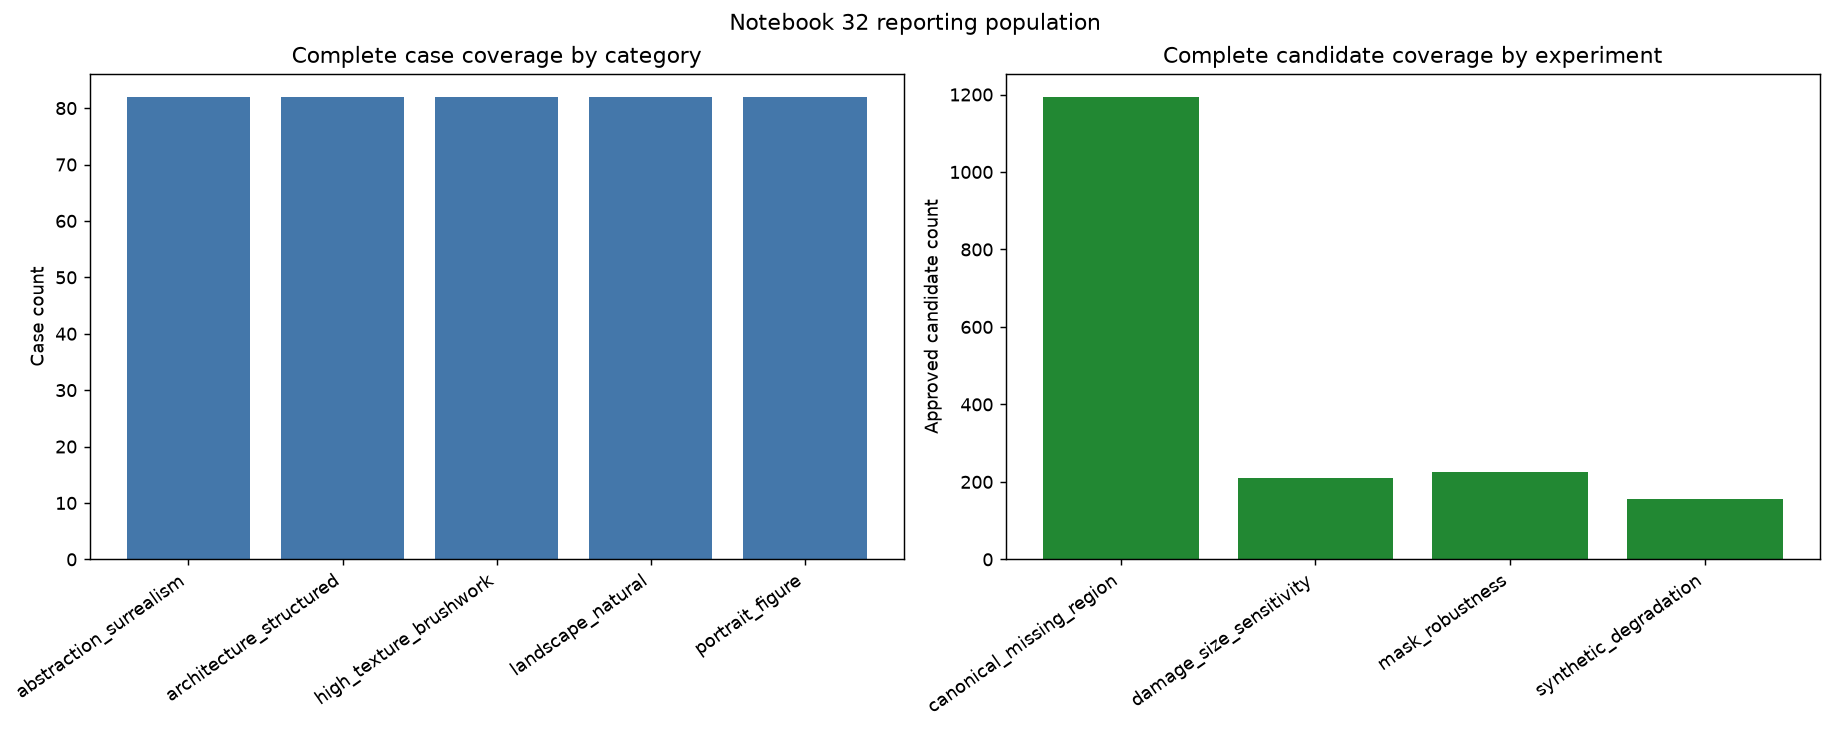
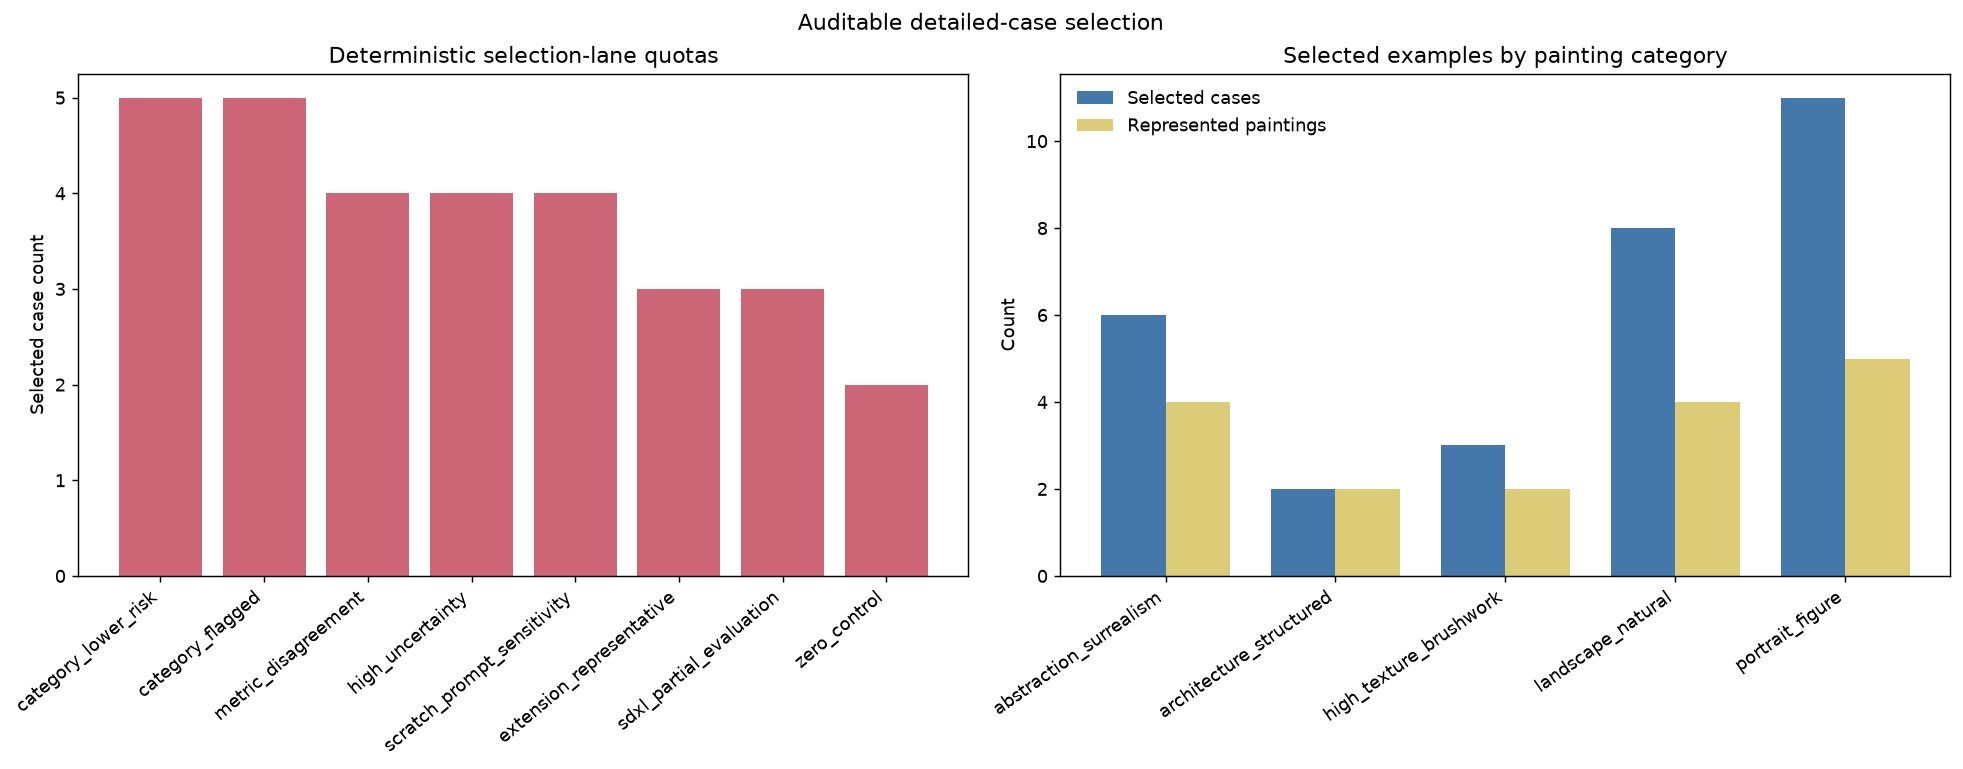

Collection index preview passed.
Painting links: 50
Case links: 30
Embedded images: 2
External image dependencies: 0
Preview file written: False


In [55]:
import re


# Make Batch 10 safely rerunnable.
VALIDATION = ValidationCollector()

for record in BATCH_9_VALIDATION.to_dict(
    orient="records"
):
    VALIDATION.add(
        validation_stage=record["validation_stage"],
        check_id=record["check_id"],
        check_description=record["check_description"],
        severity=record["severity"],
        expected=record["expected"],
        observed=record["observed"],
        passed=bool(record["passed"]),
        details=record["details"],
    )


def collection_link_table_html(
    frame: pd.DataFrame,
    *,
    display_columns: list[str],
    link_column: str,
    link_label: str,
) -> str:
    if frame.empty:
        return (
            "<p>No report links are available.</p>"
        )

    headers = (
        display_columns
        + [link_label]
    )

    header_html = "".join(
        (
            "<th>"
            f"{html_module.escape(column.replace('_', ' ').title())}"
            "</th>"
        )
        for column in headers
    )

    body_rows = []

    for _, row in frame.iterrows():
        value_cells = "".join(
            (
                "<td>"
                f"{html_module.escape(report_display_text(row[column], default=''))}"
                "</td>"
            )
            for column in display_columns
        )

        href = str(
            row[link_column]
        )

        link_cell = (
            "<td>"
            f'<a href="{html_module.escape(href, quote=True)}">'
            f"{html_module.escape(link_label)}"
            "</a>"
            "</td>"
        )

        body_rows.append(
            f"<tr>{value_cells}{link_cell}</tr>"
        )

    return (
        '<table class="report-table">'
        f"<thead><tr>{header_html}</tr></thead>"
        f"<tbody>{''.join(body_rows)}</tbody>"
        "</table>"
    )


def collection_coverage_plot_uri() -> str:
    category_rows = (
        PAINTING_CATEGORY_PROFILE
        .sort_values("category")
    )

    experiment_rows = (
        EXPERIMENT_PROFILE
        .sort_values("experiment_id")
    )

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5.5),
        constrained_layout=True,
    )

    category_positions = list(
        range(len(category_rows))
    )

    axes[0].bar(
        category_positions,
        category_rows[
            "case_count"
        ],
        color="#4477AA",
        label="Cases",
    )

    axes[0].set_xticks(
        category_positions,
        category_rows[
            "category"
        ],
        rotation=35,
        ha="right",
    )

    axes[0].set_ylabel(
        "Case count"
    )

    axes[0].set_title(
        "Complete case coverage by category"
    )

    experiment_positions = list(
        range(len(experiment_rows))
    )

    axes[1].bar(
        experiment_positions,
        experiment_rows[
            "candidate_count"
        ],
        color="#228833",
        label="Candidates",
    )

    axes[1].set_xticks(
        experiment_positions,
        experiment_rows[
            "experiment_id"
        ],
        rotation=35,
        ha="right",
    )

    axes[1].set_ylabel(
        "Approved candidate count"
    )

    axes[1].set_title(
        "Complete candidate coverage by experiment"
    )

    figure.suptitle(
        "Notebook 32 reporting population"
    )

    return figure_to_data_uri(
        figure,
        dpi=130,
    )


def collection_selection_plot_uri() -> str:
    lane_rows = (
        SELECTED_CASES
        .groupby(
            "selection_lane",
            as_index=False,
        )
        .agg(
            selected_case_count=(
                "case_id",
                "nunique",
            )
        )
    )

    lane_rows[
        "selection_order"
    ] = (
        lane_rows[
            "selection_lane"
        ]
        .map(
            {
                lane: order
                for order, lane
                in enumerate(
                    SELECTION[
                        "lane_order"
                    ]
                )
            }
        )
    )

    lane_rows = (
        lane_rows
        .sort_values(
            "selection_order"
        )
        .reset_index(drop=True)
    )

    category_rows = (
        SELECTED_CASES
        .groupby(
            "category",
            as_index=False,
        )
        .agg(
            selected_case_count=(
                "case_id",
                "nunique",
            ),
            selected_painting_count=(
                "painting_id",
                "nunique",
            ),
        )
        .sort_values("category")
        .reset_index(drop=True)
    )

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(15, 5.8),
        constrained_layout=True,
    )

    lane_positions = list(
        range(len(lane_rows))
    )

    axes[0].bar(
        lane_positions,
        lane_rows[
            "selected_case_count"
        ],
        color="#CC6677",
    )

    axes[0].set_xticks(
        lane_positions,
        lane_rows[
            "selection_lane"
        ],
        rotation=40,
        ha="right",
    )

    axes[0].set_ylabel(
        "Selected case count"
    )

    axes[0].set_title(
        "Deterministic selection-lane quotas"
    )

    category_positions = list(
        range(len(category_rows))
    )

    width = 0.38

    axes[1].bar(
        [
            value - width / 2
            for value in category_positions
        ],
        category_rows[
            "selected_case_count"
        ],
        width=width,
        color="#4477AA",
        label="Selected cases",
    )

    axes[1].bar(
        [
            value + width / 2
            for value in category_positions
        ],
        category_rows[
            "selected_painting_count"
        ],
        width=width,
        color="#DDCC77",
        label="Represented paintings",
    )

    axes[1].set_xticks(
        category_positions,
        category_rows[
            "category"
        ],
        rotation=35,
        ha="right",
    )

    axes[1].set_ylabel(
        "Count"
    )

    axes[1].set_title(
        "Selected examples by painting category"
    )

    axes[1].legend(
        frameon=False
    )

    figure.suptitle(
        "Auditable detailed-case selection"
    )

    return figure_to_data_uri(
        figure,
        dpi=130,
    )


COLLECTION_COVERAGE_VISUAL = visual_html(
    collection_coverage_plot_uri(),
    alt=(
        "Complete Notebook 32 case and candidate "
        "coverage by category and experiment"
    ),
    caption=(
        "All 410 cases and 1,785 approved candidates. "
        "These counts describe coverage and do not rank models."
    ),
    report_role="collection_coverage_plot",
    tile_count=1,
)

COLLECTION_SELECTION_VISUAL = visual_html(
    collection_selection_plot_uri(),
    alt=(
        "Deterministic detailed-case selection "
        "by lane and painting category"
    ),
    caption=(
        "The 30 detailed case reports follow the locked "
        "quota-first selection policy. Selection affects visual "
        "detail only; painting reports retain all cases."
    ),
    report_role="collection_selection_audit_plot",
    tile_count=1,
)


PAINTING_BROWSE_TABLE = (
    PAINTING_REPORT_INDEX
    .merge(
        PAINTING_REPORT_POPULATION[
            [
                "painting_id",
                "title",
                "artist",
                "selected_case_count",
            ]
        ],
        on="painting_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values("painting_id")
    .reset_index(drop=True)
)

PAINTING_BROWSE_TABLE[
    "report_href"
] = (
    "paintings/"
    + PAINTING_BROWSE_TABLE[
        "painting_id"
    ].astype(str)
    + ".html"
)

PAINTING_BROWSE_TABLE[
    "extension"
] = (
    PAINTING_BROWSE_TABLE[
        "is_extension_painting"
    ]
    .map(truthy)
    .map(
        {
            True: "yes",
            False: "no",
        }
    )
)


CASE_BROWSE_TABLE = (
    CASE_REPORT_INDEX
    .merge(
        SELECTED_CASES[
            [
                "case_id",
                "experiment_id",
                "degradation_family",
                "severity",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values("selection_order")
    .reset_index(drop=True)
)

CASE_BROWSE_TABLE[
    "report_href"
] = (
    "cases/"
    + CASE_BROWSE_TABLE[
        "case_id"
    ].astype(str)
    + ".html"
)


COLLECTION_COVERAGE_TABLE = pd.DataFrame(
    [
        {
            "population_item": "Paintings",
            "count": int(
                EXPECTED[
                    "painting_count"
                ]
            ),
            "coverage_role": (
                "Every accepted controlled-dataset painting"
            ),
        },
        {
            "population_item": "Cases",
            "count": int(
                EXPECTED[
                    "case_count"
                ]
            ),
            "coverage_role": (
                "Every approved canonical or extension case"
            ),
        },
        {
            "population_item": "Candidates",
            "count": int(
                EXPECTED[
                    "approved_candidate_count"
                ]
            ),
            "coverage_role": (
                "Complete N29 approved reporting population"
            ),
        },
        {
            "population_item": "Painting reports",
            "count": int(
                EXPECTED[
                    "painting_report_count"
                ]
            ),
            "coverage_role": (
                "Complete painting-level coverage"
            ),
        },
        {
            "population_item": "Detailed case reports",
            "count": int(
                EXPECTED[
                    "case_report_count"
                ]
            ),
            "coverage_role": (
                "Deterministically selected visual detail"
            ),
        },
    ]
)


COLLECTION_SELECTION_TABLE = (
    SELECTED_CASES
    .groupby(
        "selection_lane",
        as_index=False,
    )
    .agg(
        selected_case_count=(
            "case_id",
            "nunique",
        ),
        represented_painting_count=(
            "painting_id",
            "nunique",
        ),
        represented_category_count=(
            "category",
            "nunique",
        ),
    )
)

COLLECTION_SELECTION_TABLE[
    "approved_quota"
] = (
    COLLECTION_SELECTION_TABLE[
        "selection_lane"
    ]
    .map(
        {
            lane: int(quota)
            for lane, quota
            in SELECTION[
                "lane_quotas"
            ].items()
        }
    )
)

COLLECTION_SELECTION_TABLE[
    "selection_order"
] = (
    COLLECTION_SELECTION_TABLE[
        "selection_lane"
    ]
    .map(
        {
            lane: order
            for order, lane
            in enumerate(
                SELECTION[
                    "lane_order"
                ]
            )
        }
    )
)

COLLECTION_SELECTION_TABLE = (
    COLLECTION_SELECTION_TABLE
    .sort_values(
        "selection_order"
    )
    .drop(
        columns=[
            "selection_order"
        ]
    )
    .reset_index(drop=True)
)


COLLECTION_INDEX_SECTIONS = {
    "coverage": (
        """
<p>
This collection contains the complete Notebook 32 reporting
population: 50 paintings, 410 cases, and 1,785 approved restoration
candidates. Painting reports provide complete coverage; detailed
case reports provide deeper visual and diagnostic inspection for
30 deterministically selected cases.
</p>
"""
        + COLLECTION_COVERAGE_VISUAL
        + dataframe_html(
            COLLECTION_COVERAGE_TABLE,
            empty_message=(
                "No collection coverage "
                "summary is available."
            ),
        )
        + """
<div class="conclusion">
The report package separates complete tabular coverage from selected
visual detail. A case does not disappear from the evidence merely
because it was not selected for a detailed case report.
</div>
"""
    ),
    "selection-audit": (
        """
<p>
Detailed cases were selected through the approved quota-first rule.
The selection covers lower-risk examples, flagged cases, metric
disagreement, high uncertainty, prompt sensitivity, extension
experiments, partial SDXL evaluation, and zero controls.
</p>
"""
        + COLLECTION_SELECTION_VISUAL
        + dataframe_html(
            COLLECTION_SELECTION_TABLE,
            empty_message=(
                "No selection audit is available."
            ),
        )
        + """
<div class="limitation">
The 30 detailed reports are not a random sample and must not be used
to estimate population prevalence. Population claims must use the
complete canonical tables and painting reports.
</div>
"""
    ),
    "browse-paintings": (
        """
<p>
Each painting report summarizes every applicable damage condition,
model, metric family, stability result, failure pattern, and review
action for that painting.
</p>
"""
        + collection_link_table_html(
            PAINTING_BROWSE_TABLE,
            display_columns=[
                "painting_id",
                "title",
                "artist",
                "category",
                "case_count",
                "candidate_count",
                "extension",
                "selected_case_count",
            ],
            link_column="report_href",
            link_label="Open Painting Report",
        )
    ),
    "browse-cases": (
        """
<p>
These 30 reports contain the approved detailed visual cases. Each
report embeds its inputs, every approved restoration candidate,
diagnostic maps, metric-specific plots, flags, limitations, and
recommended human-review actions.
</p>
"""
        + collection_link_table_html(
            CASE_BROWSE_TABLE,
            display_columns=[
                "selection_order",
                "selection_lane",
                "case_id",
                "painting_id",
                "experiment_id",
                "degradation_family",
                "candidate_count",
            ],
            link_column="report_href",
            link_label="Open Case Report",
        )
    ),
    "applicability-boundaries": f"""
<ul>
<li>SDXL covers only ten candidates across ten approved cases; it is not treated as a full-population comparison.</li>
<li>Repeated-seed uncertainty applies to 115 cases and 165 prompt-specific groups. Deterministic methods are not assigned artificial diffusion uncertainty.</li>
<li>The 480 completed N11 p01–p04 context-prompt candidates remain excluded because they lack complete downstream flag and explanation coverage.</li>
<li>Candidate observations, repeated seeds, prompt arms, cases, and paintings are nested rather than independent.</li>
<li>Metric-specific better or worse results do not create a single overall model verdict.</li>
<li>Computational flags support human review and do not replace conservation expertise.</li>
</ul>
<div class="limitation">
The main limitation is the absence of expert conservation ground
truth. Visual and computational agreement can support inspection,
but cannot establish historical authenticity or approve treatment.
</div>
<p>{REPORTS["mandatory_statement"]}</p>
""",
    "thesis-contribution": """
<p>
The collection supports the thesis through three connected roles:
</p>
<ul>
<li><strong>Restoration evaluation:</strong> case reports retain classical, perceptual, feature, colour, texture, seam, semantic, spatial, and uncertainty evidence without collapsing them into one score.</li>
<li><strong>Method comparison:</strong> painting reports show where model behaviour is better, worse, stable, unstable, applicable, or inconclusive within the tested population.</li>
<li><strong>Trustworthy decision support:</strong> failure categories, flags, explanation maps, limitations, and review actions make the evaluation auditable rather than presenting plausible images alone.</li>
</ul>
<div class="conclusion">
The reporting layer does not decide whether a restoration should be
accepted. Its contribution is to make the evidence, disagreements,
coverage gaps, and need for expert judgement visible at case,
painting, and collection levels.
</div>
""",
}


COLLECTION_INDEX_HTML = render_report_html(
    title=(
        "Trustworthy Evaluation of AI-Assisted "
        "Painting Restoration"
    ),
    subtitle=(
        "Case and painting report collection — "
        "50 paintings, 410 cases, and 1,785 approved candidates"
    ),
    report_kind="collection",
    sections=COLLECTION_INDEX_SECTIONS,
    config=CONFIG,
)

COLLECTION_INDEX_CHECKS = (
    validate_report_html(
        COLLECTION_INDEX_HTML,
        report_kind="collection",
        config=CONFIG,
    )
)

collect_scoped_helper_checks(
    COLLECTION_INDEX_CHECKS,
    scope=(
        "batch_10_collection_preview"
    ),
)

EXPECTED_PAINTING_HREFS = {
    f"paintings/{painting_id}.html"
    for painting_id
    in PAINTING_REPORT_INDEX[
        "painting_id"
    ].astype(str)
}

EXPECTED_CASE_HREFS = {
    f"cases/{case_id}.html"
    for case_id
    in CASE_REPORT_INDEX[
        "case_id"
    ].astype(str)
}

EXPECTED_COLLECTION_HREFS = (
    EXPECTED_PAINTING_HREFS
    | EXPECTED_CASE_HREFS
)

OBSERVED_COLLECTION_HREFS = set(
    re.findall(
        r'href="([^"]+)"',
        COLLECTION_INDEX_HTML,
    )
)

COLLECTION_PREVIEW_CHECKS = (
    (
        "painting_link_count",
        "Collection preview contains all 50 painting links",
        int(
            EXPECTED[
                "painting_report_count"
            ]
        ),
        len(
            OBSERVED_COLLECTION_HREFS
            & EXPECTED_PAINTING_HREFS
        ),
        (
            EXPECTED_PAINTING_HREFS
            .issubset(
                OBSERVED_COLLECTION_HREFS
            )
        ),
    ),
    (
        "case_link_count",
        "Collection preview contains all 30 case links",
        int(
            EXPECTED[
                "case_report_count"
            ]
        ),
        len(
            OBSERVED_COLLECTION_HREFS
            & EXPECTED_CASE_HREFS
        ),
        (
            EXPECTED_CASE_HREFS
            .issubset(
                OBSERVED_COLLECTION_HREFS
            )
        ),
    ),
    (
        "collection_link_identity",
        "Collection preview contains only the 80 approved report links",
        sorted(
            EXPECTED_COLLECTION_HREFS
        ),
        sorted(
            OBSERVED_COLLECTION_HREFS
        ),
        (
            OBSERVED_COLLECTION_HREFS
            == EXPECTED_COLLECTION_HREFS
        ),
    ),
    (
        "collection_link_uniqueness",
        "Every collection report link is unique",
        len(
            EXPECTED_COLLECTION_HREFS
        ),
        len(
            re.findall(
                r'href="([^"]+)"',
                COLLECTION_INDEX_HTML,
            )
        ),
        (
            len(
                re.findall(
                    r'href="([^"]+)"',
                    COLLECTION_INDEX_HTML,
                )
            )
            == len(
                EXPECTED_COLLECTION_HREFS
            )
        ),
    ),
)

for (
    check_id,
    description,
    expected,
    observed,
    passed,
) in COLLECTION_PREVIEW_CHECKS:
    VALIDATION.add(
        validation_stage=(
            "batch_10_collection_preview"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=(
            ""
            if passed
            else (
                "Collection preview link "
                "validation failed."
            )
        ),
    )

VALIDATION.raise_for_blocking()

display(
    COLLECTION_INDEX_CHECKS[
        [
            "check_name",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

display(
    HTML(
        COLLECTION_INDEX_HTML
    )
)

print("Collection index preview passed.")
print(
    "Painting links:",
    len(
        EXPECTED_PAINTING_HREFS
    ),
)
print(
    "Case links:",
    len(
        EXPECTED_CASE_HREFS
    ),
)
print(
    "Embedded images:",
    COLLECTION_INDEX_HTML.count(
        "<img "
    ),
)
print("External image dependencies:", 0)
print("Preview file written:", False)

In [56]:
COLLECTION_INDEX_PATH = OUTPUT_PATHS[
    "collection_index_path"
]

atomic_write_text(
    COLLECTION_INDEX_HTML,
    COLLECTION_INDEX_PATH,
)

RELOADED_COLLECTION_HTML = (
    COLLECTION_INDEX_PATH.read_text(
        encoding="utf-8"
    )
)

RELOADED_COLLECTION_HREFS = (
    re.findall(
        r'href="([^"]+)"',
        RELOADED_COLLECTION_HTML,
    )
)

RELOADED_COLLECTION_HREF_SET = set(
    RELOADED_COLLECTION_HREFS
)

COLLECTION_LINK_TARGET_ERRORS = []

for href in RELOADED_COLLECTION_HREFS:
    raw_path = Path(href)

    if (
        raw_path.is_absolute()
        or "://" in href
        or href.startswith("//")
    ):
        COLLECTION_LINK_TARGET_ERRORS.append(
            {
                "href": href,
                "issue": (
                    "non_package_relative_link"
                ),
            }
        )
        continue

    resolved_target = (
        COLLECTION_INDEX_PATH.parent
        / raw_path
    ).resolve()

    try:
        resolved_target.relative_to(
            OUTPUT_ROOT
        )
    except ValueError:
        COLLECTION_LINK_TARGET_ERRORS.append(
            {
                "href": href,
                "issue": (
                    "link_escapes_output_root"
                ),
            }
        )
        continue

    if not resolved_target.is_file():
        COLLECTION_LINK_TARGET_ERRORS.append(
            {
                "href": href,
                "issue": (
                    "missing_link_target"
                ),
            }
        )

COLLECTION_TMP_FILES = list(
    COLLECTION_INDEX_PATH.parent.glob(
        "*.tmp"
    )
)

COLLECTION_SECTION_COUNT = (
    RELOADED_COLLECTION_HTML.count(
        'data-section-id="'
    )
)

COLLECTION_IMAGE_COUNT = (
    RELOADED_COLLECTION_HTML.count(
        "<img "
    )
)

COLLECTION_DATA_IMAGE_COUNT = (
    RELOADED_COLLECTION_HTML.count(
        'src="data:image/'
    )
)

COLLECTION_TILE_COUNT = sum(
    int(value)
    for value in re.findall(
        r'data-tile-count="(\d+)"',
        RELOADED_COLLECTION_HTML,
    )
)

COLLECTION_REPORT_FILE_COUNT = (
    len(
        PAINTING_REPORT_FILES
    )
    + len(
        CASE_REPORT_FILES
    )
    + int(
        COLLECTION_INDEX_PATH.is_file()
    )
)

CURRENT_DATA_FILES = [
    OUTPUT_PATHS[
        "selected_cases_path"
    ],
    OUTPUT_PATHS[
        "case_report_index_path"
    ],
    OUTPUT_PATHS[
        "painting_report_index_path"
    ],
]

CURRENT_PHYSICAL_OUTPUT_COUNT = (
    len(CASE_REPORT_FILES)
    + len(PAINTING_REPORT_FILES)
    + len(
        SELECTED_CASE_GRID_MANIFEST
    )
    + sum(
        path.is_file()
        for path in CURRENT_DATA_FILES
    )
    + int(
        COLLECTION_INDEX_PATH.is_file()
    )
)

COLLECTION_PERSISTENCE_CHECKS = (
    (
        "collection_file_exists",
        "Canonical collection index exists",
        True,
        COLLECTION_INDEX_PATH.is_file(),
        COLLECTION_INDEX_PATH.is_file(),
    ),
    (
        "collection_non_empty",
        "Canonical collection index is non-empty",
        True,
        COLLECTION_INDEX_PATH.stat().st_size > 0,
        COLLECTION_INDEX_PATH.stat().st_size > 0,
    ),
    (
        "collection_sections",
        "Collection index contains all six approved sections",
        len(
            REPORTS[
                "collection_sections"
            ]
        ),
        COLLECTION_SECTION_COUNT,
        (
            COLLECTION_SECTION_COUNT
            == len(
                REPORTS[
                    "collection_sections"
                ]
            )
        ),
    ),
    (
        "collection_images",
        "Collection index embeds at least two images",
        int(
            REPORTS[
                "minimum_visuals"
            ][
                "collection_index_images"
            ]
        ),
        COLLECTION_IMAGE_COUNT,
        (
            COLLECTION_IMAGE_COUNT
            >= int(
                REPORTS[
                    "minimum_visuals"
                ][
                    "collection_index_images"
                ]
            )
        ),
    ),
    (
        "collection_data_images",
        "Every collection image is embedded",
        COLLECTION_IMAGE_COUNT,
        COLLECTION_DATA_IMAGE_COUNT,
        (
            COLLECTION_DATA_IMAGE_COUNT
            == COLLECTION_IMAGE_COUNT
        ),
    ),
    (
        "collection_tiles",
        "Collection index meets its visual-tile minimum",
        int(
            REPORTS[
                "minimum_visuals"
            ][
                "collection_index_images"
            ]
        ),
        COLLECTION_TILE_COUNT,
        (
            COLLECTION_TILE_COUNT
            >= int(
                REPORTS[
                    "minimum_visuals"
                ][
                    "collection_index_images"
                ]
            )
        ),
    ),
    (
        "collection_link_count",
        "Persisted collection index contains all 80 report links",
        (
            int(
                EXPECTED[
                    "painting_report_count"
                ]
            )
            + int(
                EXPECTED[
                    "case_report_count"
                ]
            )
        ),
        len(
            RELOADED_COLLECTION_HREFS
        ),
        (
            len(
                RELOADED_COLLECTION_HREFS
            )
            == (
                int(
                    EXPECTED[
                        "painting_report_count"
                    ]
                )
                + int(
                    EXPECTED[
                        "case_report_count"
                    ]
                )
            )
        ),
    ),
    (
        "collection_link_identity",
        "Persisted report links match both canonical indexes",
        sorted(
            EXPECTED_COLLECTION_HREFS
        ),
        sorted(
            RELOADED_COLLECTION_HREF_SET
        ),
        (
            RELOADED_COLLECTION_HREF_SET
            == EXPECTED_COLLECTION_HREFS
        ),
    ),
    (
        "collection_link_targets",
        "Every collection report link resolves inside the output root",
        [],
        COLLECTION_LINK_TARGET_ERRORS,
        not COLLECTION_LINK_TARGET_ERRORS,
    ),
    (
        "collection_report_count",
        "Case, painting, and collection reports total 81",
        int(
            EXPECTED[
                "report_count"
            ]
        ),
        COLLECTION_REPORT_FILE_COUNT,
        (
            COLLECTION_REPORT_FILE_COUNT
            == int(
                EXPECTED[
                    "report_count"
                ]
            )
        ),
    ),
    (
        "collection_temporary_files",
        "Collection persistence leaves no temporary files",
        0,
        len(
            COLLECTION_TMP_FILES
        ),
        len(
            COLLECTION_TMP_FILES
        ) == 0,
    ),
    (
        "pre_manifest_physical_outputs",
        "All 114 pre-manifest physical outputs exist",
        (
            int(
                EXPECTED[
                    "physical_output_files"
                ]
            )
            - 3
        ),
        CURRENT_PHYSICAL_OUTPUT_COUNT,
        (
            CURRENT_PHYSICAL_OUTPUT_COUNT
            == (
                int(
                    EXPECTED[
                        "physical_output_files"
                    ]
                )
                - 3
            )
        ),
    ),
)

for (
    check_id,
    description,
    expected,
    observed,
    passed,
) in COLLECTION_PERSISTENCE_CHECKS:
    VALIDATION.add(
        validation_stage=(
            "batch_10_collection_persistence"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=(
            ""
            if passed
            else (
                "Persisted collection index "
                "validation failed."
            )
        ),
    )

VALIDATION.raise_for_blocking()

COLLECTION_INDEX_METADATA = pd.DataFrame(
    [
        {
            "report_path": (
                COLLECTION_INDEX_PATH
                .relative_to(
                    PROJECT_ROOT
                )
                .as_posix()
            ),
            "size_bytes": (
                COLLECTION_INDEX_PATH
                .stat()
                .st_size
            ),
            "sha256": sha256_path(
                COLLECTION_INDEX_PATH
            ),
            "section_count": (
                COLLECTION_SECTION_COUNT
            ),
            "embedded_image_count": (
                COLLECTION_IMAGE_COUNT
            ),
            "embedded_tile_count": (
                COLLECTION_TILE_COUNT
            ),
            "painting_link_count": len(
                EXPECTED_PAINTING_HREFS
            ),
            "case_link_count": len(
                EXPECTED_CASE_HREFS
            ),
            "self_contained_images": (
                COLLECTION_IMAGE_COUNT
                == COLLECTION_DATA_IMAGE_COUNT
            ),
            "status": "ok",
        }
    ]
)

display(
    COLLECTION_INDEX_METADATA
)

print("Collection index persisted and validated.")
print(
    "Collection file:",
    COLLECTION_INDEX_METADATA.iloc[0][
        "report_path"
    ],
)
print(
    "Collection size:",
    (
        f"{COLLECTION_INDEX_PATH.stat().st_size / (1024 ** 2):,.2f} MiB"
    ),
)
print(
    "Report links:",
    len(
        RELOADED_COLLECTION_HREFS
    ),
)
print(
    "Link-target errors:",
    len(
        COLLECTION_LINK_TARGET_ERRORS
    ),
)
print(
    "Temporary files:",
    len(
        COLLECTION_TMP_FILES
    ),
)

,report_path,size_bytes,sha256,section_count,embedded_image_count,embedded_tile_count,painting_link_count,case_link_count,self_contained_images,status
0,outputs/32_case_and_painting_report_generation...,291276,06bea94eb307f13ce0de07e48deb6f757e580797959964...,6,2,2,50,30,True,ok


Collection index persisted and validated.
Collection file: outputs/32_case_and_painting_report_generation/reports/index.html
Collection size: 0.28 MiB
Report links: 80
Link-target errors: 0
Temporary files: 0


In [57]:
REPORT_COLLECTION_PROFILE = pd.DataFrame(
    [
        {
            "report_kind": (
                "detailed_case"
            ),
            "report_count": len(
                CASE_REPORT_INDEX
            ),
            "represented_paintings": int(
                CASE_REPORT_INDEX[
                    "painting_id"
                ].nunique()
            ),
            "represented_cases": int(
                CASE_REPORT_INDEX[
                    "case_id"
                ].nunique()
            ),
            "represented_candidates": int(
                CASE_REPORT_INDEX[
                    "candidate_count"
                ].sum()
            ),
            "total_size_mib": round(
                float(
                    CASE_REPORT_INDEX[
                        "size_bytes"
                    ].sum()
                )
                / (1024 ** 2),
                2,
            ),
        },
        {
            "report_kind": (
                "painting"
            ),
            "report_count": len(
                PAINTING_REPORT_INDEX
            ),
            "represented_paintings": int(
                PAINTING_REPORT_INDEX[
                    "painting_id"
                ].nunique()
            ),
            "represented_cases": int(
                PAINTING_REPORT_INDEX[
                    "case_count"
                ].sum()
            ),
            "represented_candidates": int(
                PAINTING_REPORT_INDEX[
                    "candidate_count"
                ].sum()
            ),
            "total_size_mib": round(
                float(
                    PAINTING_REPORT_INDEX[
                        "size_bytes"
                    ].sum()
                )
                / (1024 ** 2),
                2,
            ),
        },
        {
            "report_kind": (
                "collection_index"
            ),
            "report_count": 1,
            "represented_paintings": int(
                EXPECTED[
                    "painting_count"
                ]
            ),
            "represented_cases": int(
                EXPECTED[
                    "case_count"
                ]
            ),
            "represented_candidates": int(
                EXPECTED[
                    "approved_candidate_count"
                ]
            ),
            "total_size_mib": round(
                float(
                    COLLECTION_INDEX_PATH
                    .stat()
                    .st_size
                )
                / (1024 ** 2),
                2,
            ),
        },
    ]
)

BATCH_10_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_10_SUMMARY = (
    VALIDATION.summary()
)

display(
    REPORT_COLLECTION_PROFILE
)

print("Batch 10 completed.")
print(
    "Detailed case reports:",
    len(CASE_REPORT_INDEX),
)
print(
    "Painting reports:",
    len(PAINTING_REPORT_INDEX),
)
print("Collection indexes:", 1)
print(
    "Total reports:",
    (
        len(CASE_REPORT_INDEX)
        + len(PAINTING_REPORT_INDEX)
        + 1
    ),
)
print(
    "Cumulative physical outputs:",
    CURRENT_PHYSICAL_OUTPUT_COUNT,
)
print(
    "Checks added in Batch 10:",
    len(BATCH_10_VALIDATION)
    - len(BATCH_9_VALIDATION),
)
print(
    "Validation summary:",
    BATCH_10_SUMMARY,
)
print(
    "Blocking failures:",
    BATCH_10_SUMMARY[
        "blocking_failure_count"
    ],
)
print(
    "Warning failures:",
    int(
        (
            BATCH_10_VALIDATION[
                "severity"
            ].eq("warning")
            & ~BATCH_10_VALIDATION[
                "passed"
            ]
        ).sum()
    ),
)
print(
    "Ready for Batch 11:",
    BATCH_10_SUMMARY[
        "overall_passed"
    ],
)

,report_kind,report_count,represented_paintings,represented_cases,represented_candidates,total_size_mib
0,detailed_case,30,17,30,195,17.00
1,painting,50,50,410,1785,44.90
2,collection_index,1,50,410,1785,0.28


Batch 10 completed.
Detailed case reports: 30
Painting reports: 50
Collection indexes: 1
Total reports: 81
Cumulative physical outputs: 114
Checks added in Batch 10: 26
Validation summary: {'check_count': 1801, 'passed_count': 1801, 'failed_count': 0, 'blocking_failure_count': 0, 'overall_passed': True, 'failed_check_ids': []}
Blocking failures: 0
Warning failures: 0
Ready for Batch 11: True


## Batch 11 — Final manifests, roadmap traceability, and completion gate

This final batch:

- verifies every Notebook 32 roadmap responsibility;
- rechecks the approved mock-to-final traceability contract;
- consolidates and persists all validation checks;
- writes the eight-record artifact manifest;
- writes the universal run manifest;
- verifies checksums, report indexes, report counts, and exact physical outputs;
- confirms that no temporary or undeclared files remain.

Notebook 32 remains a presentation and reporting layer. It creates no new restoration candidates, scientific metrics, rankings, or statistical tests.

In [58]:
# Make the final batch safely rerunnable.
VALIDATION = ValidationCollector()

for record in BATCH_10_VALIDATION.to_dict(
    orient="records"
):
    VALIDATION.add(
        validation_stage=record["validation_stage"],
        check_id=record["check_id"],
        check_description=record["check_description"],
        severity=record["severity"],
        expected=record["expected"],
        observed=record["observed"],
        passed=bool(record["passed"]),
        details=record["details"],
    )


ROADMAP_RECORDS = []


def add_roadmap_record(
    responsibility_id: str,
    responsibility: str,
    *,
    expected,
    observed,
    passed: bool,
    evidence: str,
) -> None:
    ROADMAP_RECORDS.append(
        {
            "responsibility_id": (
                responsibility_id
            ),
            "responsibility": (
                responsibility
            ),
            "expected": expected,
            "observed": observed,
            "passed": bool(passed),
            "evidence": evidence,
        }
    )


REPORT_FILES_FOR_FINAL_GATE = (
    list(CASE_REPORT_FILES)
    + list(PAINTING_REPORT_FILES)
)

MANDATORY_STATEMENT_COUNT = 0
EXTERNAL_IMAGE_DEPENDENCY_COUNT = 0
REPORT_SECTION_ERRORS = []

for report_path in (
    REPORT_FILES_FOR_FINAL_GATE
):
    report_text = report_path.read_text(
        encoding="utf-8"
    )

    if (
        REPORTS[
            "mandatory_statement"
        ]
        in report_text
    ):
        MANDATORY_STATEMENT_COUNT += 1

    EXTERNAL_IMAGE_DEPENDENCY_COUNT += len(
        re.findall(
            (
                r'<img\b[^>]*'
                r'src="(?!data:image/)'
            ),
            report_text,
            flags=re.IGNORECASE,
        )
    )

    expected_sections = (
        len(
            REPORTS[
                "case_sections"
            ]
        )
        if report_path.parent.name
        == "cases"
        else len(
            REPORTS[
                "painting_sections"
            ]
        )
    )

    observed_sections = (
        report_text.count(
            'data-section-id="'
        )
    )

    if (
        observed_sections
        != expected_sections
    ):
        REPORT_SECTION_ERRORS.append(
            {
                "report": (
                    report_path.name
                ),
                "expected_sections": (
                    expected_sections
                ),
                "observed_sections": (
                    observed_sections
                ),
            }
        )


MOCK_STATUS_VALID = (
    MOCK_TRACEABILITY[
        "implementation_status"
    ]
    .isin(
        {
            "preserved",
            "upgraded_additively",
            "approved_deviation",
        }
    )
)

MOCK_SECTION_IDENTITY_VALID = (
    MOCK_TRACEABILITY[
        "mock_section"
    ]
    .eq(
        MOCK_TRACEABILITY[
            "final_section"
        ]
    )
)

MOCK_UNEXPLAINED_DEVIATIONS = (
    MOCK_TRACEABILITY[
        "implementation_status"
    ]
    .eq("approved_deviation")
    & MOCK_TRACEABILITY[
        "deviation_reason"
    ]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
)

PRE_MANIFEST_EXCLUDED_PATHS = {
    OUTPUT_PATHS[
        "validation_path"
    ].resolve(),
    OUTPUT_PATHS[
        "artifacts_path"
    ].resolve(),
    OUTPUT_PATHS[
        "run_manifest_path"
    ].resolve(),
}

PRE_MANIFEST_OUTPUT_FILES = {
    path.resolve()
    for path
    in OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and path.resolve()
        not in PRE_MANIFEST_EXCLUDED_PATHS
    )
}

PRE_MANIFEST_TEMPORARY_FILES = sorted(
    path.relative_to(
        PROJECT_ROOT
    ).as_posix()
    for path
    in PRE_MANIFEST_OUTPUT_FILES
    if (
        ".tmp"
        in path.name.lower()
        or ".building"
        in path.name.lower()
        or path.suffix.lower()
        in {
            ".temp",
            ".part",
            ".partial",
        }
        or path.name.startswith(".")
    )
)


add_roadmap_record(
    "approved_population",
    (
        "Complete approved reporting population "
        "without incomplete context-prompt candidates"
    ),
    expected={
        "paintings": 50,
        "cases": 410,
        "candidates": 1785,
        "excluded_p01_to_p04": 0,
    },
    observed={
        "paintings": int(
            PAINTING_REPORT_INDEX[
                "painting_id"
            ].nunique()
        ),
        "cases": int(
            PAINTING_REPORT_INDEX[
                "case_count"
            ].sum()
        ),
        "candidates": int(
            PAINTING_REPORT_INDEX[
                "candidate_count"
            ].sum()
        ),
        "excluded_p01_to_p04": int(
            CANDIDATE_CATALOG[
                "prompt_variant_id"
            ]
            .isin(
                {
                    "p01",
                    "p02",
                    "p03",
                    "p04",
                }
            )
            .sum()
        ),
    },
    passed=bool(
        PAINTING_REPORT_INDEX[
            "painting_id"
        ].nunique()
        == 50
        and PAINTING_REPORT_INDEX[
            "case_count"
        ].sum()
        == 410
        and PAINTING_REPORT_INDEX[
            "candidate_count"
        ].sum()
        == 1785
        and not CANDIDATE_CATALOG[
            "prompt_variant_id"
        ]
        .isin(
            {
                "p01",
                "p02",
                "p03",
                "p04",
            }
        )
        .any()
    ),
    evidence=(
        "N29 approved explanation catalog and "
        "N32 painting-report index"
    ),
)

add_roadmap_record(
    "auditable_case_selection",
    "Rule-based auditable detailed-case selection",
    expected={
        "selected_cases": 30,
        "lane_quotas": {
            key: int(value)
            for key, value
            in SELECTION[
                "lane_quotas"
            ].items()
        },
    },
    observed={
        "selected_cases": len(
            SELECTED_CASES
        ),
        "lane_quotas": {
            key: int(value)
            for key, value
            in SELECTED_CASES[
                "selection_lane"
            ]
            .value_counts()
            .to_dict()
            .items()
        },
    },
    passed=bool(
        len(SELECTED_CASES)
        == int(
            EXPECTED[
                "selected_case_count"
            ]
        )
        and (
            SELECTED_CASES[
                "selection_lane"
            ]
            .value_counts()
            .to_dict()
            == {
                key: int(value)
                for key, value
                in SELECTION[
                    "lane_quotas"
                ].items()
            }
        )
    ),
    evidence=(
        "data/selected_cases.csv and "
        "selection-lane validation"
    ),
)

add_roadmap_record(
    "detailed_case_reports",
    (
        "Detailed case reports include complete "
        "candidate and diagnostic evidence"
    ),
    expected={
        "reports": 30,
        "sections_per_report": 13,
        "minimum_images": 7,
        "minimum_tiles": 20,
    },
    observed={
        "reports": len(
            CASE_REPORT_INDEX
        ),
        "section_values": sorted(
            CASE_REPORT_INDEX[
                "section_count"
            ]
            .astype(int)
            .unique()
            .tolist()
        ),
        "minimum_images": int(
            CASE_REPORT_INDEX[
                "embedded_image_count"
            ].min()
        ),
        "minimum_tiles": int(
            CASE_REPORT_INDEX[
                "embedded_tile_count"
            ].min()
        ),
    },
    passed=bool(
        len(CASE_REPORT_INDEX)
        == 30
        and CASE_REPORT_INDEX[
            "section_count"
        ]
        .astype(int)
        .eq(13)
        .all()
        and CASE_REPORT_INDEX[
            "embedded_image_count"
        ]
        .astype(int)
        .ge(7)
        .all()
        and CASE_REPORT_INDEX[
            "embedded_tile_count"
        ]
        .astype(int)
        .ge(20)
        .all()
    ),
    evidence=(
        "reports/cases, case_report_index.csv, "
        "and 30 selected-case grids"
    ),
)

add_roadmap_record(
    "painting_reports",
    (
        "Per-painting reports summarize every "
        "relevant case and candidate"
    ),
    expected={
        "reports": 50,
        "cases": 410,
        "candidates": 1785,
        "sections_per_report": 11,
    },
    observed={
        "reports": len(
            PAINTING_REPORT_INDEX
        ),
        "cases": int(
            PAINTING_REPORT_INDEX[
                "case_count"
            ].sum()
        ),
        "candidates": int(
            PAINTING_REPORT_INDEX[
                "candidate_count"
            ].sum()
        ),
        "section_values": sorted(
            PAINTING_REPORT_INDEX[
                "section_count"
            ]
            .astype(int)
            .unique()
            .tolist()
        ),
    },
    passed=bool(
        len(PAINTING_REPORT_INDEX)
        == 50
        and PAINTING_REPORT_INDEX[
            "case_count"
        ].sum()
        == 410
        and PAINTING_REPORT_INDEX[
            "candidate_count"
        ].sum()
        == 1785
        and PAINTING_REPORT_INDEX[
            "section_count"
        ]
        .astype(int)
        .eq(11)
        .all()
    ),
    evidence=(
        "reports/paintings and "
        "painting_report_index.csv"
    ),
)

add_roadmap_record(
    "metric_and_diagnostic_evidence",
    (
        "Classical, perceptual, feature, texture, "
        "colour, seam, spatial, semantic, and "
        "structural evidence remains represented"
    ),
    expected={
        "metric_anchors": 8,
        "case_traceability_roles": 33,
        "painting_traceability_roles": 24,
    },
    observed={
        "metric_anchors": len(
            METRIC_ANCHOR_SPECS
        ),
        "case_traceability_roles": int(
            MOCK_TRACEABILITY[
                "report_kind"
            ]
            .eq("case_report")
            .sum()
        ),
        "painting_traceability_roles": int(
            MOCK_TRACEABILITY[
                "report_kind"
            ]
            .eq("painting_report")
            .sum()
        ),
    },
    passed=bool(
        len(METRIC_ANCHOR_SPECS)
        == 8
        and MOCK_TRACEABILITY[
            "report_kind"
        ]
        .eq("case_report")
        .sum()
        == int(
            EXPECTED[
                "case_traceability_rows"
            ]
        )
        and MOCK_TRACEABILITY[
            "report_kind"
        ]
        .eq("painting_report")
        .sum()
        == int(
            EXPECTED[
                "painting_traceability_rows"
            ]
        )
    ),
    evidence=(
        "N13–N20 canonical evidence, "
        "metric-specific painting anchors, and "
        "mock-to-final traceability"
    ),
)

add_roadmap_record(
    "uncertainty_and_prompt_scope",
    (
        "Uncertainty and prompt sensitivity retain "
        "their approved applicability boundaries"
    ),
    expected={
        "uncertainty_cases": 115,
        "uncertainty_groups": 165,
    },
    observed={
        "uncertainty_cases": int(
            CASE_SUMMARY[
                "has_uncertainty"
            ]
            .map(truthy)
            .sum()
        ),
        "uncertainty_groups": int(
            CASE_SUMMARY[
                "uncertainty_group_count"
            ].sum()
        ),
    },
    passed=bool(
        CASE_SUMMARY[
            "has_uncertainty"
        ]
        .map(truthy)
        .sum()
        == int(
            EXPECTED[
                "uncertainty_case_count"
            ]
        )
        and CASE_SUMMARY[
            "uncertainty_group_count"
        ].sum()
        == int(
            EXPECTED[
                "uncertainty_group_count"
            ]
        )
    ),
    evidence=(
        "N18, N19, and N22 uncertainty evidence "
        "with explicit deterministic and SDXL limits"
    ),
)

add_roadmap_record(
    "failure_flags_and_review",
    (
        "Failure classifications, flags, limitations, "
        "and human-review actions remain visible"
    ),
    expected={
        "reports_with_statement": 80,
        "failure_rows": 24990,
        "flag_rows": 19635,
    },
    observed={
        "reports_with_statement": (
            MANDATORY_STATEMENT_COUNT
        ),
        "failure_rows": len(
            FAILURE_ASSIGNMENTS_ALL
        ),
        "flag_rows": len(
            TRUSTWORTHINESS_FLAGS_ALL
        ),
    },
    passed=bool(
        MANDATORY_STATEMENT_COUNT
        == 80
        and len(
            FAILURE_ASSIGNMENTS_ALL
        )
        == 24990
        and len(
            TRUSTWORTHINESS_FLAGS_ALL
        )
        == 19635
    ),
    evidence=(
        "N27 failure and flag catalogs plus "
        "all 80 case and painting reports"
    ),
)

add_roadmap_record(
    "mock_fidelity",
    (
        "Approved case, painting, and collection "
        "mock structures remain traceable"
    ),
    expected={
        "rows": 67,
        "invalid_statuses": 0,
        "section_mismatches": 0,
        "unexplained_deviations": 0,
    },
    observed={
        "rows": len(
            MOCK_TRACEABILITY
        ),
        "invalid_statuses": int(
            (
                ~MOCK_STATUS_VALID
            ).sum()
        ),
        "section_mismatches": int(
            (
                ~MOCK_SECTION_IDENTITY_VALID
            ).sum()
        ),
        "unexplained_deviations": int(
            MOCK_UNEXPLAINED_DEVIATIONS.sum()
        ),
    },
    passed=bool(
        len(MOCK_TRACEABILITY)
        == int(
            EXPECTED[
                "traceability_rows"
            ]
        )
        and MOCK_STATUS_VALID.all()
        and MOCK_SECTION_IDENTITY_VALID.all()
        and not MOCK_UNEXPLAINED_DEVIATIONS.any()
    ),
    evidence=(
        "67-row in-memory mock-to-final "
        "traceability registry"
    ),
)

add_roadmap_record(
    "standalone_portability",
    (
        "Case and painting reports contain no "
        "external image dependencies"
    ),
    expected={
        "reports": 80,
        "external_images": 0,
        "section_errors": 0,
    },
    observed={
        "reports": len(
            REPORT_FILES_FOR_FINAL_GATE
        ),
        "external_images": (
            EXTERNAL_IMAGE_DEPENDENCY_COUNT
        ),
        "section_errors": len(
            REPORT_SECTION_ERRORS
        ),
    },
    passed=bool(
        len(
            REPORT_FILES_FOR_FINAL_GATE
        )
        == 80
        and EXTERNAL_IMAGE_DEPENDENCY_COUNT
        == 0
        and not REPORT_SECTION_ERRORS
    ),
    evidence=(
        "Embedded data-URI image inspection "
        "across all case and painting reports"
    ),
)

add_roadmap_record(
    "collection_entry_point",
    (
        "Collection index exposes every painting "
        "and detailed case report"
    ),
    expected={
        "collection_indexes": 1,
        "painting_links": 50,
        "case_links": 30,
        "link_errors": 0,
    },
    observed={
        "collection_indexes": int(
            COLLECTION_INDEX_PATH.is_file()
        ),
        "painting_links": len(
            EXPECTED_PAINTING_HREFS
        ),
        "case_links": len(
            EXPECTED_CASE_HREFS
        ),
        "link_errors": len(
            COLLECTION_LINK_TARGET_ERRORS
        ),
    },
    passed=bool(
        COLLECTION_INDEX_PATH.is_file()
        and len(
            EXPECTED_PAINTING_HREFS
        )
        == 50
        and len(
            EXPECTED_CASE_HREFS
        )
        == 30
        and not COLLECTION_LINK_TARGET_ERRORS
    ),
    evidence=(
        "reports/index.html with 80 validated "
        "package-relative report links"
    ),
)

add_roadmap_record(
    "output_standardization",
    (
        "Notebook-owned outputs follow the exact "
        "pre-manifest physical-file contract"
    ),
    expected={
        "pre_manifest_files": 114,
        "temporary_files": 0,
        "final_files": 117,
        "artifact_records": 8,
    },
    observed={
        "pre_manifest_files": len(
            PRE_MANIFEST_OUTPUT_FILES
        ),
        "temporary_files": len(
            PRE_MANIFEST_TEMPORARY_FILES
        ),
        "final_files": int(
            EXPECTED[
                "physical_output_files"
            ]
        ),
        "artifact_records": int(
            EXPECTED[
                "artifact_records"
            ]
        ),
    },
    passed=bool(
        len(
            PRE_MANIFEST_OUTPUT_FILES
        )
        == (
            int(
                EXPECTED[
                    "physical_output_files"
                ]
            )
            - 3
        )
        and not PRE_MANIFEST_TEMPORARY_FILES
        and int(
            EXPECTED[
                "physical_output_files"
            ]
        )
        == 117
        and int(
            EXPECTED[
                "artifact_records"
            ]
        )
        == 8
    ),
    evidence=(
        "Notebook 32 output contract and "
        "recursive pre-manifest file audit"
    ),
)

add_roadmap_record(
    "presentation_only_policy",
    (
        "Report generation creates no new "
        "scientific evidence"
    ),
    expected=False,
    observed=bool(
        EVIDENCE_POLICY[
            "creates_new_scientific_evidence"
        ]
    ),
    passed=bool(
        not EVIDENCE_POLICY[
            "creates_new_scientific_evidence"
        ]
    ),
    evidence=(
        "Presentation-only filtering, grouping, "
        "formatting, plotting, and HTML assembly"
    ),
)


ROADMAP_TRACEABILITY = pd.DataFrame(
    ROADMAP_RECORDS
)

ROADMAP_FAILURES = int(
    (
        ~ROADMAP_TRACEABILITY[
            "passed"
        ].astype(bool)
    ).sum()
)

FINAL_TRACEABILITY_CHECKS = (
    (
        "roadmap_responsibility_completion",
        "Every Notebook 32 roadmap responsibility has passing evidence",
        0,
        ROADMAP_FAILURES,
        ROADMAP_FAILURES == 0,
    ),
    (
        "mock_traceability_final_contract",
        "All 67 approved mock roles remain represented",
        {
            "rows": 67,
            "invalid_statuses": 0,
            "section_mismatches": 0,
            "unexplained_deviations": 0,
        },
        {
            "rows": len(
                MOCK_TRACEABILITY
            ),
            "invalid_statuses": int(
                (
                    ~MOCK_STATUS_VALID
                ).sum()
            ),
            "section_mismatches": int(
                (
                    ~MOCK_SECTION_IDENTITY_VALID
                ).sum()
            ),
            "unexplained_deviations": int(
                MOCK_UNEXPLAINED_DEVIATIONS.sum()
            ),
        },
        (
            len(MOCK_TRACEABILITY) == 67
            and MOCK_STATUS_VALID.all()
            and MOCK_SECTION_IDENTITY_VALID.all()
            and not MOCK_UNEXPLAINED_DEVIATIONS.any()
        ),
    ),
    (
        "pre_manifest_output_count",
        "Exactly 114 non-manifest outputs exist before final persistence",
        114,
        len(
            PRE_MANIFEST_OUTPUT_FILES
        ),
        len(
            PRE_MANIFEST_OUTPUT_FILES
        ) == 114,
    ),
    (
        "pre_manifest_temporary_files",
        "No temporary output files remain",
        [],
        PRE_MANIFEST_TEMPORARY_FILES,
        not PRE_MANIFEST_TEMPORARY_FILES,
    ),
)

for (
    check_id,
    description,
    expected,
    observed,
    passed,
) in FINAL_TRACEABILITY_CHECKS:
    VALIDATION.add(
        validation_stage=(
            "batch_11_final_traceability"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=(
            ""
            if passed
            else (
                "Final roadmap or output "
                "traceability failed."
            )
        ),
    )

PRE_MANIFEST_VALIDATION = (
    VALIDATION.to_dataframe()
)

PRE_MANIFEST_BLOCKING_FAILURES = int(
    (
        PRE_MANIFEST_VALIDATION[
            "severity"
        ].eq("blocking")
        & ~PRE_MANIFEST_VALIDATION[
            "passed"
        ]
    ).sum()
)

PRE_MANIFEST_WARNING_FAILURES = int(
    (
        PRE_MANIFEST_VALIDATION[
            "severity"
        ].eq("warning")
        & ~PRE_MANIFEST_VALIDATION[
            "passed"
        ]
    ).sum()
)

VALIDATION.add(
    validation_stage=(
        "batch_11_final_traceability"
    ),
    check_id=(
        "pre_manifest_validation_gate"
    ),
    check_description=(
        "All report, portability, traceability, "
        "and scientific checks pass before manifest writing"
    ),
    severity="blocking",
    expected={
        "blocking_failures": 0,
        "warning_failures": 0,
    },
    observed={
        "blocking_failures": (
            PRE_MANIFEST_BLOCKING_FAILURES
        ),
        "warning_failures": (
            PRE_MANIFEST_WARNING_FAILURES
        ),
    },
    passed=bool(
        PRE_MANIFEST_BLOCKING_FAILURES
        == 0
        and PRE_MANIFEST_WARNING_FAILURES
        == 0
    ),
    details=(
        ""
        if (
            PRE_MANIFEST_BLOCKING_FAILURES
            == 0
            and PRE_MANIFEST_WARNING_FAILURES
            == 0
        )
        else (
            "A validation failure remains before "
            "manifest persistence."
        )
    ),
)

VALIDATION.raise_for_blocking()

display(
    ROADMAP_TRACEABILITY
)

print("Final roadmap traceability passed.")
print(
    "Roadmap responsibilities:",
    len(ROADMAP_TRACEABILITY),
)
print(
    "Roadmap failures:",
    ROADMAP_FAILURES,
)
print(
    "Mock traceability rows:",
    len(MOCK_TRACEABILITY),
)
print(
    "Pre-manifest physical files:",
    len(PRE_MANIFEST_OUTPUT_FILES),
)
print(
    "Pre-manifest temporary files:",
    len(PRE_MANIFEST_TEMPORARY_FILES),
)

,responsibility_id,responsibility,expected,observed,passed,evidence
0,approved_population,Complete approved reporting population without...,"{'paintings': 50, 'cases': 410, 'candidates': ...","{'paintings': 50, 'cases': 410, 'candidates': ...",True,N29 approved explanation catalog and N32 paint...
1,auditable_case_selection,Rule-based auditable detailed-case selection,"{'selected_cases': 30, 'lane_quotas': {'catego...","{'selected_cases': 30, 'lane_quotas': {'catego...",True,data/selected_cases.csv and selection-lane val...
2,detailed_case_reports,Detailed case reports include complete candida...,"{'reports': 30, 'sections_per_report': 13, 'mi...","{'reports': 30, 'section_values': [13], 'minim...",True,"reports/cases, case_report_index.csv, and 30 s..."
3,painting_reports,Per-painting reports summarize every relevant ...,"{'reports': 50, 'cases': 410, 'candidates': 17...","{'reports': 50, 'cases': 410, 'candidates': 17...",True,reports/paintings and painting_report_index.csv
4,metric_and_diagnostic_evidence,"Classical, perceptual, feature, texture, colou...","{'metric_anchors': 8, 'case_traceability_roles...","{'metric_anchors': 8, 'case_traceability_roles...",True,"N13–N20 canonical evidence, metric-specific pa..."
5,uncertainty_and_prompt_scope,Uncertainty and prompt sensitivity retain thei...,"{'uncertainty_cases': 115, 'uncertainty_groups...","{'uncertainty_cases': 115, 'uncertainty_groups...",True,"N18, N19, and N22 uncertainty evidence with ex..."
6,failure_flags_and_review,"Failure classifications, flags, limitations, a...","{'reports_with_statement': 80, 'failure_rows':...","{'reports_with_statement': 80, 'failure_rows':...",True,N27 failure and flag catalogs plus all 80 case...
7,mock_fidelity,"Approved case, painting, and collection mock s...","{'rows': 67, 'invalid_statuses': 0, 'section_m...","{'rows': 67, 'invalid_statuses': 0, 'section_m...",True,67-row in-memory mock-to-final traceability re...
8,standalone_portability,Case and painting reports contain no external ...,"{'reports': 80, 'external_images': 0, 'section...","{'reports': 80, 'external_images': 0, 'section...",True,Embedded data-URI image inspection across all ...
9,collection_entry_point,Collection index exposes every painting and de...,"{'collection_indexes': 1, 'painting_links': 50...","{'collection_indexes': 1, 'painting_links': 50...",True,reports/index.html with 80 validated package-r...


Final roadmap traceability passed.
Roadmap responsibilities: 12
Roadmap failures: 0
Mock traceability rows: 67
Pre-manifest physical files: 114
Pre-manifest temporary files: 0


In [59]:
from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    sha256_file,
    sha256_path,
    utc_now_iso,
)


FINAL_VALIDATION = (
    VALIDATION.to_dataframe()
)

FINAL_VALIDATION_SUMMARY = (
    VALIDATION.summary()
)

atomic_write_csv(
    FINAL_VALIDATION,
    OUTPUT_PATHS[
        "validation_path"
    ],
)


ARTIFACT_RECORD_PAYLOADS = [
    build_artifact_record(
        artifact_key=(
            "case_painting_reports.selected_cases"
        ),
        producer_notebook=(
            SETTINGS[
                "notebook_stem"
            ]
        ),
        path=OUTPUT_PATHS[
            "selected_cases_path"
        ],
        artifact_type=(
            "normalized_selection_table"
        ),
        artifact_role=(
            "deterministic_detailed_case_selection"
        ),
        schema_version=SETTINGS[
            "selected_cases_schema_version"
        ],
        dataset_scope=SETTINGS[
            "dataset_scope"
        ],
        experiment_id=(
            "case_painting_report_generation"
        ),
        row_count=len(
            SELECTED_CASES
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "case_painting_reports.case_report_index"
        ),
        producer_notebook=(
            SETTINGS[
                "notebook_stem"
            ]
        ),
        path=OUTPUT_PATHS[
            "case_report_index_path"
        ],
        artifact_type=(
            "normalized_report_index"
        ),
        artifact_role=(
            "detailed_case_report_registry"
        ),
        schema_version=SETTINGS[
            "case_report_index_schema_version"
        ],
        dataset_scope=SETTINGS[
            "dataset_scope"
        ],
        experiment_id=(
            "case_painting_report_generation"
        ),
        row_count=len(
            CASE_REPORT_INDEX
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "case_painting_reports.painting_report_index"
        ),
        producer_notebook=(
            SETTINGS[
                "notebook_stem"
            ]
        ),
        path=OUTPUT_PATHS[
            "painting_report_index_path"
        ],
        artifact_type=(
            "normalized_report_index"
        ),
        artifact_role=(
            "complete_painting_report_registry"
        ),
        schema_version=SETTINGS[
            "painting_report_index_schema_version"
        ],
        dataset_scope=SETTINGS[
            "dataset_scope"
        ],
        experiment_id=(
            "case_painting_report_generation"
        ),
        row_count=len(
            PAINTING_REPORT_INDEX
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "case_painting_reports.case_reports"
        ),
        producer_notebook=(
            SETTINGS[
                "notebook_stem"
            ]
        ),
        path=OUTPUT_PATHS[
            "case_reports_dir"
        ],
        artifact_type=(
            "standalone_html_report_collection"
        ),
        artifact_role=(
            "thirty_detailed_case_reports"
        ),
        schema_version=(
            "case_report_collection.v1"
        ),
        dataset_scope=SETTINGS[
            "dataset_scope"
        ],
        experiment_id=(
            "case_painting_report_generation"
        ),
        row_count=len(
            CASE_REPORT_INDEX
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "case_painting_reports.painting_reports"
        ),
        producer_notebook=(
            SETTINGS[
                "notebook_stem"
            ]
        ),
        path=OUTPUT_PATHS[
            "painting_reports_dir"
        ],
        artifact_type=(
            "standalone_html_report_collection"
        ),
        artifact_role=(
            "fifty_complete_painting_reports"
        ),
        schema_version=(
            "painting_report_collection.v1"
        ),
        dataset_scope=SETTINGS[
            "dataset_scope"
        ],
        experiment_id=(
            "case_painting_report_generation"
        ),
        row_count=len(
            PAINTING_REPORT_INDEX
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "case_painting_reports.collection_index"
        ),
        producer_notebook=(
            SETTINGS[
                "notebook_stem"
            ]
        ),
        path=OUTPUT_PATHS[
            "collection_index_path"
        ],
        artifact_type=(
            "html_report_collection_entry_point"
        ),
        artifact_role=(
            "browse_all_case_and_painting_reports"
        ),
        schema_version=(
            "report_collection_index.v1"
        ),
        dataset_scope=SETTINGS[
            "dataset_scope"
        ],
        experiment_id=(
            "case_painting_report_generation"
        ),
        row_count=1,
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "case_painting_reports.selected_case_grids"
        ),
        producer_notebook=(
            SETTINGS[
                "notebook_stem"
            ]
        ),
        path=OUTPUT_PATHS[
            "selected_case_grids_dir"
        ],
        artifact_type=(
            "diagnostic_grid_collection"
        ),
        artifact_role=(
            "canonical_visual_grids_for_selected_cases"
        ),
        schema_version=(
            "selected_case_grid_collection.v1"
        ),
        dataset_scope=SETTINGS[
            "dataset_scope"
        ],
        experiment_id=(
            "case_painting_report_generation"
        ),
        row_count=len(
            SELECTED_CASE_GRID_MANIFEST
        ),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key=(
            "case_painting_reports.validation"
        ),
        producer_notebook=(
            SETTINGS[
                "notebook_stem"
            ]
        ),
        path=OUTPUT_PATHS[
            "validation_path"
        ],
        artifact_type=(
            "validation_table"
        ),
        artifact_role=(
            "consolidated_notebook_validation_checks"
        ),
        schema_version=(
            "validation_checks.v1"
        ),
        dataset_scope=SETTINGS[
            "dataset_scope"
        ],
        experiment_id=(
            "case_painting_report_generation"
        ),
        row_count=len(
            FINAL_VALIDATION
        ),
        project_root=PROJECT_ROOT,
    ),
]

FINAL_ARTIFACT_RECORDS = (
    artifact_records_dataframe(
        ARTIFACT_RECORD_PAYLOADS
    )
)

if (
    len(FINAL_ARTIFACT_RECORDS)
    != int(
        EXPECTED[
            "artifact_records"
        ]
    )
):
    raise ValueError(
        "Final artifact-record count changed: "
        f"{len(FINAL_ARTIFACT_RECORDS)}."
    )

atomic_write_csv(
    FINAL_ARTIFACT_RECORDS,
    OUTPUT_PATHS[
        "artifacts_path"
    ],
)


EXPECTED_FINAL_PATHS = {
    path.resolve()
    for path
    in (
        list(CASE_REPORT_FILES)
        + list(PAINTING_REPORT_FILES)
        + list(
            SELECTED_CASE_GRID_DIRECTORY.glob(
                "*.png"
            )
        )
        + [
            OUTPUT_PATHS[
                "selected_cases_path"
            ],
            OUTPUT_PATHS[
                "case_report_index_path"
            ],
            OUTPUT_PATHS[
                "painting_report_index_path"
            ],
            OUTPUT_PATHS[
                "collection_index_path"
            ],
            OUTPUT_PATHS[
                "validation_path"
            ],
            OUTPUT_PATHS[
                "artifacts_path"
            ],
            OUTPUT_PATHS[
                "run_manifest_path"
            ],
        ]
    )
}

if (
    len(EXPECTED_FINAL_PATHS)
    != int(
        EXPECTED[
            "physical_output_files"
        ]
    )
):
    raise ValueError(
        "Declared final physical-file set changed: "
        f"{len(EXPECTED_FINAL_PATHS)}."
    )


MANIFEST_INPUT_RECORDS = []

for input_key, input_path in sorted(
    INPUT_PATHS.items()
):
    MANIFEST_INPUT_RECORDS.append(
        {
            "input_key": input_key,
            "relative_path": (
                input_path
                .relative_to(
                    PROJECT_ROOT
                )
                .as_posix()
            ),
            "checksum": sha256_file(
                input_path
            ),
        }
    )


MANIFEST_OUTPUT_RECORDS = []

for output_path in sorted(
    EXPECTED_FINAL_PATHS,
    key=lambda path:
    path.as_posix(),
):
    relative_path = (
        output_path
        .relative_to(
            PROJECT_ROOT
        )
        .as_posix()
    )

    suffix = (
        output_path.suffix
        .lower()
        .lstrip(".")
    )

    artifact_type = {
        "html": "html_report",
        "csv": "csv",
        "json": "json",
        "png": "png_figure",
    }.get(
        suffix,
        suffix or "file",
    )

    artifact_key = (
        "output."
        + output_path
        .relative_to(
            OUTPUT_ROOT
        )
        .as_posix()
        .replace("/", ".")
    )

    MANIFEST_OUTPUT_RECORDS.append(
        {
            "artifact_key": (
                artifact_key
            ),
            "relative_path": (
                relative_path
            ),
            "artifact_type": (
                artifact_type
            ),
        }
    )


CONFIGURATION_PATHS = [
    CONFIG_PATH,
]

CONFIGURATION_CHECKSUMS = (
    configuration_checksums(
        CONFIGURATION_PATHS,
        PROJECT_ROOT,
    )
)

RUN_COMPLETED_AT_UTC = (
    utc_now_iso()
)

OBSERVED_COUNTS = {
    "painting_count": int(
        PAINTING_REPORT_INDEX[
            "painting_id"
        ].nunique()
    ),
    "case_count": int(
        PAINTING_REPORT_INDEX[
            "case_count"
        ].sum()
    ),
    "approved_candidate_count": int(
        PAINTING_REPORT_INDEX[
            "candidate_count"
        ].sum()
    ),
    "selected_case_count": len(
        SELECTED_CASES
    ),
    "case_report_count": len(
        CASE_REPORT_INDEX
    ),
    "painting_report_count": len(
        PAINTING_REPORT_INDEX
    ),
    "collection_index_count": 1,
    "report_count": (
        len(CASE_REPORT_INDEX)
        + len(PAINTING_REPORT_INDEX)
        + 1
    ),
    "selected_case_grid_count": len(
        SELECTED_CASE_GRID_MANIFEST
    ),
    "case_report_index_rows": len(
        CASE_REPORT_INDEX
    ),
    "painting_report_index_rows": len(
        PAINTING_REPORT_INDEX
    ),
    "artifact_records": len(
        FINAL_ARTIFACT_RECORDS
    ),
    "validation_rows": len(
        FINAL_VALIDATION
    ),
    "mock_traceability_rows": len(
        MOCK_TRACEABILITY
    ),
    "roadmap_responsibilities": len(
        ROADMAP_TRACEABILITY
    ),
    "embedded_image_count": int(
        CASE_REPORT_INDEX[
            "embedded_image_count"
        ].sum()
        + PAINTING_REPORT_INDEX[
            "embedded_image_count"
        ].sum()
        + COLLECTION_INDEX_METADATA.iloc[0][
            "embedded_image_count"
        ]
    ),
    "embedded_tile_count": int(
        CASE_REPORT_INDEX[
            "embedded_tile_count"
        ].sum()
        + PAINTING_REPORT_INDEX[
            "embedded_tile_count"
        ].sum()
        + COLLECTION_INDEX_METADATA.iloc[0][
            "embedded_tile_count"
        ]
    ),
    "physical_output_files": len(
        EXPECTED_FINAL_PATHS
    ),
}

FINAL_RUN_MANIFEST = build_run_manifest(
    notebook_id=SETTINGS[
        "notebook_id"
    ],
    notebook_name=SETTINGS[
        "notebook_stem"
    ],
    origin=(
        "Existing Previous Version of "
        "Notebook 33, Pre-refactor"
    ),
    run_status="completed",
    started_at_utc=(
        RUN_STARTED_AT_UTC
    ),
    completed_at_utc=(
        RUN_COMPLETED_AT_UTC
    ),
    inventory_run_id=str(
        INVENTORY_RUN[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "dataset_id": SETTINGS[
            "dataset_id"
        ],
        "dataset_version": SETTINGS[
            "dataset_version"
        ],
        "dataset_scope": SETTINGS[
            "dataset_scope"
        ],
        "configuration_version": CONFIG[
            "config_version"
        ],
        "configuration_schema_version": (
            CONFIG_SCHEMA_VERSION
        ),
        "selected_cases_schema_version": (
            SETTINGS[
                "selected_cases_schema_version"
            ]
        ),
        "case_report_index_schema_version": (
            SETTINGS[
                "case_report_index_schema_version"
            ]
        ),
        "painting_report_index_schema_version": (
            SETTINGS[
                "painting_report_index_schema_version"
            ]
        ),
        "mock_traceability_schema_version": (
            SETTINGS[
                "traceability_schema_version"
            ]
        ),
        "upstream_run_ids": (
            UPSTREAM_RUN_IDS
        ),
    },
    configuration_paths=[
        path.relative_to(
            PROJECT_ROOT
        ).as_posix()
        for path
        in CONFIGURATION_PATHS
    ],
    configuration_checksums_by_path=(
        CONFIGURATION_CHECKSUMS
    ),
    helper_versions={
        "case_painting_reports": (
            CASE_PAINTING_REPORTS_MODULE_VERSION
        ),
        "validation": (
            VALIDATION_MODULE_VERSION
        ),
        "paths": (
            PATHS_MODULE_VERSION
        ),
        "case_report_index_schema": (
            SETTINGS[
                "case_report_index_schema_version"
            ]
        ),
        "painting_report_index_schema": (
            SETTINGS[
                "painting_report_index_schema_version"
            ]
        ),
    },
    inputs=MANIFEST_INPUT_RECORDS,
    outputs=MANIFEST_OUTPUT_RECORDS,
    expected_counts=dict(
        EXPECTED
    ),
    observed_counts=(
        OBSERVED_COUNTS
    ),
    validation_summary=(
        FINAL_VALIDATION_SUMMARY
    ),
    known_limitations=[
        (
            "Visual plausibility does not establish "
            "historical authenticity or conservation validity."
        ),
        (
            "The controlled damage protocols do not reproduce "
            "all physical deterioration processes."
        ),
        (
            "Repeated diffusion candidates and prompt variants "
            "are nested within cases and paintings."
        ),
        (
            "SDXL evidence is limited to ten candidates "
            "across five paintings."
        ),
        (
            "Repeated-seed uncertainty is empirical "
            "variability rather than calibrated confidence."
        ),
        (
            "Pretrained perceptual and semantic models are "
            "not conservation-specific."
        ),
        (
            "Detailed case reports are selected for diagnostic "
            "coverage and are not a random prevalence sample."
        ),
    ],
    project_root=PROJECT_ROOT,
    package_names=(
        "pandas",
        "matplotlib",
        "Pillow",
        "PyYAML",
    ),
    hardware={
        "analysis_mode": (
            "presentation_only_case_and_painting_reports"
        ),
        "restoration_inference_performed": False,
        "new_metric_computation_performed": False,
        "new_statistical_test_performed": False,
        "self_contained_case_report_images": True,
        "self_contained_painting_report_images": True,
        "collection_index_package_entry_point": True,
    },
)

FINAL_RUN_MANIFEST.update(
    {
        "validation_status": (
            "passed"
        ),
        "refactor_status": (
            "refactored"
        ),
        "completion_gate_passed": (
            True
        ),
        "creates_new_scientific_evidence": (
            False
        ),
        "output_checksums": {
            str(
                record[
                    "artifact_key"
                ]
            ): str(
                record[
                    "checksum"
                ]
            )
            for record
            in FINAL_ARTIFACT_RECORDS.to_dict(
                orient="records"
            )
        },
        "artifact_manifest_checksum": (
            sha256_file(
                OUTPUT_PATHS[
                    "artifacts_path"
                ]
            )
        ),
        "roadmap_requirement_count": len(
            ROADMAP_TRACEABILITY
        ),
        "roadmap_traceability_failures": (
            ROADMAP_FAILURES
        ),
        "report_contract": {
            "format": (
                "embedded_image_html_reports"
            ),
            "case_reports": len(
                CASE_REPORT_INDEX
            ),
            "painting_reports": len(
                PAINTING_REPORT_INDEX
            ),
            "collection_indexes": 1,
            "total_reports": (
                len(CASE_REPORT_INDEX)
                + len(
                    PAINTING_REPORT_INDEX
                )
                + 1
            ),
            "mock_traceability_rows": len(
                MOCK_TRACEABILITY
            ),
            "embedded_image_count": (
                OBSERVED_COUNTS[
                    "embedded_image_count"
                ]
            ),
            "embedded_tile_count": (
                OBSERVED_COUNTS[
                    "embedded_tile_count"
                ]
            ),
            "external_image_dependencies": 0,
            "painting_population_complete": True,
            "collection_report_links": 80,
        },
    }
)

atomic_write_text(
    json.dumps(
        FINAL_RUN_MANIFEST,
        indent=2,
        ensure_ascii=False,
    )
    + "\n",
    OUTPUT_PATHS[
        "run_manifest_path"
    ],
)

display(
    FINAL_ARTIFACT_RECORDS
)

print("Final validation and manifests written.")
print(
    "Validation rows:",
    len(FINAL_VALIDATION),
)
print(
    "Artifact records:",
    len(FINAL_ARTIFACT_RECORDS),
)
print(
    "Run-manifest outputs:",
    len(
        MANIFEST_OUTPUT_RECORDS
    ),
)
print(
    "Expected physical outputs:",
    len(
        EXPECTED_FINAL_PATHS
    ),
)

,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_b70296a4811eb42c52b9,case_painting_reports.selected_cases,32_case_and_painting_report_generation,normalized_selection_table,deterministic_detailed_case_selection,outputs/32_case_and_painting_report_generation...,csv,controlled_50,case_painting_report_generation,selected_report_cases.v1,30,1,23622,f6cbf989cf8fefd7a6b7cc1d2fd9fcfd4d05e8edf4dde9...,passed
1,artifact_ac22eca318e69e75ef03,case_painting_reports.case_report_index,32_case_and_painting_report_generation,normalized_report_index,detailed_case_report_registry,outputs/32_case_and_painting_report_generation...,csv,controlled_50,case_painting_report_generation,case_report_index.v1,30,1,106009,4cb4a58195194813133c5482237fc46019ab0d6f4bd53a...,passed
2,artifact_77abf5d828ce930a8e2c,case_painting_reports.painting_report_index,32_case_and_painting_report_generation,normalized_report_index,complete_painting_report_registry,outputs/32_case_and_painting_report_generation...,csv,controlled_50,case_painting_report_generation,painting_report_index.v1,50,1,247086,008247cdd36c16c8238a8a3fe1d6ae5e245e5eb1775359...,passed
3,artifact_a863bca2ec47b3dcdfc5,case_painting_reports.case_reports,32_case_and_painting_report_generation,standalone_html_report_collection,thirty_detailed_case_reports,outputs/32_case_and_painting_report_generation...,directory,controlled_50,case_painting_report_generation,case_report_collection.v1,30,30,17820635,0e09800a2cec3708289e226a351080a2a7aad2a6bb81c8...,passed
4,artifact_1b6d1009181ed688ac05,case_painting_reports.painting_reports,32_case_and_painting_report_generation,standalone_html_report_collection,fifty_complete_painting_reports,outputs/32_case_and_painting_report_generation...,directory,controlled_50,case_painting_report_generation,painting_report_collection.v1,50,50,47075995,61a961715a945ba5eb6bab65002eaff27eedb2c69a7df2...,passed
5,artifact_ec7f0e16b2d61eb3895f,case_painting_reports.collection_index,32_case_and_painting_report_generation,html_report_collection_entry_point,browse_all_case_and_painting_reports,outputs/32_case_and_painting_report_generation...,html,controlled_50,case_painting_report_generation,report_collection_index.v1,1,1,291276,06bea94eb307f13ce0de07e48deb6f757e580797959964...,passed
6,artifact_e92ccb301f3558ffc6ad,case_painting_reports.selected_case_grids,32_case_and_painting_report_generation,diagnostic_grid_collection,canonical_visual_grids_for_selected_cases,outputs/32_case_and_painting_report_generation...,directory,controlled_50,case_painting_report_generation,selected_case_grid_collection.v1,30,30,6621763,02075d874af909c5929820b7cc1ab7b592af45487a6c87...,passed
7,artifact_e31b02a934a5688acd58,case_painting_reports.validation,32_case_and_painting_report_generation,validation_table,consolidated_notebook_validation_checks,outputs/32_case_and_painting_report_generation...,csv,controlled_50,case_painting_report_generation,validation_checks.v1,1806,1,385500,1103301993213351bfe36dbfcb1fe61981521d790334ea...,passed


Final validation and manifests written.
Validation rows: 1806
Artifact records: 8
Run-manifest outputs: 117
Expected physical outputs: 117


In [60]:
FINAL_VALIDATION_RELOADED = pd.read_csv(
    OUTPUT_PATHS[
        "validation_path"
    ],
    keep_default_na=False,
)

FINAL_ARTIFACT_MANIFEST = pd.read_csv(
    OUTPUT_PATHS[
        "artifacts_path"
    ],
    keep_default_na=False,
)

with OUTPUT_PATHS[
    "run_manifest_path"
].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    FINAL_RELOADED_RUN_MANIFEST = (
        json.load(handle)
    )

FINAL_CASE_REPORT_INDEX = pd.read_csv(
    OUTPUT_PATHS[
        "case_report_index_path"
    ],
    keep_default_na=False,
)

FINAL_PAINTING_REPORT_INDEX = (
    pd.read_csv(
        OUTPUT_PATHS[
            "painting_report_index_path"
        ],
        keep_default_na=False,
    )
)


OBSERVED_FINAL_FILES = {
    path.resolve()
    for path
    in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

FINAL_TEMPORARY_FILES = sorted(
    path.relative_to(
        PROJECT_ROOT
    ).as_posix()
    for path
    in OBSERVED_FINAL_FILES
    if (
        ".tmp"
        in path.name.lower()
        or ".building"
        in path.name.lower()
        or path.suffix.lower()
        in {
            ".temp",
            ".part",
            ".partial",
        }
        or path.name.startswith(".")
    )
)

FINAL_PASSED_VALUES = (
    FINAL_VALIDATION_RELOADED[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

FINAL_BLOCKING_FAILURES = int(
    (
        ~FINAL_PASSED_VALUES
        & FINAL_VALIDATION_RELOADED[
            "severity"
        ]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("blocking")
    ).sum()
)

FINAL_WARNING_FAILURES = int(
    (
        ~FINAL_PASSED_VALUES
        & FINAL_VALIDATION_RELOADED[
            "severity"
        ]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("warning")
    ).sum()
)


ARTIFACT_CHECKSUM_FAILURES = []
MANIFEST_CHECKSUM_FAILURES = []

for record in (
    FINAL_ARTIFACT_MANIFEST
    .to_dict(
        orient="records"
    )
):
    artifact_key = str(
        record[
            "artifact_key"
        ]
    )

    artifact_path = (
        PROJECT_ROOT
        / str(
            record[
                "relative_path"
            ]
        )
    ).resolve()

    expected_checksum = str(
        record["checksum"]
    )

    observed_checksum = (
        sha256_path(
            artifact_path
        )
    )

    if (
        observed_checksum
        != expected_checksum
    ):
        ARTIFACT_CHECKSUM_FAILURES.append(
            artifact_key
        )

    manifest_checksum = (
        FINAL_RELOADED_RUN_MANIFEST[
            "output_checksums"
        ].get(
            artifact_key
        )
    )

    if (
        manifest_checksum
        != expected_checksum
    ):
        MANIFEST_CHECKSUM_FAILURES.append(
            artifact_key
        )


MANIFEST_OUTPUT_PATHS = {
    (
        PROJECT_ROOT
        / str(
            record[
                "relative_path"
            ]
        )
    ).resolve()
    for record
    in FINAL_RELOADED_RUN_MANIFEST[
        "outputs"
    ]
}

MANIFEST_COMPLETION_VALID = bool(
    FINAL_RELOADED_RUN_MANIFEST[
        "run_status"
    ]
    == "completed"
    and FINAL_RELOADED_RUN_MANIFEST[
        "validation_status"
    ]
    == "passed"
    and FINAL_RELOADED_RUN_MANIFEST[
        "refactor_status"
    ]
    == "refactored"
    and FINAL_RELOADED_RUN_MANIFEST[
        "completion_gate_passed"
    ]
    is True
    and FINAL_RELOADED_RUN_MANIFEST[
        "creates_new_scientific_evidence"
    ]
    is False
)

FINAL_COMPLETION_FAILURES = []

if (
    OBSERVED_FINAL_FILES
    != EXPECTED_FINAL_PATHS
):
    FINAL_COMPLETION_FAILURES.append(
        "physical output file set"
    )

if (
    len(OBSERVED_FINAL_FILES)
    != int(
        EXPECTED[
            "physical_output_files"
        ]
    )
):
    FINAL_COMPLETION_FAILURES.append(
        "physical output file count"
    )

if FINAL_TEMPORARY_FILES:
    FINAL_COMPLETION_FAILURES.append(
        "temporary files"
    )

if (
    len(FINAL_CASE_REPORT_INDEX)
    != int(
        EXPECTED[
            "case_report_index_rows"
        ]
    )
):
    FINAL_COMPLETION_FAILURES.append(
        "case-report index"
    )

if (
    len(
        FINAL_PAINTING_REPORT_INDEX
    )
    != int(
        EXPECTED[
            "painting_report_index_rows"
        ]
    )
):
    FINAL_COMPLETION_FAILURES.append(
        "painting-report index"
    )

if (
    len(
        FINAL_ARTIFACT_MANIFEST
    )
    != int(
        EXPECTED[
            "artifact_records"
        ]
    )
):
    FINAL_COMPLETION_FAILURES.append(
        "artifact-record count"
    )

if FINAL_BLOCKING_FAILURES:
    FINAL_COMPLETION_FAILURES.append(
        "blocking validation failures"
    )

if FINAL_WARNING_FAILURES:
    FINAL_COMPLETION_FAILURES.append(
        "warning validation failures"
    )

if ARTIFACT_CHECKSUM_FAILURES:
    FINAL_COMPLETION_FAILURES.append(
        "artifact checksums"
    )

if MANIFEST_CHECKSUM_FAILURES:
    FINAL_COMPLETION_FAILURES.append(
        "run-manifest artifact checksums"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "artifact_manifest_checksum"
    ]
    != sha256_file(
        OUTPUT_PATHS[
            "artifacts_path"
        ]
    )
):
    FINAL_COMPLETION_FAILURES.append(
        "artifact-manifest checksum"
    )

if (
    int(
        FINAL_RELOADED_RUN_MANIFEST[
            "validation_summary"
        ][
            "check_count"
        ]
    )
    != len(
        FINAL_VALIDATION_RELOADED
    )
):
    FINAL_COMPLETION_FAILURES.append(
        "run-manifest validation count"
    )

if (
    len(
        FINAL_RELOADED_RUN_MANIFEST[
            "outputs"
        ]
    )
    != int(
        EXPECTED[
            "physical_output_files"
        ]
    )
):
    FINAL_COMPLETION_FAILURES.append(
        "run-manifest output count"
    )

if (
    MANIFEST_OUTPUT_PATHS
    != EXPECTED_FINAL_PATHS
):
    FINAL_COMPLETION_FAILURES.append(
        "run-manifest output identity"
    )

if not MANIFEST_COMPLETION_VALID:
    FINAL_COMPLETION_FAILURES.append(
        "run-manifest completion status"
    )

if (
    not ROADMAP_TRACEABILITY[
        "passed"
    ]
    .astype(bool)
    .all()
):
    FINAL_COMPLETION_FAILURES.append(
        "roadmap traceability"
    )

if (
    len(MOCK_TRACEABILITY)
    != int(
        EXPECTED[
            "traceability_rows"
        ]
    )
):
    FINAL_COMPLETION_FAILURES.append(
        "mock traceability"
    )

if (
    COLLECTION_REPORT_FILE_COUNT
    != int(
        EXPECTED[
            "report_count"
        ]
    )
):
    FINAL_COMPLETION_FAILURES.append(
        "report count"
    )

if COLLECTION_LINK_TARGET_ERRORS:
    FINAL_COMPLETION_FAILURES.append(
        "collection report links"
    )


FINAL_STAGE_PROFILE = (
    FINAL_VALIDATION_RELOADED
    .groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=(
            "check_id",
            "size",
        ),
        passed=(
            "passed",
            lambda values:
            int(
                values.astype(str)
                .str.strip()
                .str.lower()
                .eq("true")
                .sum()
            ),
        ),
    )
)

FINAL_OUTPUT_PROFILE = pd.DataFrame(
    [
        {
            "file_type": (
                path.suffix.lower()
                .lstrip(".")
            ),
            "file_count": 1,
            "size_bytes": int(
                path.stat().st_size
            ),
        }
        for path
        in OBSERVED_FINAL_FILES
    ]
).groupby(
    "file_type",
    as_index=False,
).agg(
    file_count=(
        "file_count",
        "sum",
    ),
    total_size_bytes=(
        "size_bytes",
        "sum",
    ),
)

FINAL_OUTPUT_PROFILE[
    "total_size_mib"
] = (
    FINAL_OUTPUT_PROFILE[
        "total_size_bytes"
    ]
    / (1024 ** 2)
).round(2)

COMPLETION_DIAGNOSTICS = pd.DataFrame(
    [
        {
            "contract": (
                "persisted_validation_blocking"
            ),
            "failures": (
                FINAL_BLOCKING_FAILURES
            ),
        },
        {
            "contract": (
                "persisted_validation_warning"
            ),
            "failures": (
                FINAL_WARNING_FAILURES
            ),
        },
        {
            "contract": (
                "physical_output_set"
            ),
            "failures": int(
                OBSERVED_FINAL_FILES
                != EXPECTED_FINAL_PATHS
            ),
        },
        {
            "contract": (
                "temporary_files"
            ),
            "failures": len(
                FINAL_TEMPORARY_FILES
            ),
        },
        {
            "contract": (
                "artifact_checksums"
            ),
            "failures": len(
                ARTIFACT_CHECKSUM_FAILURES
            ),
        },
        {
            "contract": (
                "manifest_checksums"
            ),
            "failures": len(
                MANIFEST_CHECKSUM_FAILURES
            ),
        },
        {
            "contract": (
                "roadmap_traceability"
            ),
            "failures": ROADMAP_FAILURES,
        },
        {
            "contract": (
                "collection_links"
            ),
            "failures": len(
                COLLECTION_LINK_TARGET_ERRORS
            ),
        },
    ]
)

if FINAL_COMPLETION_FAILURES:
    display(
        COMPLETION_DIAGNOSTICS
    )

    raise RuntimeError(
        "Notebook 32 completion gate failed: "
        + ", ".join(
            FINAL_COMPLETION_FAILURES
        )
    )

display(
    FINAL_STAGE_PROFILE
)

display(
    COMPLETION_DIAGNOSTICS
)

display(
    ROADMAP_TRACEABILITY
)

display(
    FINAL_ARTIFACT_MANIFEST
)

display(
    FINAL_OUTPUT_PROFILE
)

display(
    HTML(
        "<h3>Notebook 32 report collection</h3>"
        "<p>"
        '<a href="../outputs/32_case_and_painting_report_generation/reports/index.html" '
        'target="_blank">'
        "Open the complete case and painting report collection"
        "</a>"
        "</p>"
    )
)

print("Notebook 32 completion gate passed.")
print(
    "Reports:",
    COLLECTION_REPORT_FILE_COUNT,
)
print(
    "Validation rows:",
    len(
        FINAL_VALIDATION_RELOADED
    ),
)
print(
    "Blocking failures:",
    FINAL_BLOCKING_FAILURES,
)
print(
    "Warning failures:",
    FINAL_WARNING_FAILURES,
)
print(
    "Physical files:",
    f"{len(OBSERVED_FINAL_FILES)}/"
    f"{EXPECTED['physical_output_files']}",
)
print(
    "Artifact records:",
    f"{len(FINAL_ARTIFACT_MANIFEST)}/"
    f"{EXPECTED['artifact_records']}",
)
print(
    "Roadmap responsibilities passed:",
    (
        f"{int(ROADMAP_TRACEABILITY['passed'].astype(bool).sum())}/"
        f"{len(ROADMAP_TRACEABILITY)}"
    ),
)
print(
    "Mock traceability rows:",
    len(MOCK_TRACEABILITY),
)
print(
    "Run status:",
    FINAL_RELOADED_RUN_MANIFEST[
        "run_status"
    ],
)
print(
    "Completion gate:",
    FINAL_RELOADED_RUN_MANIFEST[
        "completion_gate_passed"
    ],
)
print("Notebook 32 is complete.")

,validation_stage,checks,passed
0,batch_10_collection_persistence,12,12
1,batch_10_collection_preview,4,4
2,batch_10_collection_preview__rendered_report,10,10
3,batch_11_final_traceability,5,5
4,batch_1_contract,10,10
...,...,...,...
115,inventory_preflight,108,108
116,painting_population,3,3
117,population,7,7
118,selection,6,6


,contract,failures
0,persisted_validation_blocking,0
1,persisted_validation_warning,0
2,physical_output_set,0
3,temporary_files,0
4,artifact_checksums,0
5,manifest_checksums,0
6,roadmap_traceability,0
7,collection_links,0


,responsibility_id,responsibility,expected,observed,passed,evidence
0,approved_population,Complete approved reporting population without...,"{'paintings': 50, 'cases': 410, 'candidates': ...","{'paintings': 50, 'cases': 410, 'candidates': ...",True,N29 approved explanation catalog and N32 paint...
1,auditable_case_selection,Rule-based auditable detailed-case selection,"{'selected_cases': 30, 'lane_quotas': {'catego...","{'selected_cases': 30, 'lane_quotas': {'catego...",True,data/selected_cases.csv and selection-lane val...
2,detailed_case_reports,Detailed case reports include complete candida...,"{'reports': 30, 'sections_per_report': 13, 'mi...","{'reports': 30, 'section_values': [13], 'minim...",True,"reports/cases, case_report_index.csv, and 30 s..."
3,painting_reports,Per-painting reports summarize every relevant ...,"{'reports': 50, 'cases': 410, 'candidates': 17...","{'reports': 50, 'cases': 410, 'candidates': 17...",True,reports/paintings and painting_report_index.csv
4,metric_and_diagnostic_evidence,"Classical, perceptual, feature, texture, colou...","{'metric_anchors': 8, 'case_traceability_roles...","{'metric_anchors': 8, 'case_traceability_roles...",True,"N13–N20 canonical evidence, metric-specific pa..."
5,uncertainty_and_prompt_scope,Uncertainty and prompt sensitivity retain thei...,"{'uncertainty_cases': 115, 'uncertainty_groups...","{'uncertainty_cases': 115, 'uncertainty_groups...",True,"N18, N19, and N22 uncertainty evidence with ex..."
6,failure_flags_and_review,"Failure classifications, flags, limitations, a...","{'reports_with_statement': 80, 'failure_rows':...","{'reports_with_statement': 80, 'failure_rows':...",True,N27 failure and flag catalogs plus all 80 case...
7,mock_fidelity,"Approved case, painting, and collection mock s...","{'rows': 67, 'invalid_statuses': 0, 'section_m...","{'rows': 67, 'invalid_statuses': 0, 'section_m...",True,67-row in-memory mock-to-final traceability re...
8,standalone_portability,Case and painting reports contain no external ...,"{'reports': 80, 'external_images': 0, 'section...","{'reports': 80, 'external_images': 0, 'section...",True,Embedded data-URI image inspection across all ...
9,collection_entry_point,Collection index exposes every painting and de...,"{'collection_indexes': 1, 'painting_links': 50...","{'collection_indexes': 1, 'painting_links': 50...",True,reports/index.html with 80 validated package-r...


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_b70296a4811eb42c52b9,case_painting_reports.selected_cases,32_case_and_painting_report_generation,normalized_selection_table,deterministic_detailed_case_selection,outputs/32_case_and_painting_report_generation...,csv,controlled_50,case_painting_report_generation,selected_report_cases.v1,30,1,23622,f6cbf989cf8fefd7a6b7cc1d2fd9fcfd4d05e8edf4dde9...,passed
1,artifact_ac22eca318e69e75ef03,case_painting_reports.case_report_index,32_case_and_painting_report_generation,normalized_report_index,detailed_case_report_registry,outputs/32_case_and_painting_report_generation...,csv,controlled_50,case_painting_report_generation,case_report_index.v1,30,1,106009,4cb4a58195194813133c5482237fc46019ab0d6f4bd53a...,passed
2,artifact_77abf5d828ce930a8e2c,case_painting_reports.painting_report_index,32_case_and_painting_report_generation,normalized_report_index,complete_painting_report_registry,outputs/32_case_and_painting_report_generation...,csv,controlled_50,case_painting_report_generation,painting_report_index.v1,50,1,247086,008247cdd36c16c8238a8a3fe1d6ae5e245e5eb1775359...,passed
3,artifact_a863bca2ec47b3dcdfc5,case_painting_reports.case_reports,32_case_and_painting_report_generation,standalone_html_report_collection,thirty_detailed_case_reports,outputs/32_case_and_painting_report_generation...,directory,controlled_50,case_painting_report_generation,case_report_collection.v1,30,30,17820635,0e09800a2cec3708289e226a351080a2a7aad2a6bb81c8...,passed
4,artifact_1b6d1009181ed688ac05,case_painting_reports.painting_reports,32_case_and_painting_report_generation,standalone_html_report_collection,fifty_complete_painting_reports,outputs/32_case_and_painting_report_generation...,directory,controlled_50,case_painting_report_generation,painting_report_collection.v1,50,50,47075995,61a961715a945ba5eb6bab65002eaff27eedb2c69a7df2...,passed
5,artifact_ec7f0e16b2d61eb3895f,case_painting_reports.collection_index,32_case_and_painting_report_generation,html_report_collection_entry_point,browse_all_case_and_painting_reports,outputs/32_case_and_painting_report_generation...,html,controlled_50,case_painting_report_generation,report_collection_index.v1,1,1,291276,06bea94eb307f13ce0de07e48deb6f757e580797959964...,passed
6,artifact_e92ccb301f3558ffc6ad,case_painting_reports.selected_case_grids,32_case_and_painting_report_generation,diagnostic_grid_collection,canonical_visual_grids_for_selected_cases,outputs/32_case_and_painting_report_generation...,directory,controlled_50,case_painting_report_generation,selected_case_grid_collection.v1,30,30,6621763,02075d874af909c5929820b7cc1ab7b592af45487a6c87...,passed
7,artifact_e31b02a934a5688acd58,case_painting_reports.validation,32_case_and_painting_report_generation,validation_table,consolidated_notebook_validation_checks,outputs/32_case_and_painting_report_generation...,csv,controlled_50,case_painting_report_generation,validation_checks.v1,1806,1,385500,1103301993213351bfe36dbfcb1fe61981521d790334ea...,passed


,file_type,file_count,total_size_bytes,total_size_mib
0,csv,5,765651,0.73
1,html,81,65187906,62.17
2,json,1,52557,0.05
3,png,30,6621763,6.32


Notebook 32 completion gate passed.
Reports: 81
Validation rows: 1806
Blocking failures: 0
Warning failures: 0
Physical files: 117/117
Artifact records: 8/8
Roadmap responsibilities passed: 12/12
Mock traceability rows: 67
Run status: completed
Completion gate: True
Notebook 32 is complete.
